<a href="https://colab.research.google.com/github/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIOPAL Project**
# **Title of project: Among adults aged 20-80, using data collected from the 2007-2008 to 2015-2016 NHANES cycles, Does depression predict higher fasting glucose, HbA1c, oral glucose tolerance test and fasting insulin biomarkers?**

## Group members and contributions:



| Member | Student Name | Student Number | Contribution to the project |
|--------|--------------|------------------|--------------------------------------------------------
|1| Sreya |  S10240940C  | (3) Logistic Regression analysis|
|2| Benetta | S10268028F | (2) Data exploration |
|3| Tian  Yu | S10240966C | (1) Data preparation and (4) predictive analysis using XGBoost |



### Link to GitHub repository: https://github.com/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb
### Link to Google Colab: https://colab.research.google.com/drive/1LWA8tY3pVtHclfM4zeDxBhkduE9TzgsZ?usp=sharing



# **1. Data loading and preparation**

### **1.1 Importing of libraries, loading of functions and preliminary cleaning**


In [ ]:
import pandas as pd
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm

In [ ]:
# -----------------------------
# Generic data loader (EDITED)
# -----------------------------

TINY_THRESHOLD = 1e-6

def load_data(file_prefix, columns, years, cycles, dtype_map=None):
    urls = [
        f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        for y, c in zip(years, cycles)
    ]

    df_list = []
    for url in urls:
        try:
            df = pd.read_sas(url)

            use_cols = [col for col in columns if col in df.columns]
            df = df[use_cols].copy()

            # Force numeric where possible
            for col in use_cols:
                df[col] = pd.to_numeric(df[col], errors="coerce")

            # Clean tiny floating-point artifacts
            for col in df.columns:
                if pd.api.types.is_float_dtype(df[col]):
                    df[col] = df[col].apply(
                        lambda x: 0 if pd.notna(x) and abs(x) < TINY_THRESHOLD else x
                    )

            # Cast dtypes if provided
            if dtype_map is not None:
                df = df.astype(dtype_map)

            df_list.append(df)

        except Exception as e:
            print(f"Could not load {url}: {e}")

    if not df_list:
        return pd.DataFrame(columns=columns)

    return pd.concat(df_list, ignore_index=True)

In [ ]:
# -----------------------------
# NHANES cycles (OGTT available)
# -----------------------------
years  = ["2007", "2009", "2011", "2013", "2015"]
cycles = ["E", "F", "G", "H", "I"]

# -----------------------------
# Load datasets (with casting)
# -----------------------------
df_demo = load_data(
    "DEMO",
    ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "INDFMPIR"],
    years, cycles,
    dtype_map={
        "SEQN": "int64",
        "RIDAGEYR": "Int64",
        "RIAGENDR": "Int64",
        "RIDRETH1": "Int64",
        "INDFMPIR": "float64"
    }
)

df_phq = load_data(
    "DPQ",
    ["SEQN"] + [f"DPQ0{i}0" for i in range(1, 10)],
    years, cycles,
    dtype_map={"SEQN": "int64"}
)

df_diq = load_data(
    "DIQ",
    ["SEQN", "DIQ160", "DIQ170"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DIQ160": "Int64", "DIQ170": "Int64"}
)

df_smq = load_data(
    "SMQ",
    ["SEQN", "SMQ020"],
    years, cycles,
    dtype_map={"SEQN": "int64", "SMQ020": "Int64"}
)

df_bmx = load_data(
    "BMX",
    ["SEQN", "BMXWAIST", "BMXBMI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "BMXWAIST": "float64", "BMXBMI": "float64"}
)

df_diet = load_data(
    "DR1TOT",
    ["SEQN", "DR1TKCAL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DR1TKCAL": "float64"}
)

df_paq = load_data(
    "PAQ",
    ["SEQN", "PAD680"],
    years, cycles,
    dtype_map={"SEQN": "int64", "PAD680": "float64"}
)

df_ldl = load_data(
    "TRIGLY",
    ["SEQN", "LBDLDL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDLDL": "float64"}
)

df_glu = load_data(
    "GLU",
    ["SEQN", "LBDGLUSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLUSI": "float64"}
)

df_hba1c = load_data(
    "GHB",
    ["SEQN", "LBXGH"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBXGH": "float64"}
)

df_ogtt = load_data(
    "OGTT",
    ["SEQN", "LBDGLTSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLTSI": "float64"}
)

df_ins = load_data(
    "INS",
    ["SEQN", "LBDINSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

# Insulin for cycles E, F, G from GLU file
df_ins_efg = load_data(
    "GLU",
    ["SEQN", "LBDINSI"],
    years=["2007", "2009", "2011"],
    cycles=["E", "F", "G"],
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

df_ins = pd.concat([df_ins, df_ins_efg], ignore_index=True)

# -----------------------------
# Merge everything
# -----------------------------
dfs = [
    df_demo, df_phq, df_diq, df_smq, df_bmx,
    df_diet, df_paq, df_ldl,
    df_glu, df_hba1c, df_ogtt, df_ins
]

df = reduce(lambda left, right: pd.merge(left, right, on="SEQN", how="left"), dfs)

# -----------------------------
# Final extracted dataset
# -----------------------------
print(df.shape)
df.head()


Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/INS_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/INS_G.xpt: HTTP Error 404: Not Found
(50588, 26)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,...,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI
0,41475,62,2,5,1.83,1.0,0.0,1.0,1.0,1.0,...,2,156.3,58.04,1598.0,720.0,NaN,NaN,5.7,NaN,NaN
1,41476,6,2,5,5.00,NaN,NaN,NaN,NaN,NaN,...,<NA>,52.7,15.18,2093.0,NaN,NaN,NaN,NaN,NaN,NaN
2,41477,71,1,3,1.50,0.0,0.0,0.0,0.0,0.0,...,1,109.5,30.05,914.0,240.0,NaN,NaN,9.5,NaN,NaN
3,41478,1,2,3,0.66,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,1148.0,NaN,NaN,NaN,NaN,NaN,NaN
4,41479,52,1,1,2.20,0.0,0.0,0.0,0.0,0.0,...,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.6


- The error messages above "Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found" etc. can be ignored as they are later extracted using another piece of code

The following variables are being included for this analysis:

Biomarkers:

| Variable Code | Human-Readable Name                 | Justification                                                               |
| ------------- | ----------------------------------- | --------------------------------------------------------------------------- |
| **LBXGH**     | Glycated Hemoglobin (HbA1c, %)      | Gold-standard marker of long-term glycaemic control and diabetes diagnosis. |
| **LBDGLUSI**  | Fasting Plasma Glucose (mmol/L)     | Core diagnostic indicator of impaired fasting glucose and diabetes.         |
| **LBDGLTSI**  | OGTT 2-Hour Plasma Glucose (mmol/L) | Detects impaired glucose tolerance and post-prandial dysglycaemia.          |
| **LBDINSI**   | Fasting Insulin (pmol/L)            | Reflects β-cell function and insulin dysregulation preceding diabetes.      |

Predictor variables:

| Variable Code  | Human-Readable Name                       | Justification                                                                             |
| -------------- | ----------------------------------------- | ----------------------------------------------------------------------------------------- |
| **RIDAGEYR**   | Age (years)                               | Advancing age is strongly associated with increased insulin resistance and diabetes risk. |
| **RIAGENDR**   | Sex                                       | Biological sex influences fat distribution, hormonal regulation, and diabetes prevalence. |
| **RIDRETH1**   | Race / Ethnicity                          | Ethnic differences reflect genetic susceptibility and social determinants of diabetes.    |
| **INDFMPIR**   | Poverty Income Ratio                      | Socioeconomic status affects diet quality, healthcare access, and metabolic health.       |
| **DIQ160**     | Ever Told You Have Prediabetes            | Indicates prior clinical recognition of dysglycaemia.                                     |
| **DIQ170**     | Family History of Diabetes                | Captures inherited risk for developing diabetes.                                          |
| **SMQ020**     | Smoking Status (≥100 cigarettes lifetime) | Smoking contributes to insulin resistance and metabolic dysfunction.                      |
| **PAD680**     | Daily Sedentary Time (minutes)            | Prolonged sedentary behaviour independently increases diabetes risk.                      |
| **DR1TKCAL**   | Total Daily Energy Intake (kcal)          | Excess caloric intake promotes obesity and impaired glucose regulation.                   |
| **BMXBMI**     | Body Mass Index (kg/m²)                   | Overall adiposity is a major determinant of insulin resistance.                           |
| **BMXWAIST**   | Waist Circumference (cm)                  | Central adiposity is a stronger predictor of diabetes than BMI alone.                     |
| **LBDLDL**     | LDL Cholesterol (mg/dL)                   | Dyslipidaemia commonly coexists with insulin resistance and diabetes.                     |
| **PHQ9_total** | Depression Severity Score (PHQ-9)         | Depression is associated with increased diabetes risk and poorer self-management.         |



 'Missingness' of each variable in the uncleaned df

In [ ]:
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,9.027833
DPQ010,47.534989
DPQ020,47.544872
DPQ030,47.548826
DPQ040,47.556733
DPQ050,47.556733


### **1.2 Data cleaning**

#### 1.2.1 Removal of data for those that responded "Don't know" or "Refused to respond"

- To find the value used to code for don't know or refused, the max value of each variable is found


In [ ]:
df.max()

,0
SEQN,93702.0
RIDAGEYR,80.0
RIAGENDR,2.0
RIDRETH1,5.0
INDFMPIR,5.0
DPQ010,9.0
DPQ020,9.0
DPQ030,9.0
DPQ040,9.0
DPQ050,9.0


Using the max values from the previous step,
- DPQ010 - DPQ090 -> coded as 7/9
- DIQ160, DIQ170 -> coded as 7/9
- SMQ020 -> coded as 7/9
- PAD680 -> coded as 7777/9999

These responses are cleaned out below:


In [ ]:
# -----------------------------
# DPQ (PHQ-9 items)
# -----------------------------
dpq_cols = [f"DPQ0{i}0" for i in range(1, 10)]
dpq_map = {7: np.nan, 9: np.nan}

for col in dpq_cols:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# DIQ160-170, SMQ020
# -----------------------------
for col in ["DIQ160", "DIQ170", "SMQ020"]:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# PAD680 (sedentary minutes)
# -----------------------------
pad_map = {7777: np.nan, 9999: np.nan}

if "PAD680" in df.columns:
    df["PAD680"] = df["PAD680"].replace(pad_map)

# -----------------------------
# Sanity check: new max values
# -----------------------------
check_cols = dpq_cols + ["PAD680"]

for col in check_cols:
    if col in df.columns:
        print(f"Max value in {col}: {df[col].max()}")


Max value in DPQ010: 3.0
Max value in DPQ020: 3.0
Max value in DPQ030: 3.0
Max value in DPQ040: 3.0
Max value in DPQ050: 3.0
Max value in DPQ060: 3.0
Max value in DPQ070: 3.0
Max value in DPQ080: 3.0
Max value in DPQ090: 3.0
Max value in PAD680: 1380.0


PHQ-9 total scores are computed, DPQ010-DPQ090 columns are removed here.

In [ ]:
# -----------------------------
# Compute PHQ-9 total score
# -----------------------------

# Keep only rows with complete PHQ-9 data
df = df.dropna(subset=dpq_cols)

# Sum PHQ-9 items
df["PHQ9_total"] = df[dpq_cols].sum(axis=1)

# Cast to int (PHQ-9 is discrete 0–27)
df["PHQ9_total"] = df["PHQ9_total"].astype(int)

# -----------------------------
# Remove DPQ item columns
# -----------------------------
df = df.drop(columns=dpq_cols)

# -----------------------------
# Check
# -----------------------------
df[["PHQ9_total"]].describe()


,PHQ9_total
count,26392.000000
mean,3.276978
std,4.348256
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,27.000000


#### 1.2.2 Filtering of non-participants from the dataset

Particpants younger than 20 or older than 79 are filtered out here.
- 80 is used to code for participants 80 years old and older in certain cycles, hence 80 is excluded and 79 is incuded

In [ ]:
## Filter out participants less than 20 years old or more than 80 years old
df = df[(df["RIDAGEYR"] >= 20) & (df["RIDAGEYR"] <= 79)]
df.shape

(23529, 18)

In [ ]:
## Missingness after filtering
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,8.202644
DIQ160,14.956012
DIQ170,12.835225
SMQ020,0.059501
BMXWAIST,2.779549
BMXBMI,0.837265


#### 1.2.3 Preparation of initial modelling dataframe

Any rows with missing data are removed and put into a new dataframe, ``` df_model ```, which will be used for logistic regression models



In [ ]:
# Clean out all NaN rows
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')
df_model

Initial shape: (23529, 18), shape after cleaning: (6929, 18)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
4,41479,52,1,1,2.20,2,2,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.60,0
10,41485,30,2,2,1.01,2,2,2,89.7,25.99,1308.0,120.0,119.0,5.384,5.5,4.052,51.24,3
11,41486,61,2,1,1.75,2,2,2,97.0,31.21,1547.0,480.0,110.0,6.828,6.1,12.656,127.02,2
12,41487,27,1,5,5.00,2,2,2,82.9,23.44,1790.0,600.0,105.0,5.995,5.0,7.771,71.52,0
14,41489,40,2,1,2.15,2,2,2,109.2,36.59,2091.0,480.0,106.0,5.495,5.4,6.828,101.58,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,93643,64,2,4,0.20,2,2,1,111.3,41.10,956.0,60.0,166.0,6.450,6.5,10.200,81.90,0
50540,93655,38,1,3,1.15,2,2,1,92.0,24.00,2004.0,240.0,191.0,5.940,5.7,5.830,33.72,0
50548,93663,43,1,1,1.07,2,2,2,94.6,24.10,3892.0,180.0,125.0,5.440,5.0,8.050,51.90,0
50549,93664,39,1,1,4.93,1,2,2,92.5,26.00,2305.0,120.0,114.0,6.160,5.4,6.050,45.06,5


Descriptive statistics for ```df_model```

In [ ]:
df_model.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
count,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000
mean,66842.801414,45.980372,1.500794,2.97229,2.584231,1.940395,1.874585,1.556935,97.798355,28.609717,2163.735460,350.033915,116.750469,5.591902,5.477832,6.478185,73.989196,2.950931
std,15175.322531,16.254717,0.500035,1.147135,1.652119,0.23677,0.331213,0.496784,15.841507,6.561219,986.391053,201.927639,34.635606,0.896687,0.545755,2.646072,61.146078,4.037557
min,41479.000000,20.0,1.0,1.0,0.000000,1.0,1.0,1.0,61.100000,15.020000,89.000000,0.000000,15.000000,3.164000,3.600000,1.277000,0.840000,0.000000
25%,53732.000000,32.0,1.0,2.0,1.110000,2.0,2.0,1.0,86.600000,24.000000,1500.000000,180.000000,93.000000,5.107000,5.200000,4.829000,36.720000,0.000000
50%,65988.000000,45.0,2.0,3.0,2.210000,2.0,2.0,2.0,96.200000,27.600000,1998.000000,300.000000,114.000000,5.495000,5.400000,5.940000,57.300000,2.000000
75%,80312.000000,60.0,2.0,4.0,4.260000,2.0,2.0,2.0,107.000000,31.800000,2636.000000,480.000000,138.000000,5.884000,5.700000,7.383000,91.140000,4.000000
max,93695.000000,79.0,2.0,5.0,5.000000,2.0,2.0,2.0,172.500000,70.100000,13687.000000,1200.000000,375.000000,22.100000,13.700000,30.100000,999.600000,27.000000


### **1.3 Data preparation and classification**

#### 1.3.1 Initial classification of dataset

HbA1c is classified using the criteria below:

- 6.5% or higher = diabetic
- 5.7% to 6.% = prediabetic
- below 5.7% = normal

In [ ]:
df["HbA1c_cat"] = pd.cut(
    df["LBXGH"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting glucose is classified using the criteria below:

- 7mmol/L or higher = diabetic
- 5.6 to 6.9mmol/L = prediabetic
- less than 5.6mmol/L = normal

In [ ]:
df["FPG_cat"] = pd.cut(
    df["LBDGLUSI"],
    bins=[-np.inf, 5.6, 7.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

OGTT glucose is classified using the criteria below:

- 11.0mmol/L or higher = diabetic
- 7.8 to 11.0mmol/L = prediabetic
- less than 7.8mmol/L = normal

In [ ]:
df["OGTT_cat"] = pd.cut(
    df["LBDGLTSI"],
    bins=[-np.inf, 7.8, 11.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting insulin is classified using the criteria below:

- above 78.8pmol/L = abnormally high
- 15.1-78.8 pmol/L = normal
- below 15.1pmol/L = abnormally low

In [ ]:
df["Insulin_cat"] = pd.cut(
    df["LBDINSI"],
    bins=[-np.inf, 15.1, 78.8, np.inf],
    labels=["abnormally_low", "normal", "abnormally_high"],
    right=False
)

PHQ-9 data is classified using the criteria below:

- 0-4 = no/minimal depression
- 5-9 = mild
- 10-14 = moderate
- 15-19 = moderately severe
- 20-27 = severe

In [ ]:
df["PHQ9_cat"] = pd.cut(
    df["PHQ9_total"],
    bins=[-np.inf, 5, 10, 15, 20, np.inf],
    labels=[
        "no_minimal",
        "mild",
        "moderate",
        "moderately_severe",
        "severe"
    ],
    right=False
)

BMI is classified using the criteria below:

- below 18.5kg/m^2 = underweight
- 18.5 - 22.9kg/m^2 = normal
- 23.0 - 27.4kg/m^2 = overweight
- more than or equal to 27.5kg/m^2 = obese

In [ ]:
df["BMI_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[-np.inf, 18.5, 23.0, 27.5, np.inf],
    labels=["underweight", "normal", "overweight", "obese"],
    right=False
)

the poverty income ratio is classified using the criteria below:

- below 1.0 = below poverty line
- 1.0 to 1.99 = borderline poverty
- above 2.0 = not in poverty

In [ ]:
df["PIR_cat"] = pd.cut(
    df["INDFMPIR"],
    bins=[-np.inf, 1.0, 2.0, np.inf],
    labels=["below_poverty", "borderline_poverty", "not_poor"],
    right=False
)

Waist circumference is classified using the criteria below:

- above 94cm for men = unhealthy
- above 80cm for women = unhealthy

In [ ]:
df["Waist_cat"] = np.where(
    ((df["RIAGENDR"] == 1) & (df["BMXWAIST"] > 94)) |
    ((df["RIAGENDR"] == 2) & (df["BMXWAIST"] > 80)),
    "unhealthy",
    "healthy"
)

Sedentary time (converted to hours/day) is classified into the following categories, Less than 4 hrs, 4–8 hrs, 8–12 hrs, 12+ hrs:

In [ ]:
df["Sedentary_cat"] = pd.cut(
    df["PAD680"] / 60,
    bins=[-np.inf, 4, 8, 12, np.inf],
    labels=["<4hrs", "4-8hrs", "8-12hrs", "12+hrs"],
    right=False
)

Participants are binned into 10 year age groups (e.g 30-40):

In [ ]:
df["Age_cat"] = pd.cut(
    df["RIDAGEYR"],
    bins=range(20, 90, 10),
    right=False
)

LDL cholesterol is classified using the criteria below:

- Normal: below 100mg/dL
- Elevated: 100-129mg/dL
- Borderline high: 130-159mg/dL
- High: 160-189mg/dL
- Very high: 190mg/dL or higher

In [ ]:
df["LDL_cat"] = pd.cut(
    df["LBDLDL"],
    bins=[-np.inf, 100, 130, 160, 190, np.inf],
    labels=["normal", "elevated", "borderline_high", "high", "very_high"],
    right=False
)

Calorie intake is classified using the criteria below:

- Malnutrition = < 1800kcal
- Normal = 1800-2500kcal
- Obesity = > 2500kcal

In [ ]:
df["Calorie_cat"] = pd.cut(
    df["DR1TKCAL"],
    bins=[-np.inf, 1800, 2500, np.inf],
    labels=["Low", "Moderate", "High"]
)


The values for categorical variables (specifcally ```DIQ160```, ```DIQ170``` and ```SMQ020```) are mapped onto the codes used in NHANES

In [ ]:
# -----------------------------
# Gender
# -----------------------------
df["RIAGENDR"] = df["RIAGENDR"].map({1: "Male", 2: "Female"})

# -----------------------------
# Ethnicity / Race
# -----------------------------
df["RIDRETH1"] = df["RIDRETH1"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
})

# -----------------------------
# Family history of diabetes / prediabetes
# -----------------------------
df["DIQ170"] = df["DIQ170"].map({1: "Yes", 2: "No"})
df["DIQ160"] = df["DIQ160"].map({1: "Yes", 2: "No"})

# -----------------------------
# Smoking status
# -----------------------------
df["SMQ020"] = df["SMQ020"].map({1: "Yes", 2: "No"})



In [ ]:
## Clean out NaN rows after classification
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')

Initial shape: (23529, 30), shape after cleaning: (6929, 30)


#### 1.3.2 Visualisation of the distribution of categories for converted categorical variables

In [ ]:
# --------------------------------
# List of categorical variables
# --------------------------------
cat_vars = [
    "HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "Calorie_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

# --------------------------------
# Plotting function (chunked)
# --------------------------------
def plot_categorical_distributions(df, variables, chunk_size=4):
    n_chunks = math.ceil(len(variables) / chunk_size)

    for i in range(n_chunks):
        chunk = variables[i * chunk_size:(i + 1) * chunk_size]
        fig, axes = plt.subplots(1, len(chunk), figsize=(5 * len(chunk), 4))

        if len(chunk) == 1:
            axes = [axes]

        for ax, col in zip(axes, chunk):
            counts = df[col].value_counts(dropna=False).sort_index()
            counts.plot(kind="bar", ax=ax)
            ax.set_title(col)
            ax.set_ylabel("Count")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


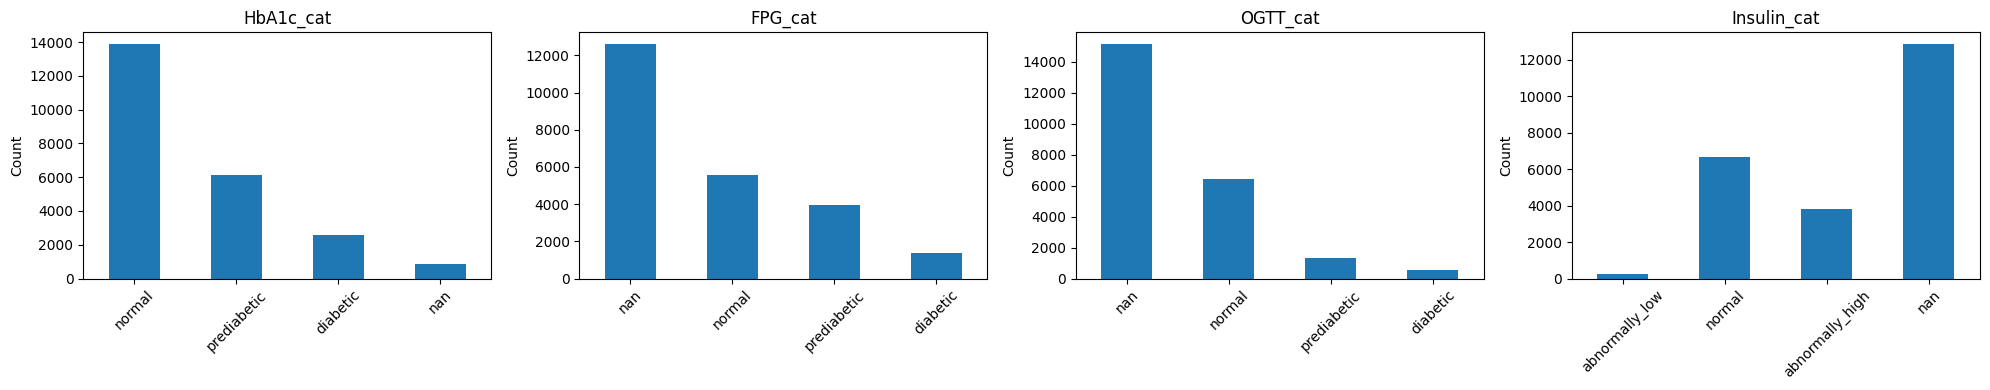

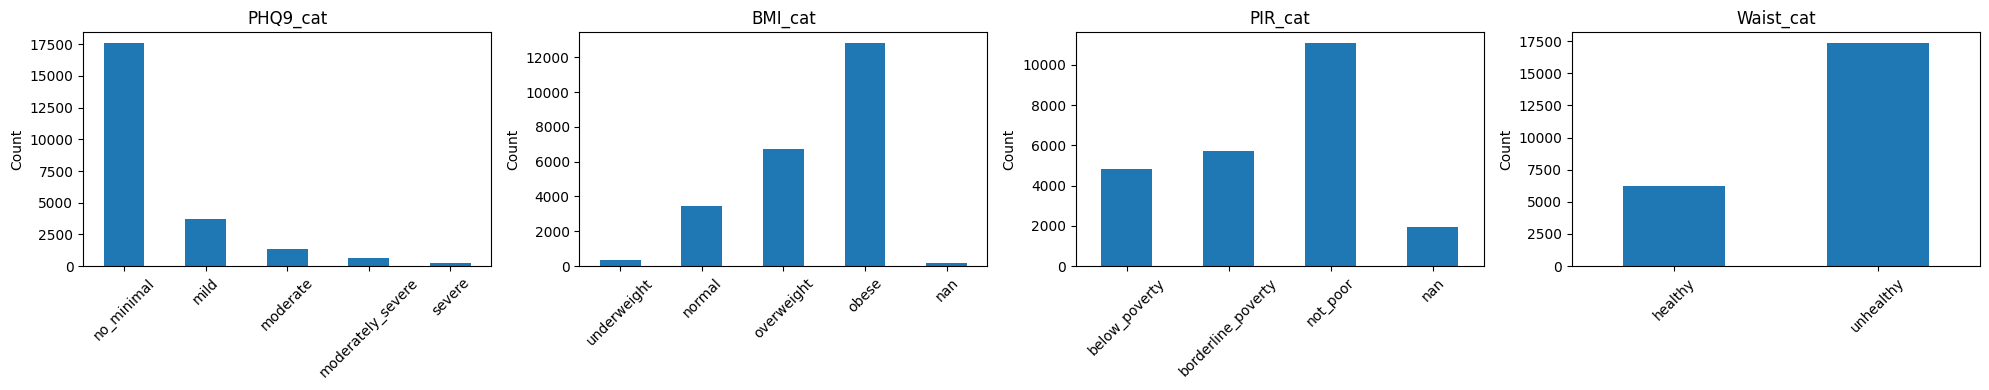

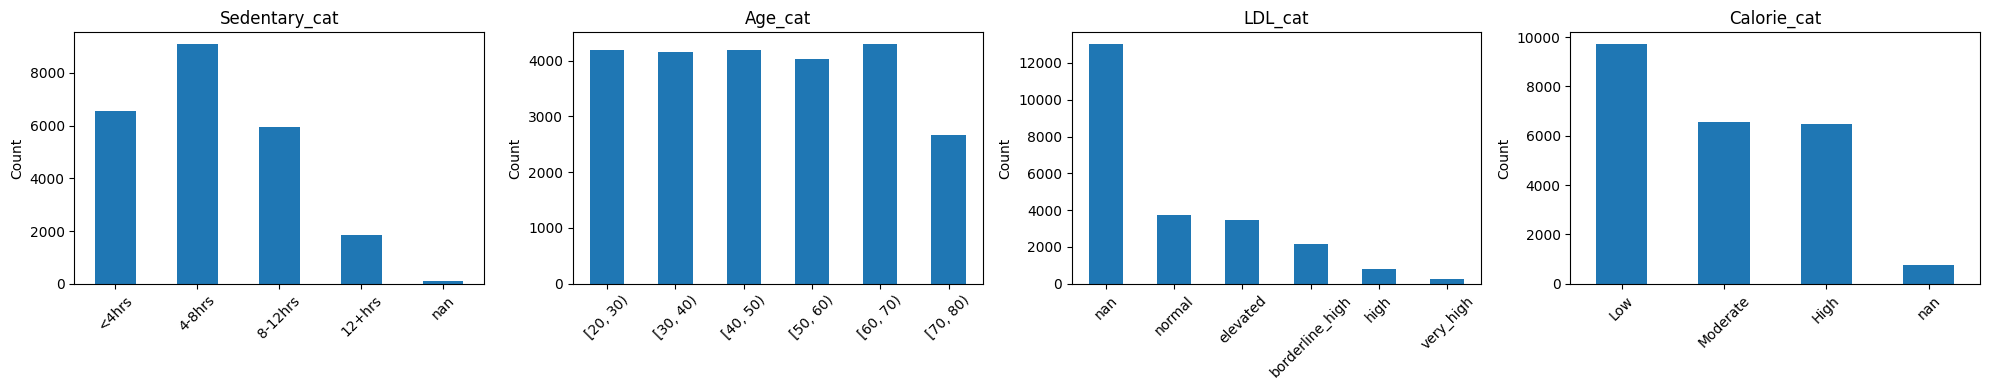

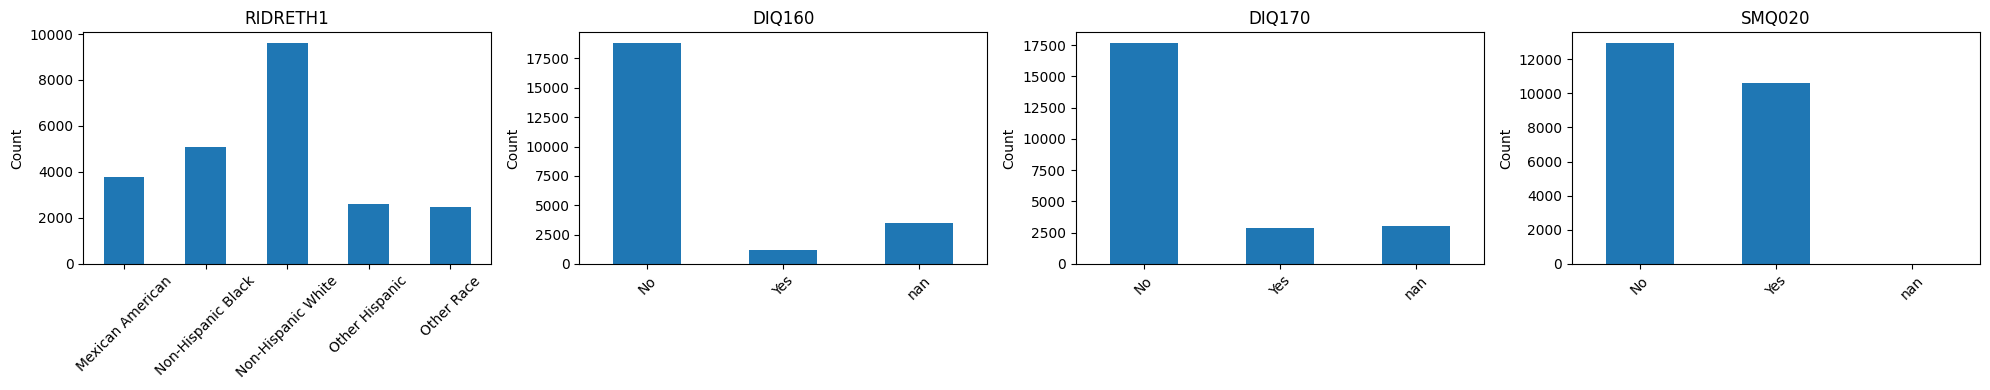

In [ ]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


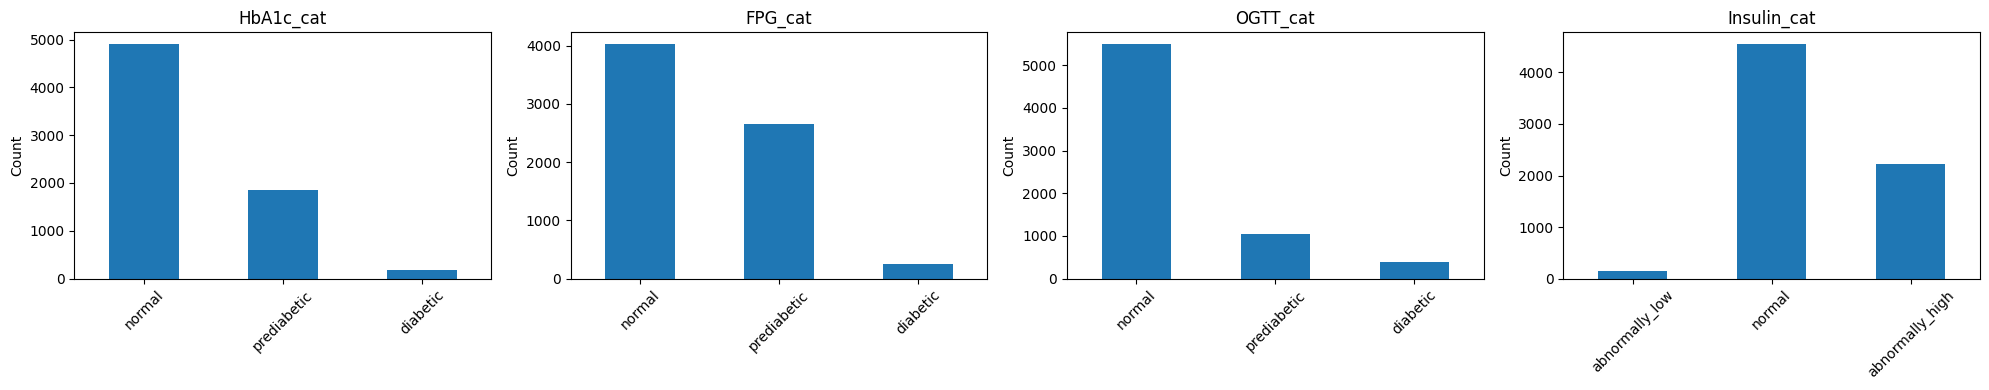

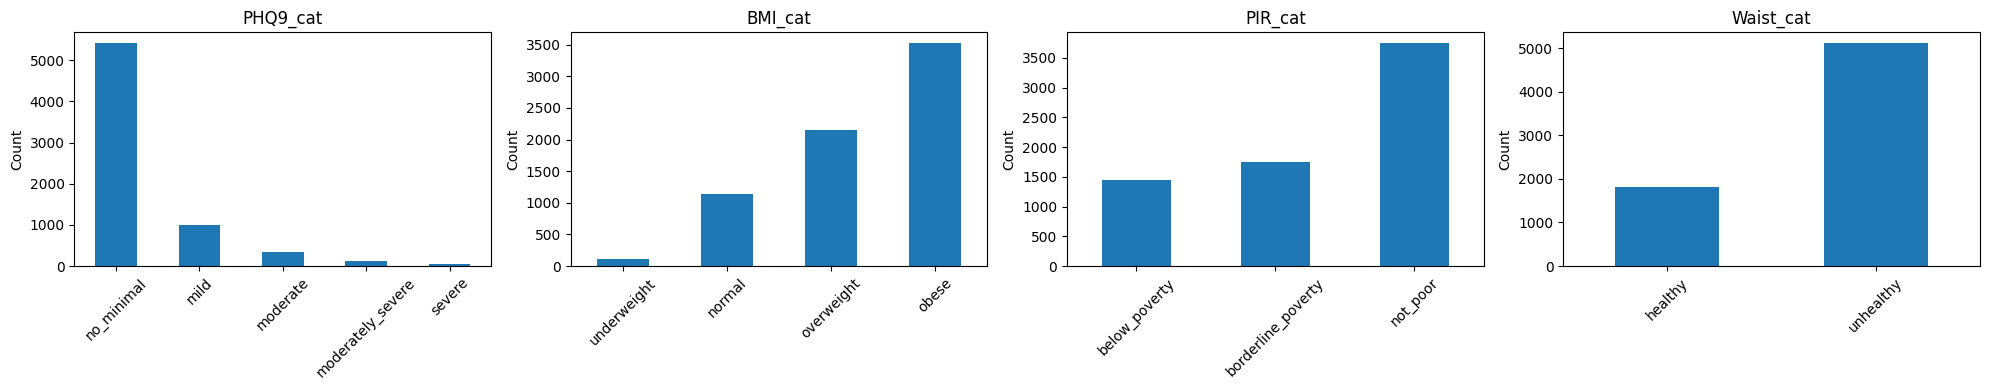

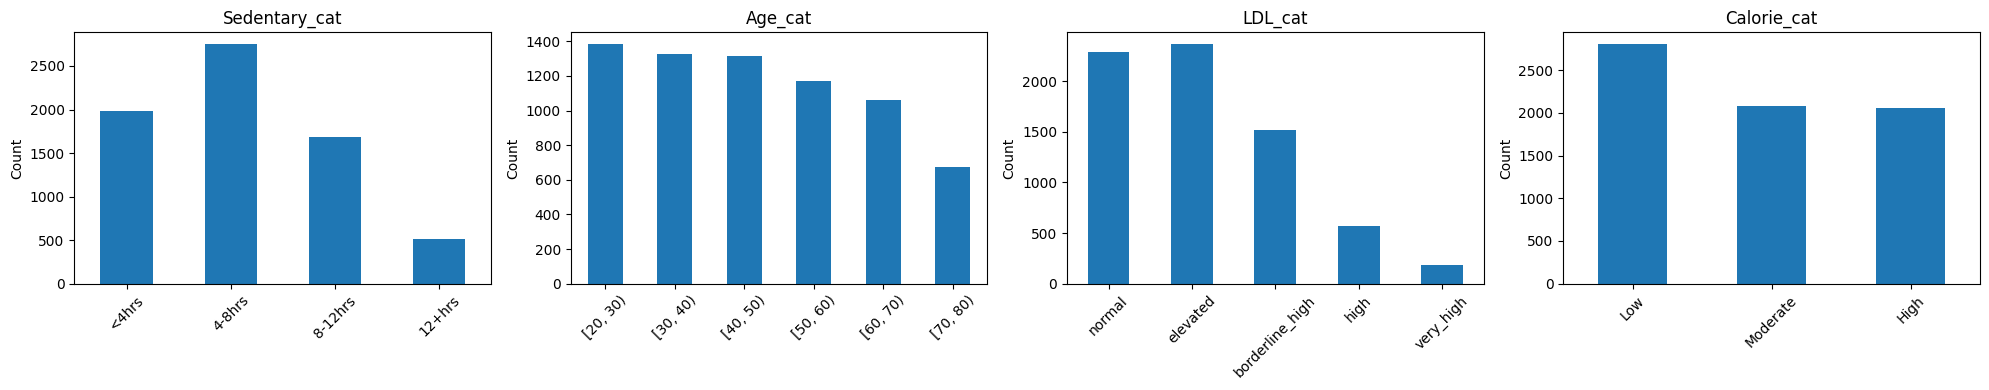

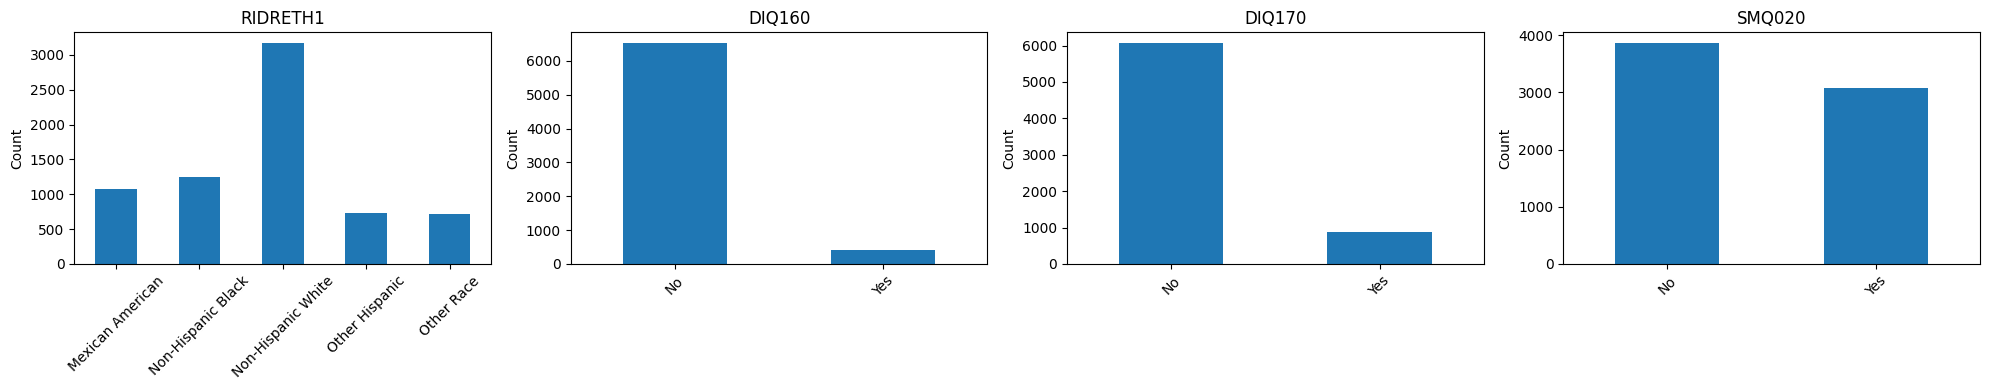

In [ ]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)

#### 1.3.3 Reclassification of dataset

Based on the visualisations above, the following variables contain categories that are too sparse and will be rebinned as below:

- HbA1c, fasting glucose, OGTT glucose -> 'prediabetics' reclassified as 'diabetic'
- PHQ-9 -> 'mild', 'moderate', 'moderately severe', 'severe' reclassified as 'depressed'
- BMI -> 'underweight' reclassified as 'normal'
- Poverty-Income Ratio -> 'below poverty line' and 'borderline poverty' reclassified together as 'in poverty'
- sedentary time -> '8-12hrs' and '12+hrs' reclassfied together as '8+hrs'
- age -> [60,70) and [70,80) reclassified together as [60,80)
- LDL cholesterol -> 'borderline_high', 'high', and 'very_high' reclassified together as 'high'

In [ ]:
## reclassification of biomarkers

# HbA1c: normal vs diabetic (prediabetic merged)
df["HbA1c_cat"] = np.where(
    df["HbA1c_cat"] == "normal",
    "normal",
    "diabetic"
)

# Fasting glucose
df["FPG_cat"] = np.where(
    df["FPG_cat"] == "normal",
    "normal",
    "diabetic"
)

# OGTT glucose
df["OGTT_cat"] = np.where(
    df["OGTT_cat"] == "normal",
    "normal",
    "diabetic"
)


In [ ]:
## reclassification of PHQ-9
df["PHQ9_cat"] = np.where(
    df["PHQ9_cat"] == "no_minimal",
    "not_depressed",
    "depressed"
)


In [ ]:
## reclassification of BMI
df["BMI_cat"] = df["BMI_cat"].replace({
    "underweight": "normal"
})


/tmp/ipython-input-1832919551.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["BMI_cat"] = df["BMI_cat"].replace({


In [ ]:
## reclassification of poverty status
df["PIR_cat"] = df["PIR_cat"].replace({
    "below_poverty": "in_poverty",
    "borderline_poverty": "in_poverty"
})


/tmp/ipython-input-2741219870.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["PIR_cat"] = df["PIR_cat"].replace({


In [ ]:
## reclassification of sedentary time
df["Sedentary_cat"] = df["Sedentary_cat"].replace({
    "8-12hrs": "8h+",
    "12+hrs": "8h+"
})


/tmp/ipython-input-2439367619.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Sedentary_cat"] = df["Sedentary_cat"].replace({


In [ ]:
## reclassification of age groups
df["Age_cat"] = df["Age_cat"].cat.rename_categories({
    pd.Interval(70, 80, closed="left"): pd.Interval(60, 80, closed="left")
})

df["Age_cat"] = pd.Categorical(
    df["Age_cat"].apply(
        lambda x: pd.Interval(60, 80, closed="left") if x == pd.Interval(60, 70, closed="left") else x
    ),
    categories=[
        c for c in df["Age_cat"].cat.categories
        if c != pd.Interval(60, 70, closed="left")
    ],
    ordered=True
)


In [ ]:
## reclassification of LDL cholesterol
df["LDL_cat"] = df["LDL_cat"].replace({
    "borderline_high": "high",
    "very_high": "high"
})


/tmp/ipython-input-3827286033.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["LDL_cat"] = df["LDL_cat"].replace({


In [ ]:
## Clean out NaN rows after reclassification
df_model = df.dropna()
print(f'Shape after reclassification: {df_model.shape}')

Shape after reclassification: (6929, 30)


Summary of classifications for all relevant variables:
| Variable                                | Final Categories        | Cut-offs / Definition                             |
| --------------------------------------- | ----------------------- | ------------------------------------------------- |
| **HbA1c (%)**                           | Normal                  | < 5.7%                                            |
|                                         | Diabetic                | ≥ 5.7% (prediabetes merged into diabetic)         |
| **Fasting Glucose (mmol/L)**            | Normal                  | < 5.6                                             |
|                                         | Diabetic                | ≥ 5.6 (prediabetes merged into diabetic)          |
| **OGTT Glucose (mmol/L)**               | Normal                  | < 7.8                                             |
|                                         | Diabetic                | ≥ 7.8 (prediabetes merged into diabetic)          |
| **Fasting Insulin (pmol/L)**             | Abnormally low          | < 15.1                                            |
|                                         | Normal                  | 15.1 – 78.8                                       |
|                                         | Abnormally high         | > 78.8                                            |
| **PHQ-9 Score**                         | No / Minimal depression | 0 – 4                                             |
|                                         | Depressed               | ≥ 5 (all higher categories merged)                |
| **BMI (kg/m²)**                         | Normal                  | < 23.0 (underweight merged with normal)           |
|                                         | Overweight              | 23.0 – 27.4                                       |
|                                         | Obese                   | ≥ 27.5                                            |
| **Poverty Income Ratio (PIR)**          | In poverty              | < 2.0 (below + borderline merged)                 |
|                                         | Not in poverty          | ≥ 2.0                                             |
| **Waist Circumference (cm)**            | Healthy                 | ≤ 94 (men), ≤ 80 (women)                          |
|                                         | Unhealthy               | > 94 (men), > 80 (women)                          |
| **Sedentary Time (hours/day)**          | < 4 h                   | < 4                                               |
|                                         | 4–8 h                   | 4 to < 8                                          |
|                                         | ≥ 8 h                   | ≥ 8 (8–12 h and 12+ h merged)                     |
| **Age (years)**                         | 20–29                   | 20 to < 30                                        |
|                                         | 30–39                   | 30 to < 40                                        |
|                                         | 40–49                   | 40 to < 50                                        |
|                                         | 50–59                   | 50 to < 60                                        |
|                                         | 60–79                   | 60 to ≤ 79 (merged [60–70) + [70–80))                 |
| **LDL Cholesterol (mg/dL)**             | Normal                  | < 100                                             |
|                                         | Elevated                | 100 – 129                                         |
|                                         | High                    | ≥ 130 (borderline high + high + very high merged) |
| **Calorie Intake (kcal/day)**           | Low                     | < 1800                                            |
|                                         | Moderate                | 1800 – 2500                                       |
|                                         | High                    | > 2500                                            |
| **Smoking Status (```SMQ020```)**             | Yes                     | Ever smoked ≥ 100 cigarettes                      |
|                                         | No                      | Never smoked                                      |
| **Prediabetes diagnosis (```DIQ160```)**      | Yes / No                | Self-reported                                     |
| **Family history of diabetes (```DIQ170```)** | Yes / No                | Self-reported                                     |
| **Sex (```RIAGENDR```)**                      | Male / Female           | NHANES coded                                      |
| **Ethnicity (```RIDRETH1```)**                | 5 categories            | NHANES standard                                   |



Replotting of bar charts to evaluate rebinned data

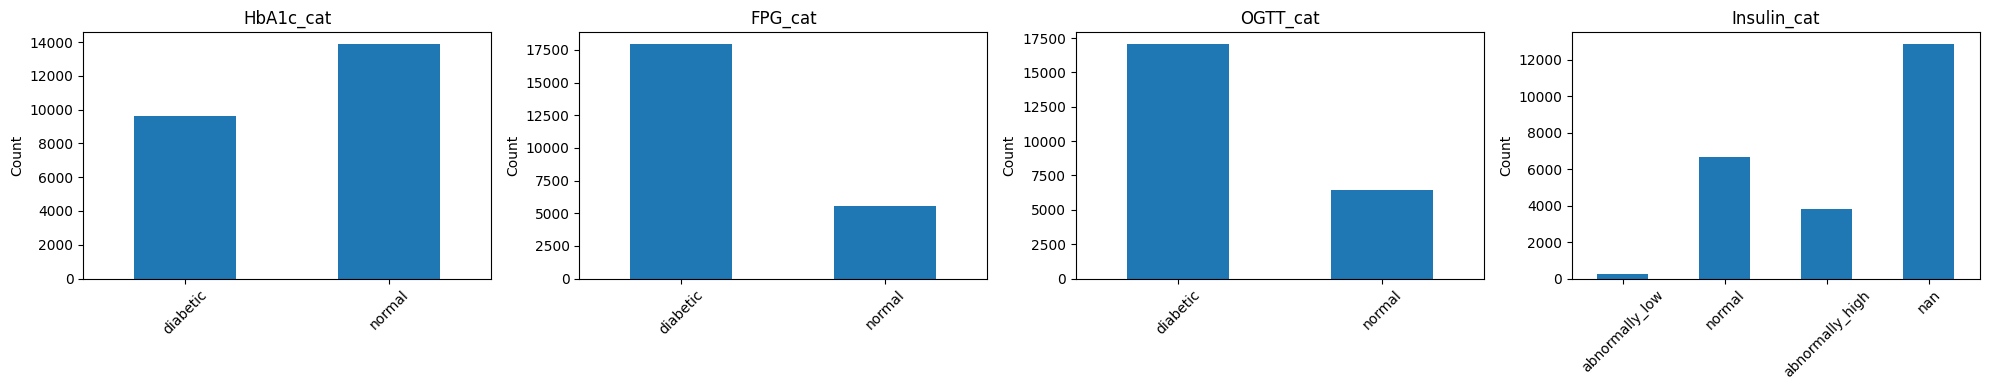

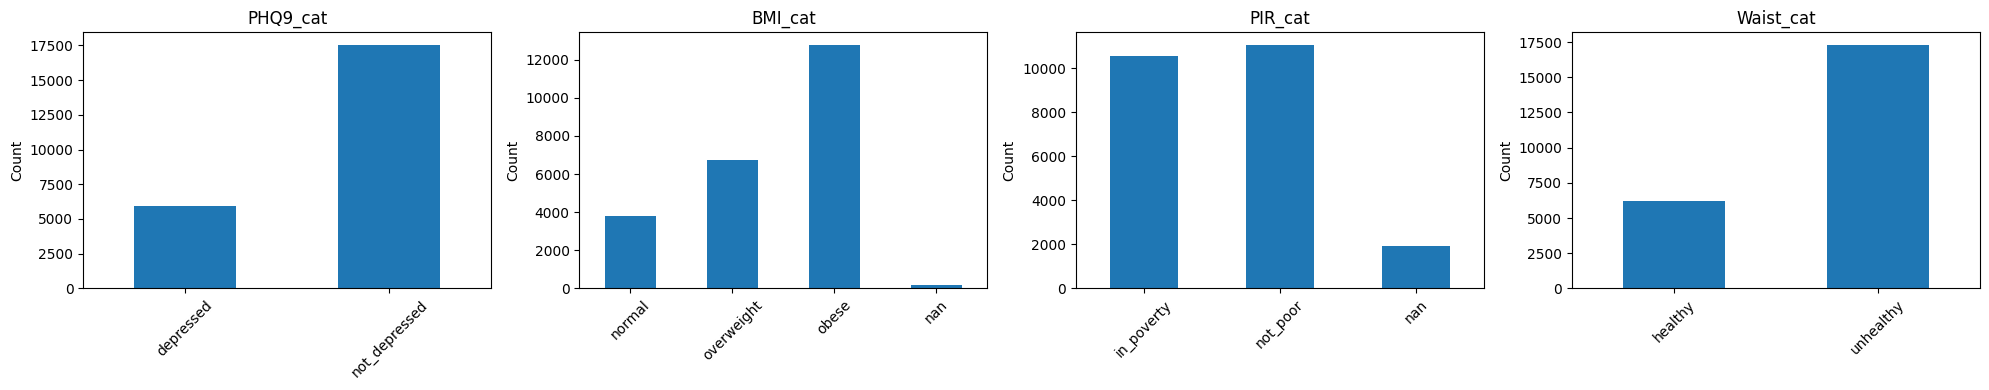

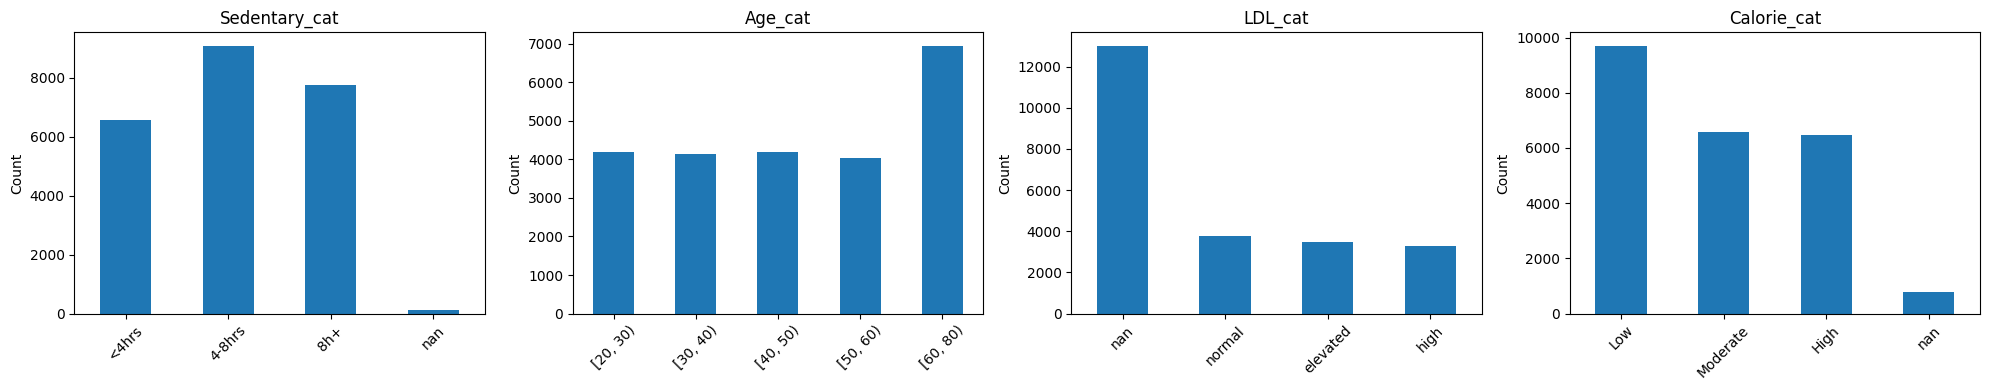

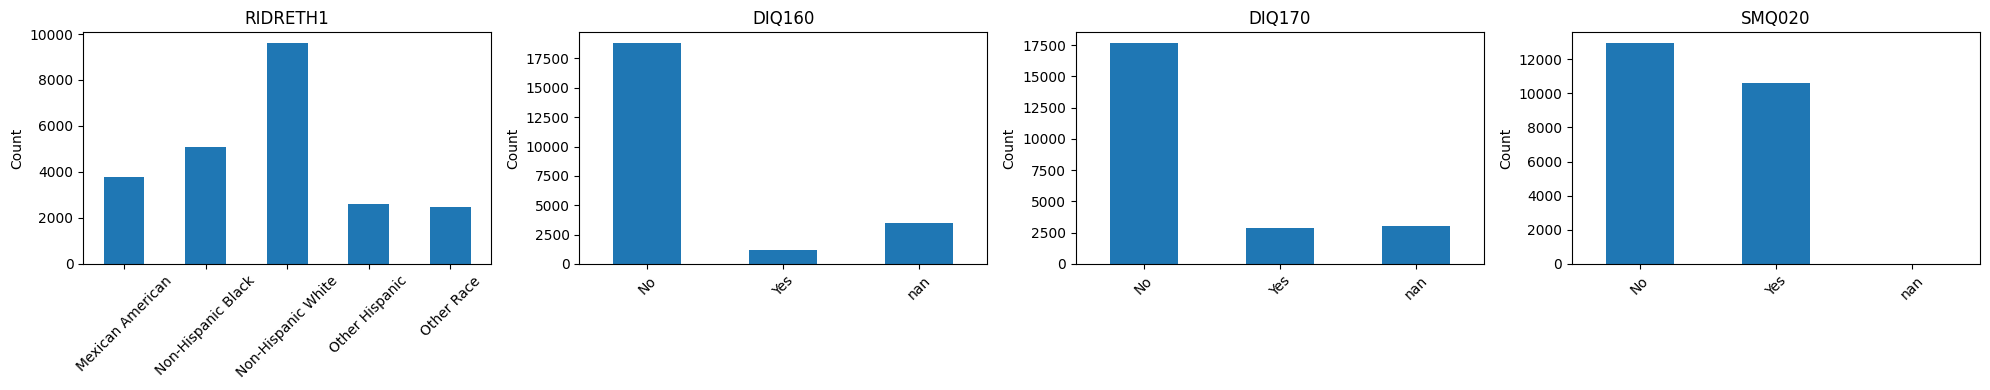

In [ ]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


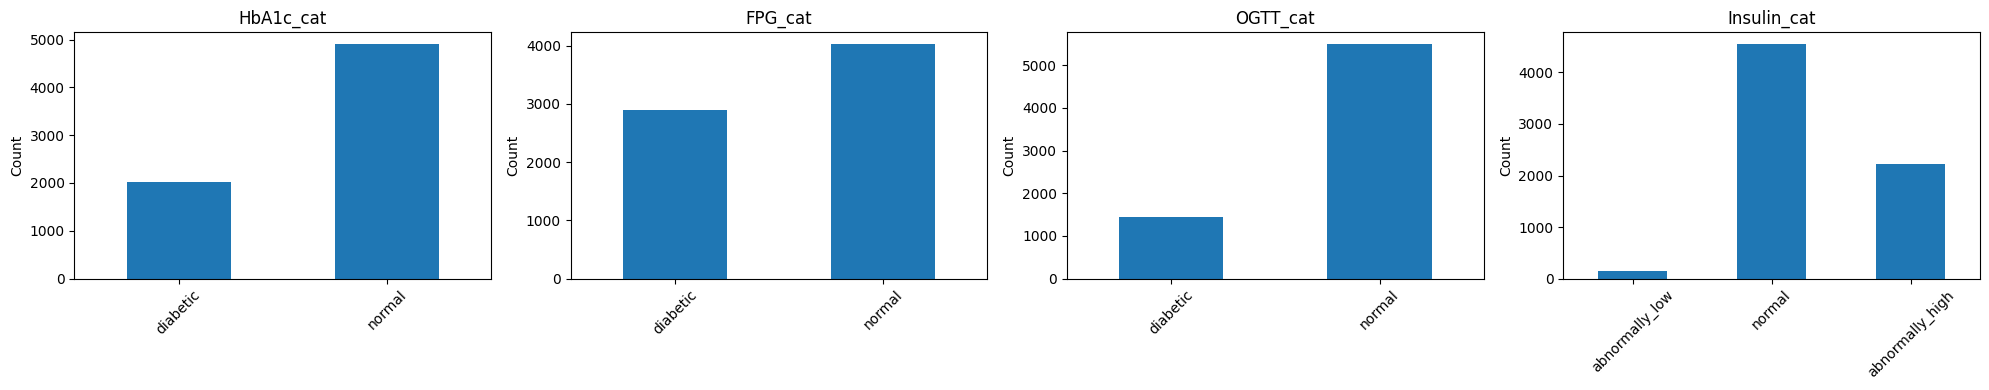

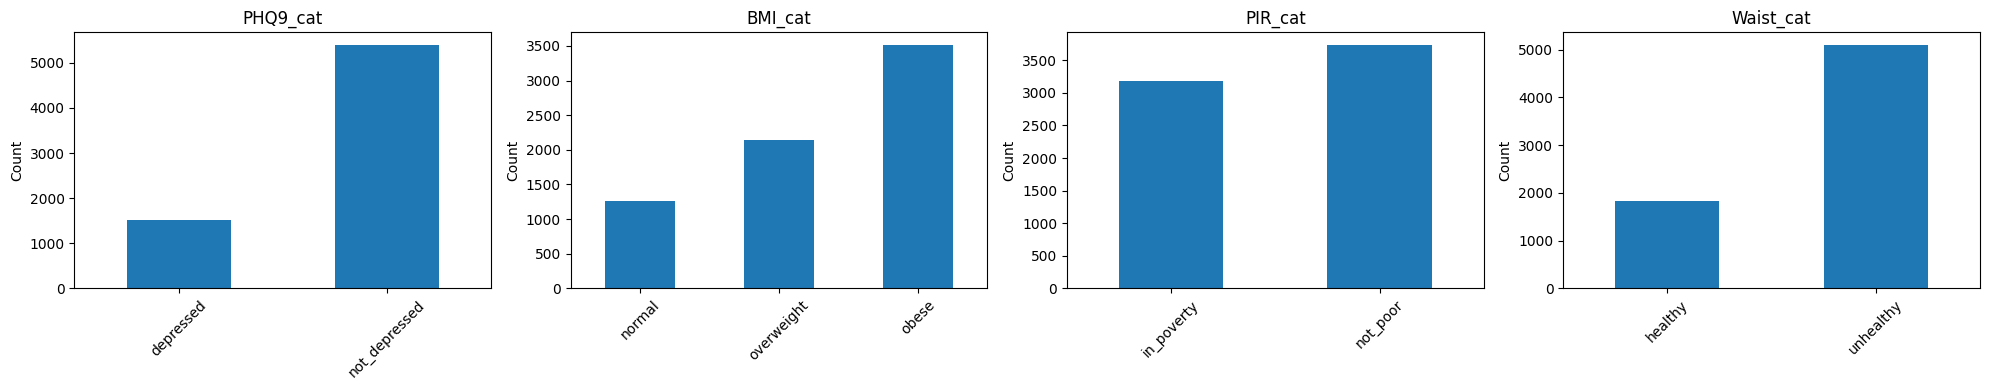

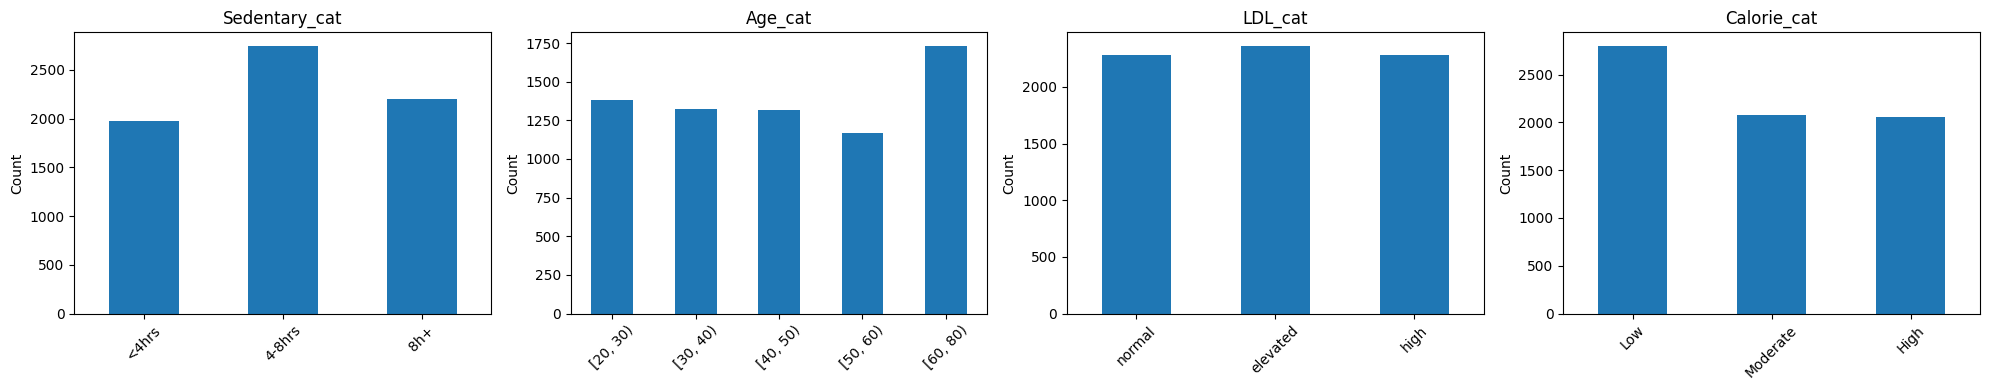

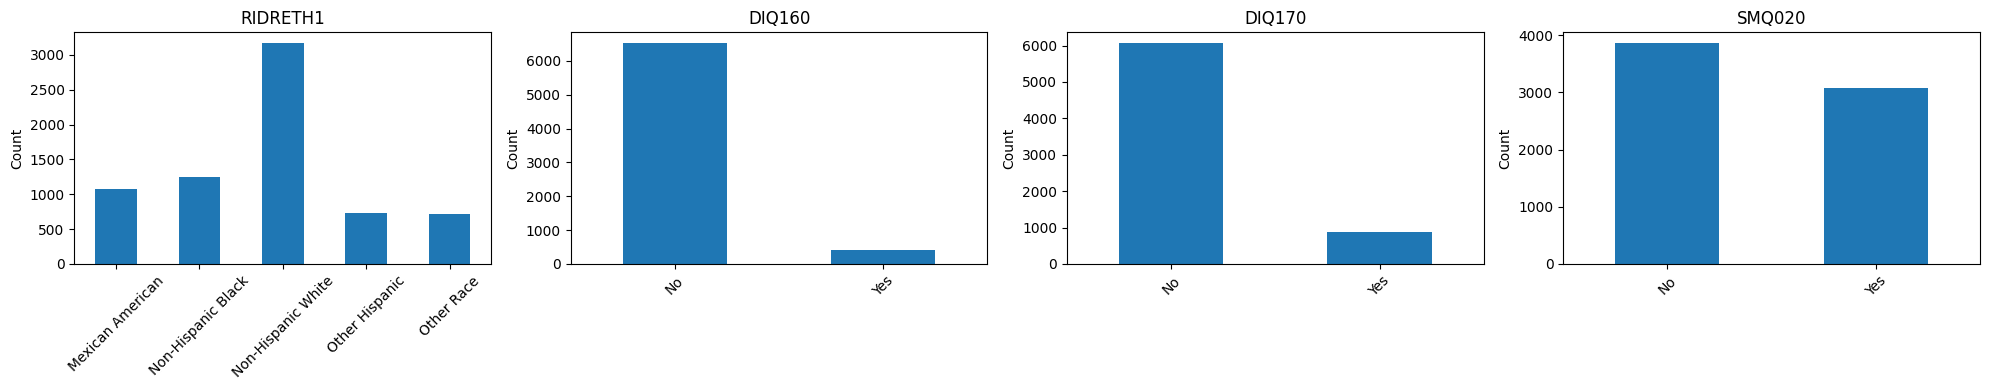

In [ ]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)


Final ```df_model``` for logistic regression use

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

df_model = df_model.reset_index(drop=True)

/tmp/ipython-input-1636670349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype('category')
/tmp/ipython-input-1636670349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df_model[col].astype('category')
/tmp/ipython-input-1636670349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6929 entries, 0 to 6928
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SEQN           6929 non-null   int64   
 1   RIDAGEYR       6929 non-null   Int64   
 2   RIAGENDR       6929 non-null   category
 3   RIDRETH1       6929 non-null   category
 4   INDFMPIR       6929 non-null   float64 
 5   DIQ160         6929 non-null   category
 6   DIQ170         6929 non-null   category
 7   SMQ020         6929 non-null   category
 8   BMXWAIST       6929 non-null   float64 
 9   BMXBMI         6929 non-null   float64 
 10  DR1TKCAL       6929 non-null   float64 
 11  PAD680         6929 non-null   float64 
 12  LBDLDL         6929 non-null   float64 
 13  LBDGLUSI       6929 non-null   float64 
 14  LBXGH          6929 non-null   float64 
 15  LBDGLTSI       6929 non-null   float64 
 16  LBDINSI        6929 non-null   float64 
 17  PHQ9_total     6929 non-null   in

In [ ]:
df_model.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'DIQ160',
       'DIQ170', 'SMQ020', 'BMXWAIST', 'BMXBMI', 'DR1TKCAL', 'PAD680',
       'LBDLDL', 'LBDGLUSI', 'LBXGH', 'LBDGLTSI', 'LBDINSI', 'PHQ9_total',
       'HbA1c_cat', 'FPG_cat', 'OGTT_cat', 'Insulin_cat', 'PHQ9_cat',
       'BMI_cat', 'PIR_cat', 'Waist_cat', 'Sedentary_cat', 'Age_cat',
       'LDL_cat', 'Calorie_cat'],
      dtype='object')

In [ ]:
df_model.head(10)

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,...,OGTT_cat,Insulin_cat,PHQ9_cat,BMI_cat,PIR_cat,Waist_cat,Sedentary_cat,Age_cat,LDL_cat,Calorie_cat
0,41479,52,Male,Mexican American,2.20,No,No,No,95.4,27.56,...,normal,normal,not_depressed,obese,not_poor,unhealthy,<4hrs,"[50, 60)",elevated,High
1,41485,30,Female,Other Hispanic,1.01,No,No,No,89.7,25.99,...,normal,normal,not_depressed,overweight,in_poverty,unhealthy,<4hrs,"[30, 40)",elevated,Low
2,41486,61,Female,Mexican American,1.75,No,No,No,97.0,31.21,...,diabetic,abnormally_high,not_depressed,obese,in_poverty,unhealthy,8h+,"[60, 80)",elevated,Low
3,41487,27,Male,Other Race,5.00,No,No,No,82.9,23.44,...,normal,normal,not_depressed,overweight,not_poor,healthy,8h+,"[20, 30)",elevated,Low
4,41489,40,Female,Mexican American,2.15,No,No,No,109.2,36.59,...,normal,abnormally_high,not_depressed,obese,not_poor,unhealthy,8h+,"[40, 50)",elevated,Moderate
5,41492,72,Male,Non-Hispanic White,1.02,No,No,No,106.2,29.02,...,normal,abnormally_high,not_depressed,obese,in_poverty,unhealthy,<4hrs,"[60, 80)",elevated,Moderate
6,41494,40,Male,Mexican American,1.30,No,No,Yes,95.6,25.46,...,normal,normal,not_depressed,overweight,in_poverty,unhealthy,<4hrs,"[40, 50)",high,Moderate
7,41498,68,Male,Non-Hispanic Black,1.63,No,No,No,95.5,28.16,...,diabetic,normal,not_depressed,obese,in_poverty,unhealthy,<4hrs,"[60, 80)",normal,Low
8,41502,29,Male,Mexican American,3.41,No,No,Yes,95.4,29.13,...,normal,normal,depressed,obese,not_poor,unhealthy,<4hrs,"[20, 30)",elevated,High
9,41518,50,Male,Non-Hispanic White,5.00,No,No,No,101.9,29.12,...,normal,abnormally_high,not_depressed,obese,not_poor,unhealthy,8h+,"[50, 60)",elevated,High


# **2. Data exploration**

##2.1 Grouped Bar Charts

**How are predictors distributed between normal and abnormal biomarker groups**

In [ ]:
biomarkers = ["HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat"]

predictors = [
    "Age_cat", "RIAGENDR", "RIDRETH1",
    "PIR_cat", "Calorie_cat", "PHQ9_cat",
    "SMQ020", "Sedentary_cat", "LDL_cat",
    "BMI_cat", "Waist_cat", "DIQ160", "DIQ170"
]

missing = [c for c in biomarkers + predictors if c not in df.columns]
print("Missing columns:", missing)

Missing columns: []


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

biomarkers = ["OGTT_cat", "HbA1c_cat", "FPG_cat", "Insulin_cat"]

def plot_category_grid(df, predictors, category_name, biomarkers=biomarkers, ncols=3, figsize_per_plot=(5.2, 4.0)):
    """
    Makes ONE big grid of grouped bar charts for:
    (each predictor) x (each biomarker).

    Each subplot: predictor distribution across biomarker groups (row-normalized %).
    Total plots = len(predictors) * len(biomarkers).
    """
    total = len(predictors) * len(biomarkers)
    nrows = math.ceil(total / ncols)

    fig_w = ncols * figsize_per_plot[0]
    fig_h = nrows * figsize_per_plot[1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    axes = np.array(axes).reshape(-1)

    plot_i = 0
    for predictor in predictors:
        for biomarker in biomarkers:
            ax = axes[plot_i]
            plot_i += 1

            # drop NA for this pair
            d = df[[biomarker, predictor]].dropna()

            # row-normalized proportions (% within biomarker group)
            ct = pd.crosstab(d[biomarker], d[predictor], normalize="index") * 100
            ct = ct.round(1)

            ct.plot(kind="bar", ax=ax, width=0.85, legend=False)

            ax.set_title(f"{predictor} by {biomarker}", fontsize=10)
            ax.set_xlabel(biomarker)
            ax.set_ylabel("% within biomarker group")
            ax.tick_params(axis="x", rotation=25)

    # Turn off unused subplots (if any)
    for j in range(plot_i, len(axes)):
        axes[j].axis("off")

    # One shared legend for the whole figure (using the last computed ct)
    # Create legend from the last axis that has bars
    handles, labels = axes[plot_i-1].get_legend_handles_labels()
    if labels:
        fig.legend(handles, labels, title="Predictor categories", bbox_to_anchor=(1.01, 1), loc="upper left")

    fig.suptitle(f"{category_name}: Predictors across Biomarker Groups (OGTT, HbA1c, FPG)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"✅ {category_name}: plotted {total} charts ({len(predictors)} predictors × {len(biomarkers)} biomarkers)")

###2.1.1 Analysis of biomarkers by demographics

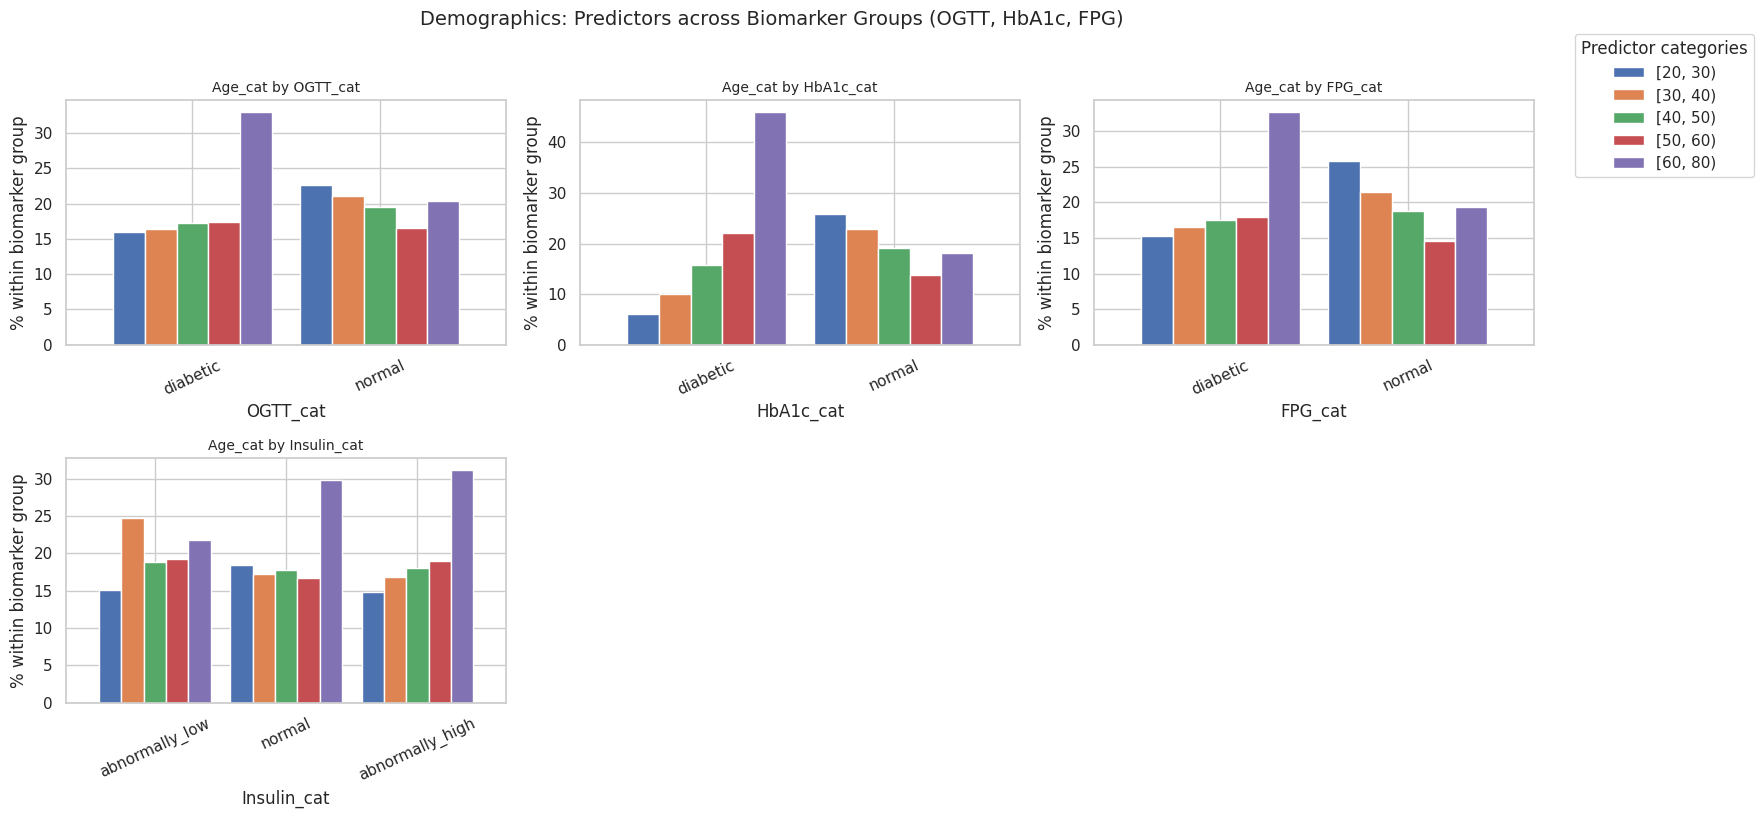

✅ Demographics: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
demographics = ["Age_cat"]
plot_category_grid(df, demographics, "Demographics")

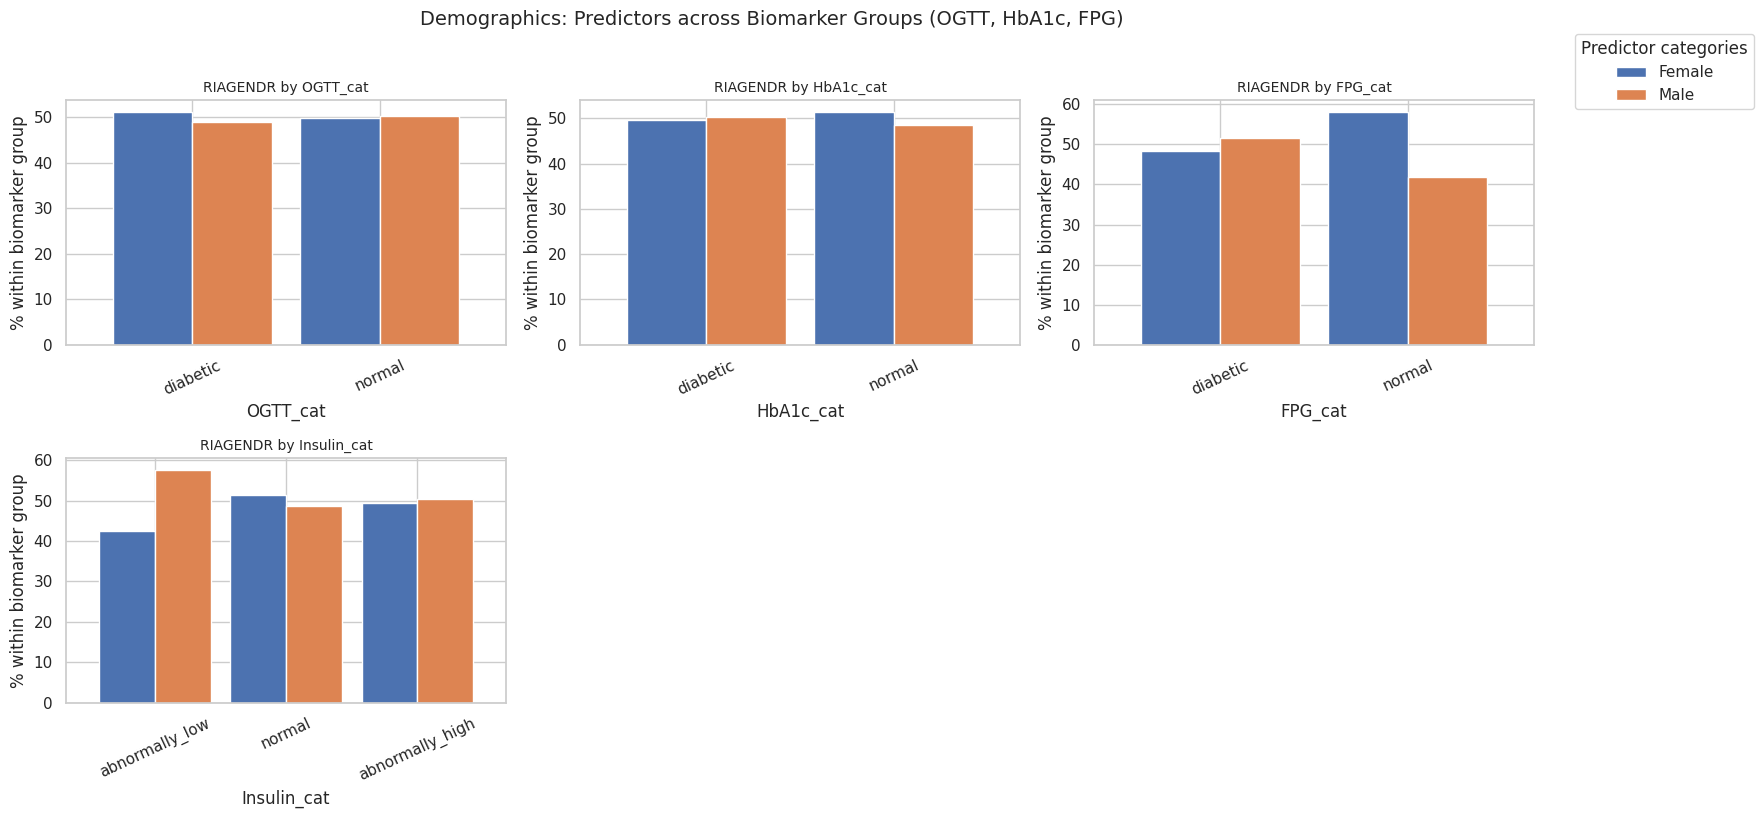

✅ Demographics: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
demographics = ["RIAGENDR"]
plot_category_grid(df, demographics, "Demographics")

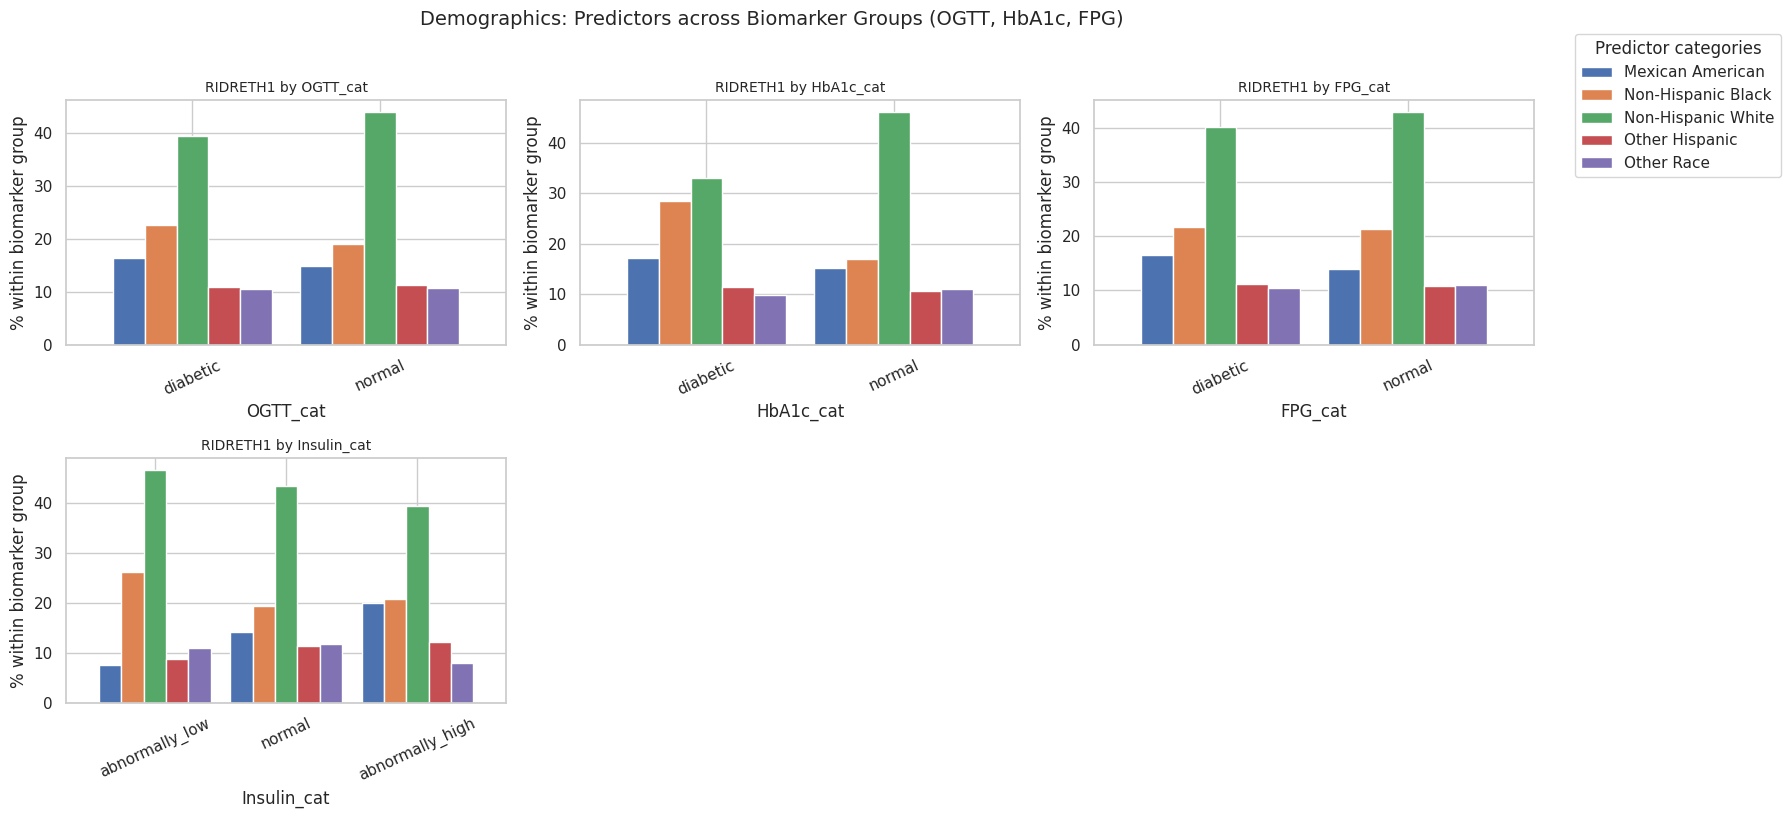

✅ Demographics: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
demographics = ["RIDRETH1"]
plot_category_grid(df, demographics, "Demographics")

Age - older age categories contribute to a larger amount of the individuals in the diabedic HbA1c group. Has clear age gradient, abmornal HbA1c values are commone among older people. Thus age is a key risk-related factor

Sex - both genders are relatively evenly represented in both diabedic and normal categories. Sex alone may not strongly differentiat4e HbA1c.

Ethnicity - Higher proportions of Non-Hispanic Black and Mexican American individuals fall under the diabedic group while higer proportions of Non-Hispanic White individuals falol under the normal HbA1c group. Ethnicity may be an important predictor to include subsequent analyses

###2.1.2 Analysis of biomarkers by Socioeconomic status

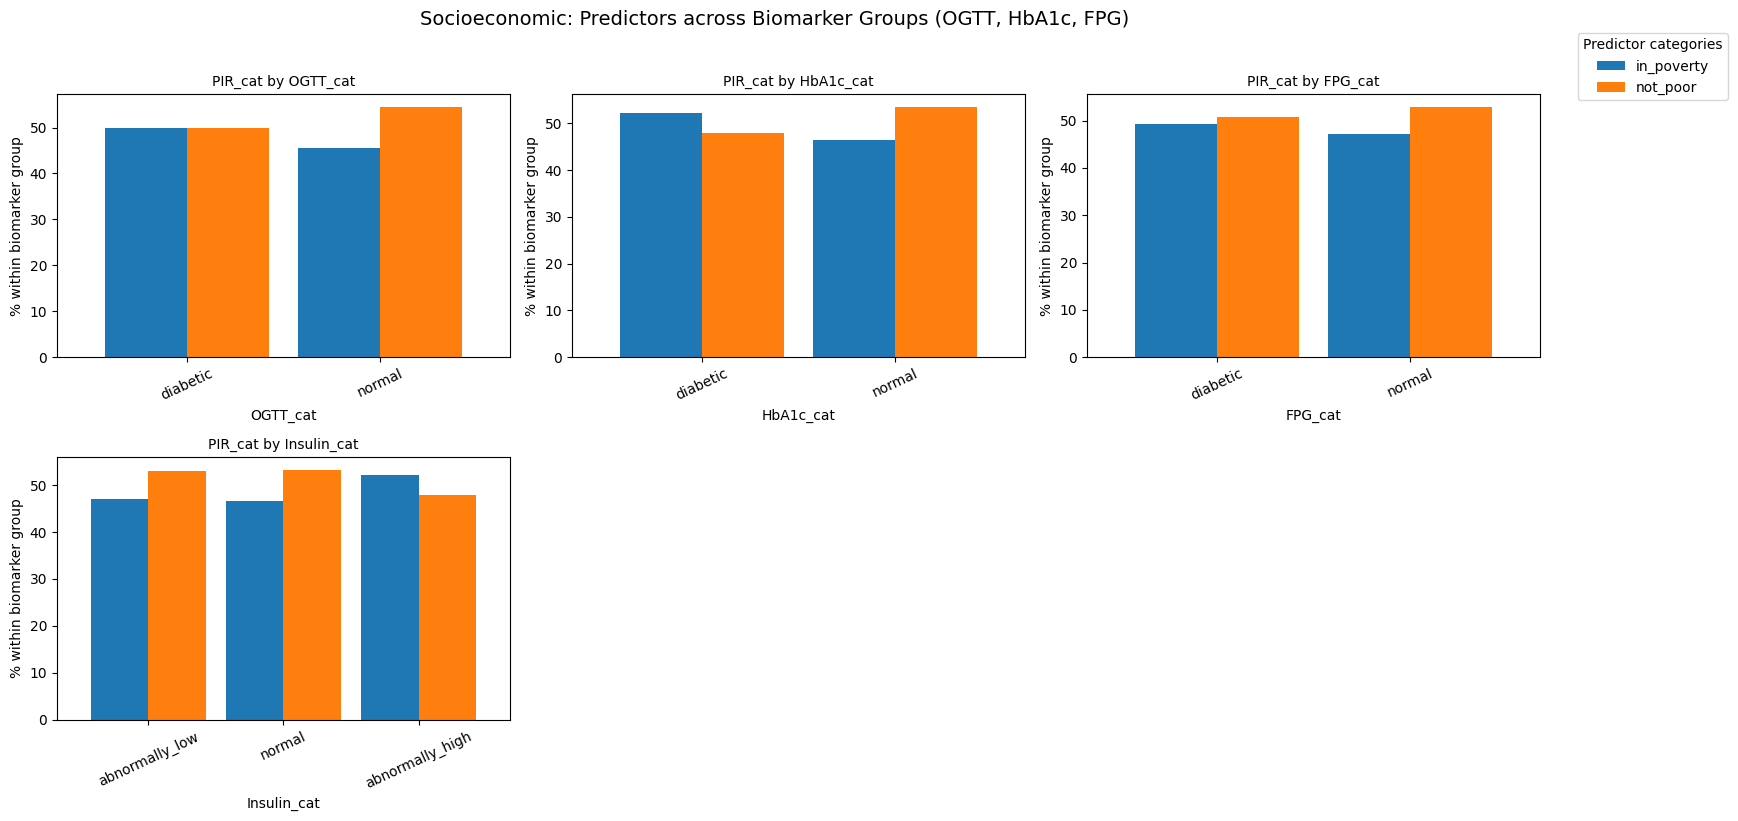

✅ Socioeconomic: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
socioeconomic = ["PIR_cat",]
plot_category_grid(df, socioeconomic, "Socioeconomic")


Poverty-to-income ratio - individuals in poverty make uo a slightly higher proportion of the diabedic group compared to the normal. Shows a socioeconomic gradient where lower income status -> poorer glycaemic control

###2.1.3 Analysis of biomarkers by Lifestyle/behaviour

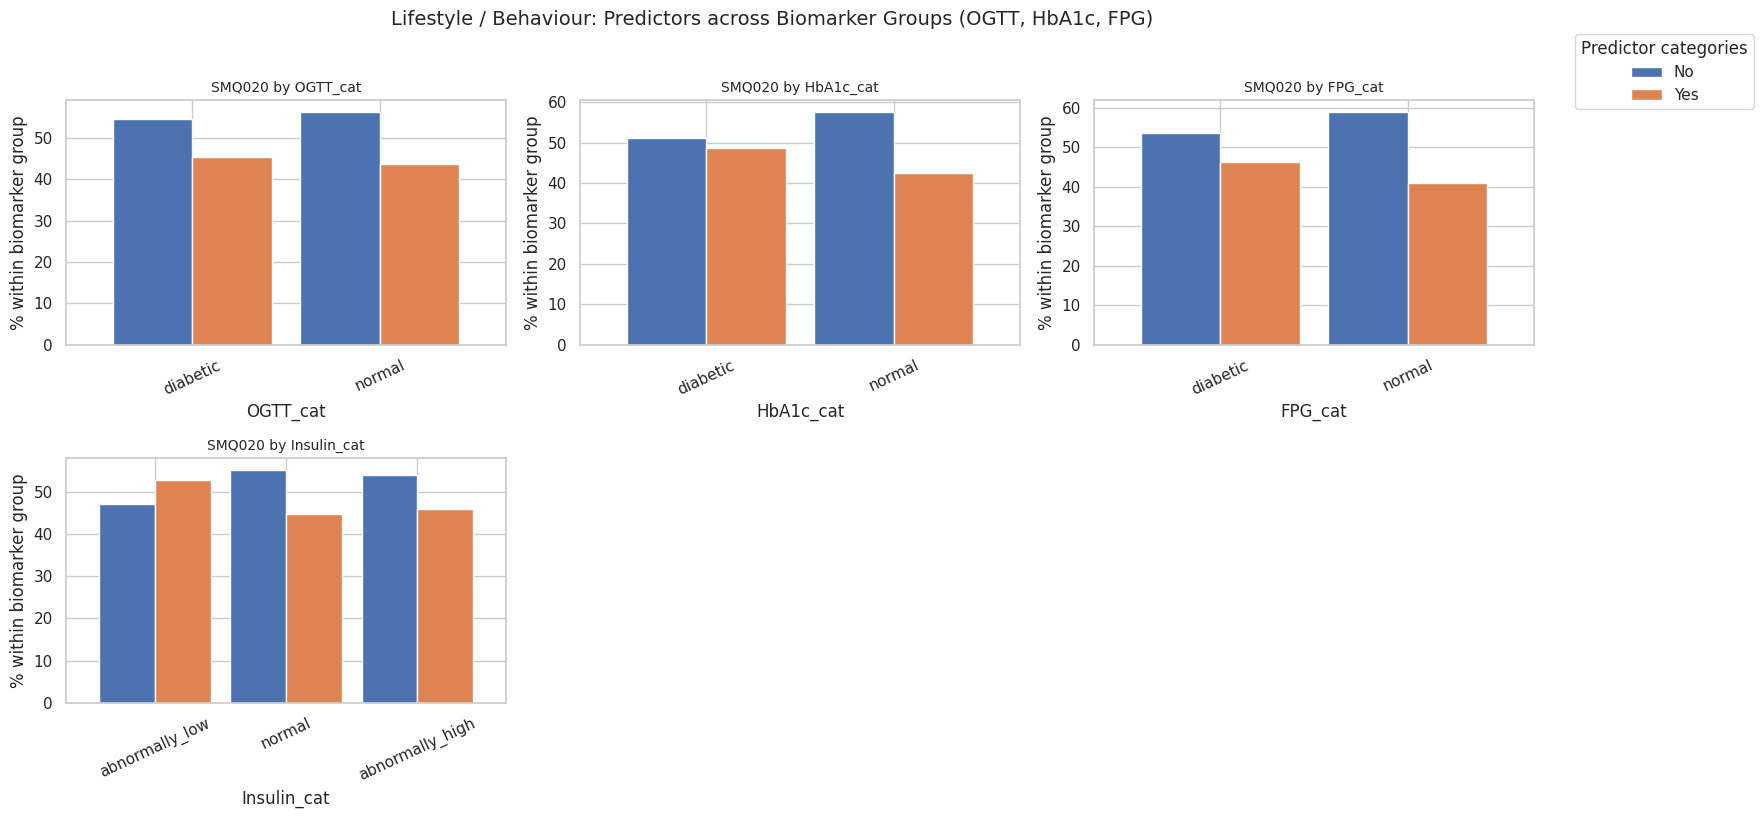

✅ Lifestyle / Behaviour: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
lifestyle = ["SMQ020"]
plot_category_grid(df, lifestyle, "Lifestyle / Behaviour")


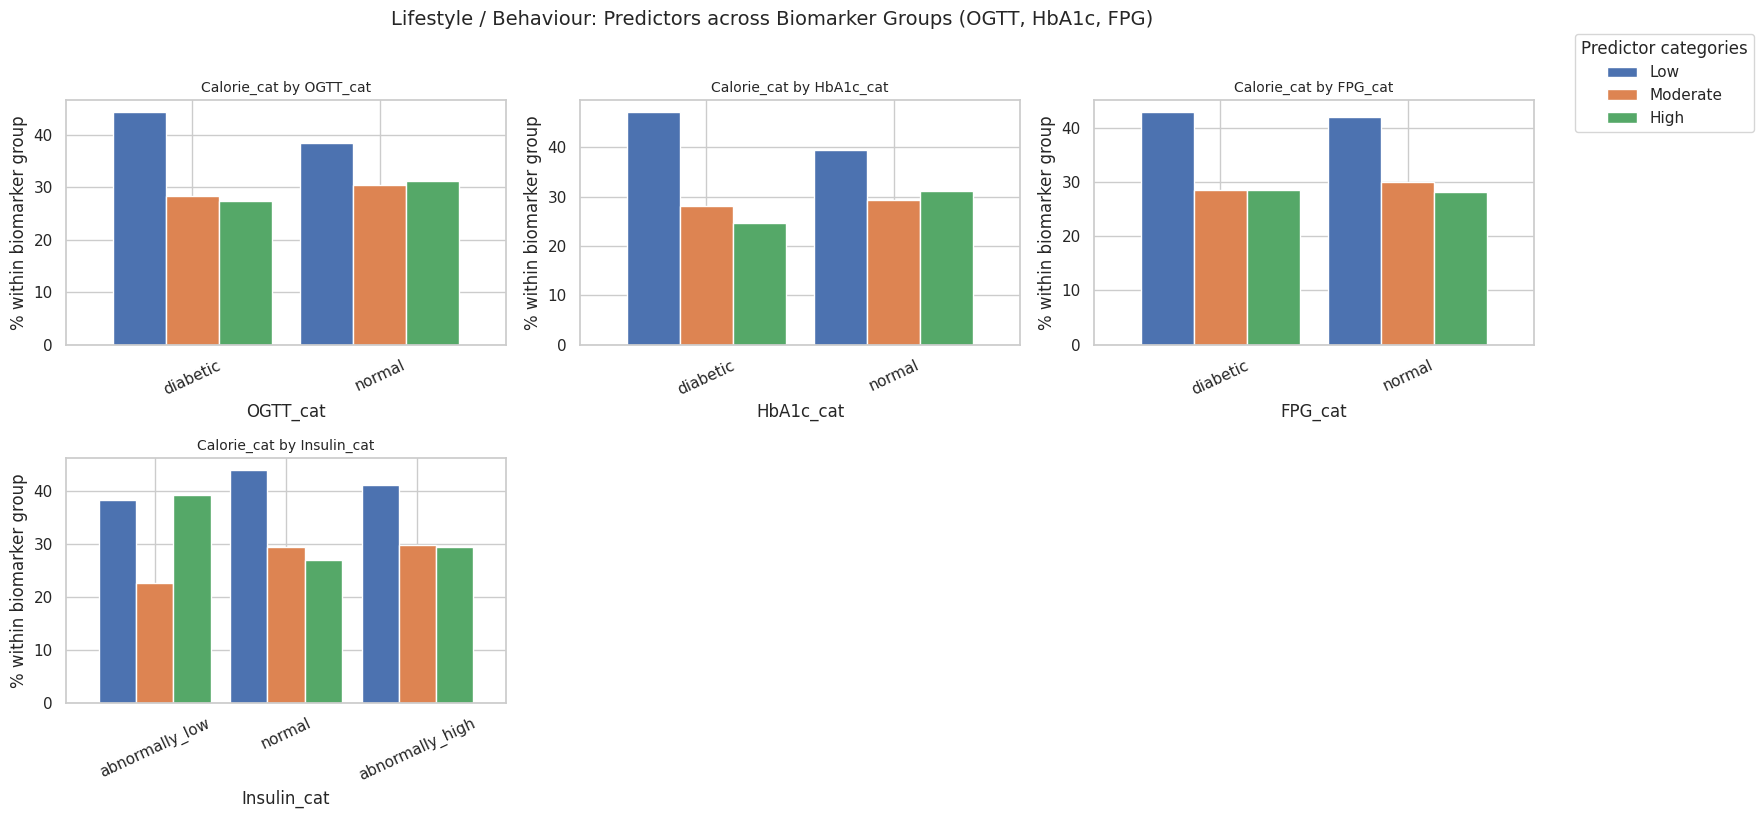

✅ Lifestyle / Behaviour: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
lifestyle = ["Calorie_cat"]
plot_category_grid(df, lifestyle, "Lifestyle / Behaviour")


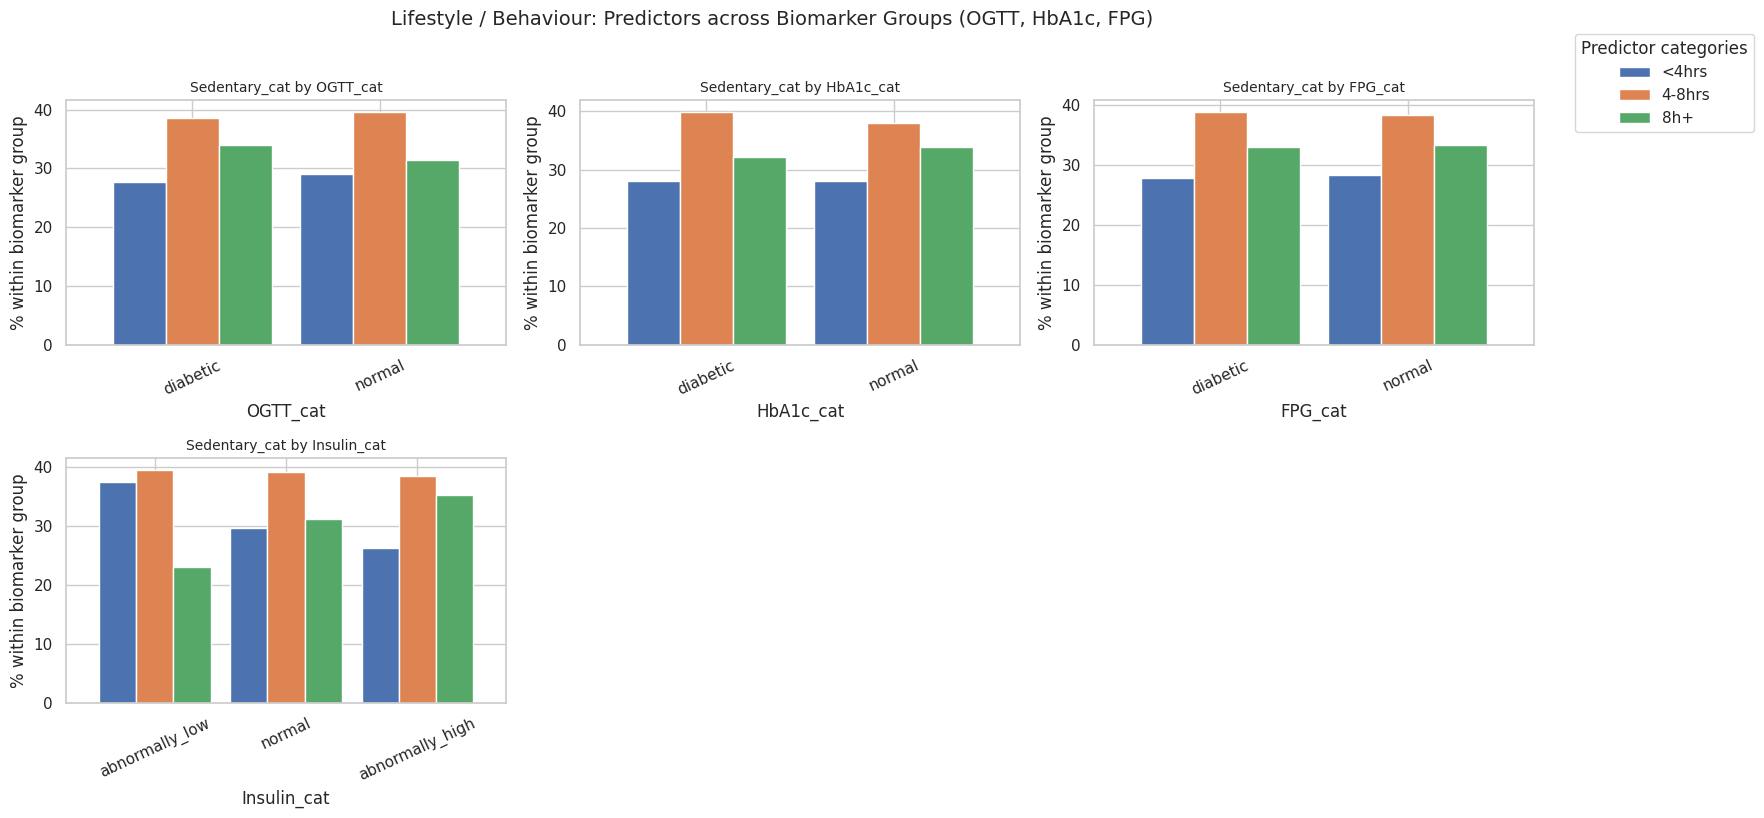

✅ Lifestyle / Behaviour: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
lifestyle = ["Sedentary_cat"]
plot_category_grid(df, lifestyle, "Lifestyle / Behaviour")


Smoking - higher proportions of smokers in the diabedic group. Smoking behavious much more common in individuals with abnormal HbA1c levels

calorie intake - higher calorie intake individuals fall under the normal HbA1c group, lower calorie intake more prevalent in diabedic group.

sedentary time - longer sedentaru durations appear more common in diabedic HbA1c group, shorter time more prevalent in normal group. Physical inactivity may be linked to poorer glycaemic outcomes.

###2.1.4 Analysis of biomarkers by Anthropometric,clinical/diabetes history

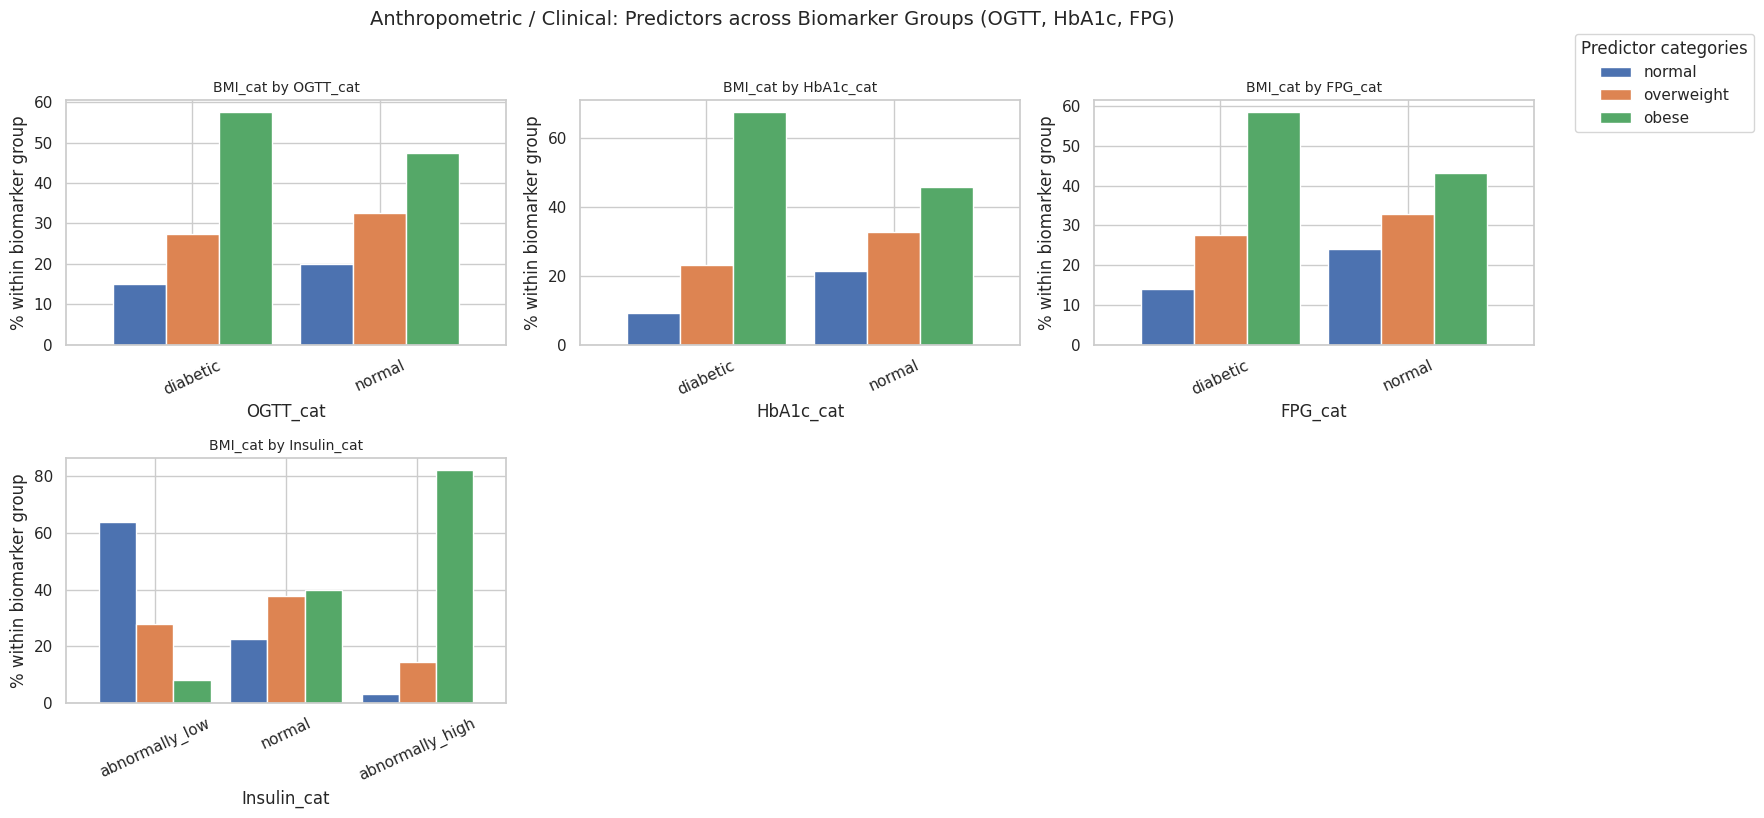

✅ Anthropometric / Clinical: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
anthro_clinical = ["BMI_cat"]
plot_category_grid(df, anthro_clinical, "Anthropometric / Clinical")

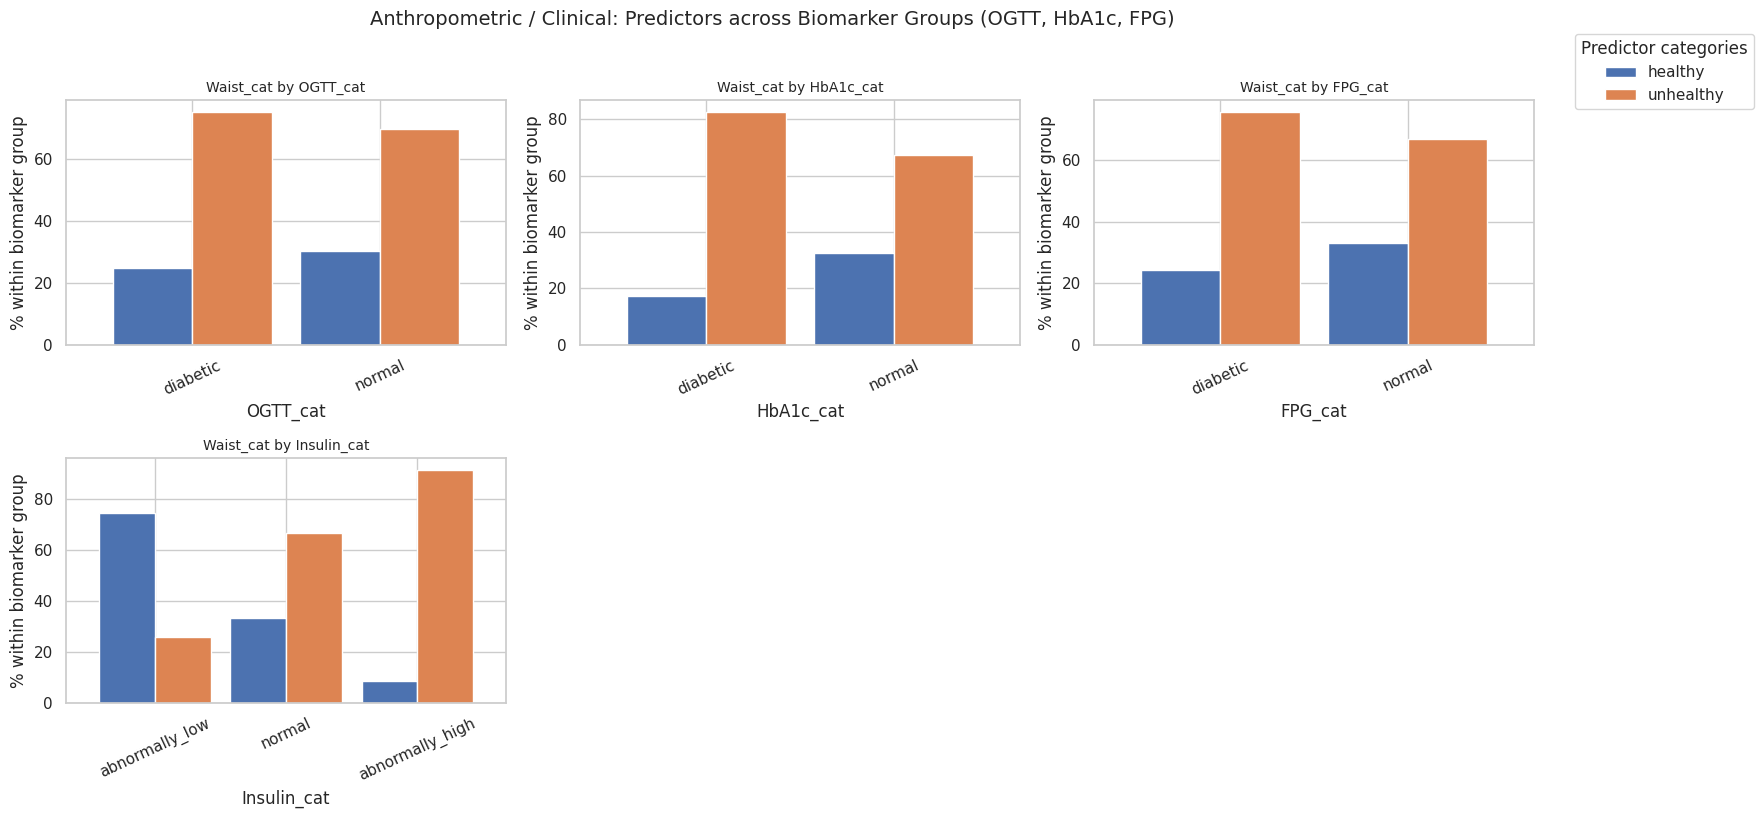

✅ Anthropometric / Clinical: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
anthro_clinical = ["Waist_cat"]
plot_category_grid(df, anthro_clinical, "Anthropometric / Clinical")

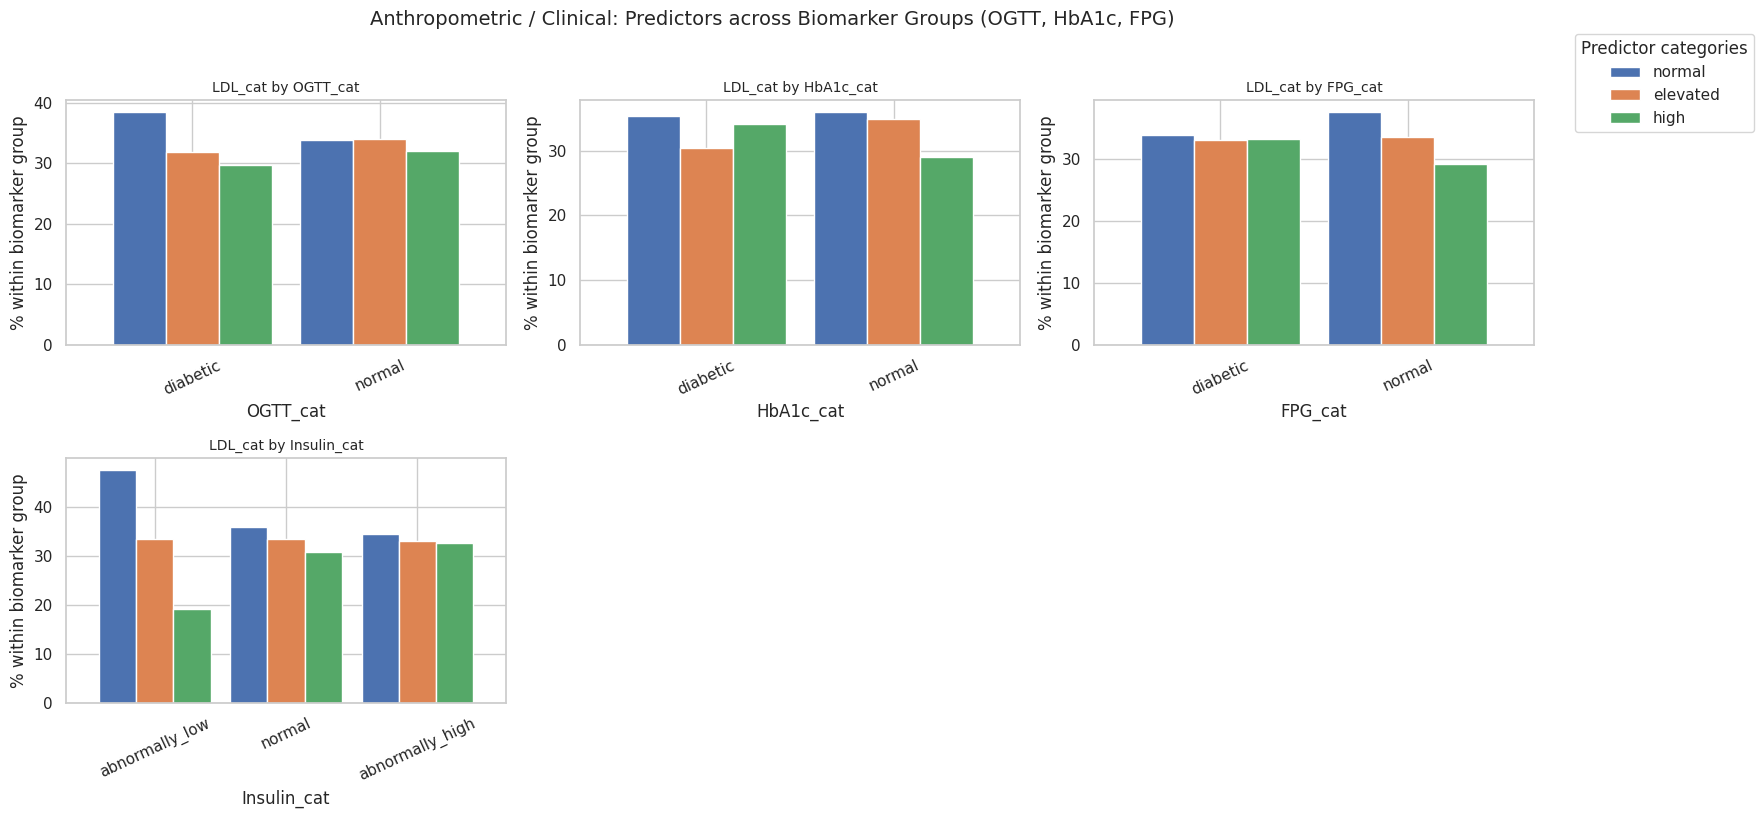

✅ Anthropometric / Clinical: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
anthro_clinical = ["LDL_cat"]
plot_category_grid(df, anthro_clinical, "Anthropometric / Clinical")

BMI - Higher propotion of individuals classfied as obese fall under diabedic category. indivudals with normal or overweight BMI fall under the normal HbA1c group. BMI is a key varible if interest.

Waist circumference - unhealthy waist circumference far more prevalent in the diabedic HbA1c group than the normal group. Aligns the role of adiposity in metabolic dysfunction.

LDL cholesterol - elevated and high LDL levelsa re present in both groups. Distribution does not differ as markedly as for BMI and waist circumference. LDL plays a weaker or more indirect role.


###2.1.5 Analysis of biomarkers with diabetes history

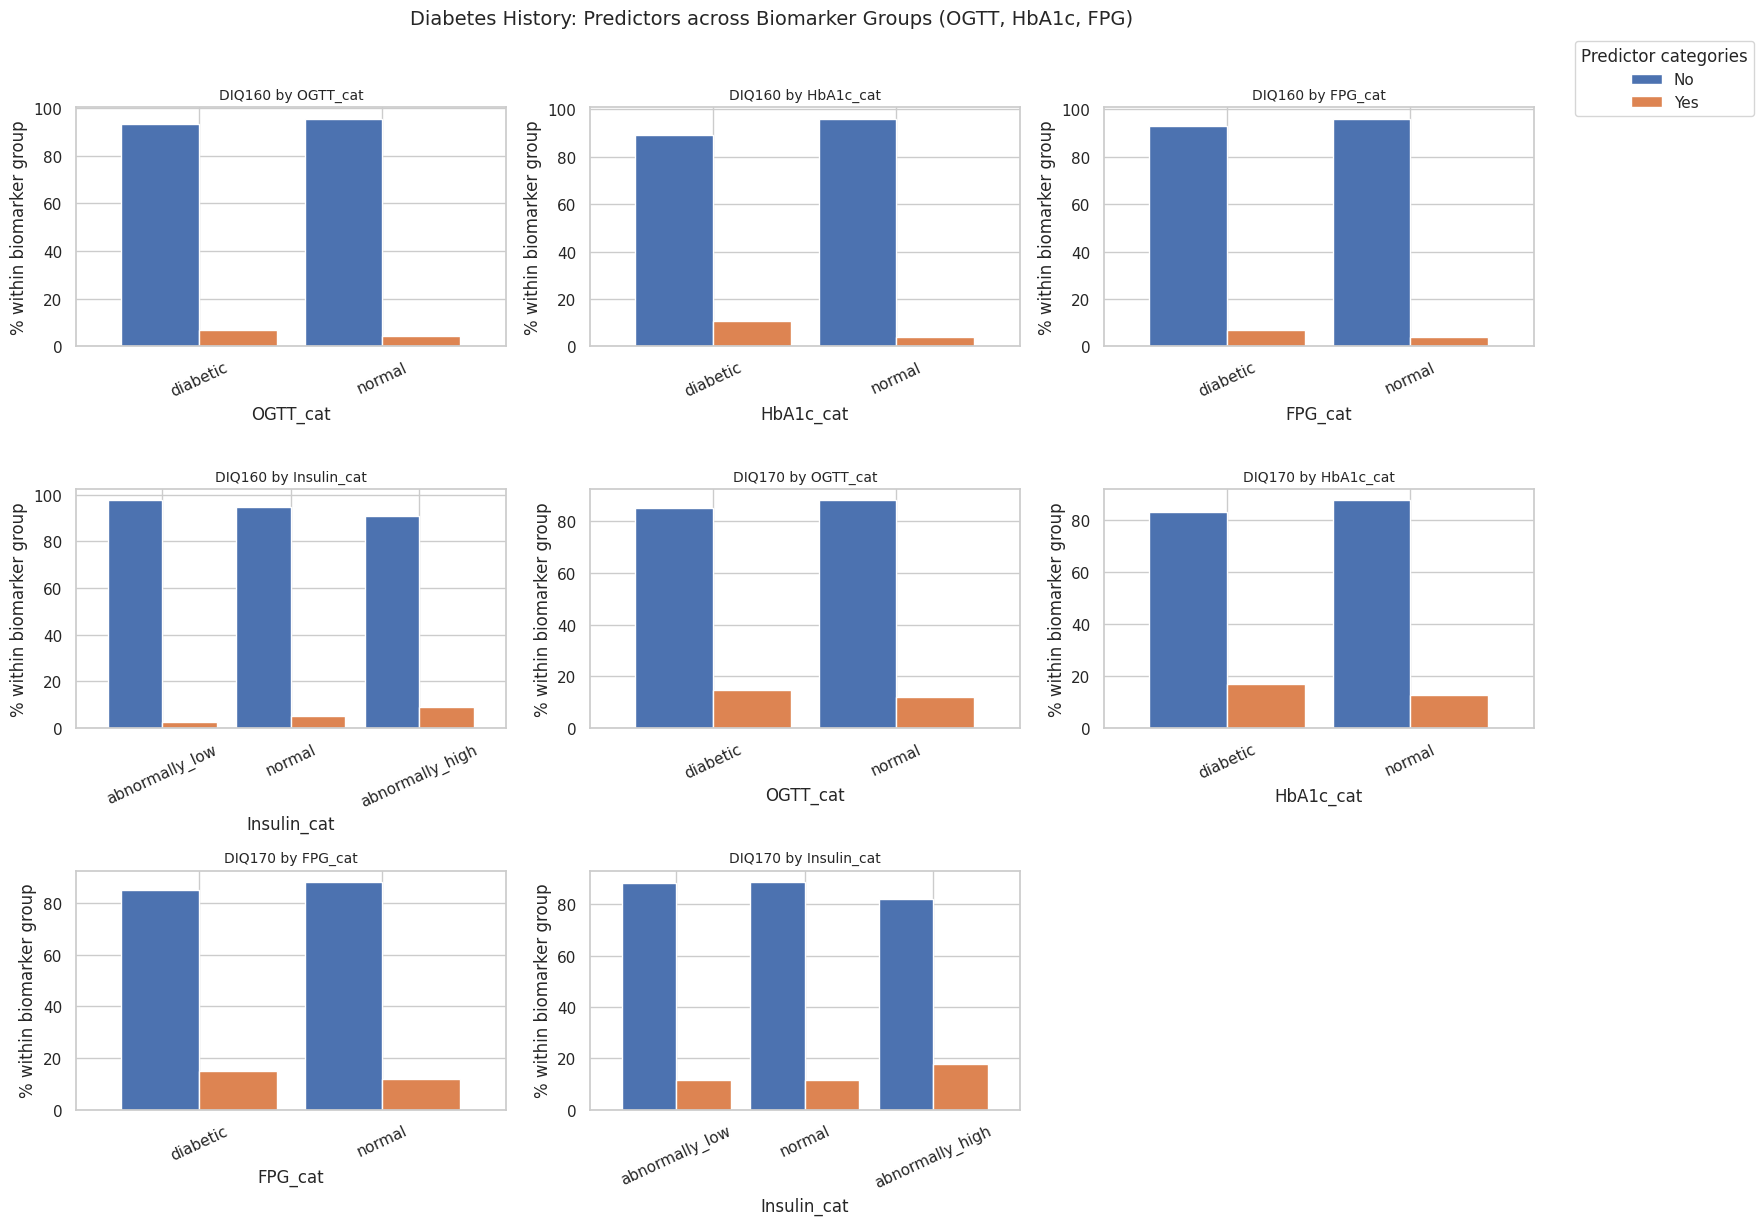

✅ Diabetes History: plotted 8 charts (2 predictors × 4 biomarkers)


In [ ]:
anthro_clinical = ["DIQ160", "DIQ170"]
plot_category_grid(df, anthro_clinical, "Diabetes History")

Prediabetes diagnosis(DIQ160) - higher proportion of prior prediabetes diagnosis fall under the diabedic group, normal HbA1c group has a majority of individuals with without prediabetes. This pattern supports the role of prediabetes being an intermediate metabolic state.

Family history of diabetes(DIQ170) - higher proportion of individuals in diabedic group report a family history of diabetes compared to those who fall under the normal HbA1c group. genetic and shared familial risk factors may contribute to the abnormal HbA1c levels.

###2.1.5 Analysis of biomarkers with depression score

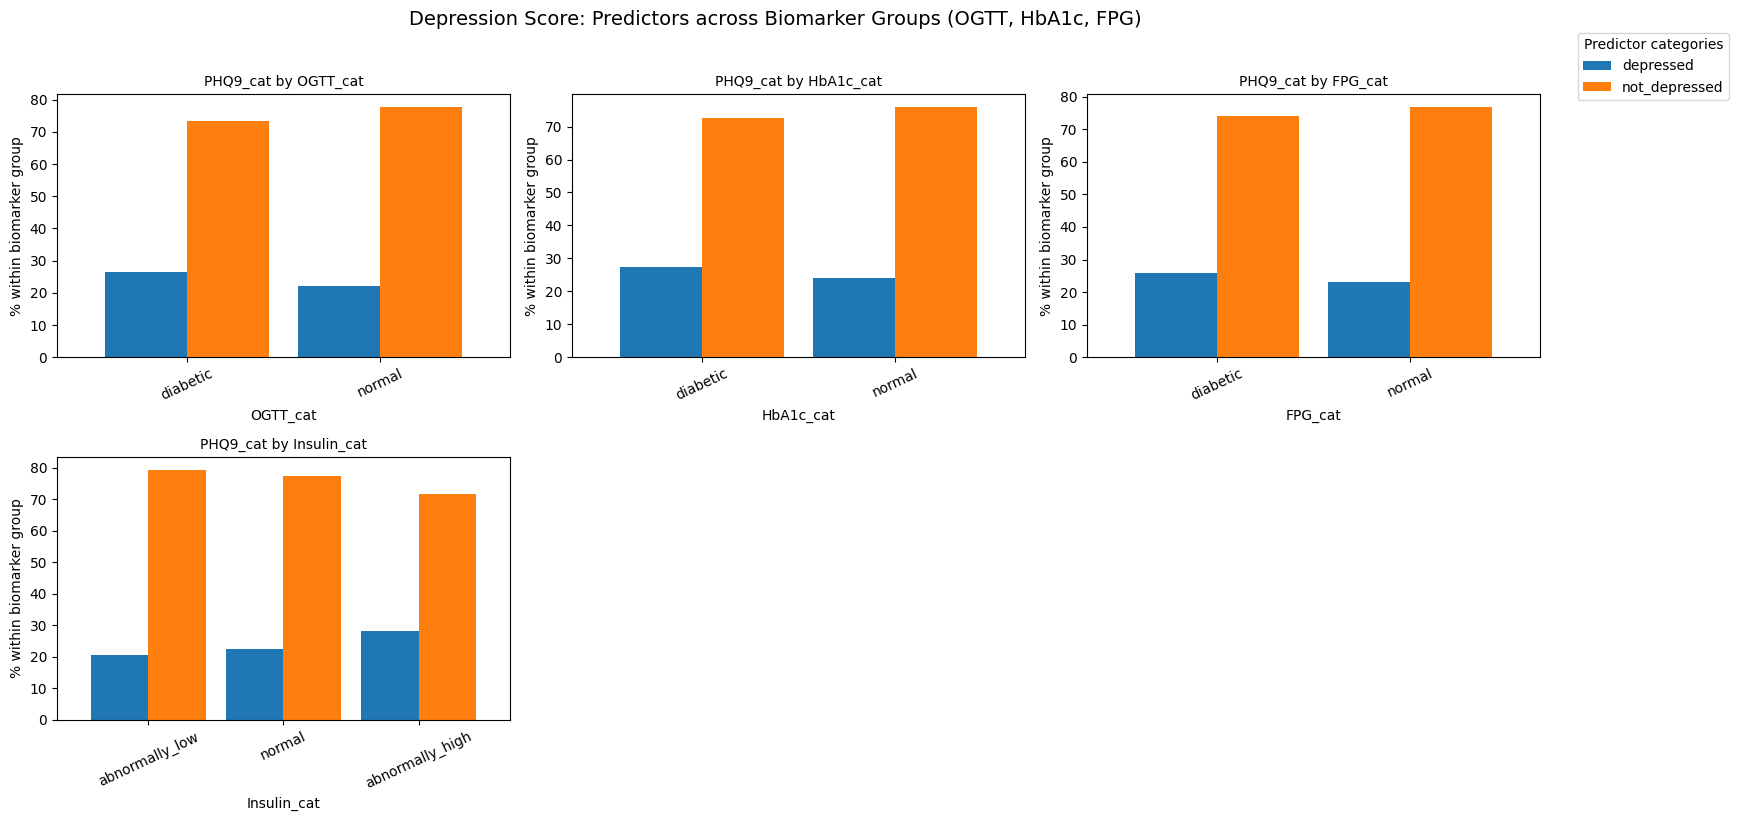

✅ Depression Score: plotted 4 charts (1 predictors × 4 biomarkers)


In [ ]:
anthro_clinical = ["PHQ9_cat"]
plot_category_grid(df, anthro_clinical, "Depression Score")

Depression status - slightly higher proportion of indivudals under the diabedic group classified as depressed compared to the normal group. Difference is nor large but there is a possible link between mental health status and glycaemic control

Unique Findings:

The strong relationship between ethnicity and abnormal biomarkers, particularly the consistently higher rates observed in Mexican Americans, highlights the need for ethnicity-specific interventions.

Sedentary behavior stands out across all biomarkers, indicating that increasing physical activity could be a universal recommendation for improving glycaemic control and insulin sensitivity.

##2.2 Heat maps

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def _proportion_table(df, row_var, col_var, normalize="index"):
    """Return (percent_table, count_table) for row_var vs col_var."""
    d = df[[row_var, col_var]].dropna()
    counts = pd.crosstab(d[row_var], d[col_var])
    perc = pd.crosstab(d[row_var], d[col_var], normalize=normalize) * 100
    return perc.round(1), counts

def plot_heatmap_set(df, pairs, set_title, normalize="index", ncols=3, figsize_per_plot=(5.2, 4.6), min_cell_count_note=True):
    """
    Plot a grid of proportion heatmaps for a list of (row_var, col_var) pairs.
    normalize="index" => row-wise % (recommended)
    """
    n = len(pairs)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_plot[0], nrows*figsize_per_plot[1]))
    axes = np.array(axes).reshape(-1)

    for i, (row_var, col_var) in enumerate(pairs):
        ax = axes[i]

        # check columns exist
        if row_var not in df.columns or col_var not in df.columns:
            ax.axis("off")
            ax.set_title(f"Missing: {row_var} or {col_var}")
            continue

        perc, counts = _proportion_table(df, row_var, col_var, normalize=normalize)

        # heatmap via imshow
        im = ax.imshow(perc.values, aspect="auto")

        # ticks & labels
        ax.set_xticks(range(len(perc.columns)))
        ax.set_xticklabels([str(c) for c in perc.columns], rotation=30, ha="right", fontsize=8)

        ax.set_yticks(range(len(perc.index)))
        ax.set_yticklabels([str(r) for r in perc.index], fontsize=8)

        ax.set_title(f"{row_var} × {col_var}", fontsize=10)

        # annotate each cell with % and counts
        for r in range(perc.shape[0]):
            for c in range(perc.shape[1]):
                p = perc.iat[r, c]
                n_cell = counts.iat[r, c]
                label = f"{p:.1f}%\n(n={n_cell})"
                ax.text(c, r, label, ha="center", va="center", fontsize=7)

        # optional: note sparse cells
        if min_cell_count_note:
            sparse_cells = (counts < 10).sum().sum()
            ax.set_xlabel(f"Row-%; sparse cells (<10): {sparse_cells}", fontsize=8)

        # colorbar per plot (lightweight)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label("%", fontsize=8)

    # turn off unused plots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(set_title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

###2.2.1 Demographics x Biomarkers

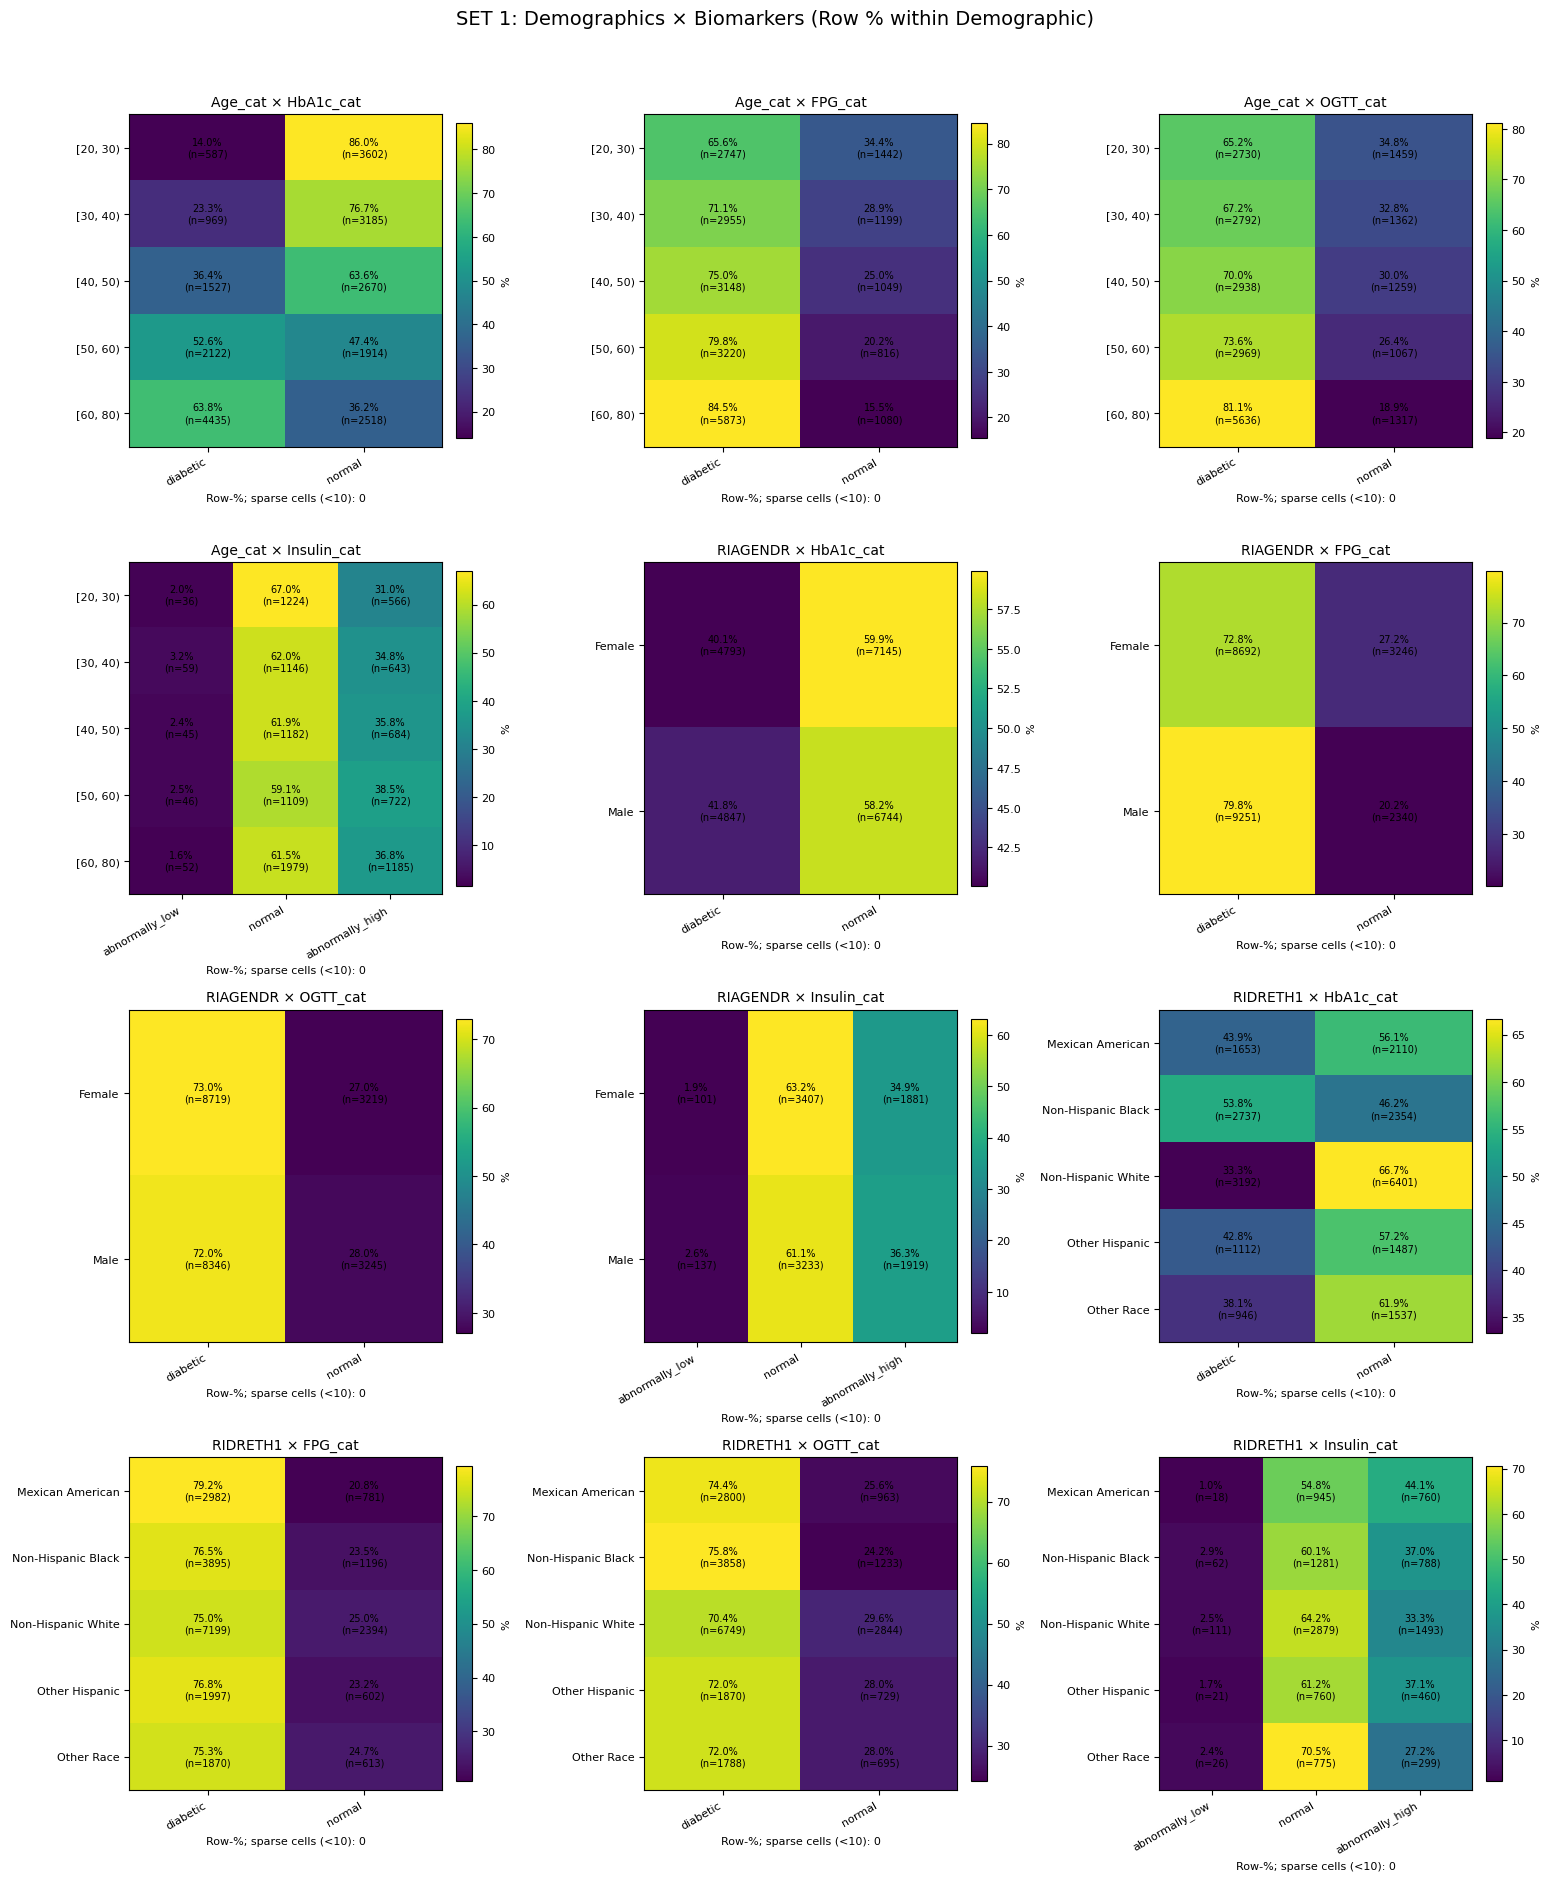

In [ ]:
set1_pairs = [
    ("Age_cat", "HbA1c_cat"),
    ("Age_cat", "FPG_cat"),
    ("Age_cat", "OGTT_cat"),
    ("Age_cat", "Insulin_cat"),
    ("RIAGENDR", "HbA1c_cat"),
    ("RIAGENDR", "FPG_cat"),
    ("RIAGENDR", "OGTT_cat"),
    ("RIAGENDR", "Insulin_cat"),
    ("RIDRETH1", "HbA1c_cat"),
    ("RIDRETH1", "FPG_cat"),
    ("RIDRETH1", "OGTT_cat"),
    ("RIDRETH1", "Insulin_cat")
]

plot_heatmap_set(df, set1_pairs, set_title="SET 1: Demographics × Biomarkers (Row % within Demographic)")

**Overall pattern**

Across all the demographic heat maps, age shows the strongest and most consistent association the abnormal biomarker levels, followed by ethnicity and the sex.

**age**

comparing the glycaemic biomarkers (HbA1c, FPG, and OGTT), demonstrates a clear progressive age gradient. Younger age groups (20 - 39) are classified as normal across all three biomarkers while the older age groups (50 - 79) have higher proportions of abnormal biomarker levels. HbA1c increases steadily with age, exceeding 60% in older age groups
For fasting insulin, its shows that it remains the most common category across all age groups, the proportion of abnormally high fasting insulin increases with age, while low insulin is rare. This shows that increasing age is associated with glycaemic dysregulation and also a shift of inulin resistance rather than deficiency across the multiple biomarkers.

**Sex**

minimal differences between males and females across all biomarkers. This shows that sex alone does not strognly diferentiate glycaemic or insulin status in this dataset

**ethnicity**

clear disparties are evident across multiple biomarkers. For HbA1c, Non-Hispanic Black individuals show the highest proportions of diabetic HbA1c (53.8%), Non-Hispanic White individuals show the highest proportion of normal HbA1c (66.7%). Mexican American and other Hispanic groups show intermediate distributions. Similar patterns but less prononounced patterns are observed for FPG and OGTT. Some ethnic groups show higher proportions of abnormally high insulin, suggesting differences in insulin regulation across ethnic categories. This shows that ethnicity might be associated with both glycaemic and insulin dynamics


*Sparcity and binning considerations*

cell counts are sufficiently large, no critically sparse categories observed. Current demographic binning is appropriate and does not rewuire re-binning prior to logistic regression or XGBoost analysis.

*Summary*

Overall, the heat maps indicate that age is the dominant demographic factor associated with abnormal glycaemic and insulin biomarkers while ethnicity shows meaningful variation, and Sex has weaker association across all biomakers. This emphasises the priority of using age and ethnicty in subsequent prevalence analyses.


###2.2.2 Lifestyle x Biomarkers

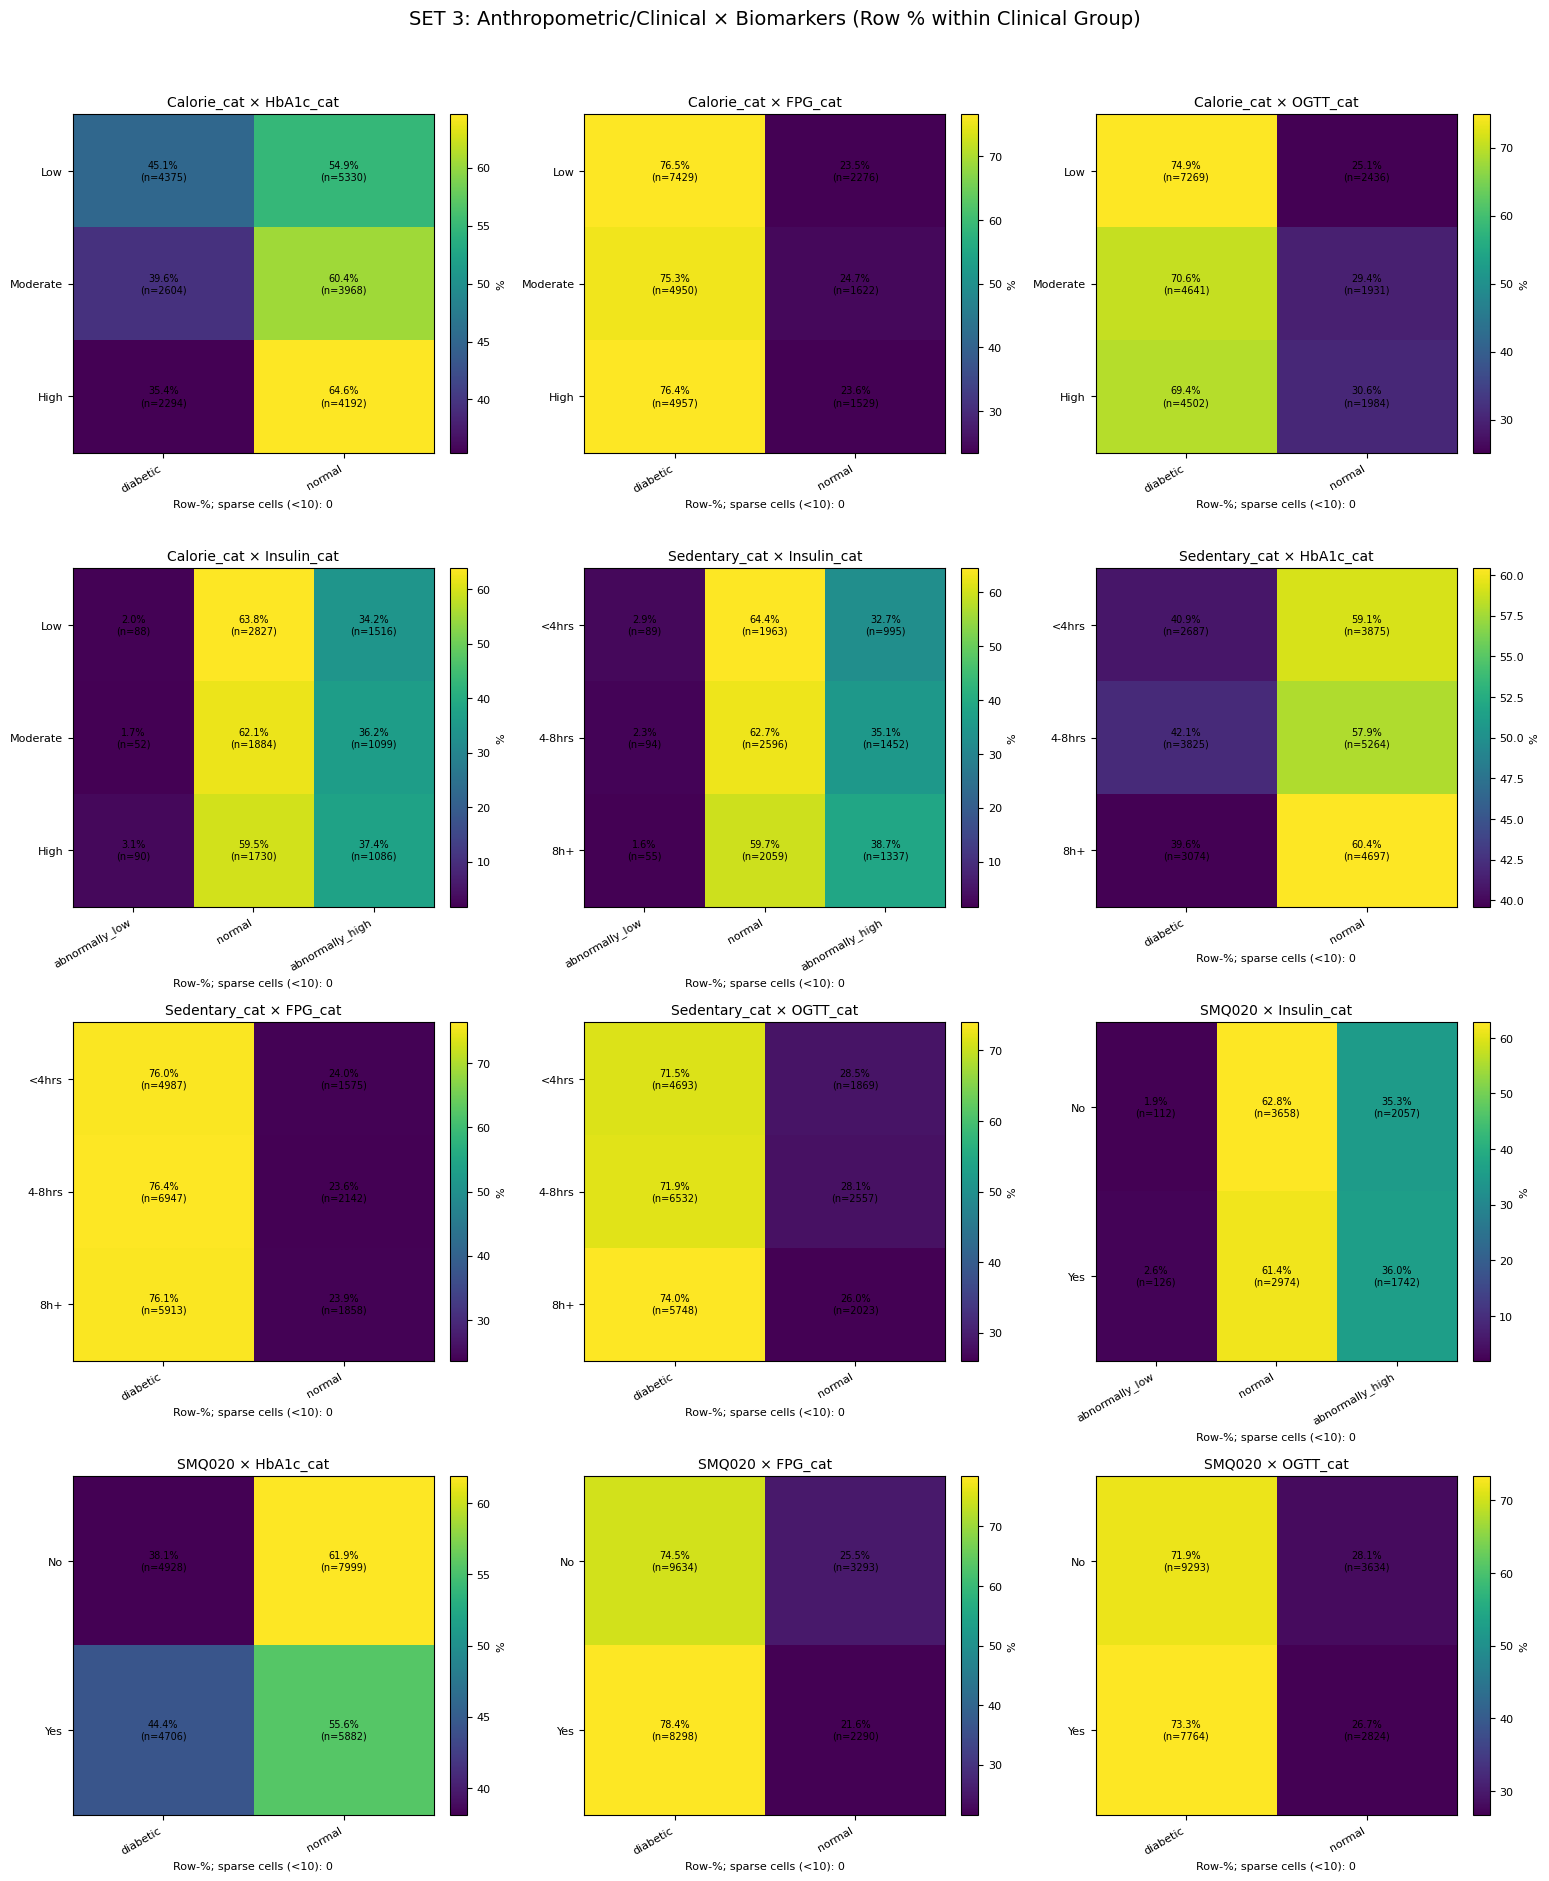

In [ ]:
set3_pairs = [
    ("Calorie_cat", "HbA1c_cat"),
    ("Calorie_cat", "FPG_cat"),
    ("Calorie_cat", "OGTT_cat"),
    ("Calorie_cat", "Insulin_cat"),
    ("Sedentary_cat", "Insulin_cat"),
    ("Sedentary_cat", "HbA1c_cat"),
    ("Sedentary_cat", "FPG_cat"),
    ("Sedentary_cat", "OGTT_cat"),
    ("SMQ020", "Insulin_cat"),
    ("SMQ020", "HbA1c_cat"),
    ("SMQ020", "FPG_cat"),
    ("SMQ020", "OGTT_cat"),
]

plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (Row % within Clinical Group)")

**Overall pattern**

Overall unfavourable anthropometric and lifestyle profiles are accociated eith higher proportions of abnormal glycaemic biomarker and fasting insulin levels. Sedentary and behaviour related predictors show clear gradients while calorie intake displays counterintuitive patterns likely reflecting behavioural modification or reporting bias.

Calorie Intake

Across HbA1c, OGTT, FPG, individuals with lower calorie intake show higher proportions of abnormal glycaemic control compared to those with moderate or high intake. For example, in the HbA1c category, 63.1% of individuals with low calorie intake show abnormal values, compared to 59.6% with moderate and 54.9% with high intake. Similarly, for FPG, 78.4% of individuals with low calorie intake are classified as diabetic, compared to 76.4% in moderate and 74.9% in high. A similar pattern is observed for fasting insulin where 62.8% of individuals with low calorie intake have abnormally high insulin, suggesting insulin resistance compared to 62.3% with moderate and 59.2% with high intake.

Sedentary Behaviour

For glycaemic and insulin biomarkers, there is a clear gradient, with individuals reporting more than or equal to 8 hours of sedentary time having higher abnormal glycaemic biomarker levels. For example, 76.4% of individuals who are sedentary for 8+ hours show abnormal HbA1c compared to 71.5% for those with 4-8 hours and 72.2% for those with < 4 hours.

Smoking Status

Smokers show consistently high proportions of abnormal biomarker levels with abnormal glycaemic biomarkers and high insulin levels.  44.8% of smokers have abnormally high insulin compared to 36.9% of non-smokers. In terms of FPG, smokers show 78.4% diabetic values compared to 74.8% for non-smokers. Although the differences are modest, the consistency across the different biomarkers supports the fact that smoking status is a contributing factor.

**Sparcity and binning considerations**

cell counts are sufficiently large, no critically sparese categories observed. Curreent demographic binning is appropriate and does not require re-binning prior to logistic regression or XGBoost analysis.



###2.2.3 Anthropometric/Clinical x Biomarkers

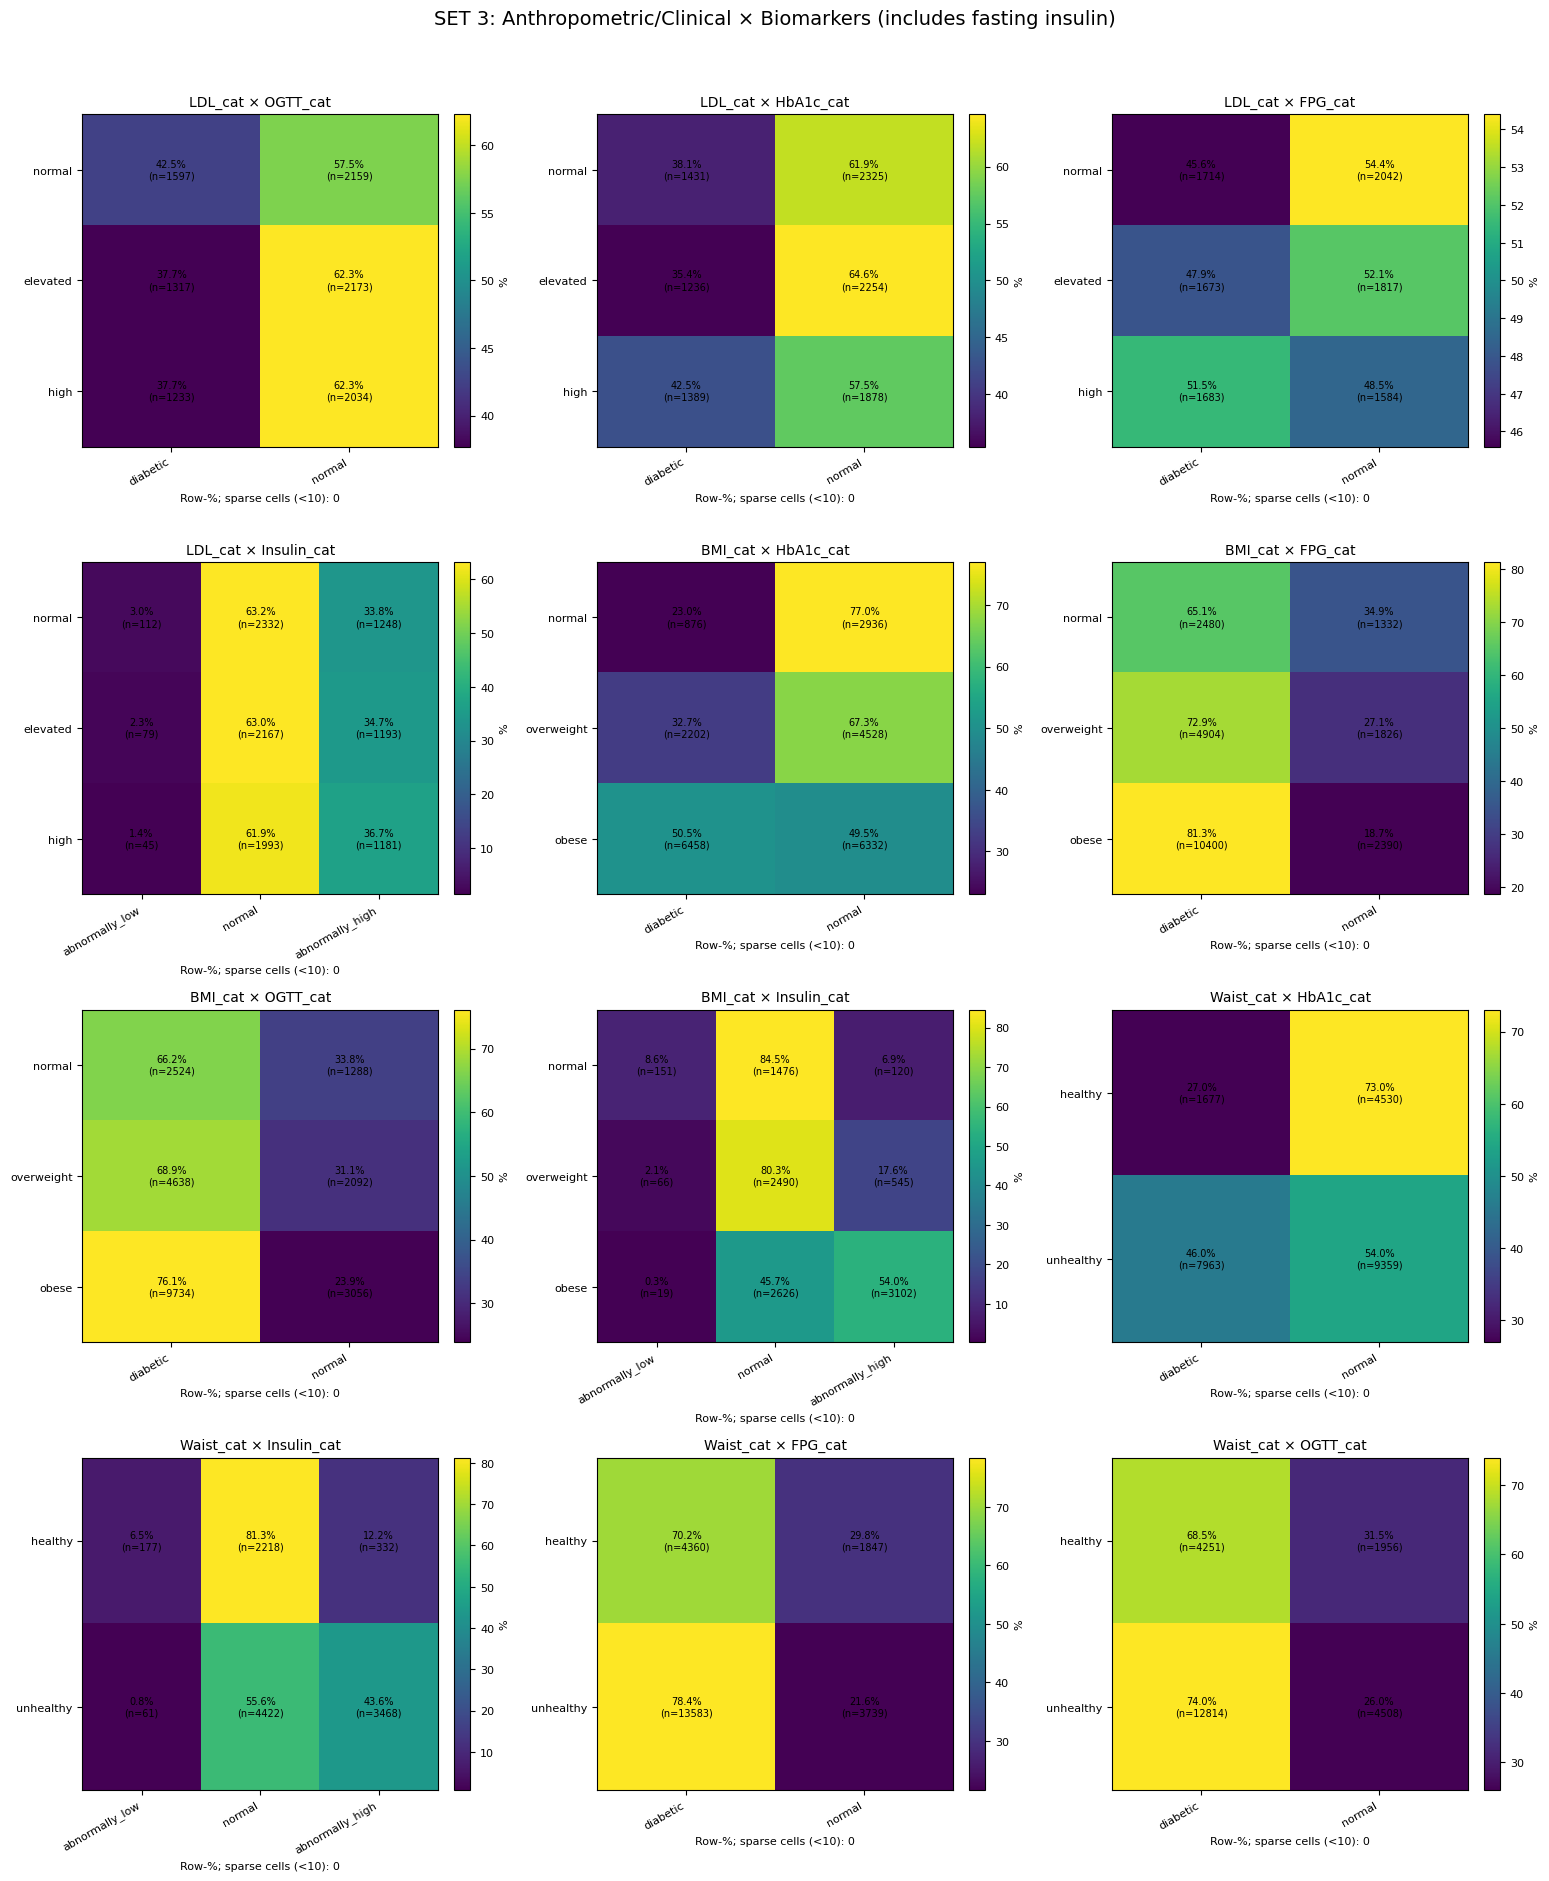

In [ ]:
set3_pairs = [
    ("LDL_cat", "OGTT_cat"),
    ("LDL_cat", "HbA1c_cat"),
    ("LDL_cat", "FPG_cat"),
    ("LDL_cat", "Insulin_cat"),
    ("BMI_cat", "HbA1c_cat"),
    ("BMI_cat", "FPG_cat"),
    ("BMI_cat", "OGTT_cat"),
    ("BMI_cat", "Insulin_cat"),
    ("Waist_cat", "HbA1c_cat"),
    ("Waist_cat", "Insulin_cat"),
    ("Waist_cat", "FPG_cat"),
    ("Waist_cat", "OGTT_cat"),
]
plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (includes fasting insulin)")


**overall pattern**

BMI and waist circumference show strong consistent associatiosn with abormal biomarker levels

**LDL x Biomarkers**

Gradients observed are modest for LDL across biomarkers.

Individuals with high LDL show slightly higher proportions of abnormal biomarker levels. 64.6% of individuals with high LDL fall under the diabetic HbA1c category, compared to 62.1% for normal LDL.
The differences in FPG and OGTT are also small, with the high LDL group showing slightly more abnormal levels compared to normal LDL.
LDL cholesterol appears to have a weaker and less direct association with glycaemic dysregulation and insulin resistance than other predictors like BMI and waist circumference. LDL may play a secondary role in metabolic dysfunction.

Body Composition (BMI and Waist Circumference) x Biomarkers

There is a strong and consistent gradient across all biomarkers when comparing BMI and waist circumference with glycaemic biomarkers.
Obese individuals show significantly higher proportions of abnormal biomarker levels. 50.5% of obese individuals are classified as diabetic HbA1c compared to only 23.0% of those with normal BMI.

Similarly, waist circumference shows a marked difference. Unhealthy waist circumference groups have a much higher prevalence of abnormal biomarkers, with 46.0% of individuals with unhealthy waist circumference classified as diabetic HbA1c compared to 27.0% for those with a healthy waist circumference.

Insulin heat maps shift towards insulin resistance as body composition increases. Abnormally low insulin levels appear rarely.

Adiposity is closely associated with glycaemic impairment and insulin resistance, making BMI and waist circumference key variables in understanding metabolic health.

**sparsity and binning considerations**

Cell counts are generally adequate across BMI, waist circumference, and LDL categories, with minimal sparsity. Although abnormally low fasting insulin appears as a rare category across predictors, this group was not re-binned or excluded, as low fasting insulin may reflect insulin deficiency (type 1 diabetes), which should not be hidden through category merging. Instead of re-binning, potential class imbalance  from this rare category,it will be addressed during modelling through techniques such as SMOTE or other resampling approaches for logistic regression or XGBoost analyses, to improve model stability while having clinically meaningful distinctions.

###2.2.4 Diabetes History x Biomarkers

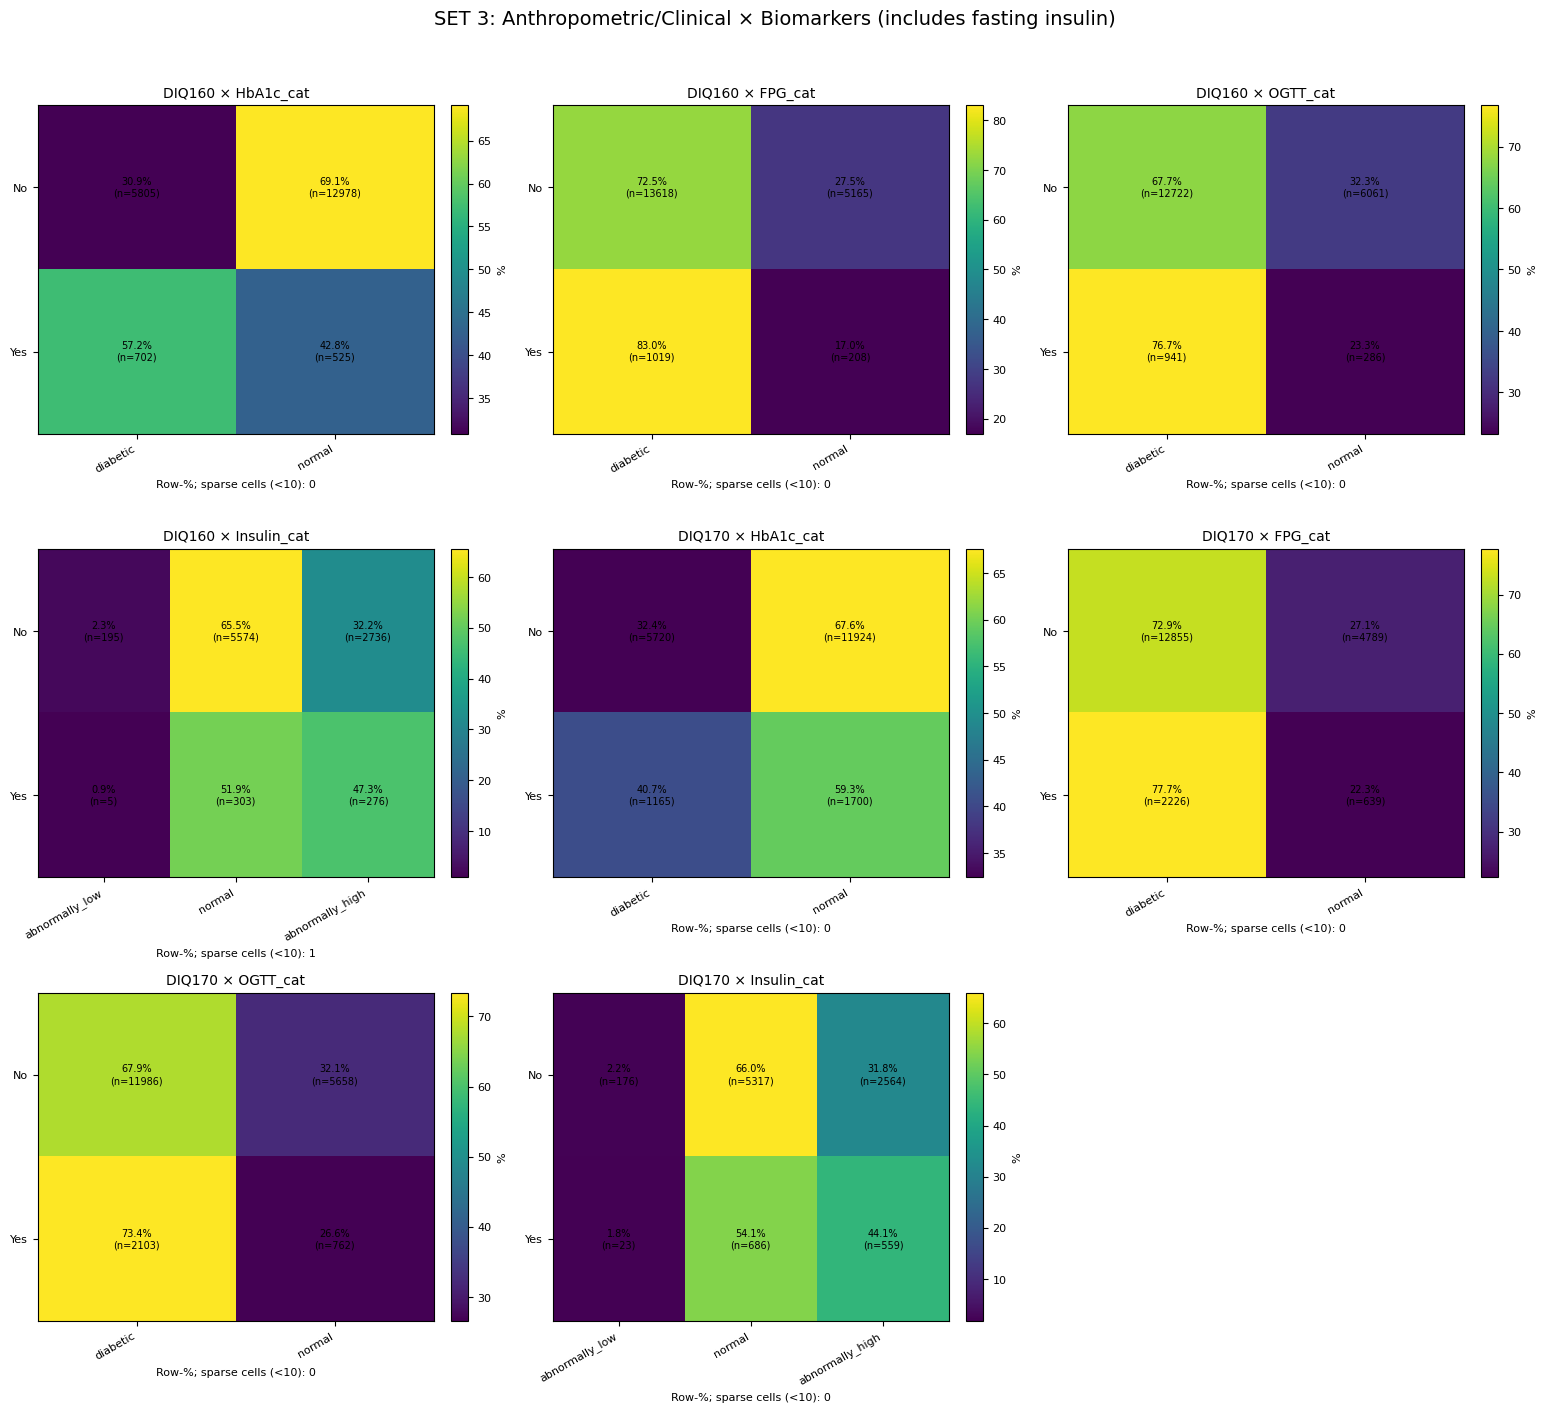

In [ ]:
set3_pairs = [
    ("DIQ160", "HbA1c_cat"),
    ("DIQ160", "FPG_cat"),
    ("DIQ160", "OGTT_cat"),
    ("DIQ160", "Insulin_cat"),
    ("DIQ170", "HbA1c_cat"),
    ("DIQ170", "FPG_cat"),
    ("DIQ170", "OGTT_cat"),
    ("DIQ170", "Insulin_cat"),
]
plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (includes fasting insulin)")

**Overall analysis**

prediabetes diagnosis shows strong and consistent association with abnormal glycaemic biomarkers and insulin resistance while family history of diabetes demonstrates a moderate but consistent pattern across the biomarkers.

**Prediabetes diagnosis x biomarkers** DIQ160

all individuals with prediabetes diagnosis show higher proportions of abnormal glycaemic biomarker levels (more than 50%). this pattern also extend to fasting insulin where the prediabetes group show higher proportions of abnormally high insulin levels (47.3%), indicating insulin resistance. abnormally low insulin remains rare in both groups. This supports prediabetes dignosis as a strong clinical indicator of metabolic dysregulation

**Family History of diabetes** DIQ170

individuals with a family history of diabetes show higher proportions of abnormal glycaemic biomarkers. but the differences are less noticiable compared to those observed prediabetes disgnosis. Similar pattern for fasting insulin, higher proportion of abnormally high insulin (44.1%) among those positive diabetes family history.



**Sparcity and binning considerations**

cell counts are adequte across both predictor heat maps, with minimal sparcity. Abnormally low fasting insuline remains a rare category but re-binning is not required due to reasoning from previous section.

###2.2.5 Socioeconimic status x Biomarkers

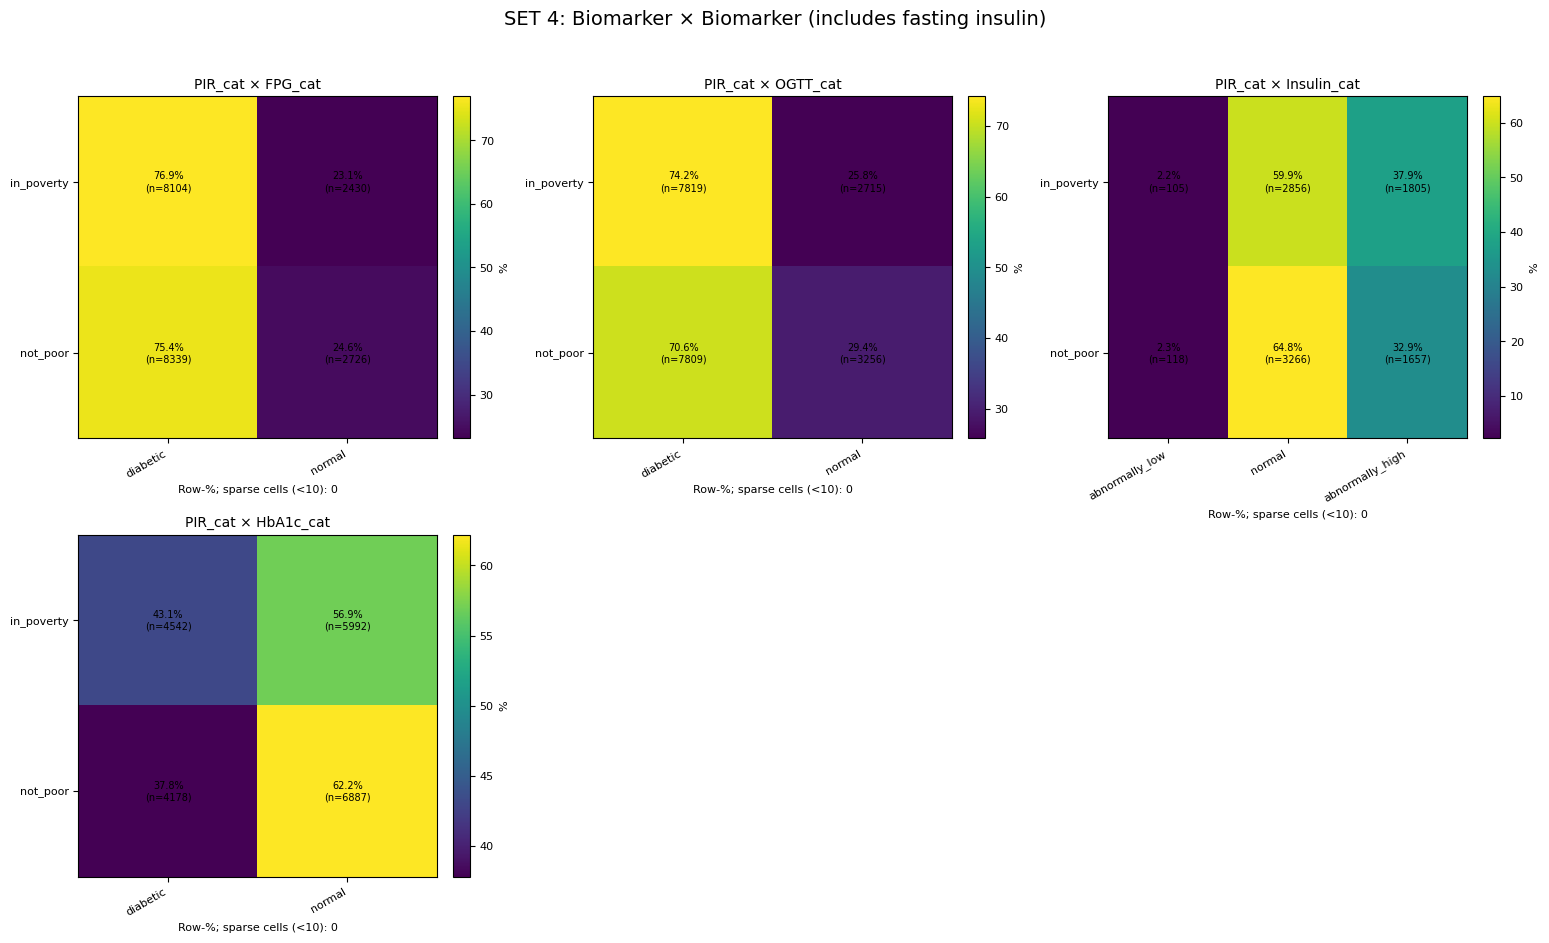

In [ ]:
set4_pairs = [
    ("PIR_cat", "FPG_cat"),
    ("PIR_cat", "OGTT_cat"),
    ("PIR_cat", "Insulin_cat"),
    ("PIR_cat", "HbA1c_cat"),
]
plot_heatmap_set(df, set4_pairs, set_title="SET 4: Biomarker × Biomarker (includes fasting insulin)")


**Poverty-to-income ratio**

overall, it shows a modest but consistent association with the biomarkers. Differences are relatively small (around 2-5%) but individuals classified as in poverty exhibit slightly higher proportions of abnormal glycaemic marker levels compared to those not in poverty. clearer pattern for fasting insulin observed with individuals in poverty having abnormally higher insulin resistance (37.9%)
these findings indicate that the socio ecomonic disadvantage may be more strongly associated with insulin resistance than with the glycaemic biomarkers. PIR is a relevant predictor.


###2.2.6 Depression score x Biomarkers

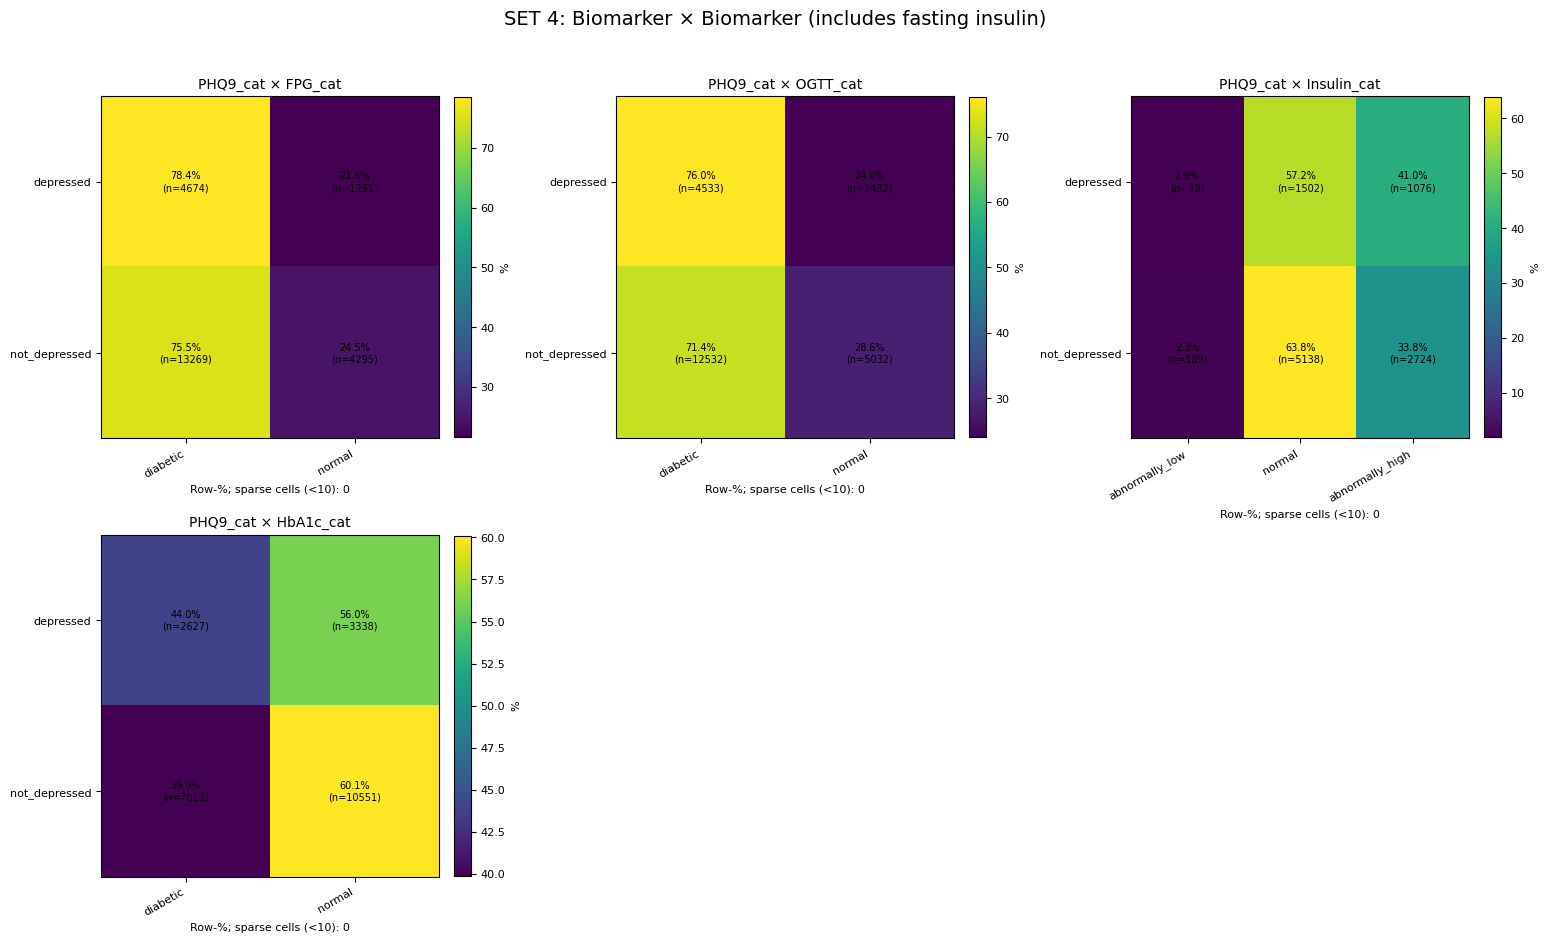

In [ ]:
set4_pairs = [
    ("PHQ9_cat", "FPG_cat"),
    ("PHQ9_cat", "OGTT_cat"),
    ("PHQ9_cat", "Insulin_cat"),
    ("PHQ9_cat", "HbA1c_cat"),
]
plot_heatmap_set(df, set4_pairs, set_title="SET 4: Biomarker × Biomarker (includes fasting insulin)")


**Depression Score**

individuals classfied as depressed show slightly higher proportions of abnormal glycaemic biomarkers (with a difference of around 3% each) compared to those not depressed. a clearer pattern observed for fasting insulin, where depressed group show a higher proportions of abnormally high insulin(41.0%), showing greater insulin resistance.
This depressive sypmtoms are more strongly associated with insulin resistance than the overal glycaemic abnormalities. supporting the inclusion of mental health status as a potential predictor in subsequent analyses

Overall Unique Finding:

 *  Interestingly, individuals with lower caloric intake have a higher prevalence of abnormal biomarkers, particularly HbA1c (45.1% in low calorie intake). This might reflect poor diet quality, where low caloric intake could be due to restrictive dietary patterns that contribute to impaired glucose metabolism and insulin resistance. This finding could indicate metabolic stress in individuals with insufficient nutrient intake.
*  HbA1c shows unique patterns compared to other biomarkers, as it reflects long-term glycaemic control and tends to be less sensitive to immediate changes. While predictors like age, ethnicity, and prediabetes history strongly influence FPG and OGTT, their effects on HbA1c are more stable.
ethnic disparities and age-related increases in abnormal biomarkers are more evident in FPG and OGTT than in HbA1c, which might suggest that HbA1c provides a more consistent view of diabetes risk over time, while other biomarkers capture a more immediate metabolic fluctuations.

This could point to the need for focusing on other biomarkers to detect early-stage metabolic dysfunction, while HbA1c provides a broader view of chronic diabetes risk.


##2.3 Prevalance bar charts

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency

# Function to prepare binary outcome (Abnormal/Normal) for plotting
def _prep_bin_outcome(df, outcome_col, abnormal_labels, normal_labels=None, dropna=True):
    d = df.copy()
    if dropna:
        d = d.dropna(subset=[outcome_col])

    # abnormal set
    if isinstance(abnormal_labels, (str, int, float)):
        abnormal_set = {abnormal_labels}
    else:
        abnormal_set = set(abnormal_labels)

    if normal_labels is not None:
        if isinstance(normal_labels, (str, int, float)):
            normal_set = {normal_labels}
        else:
            normal_set = set(normal_labels)
        d = d[d[outcome_col].isin(abnormal_set.union(normal_set))].copy()

    d["Outcome_bin"] = np.where(d[outcome_col].isin(abnormal_set), "Abnormal", "Normal")
    return d

# Function to calculate prevalence and Chi-square statistics
def _prevalence_table_and_chi2(d, predictor_col):
    dd = d.dropna(subset=[predictor_col, "Outcome_bin"])
    ct = pd.crosstab(dd[predictor_col], dd["Outcome_bin"])

    # ensure cols exist
    if "Abnormal" not in ct.columns:
        ct["Abnormal"] = 0
    if "Normal" not in ct.columns:
        ct["Normal"] = 0

    ct = ct[["Abnormal", "Normal"]]
    ct["Total"] = ct["Abnormal"] + ct["Normal"]
    ct["Prevalence_%"] = (ct["Abnormal"] / ct["Total"] * 100).round(1)

    # chi-square
    chi2_table = pd.crosstab(dd[predictor_col], dd["Outcome_bin"])
    if chi2_table.shape[1] < 2:
        chi2, p, dof = np.nan, np.nan, np.nan
    else:
        chi2, p, dof, _ = chi2_contingency(chi2_table)

    return ct, p

# Main function to generate prevalence bar charts for each predictor
def plot_prevalence_group_one_shot(
    df,
    outcome_col: str,
    abnormal_labels,
    predictor_list,
    group_title: str,
    normal_labels=None,
    ncols=3,
    dropna=True,
    min_count_per_group=0,
    figsize_per_plot=(5.2, 4.2)
):
    """
    ONE big figure: multiple prevalence bar charts (one per predictor) for ONE outcome.
    """
    # Prepare binary outcome once
    d = _prep_bin_outcome(df, outcome_col, abnormal_labels, normal_labels=normal_labels, dropna=dropna)

    n = len(predictor_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_plot[0], nrows*figsize_per_plot[1]))
    axes = np.array(axes).reshape(-1)

    for i, pred in enumerate(predictor_list):
        ax = axes[i]

        if pred not in df.columns:
            ax.axis("off")
            ax.set_title(f"Missing: {pred}")
            continue

        dd = d.dropna(subset=[pred]).copy()

        # optionally remove sparse predictor groups
        if min_count_per_group > 0:
            vc = dd[pred].value_counts()
            keep = vc[vc >= min_count_per_group].index
            dd = dd[dd[pred].isin(keep)].copy()

        ct, p = _prevalence_table_and_chi2(dd, pred)

        x = ct.index.astype(str)
        y = ct["Prevalence_%"].values
        bars = ax.bar(x, y)

        for j, b in enumerate(bars):
            n_abn = int(ct["Abnormal"].iloc[j])
            n_tot = int(ct["Total"].iloc[j])
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height() + 0.8,
                f"{y[j]:.1f}%\n(n={n_abn}/{n_tot})",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_ylabel("% abnormal")
        ax.set_xlabel(pred)
        ax.tick_params(axis="x", labelrotation=25)

        p_txt = "p=NA" if (p is None or np.isnan(p)) else f"p={p:.3g}"
        ax.set_title(f"{pred} → {outcome_col}\nχ² {p_txt}", fontsize=10)

        if len(y) > 0:
            ax.set_ylim(0, min(100, max(y) + 15))

    for k in range(n, len(axes)):
        axes[k].axis("off")

    if isinstance(abnormal_labels, (str, int, float)):
        abn_desc = str(abnormal_labels)
    else:
        abn_desc = ", ".join([str(x) for x in abnormal_labels])

    fig.suptitle(f"{group_title}\nOutcome: {outcome_col} | Abnormal = {abn_desc}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

###2.3.1 Demographic x biomarkers

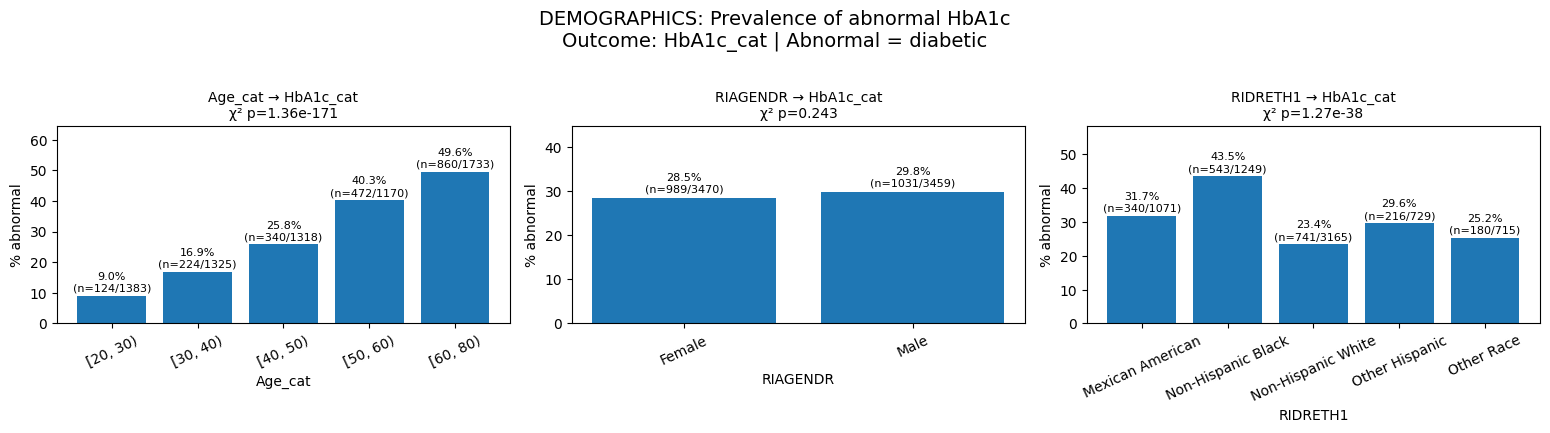

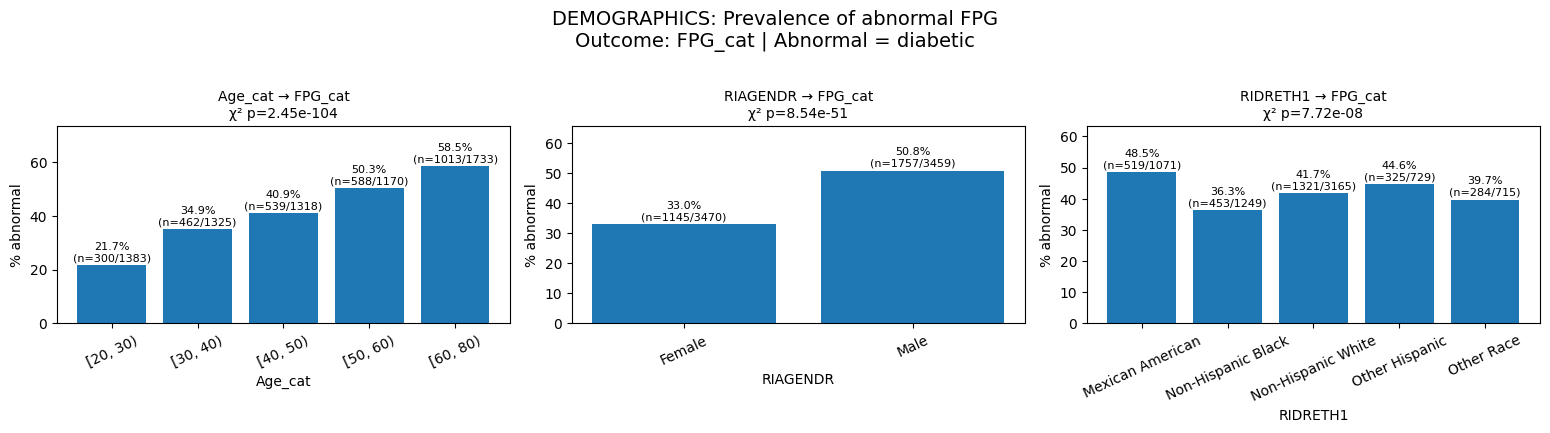

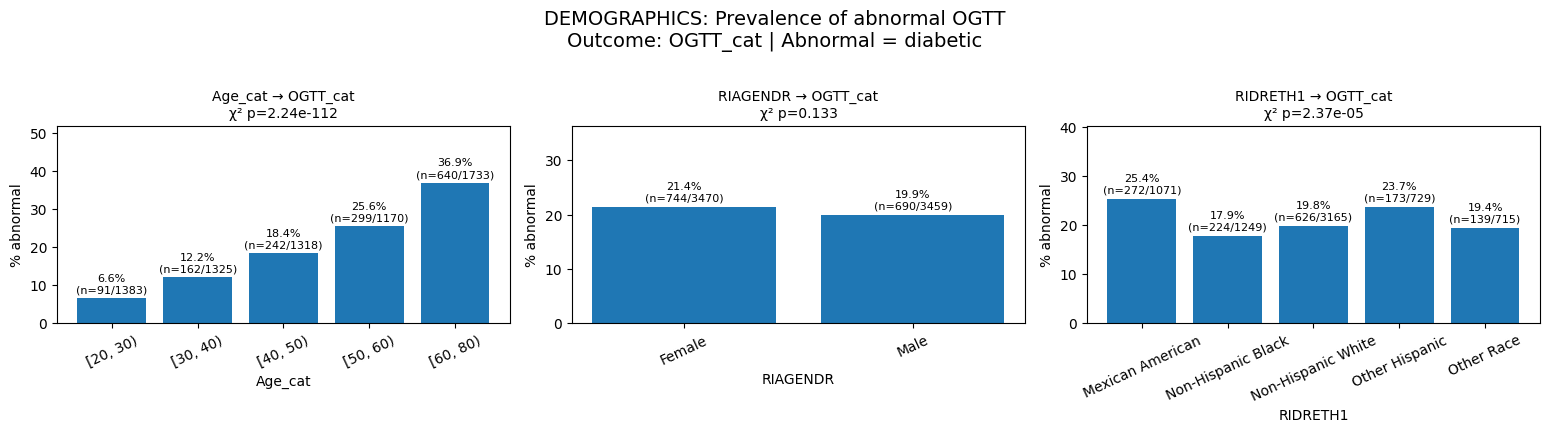

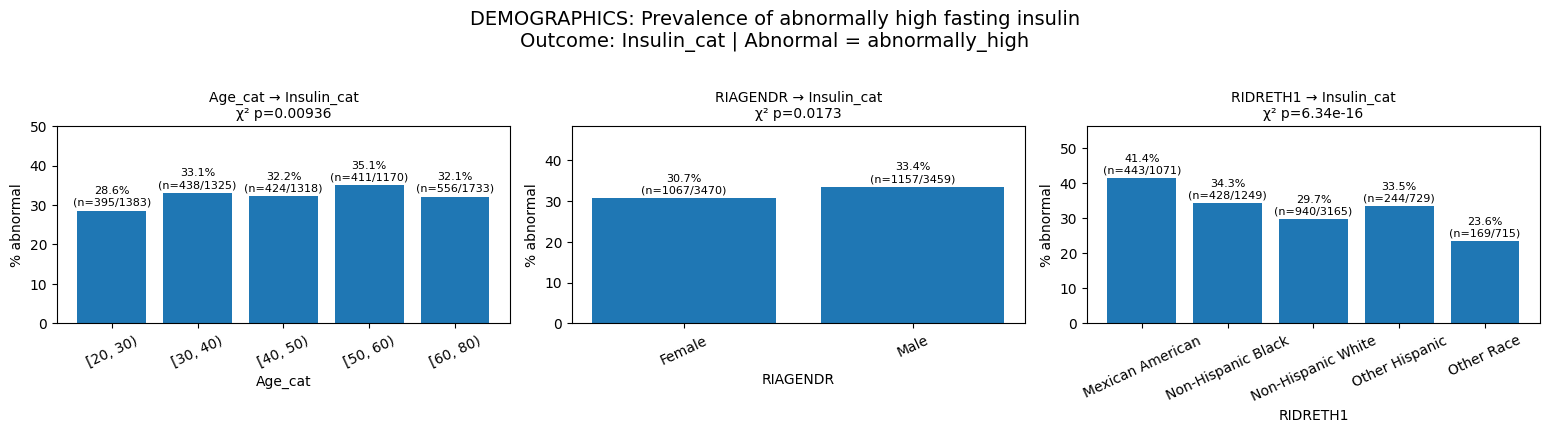

In [ ]:
# DEMOGRAPHICS GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormally high fasting insulin"
)

**age and biomarkers**

X^2 test significance:
all p values for the association between age and all the biomarker are highly significant as the p-values below the significance level (alpha=0.05) showing strong association between age and the prevalence of abnormal biomarkers.


*   younger adults(20-29) the show the lowest prevalence(14.0% for HbA1c) while older adults (60-80) show higher prevalence (63.8% for HbA1c, 84.5% for FPG, and 81.1% for OGTT)
*   for insulin, prevalence of abnormally high insulin also increases with age, peaking at 36.8% in the 60-80 age group

Age is a strong predictor of impaired glucose regulation. older adults being more liekly to have abnormal glucose metabolism(diabetic) and insulin resistance. These trends suggest that age plays a key role in diabetes development, older indidviduals at higher risk.

**gender and biomarkers**

X^2 test significance: p valhes for the association between gender and biomarkers are statistically significant as the p-values are below the significance level (alpha=0.05), showing that gender plays a role in the likelihood of having abnormal biomarker levels


*   males generally show higher prevalence of abnormal FPG and insulin resistance than females
*   For HbA1c, the difference between male and female is smaller with a difference of 1.7%
*   females show slightly higher prevalence of abnormaol OGTT comapared to males

Males tend to have higher insulin resistance and abnormal FPG while females show slightly higher rates of abnormal OGTT suggesting possible gender-specific factors such as insulin sensitivity or hormonal differences which contirbute to diabetes risk.


**ethnicity and biomarkers**

X^2 test significance:
the p values for the associaton between ethnicity and biomarkers are highly significant as the p-vlaues are below the significance level (alpha=0.05) showing ethnicity is a significant factor for influencing prevalence of abnormal biomarkers


*   mexican americans consistently show highest prevalence across all biomarkers.

the higher prevalence of abnormal biomarkers in mexican americans suggests that ethnicity is crucial in understanding the risk of diabetes. this could be due to varies factors including access to care and social determinants of health.




###2.3.2 Lifestyle x biomarkers

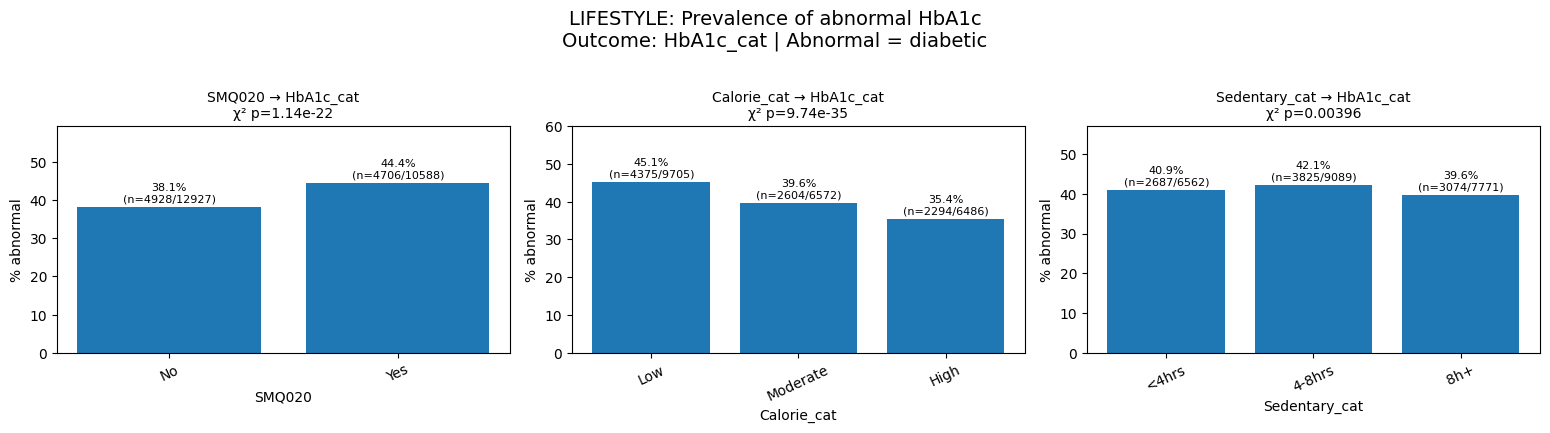

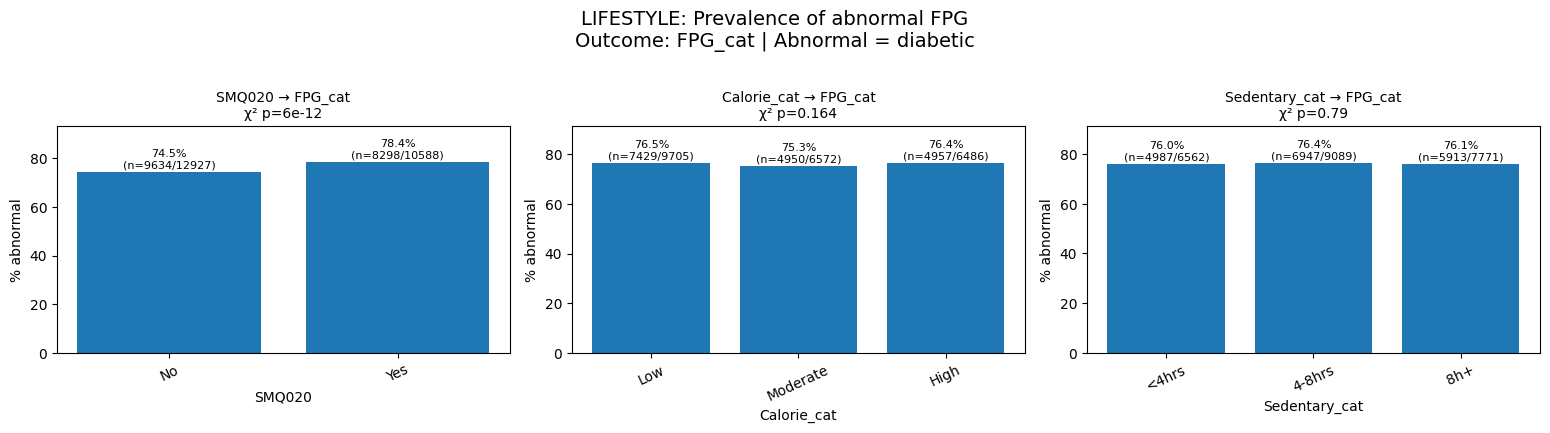

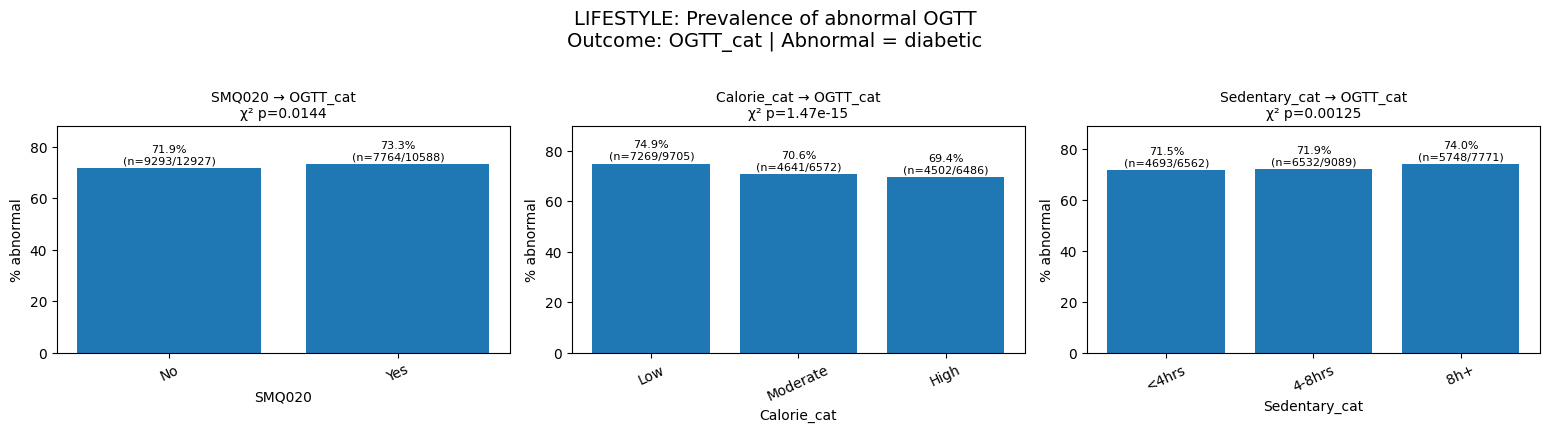

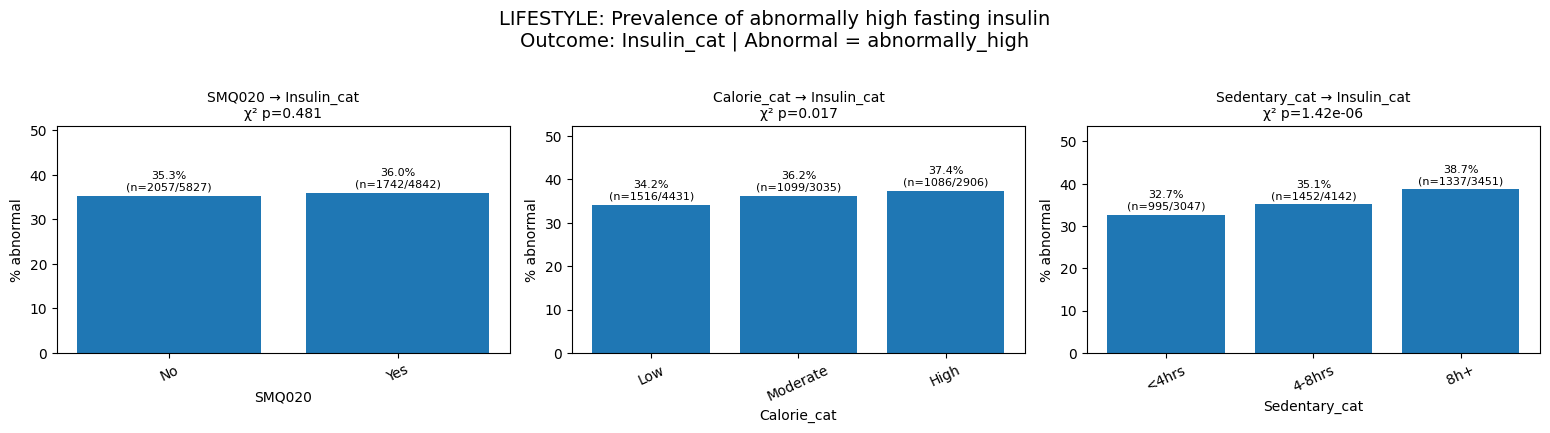

In [ ]:
# LIFESTYLE GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormally high fasting insulin"
)

**smoking status x biomarkers**

X^2 significance test: all p values for the association between smoking status and all the biomarker are highly significant as all p-vlaues are below 0.05 showing strong association between them age and the prevalence of abnormal biomarkers.

*   smokers show a higher prevalence of abnormal HbA1c(44.4%), FPG(78.4%) and OGTT(73.3%) compared to non-smokers
*   prevalence of abnormally high fasting insulin(35.3%) is similar between smokers and non-smokers(36.0%)

smoking status is associated with poorer glycemic control but shows no clear assocation with fasting insulin suggesting that smoking is more strognly linked to glucos dysregulation than insulin resistance.

**calorie intake x biomarkers**

X^2 significance test:

test indicate statisticaly significant assocations between caloric intake and HbA1c, OGTT and fasting insuline (p < 0.05) but association between calorie intake and FPG is not  statistically significant (p > 0.05)


*   low calorie intake show the highest prevalence of abnormal HbA1c and OGTT levels (45.1% and 74.9% respectively)
*   abnormal FGP prevalence is similar across all caloric intake groups (no significant association)75-78%
*   abnormally high fasting insulin prevalence increases with calorie intake from 34.2% to 37.4%

higher caloric intake is associated with increased insuline resistance, lower caloric intake is assocaited with higher prevalence of abnormal HbA1c and OGTT which might possibly be due to diet quality or metabolic status.

**sedentary behaviour x biomarkers**

X^2 significance test:
test indicates statistically significant assocati9ons between sedentary behaviour and HbA1c, OGTT and fasting insulin (p < 0.05) but the association between sedentary behavious and FPG is not statistically significant (p > 0.05).

*   Abnormal OGTT (74.0%) and HbA1c(42.1%) prevalence is the highest among those sedentary for ≥8 hours/day comapred to those sedendary for <4 hours/day(71.5% for OGTT and 40.9% for HbA1c)
*   Abnormal FPG remains relatively constant across sedentary categories (75-76%)
*   abnormally high insulin prevalence increases with sedenatry time (32.7% to 38.7%)

greater sedentary behaviour is associated with higher prevalence of impaired glucose (OGTT) and insulin resistance (fasting insulin). Sedentary behaviour may have stronger association with post-prandial glucose regulations and insulin sensitivity than with fasting glucose alone.

**overall insight**
Lifestyle factors show distinct and biomarker-specific associations with metabolic outcomes. These findings support the inclusion of lifestyle predictors in following multivariable analyses while reinforcing that the observed relationships represent associations rather than causation





###2.3.3 Anthropometric/Clinical x biomarkers

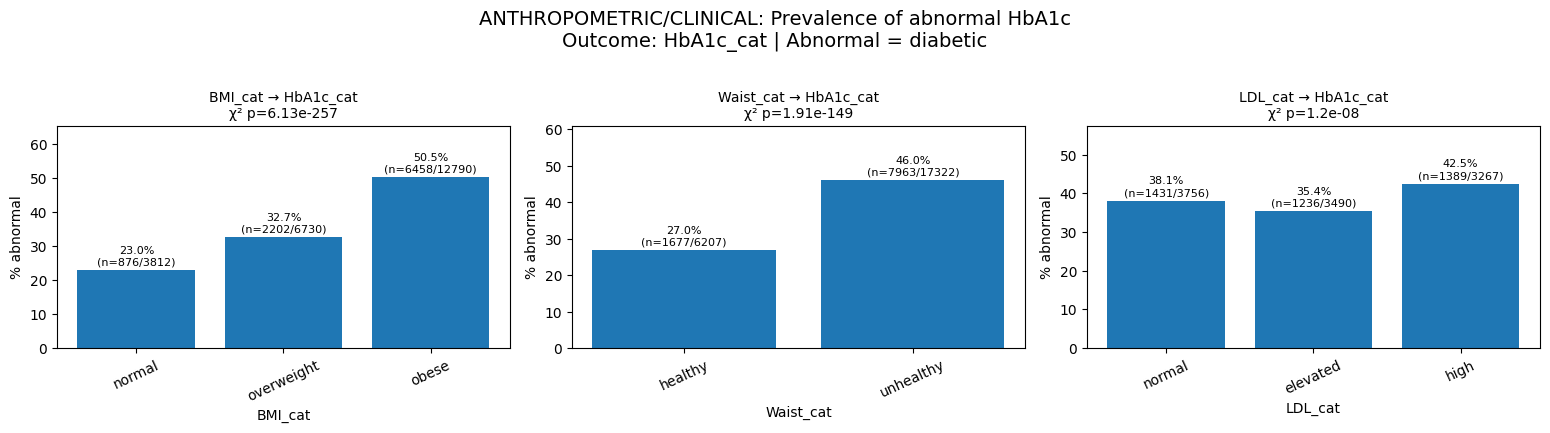

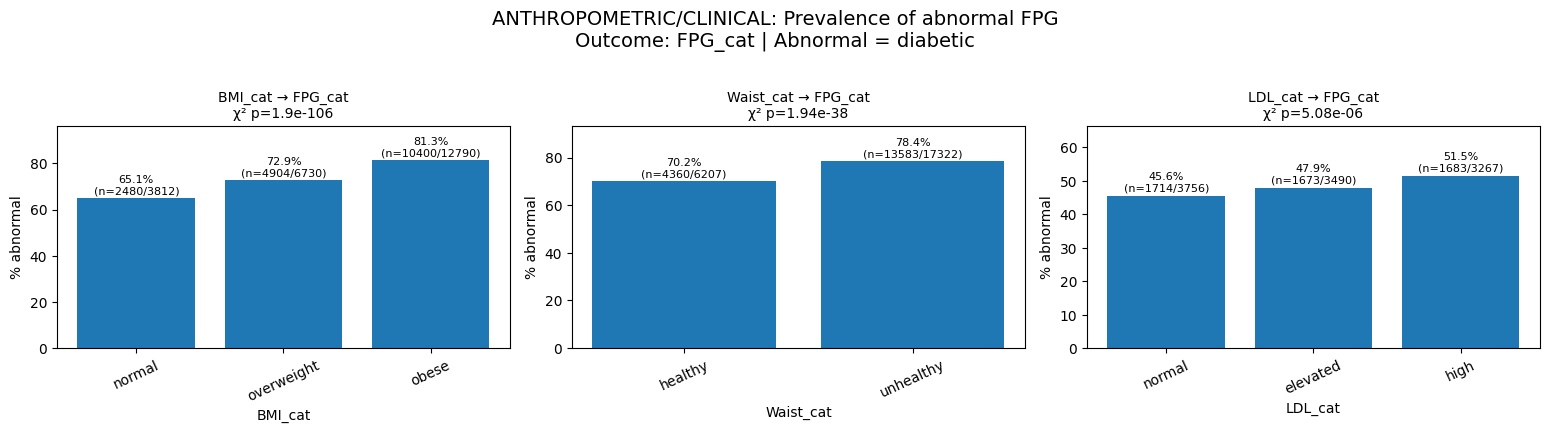

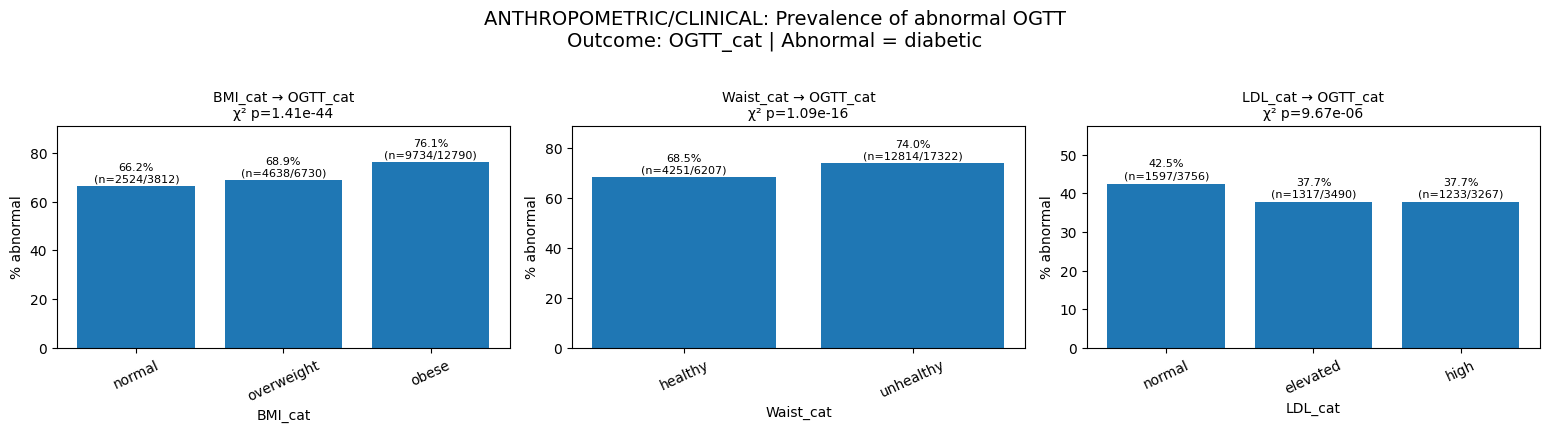

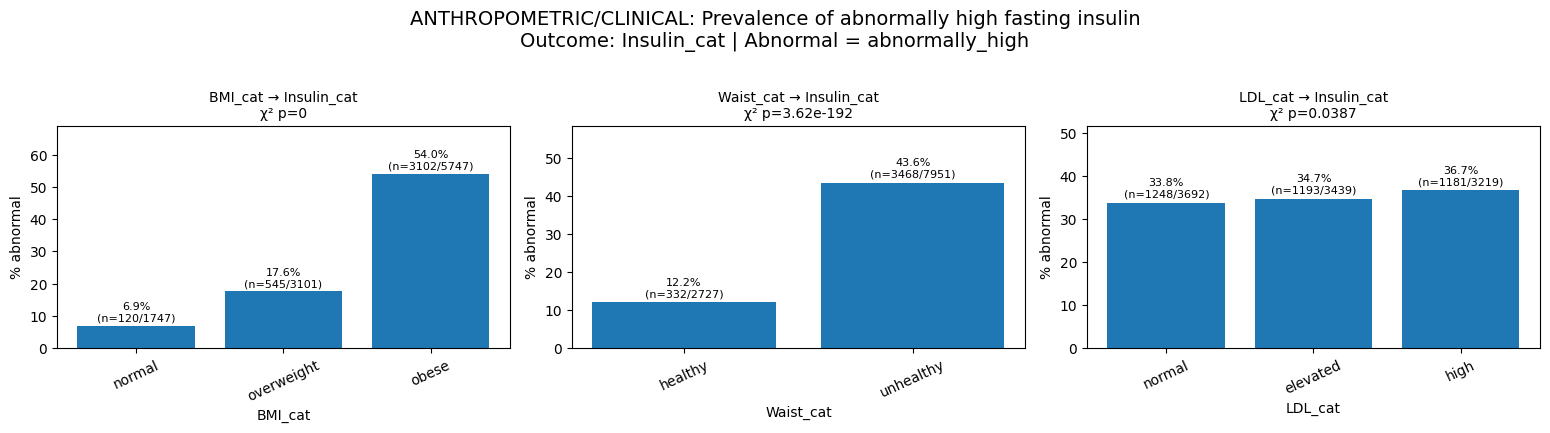

In [ ]:
# ANTHROPOMETRIC/CLINICAL GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormally high fasting insulin"
)

**BMI x Biomarkers**

X^2 test significance:
the tests how strong statistical significance for BMI with all biomarkers (p < 0.05) indicating a clear association between BMI and abnormal metabolic outcomes.

*  Across BMI categories, the prevalence of abnormal biomarkers increases progressively, with abnormal HbA1c rising from 23.0% (normal) to 32.7% (overweight) and 50.5% (obese),
*  abnormal FPG increasing from 65.1% to 72.9% and 81.3%,
*  and abnormal OGTT rising from 66.2% to 68.9% and 76.1%, respectively   
*   fasting insuline showed the strongest gradient, increasing from 6.9%(normal) to 17.6%(overweight) and 54.0%(obese)

Higher BMI shows strong associations with worsening glycaemic control and insulin resistance but with more obvious differences for fasting insuline, suggesting that obesity is closely linked to insuline resistance compared to glycose dysregulation.

**waist circumference x biomarkers**

X^2 test significance:
All tests are highly significant indicating waist circumference is strongly associated wwith abnormal biomarkers. (p-values < 0.05)

*  HbA1c: 46.0% (unhealthy) vs 27.0% (healthy)

*  FPG: 78.4% (unhealthy) vs 70.2% (healthy)

*  OGTT: 74.0% (unhealthy) vs 68.5% (healthy)

*  Fasting insulin: 43.6% (unhealthy) vs 12.2% (healthy)

This shows that waist circumference is particularly strongly associated with insulin resistance, reinforcing that waist circumference is a clinically meaningful marker of metabolic risk beyond just BMI alone.

**LDL cholesterol and biomarkers**
Associations between LDL and biomarkers are statistically significant, though weaker than BMI and waist ( all p-values below 0.05)

*  patterns are more or less monotonic,
*  Abnormal HbA1c prevalence is 38.1% (normal), 35.4% (elevated), and 42.5% (high)
* fasting insuline and FPG increases slightly from normal(33.8% and 45.6%) to high (36.7% and 51.5% ).
*  OGTT shows minimal variation across LDL categories

LDL cholesterol shows a weaker and less consistent assciation with glycaemic biomarkers comapared to adiposity measures, suggesting that dyslipidaemia may play a secondary role relative to obesity-driven(BMI and waist circumference) insulin resistance.

###2.3.4 Diabetes History x biomarkers

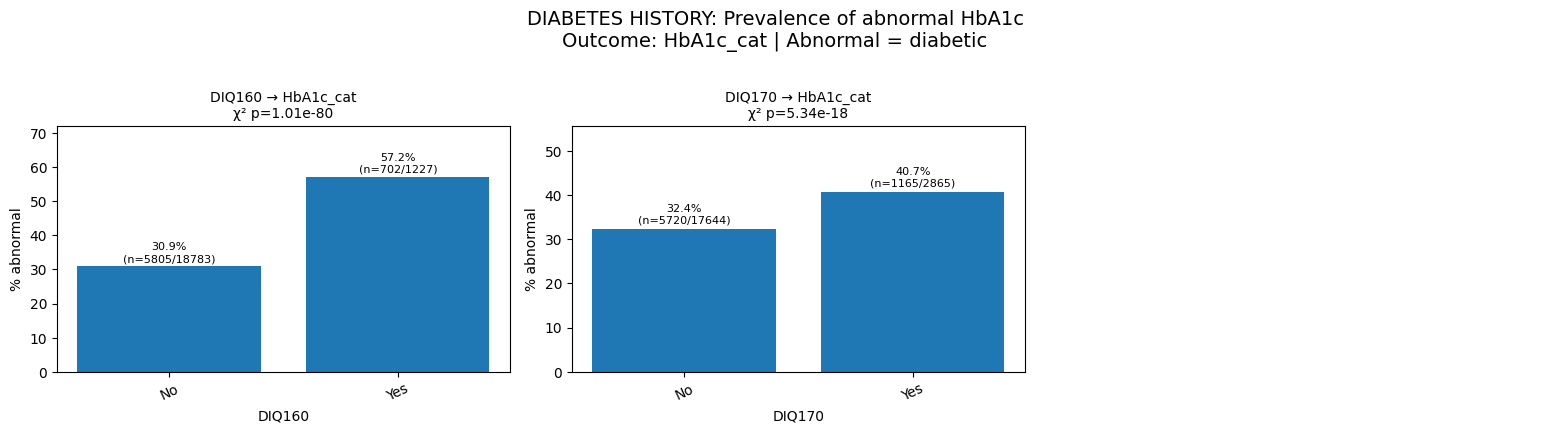

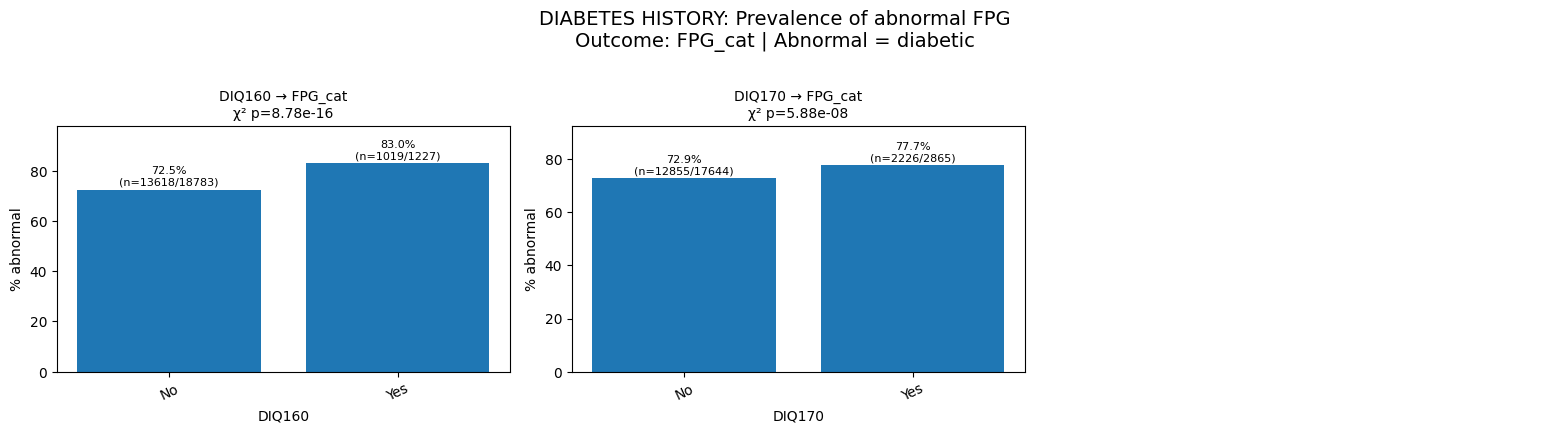

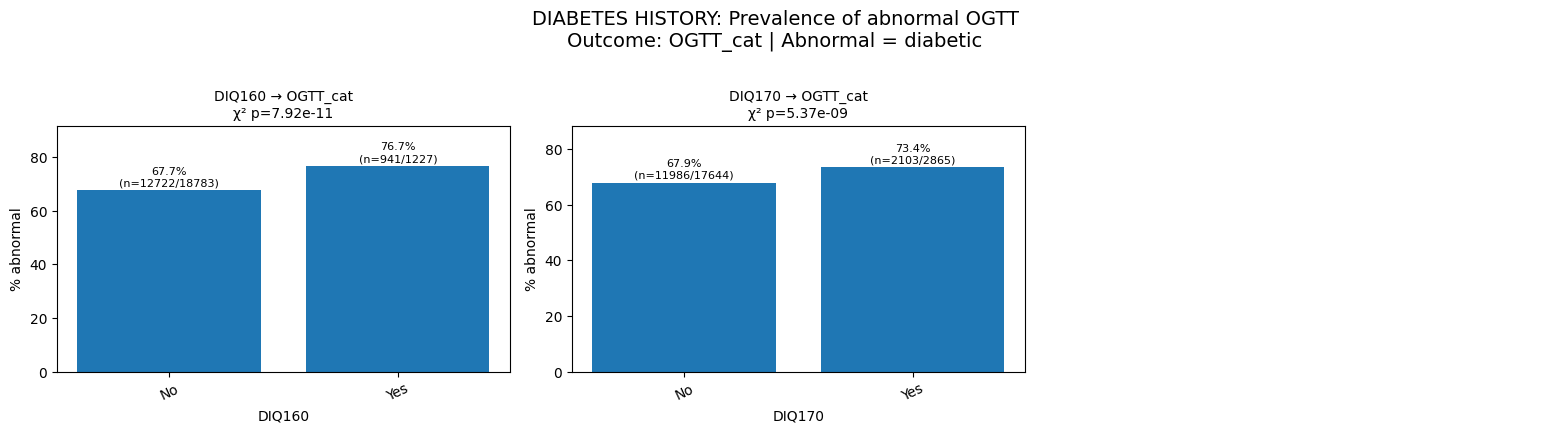

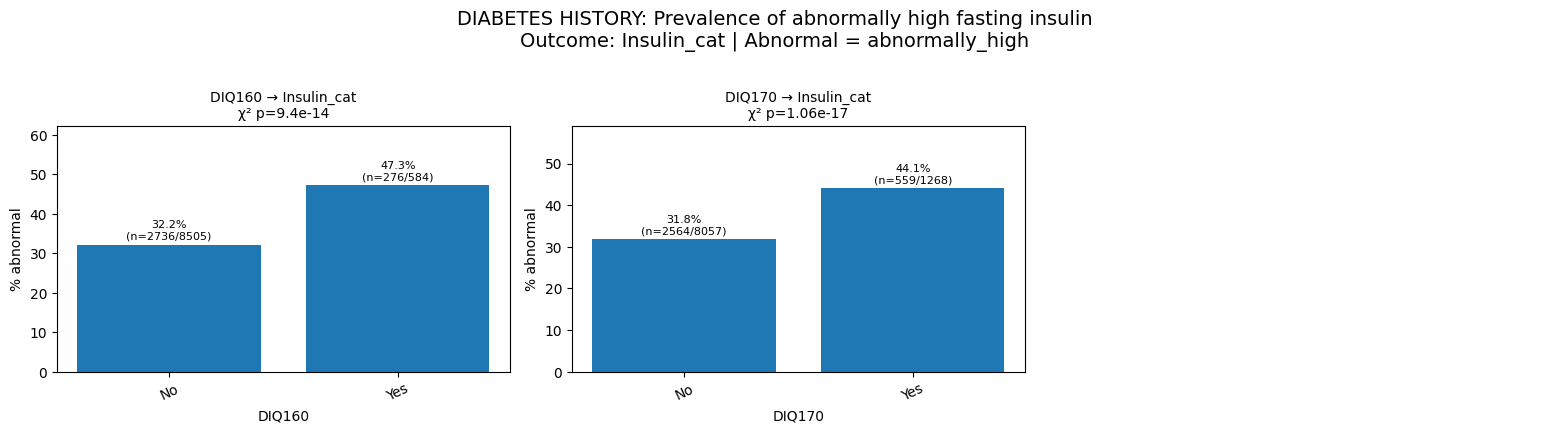

In [ ]:
# DIABETES HISTORY GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormally high fasting insulin"
)

**prediabetes history x biomarkers**

X^2 test significance:
tests show statistical significance for diabetes distory with all biomarkers (p-values < 0.05), indicating a clear association between prediabetes diagnosis and abnormal metabolic outcomes

participants with prior prediabetes diagnosis consistenly show hgiher prevalence of abnormal biomarkers

* HbA1c: 57.2% (Yes) vs 30.9% (No)
*  FPG: 83.0% (Yes) vs 72.5% (No)
*  OGTT: 76.7% (Yes) vs 67.7% (No)
*  Abnormally high fasting insulin: 47.3% (Yes) vs 32.2% (No)

individuals previously diagnosed with prediabetes show higher prevalence of abnormal glycaemic and insulin markers, showing the clinical relevance of prediabetes as an indicator of ongoing metabolic dysregulation.

**family History of Diabetes x biomarkers**

X^2 test significance:

tests are statistically significant for DIQ170 across all biomarkers (p-values > 0.05), indicating an association between family history of diabetes and abnormal biomarker prevalence.

participants with family history of diabetes consistently show higher abnormal prevalence.

*  HbA1c: 40.7% (Yes) vs 32.4% (No)
*  FPG: 77.7% (Yes) vs 72.9% (No)
*  OGTT: 73.4% (Yes) vs 67.9% (No)
*  Abnormally high fasting insulin: 44.1% (Yes) vs 31.8% (No)
*  Elevated prevalence of abnormally high fasting insulin suggests a tendency toward insulin resistance in individuals with familial risk.

A family history of diabetes is associated with increased prevalence of both glycaemic abnormalities and insulin resistance, suggesting inherited or shared environmental factors contributes to metabolic risk.

**overall interpretation**

both predictors are strongly associated with abnormal glycaemic and insulin biomarkers but pronounced differences observed for fasting insulin, showing that insulin resistance as a key pathway linking diabetes history to future disease risk.

###2.3.5 Socioeconomic status x Biomarkers

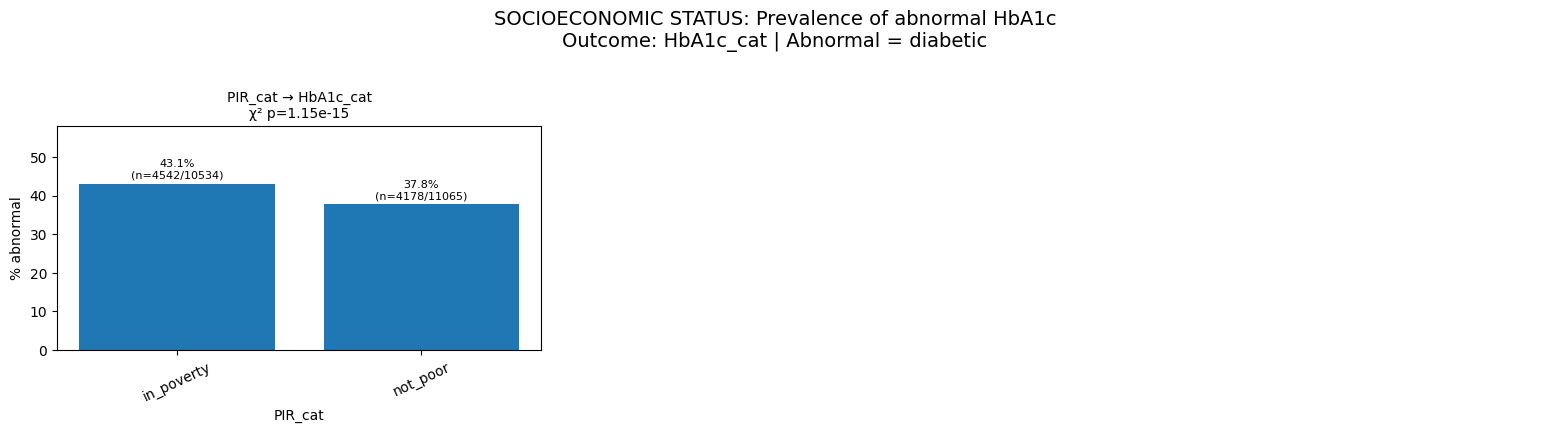

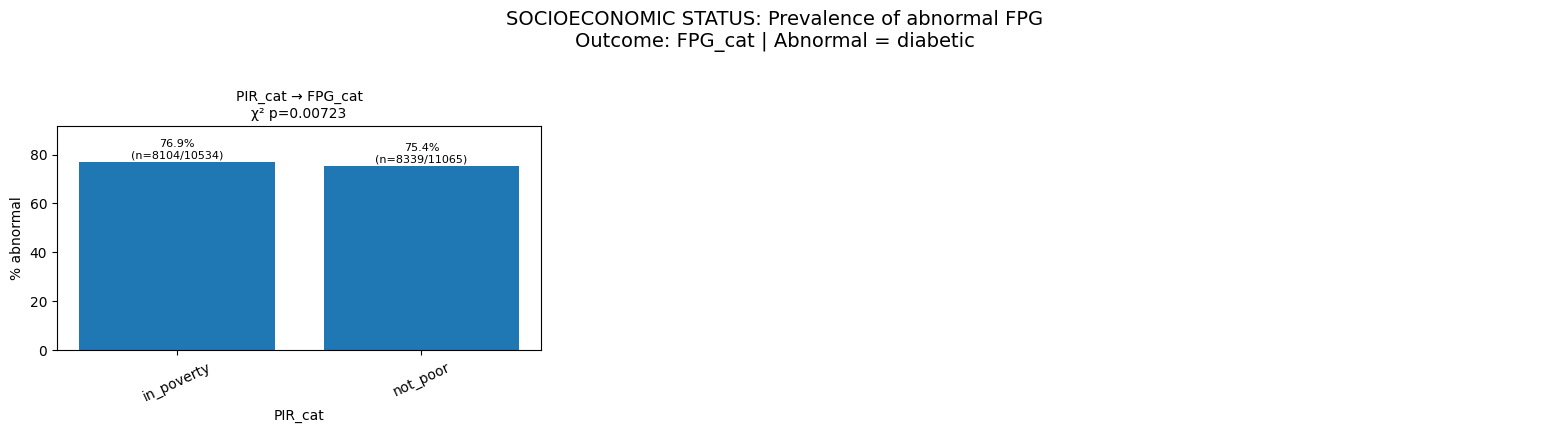

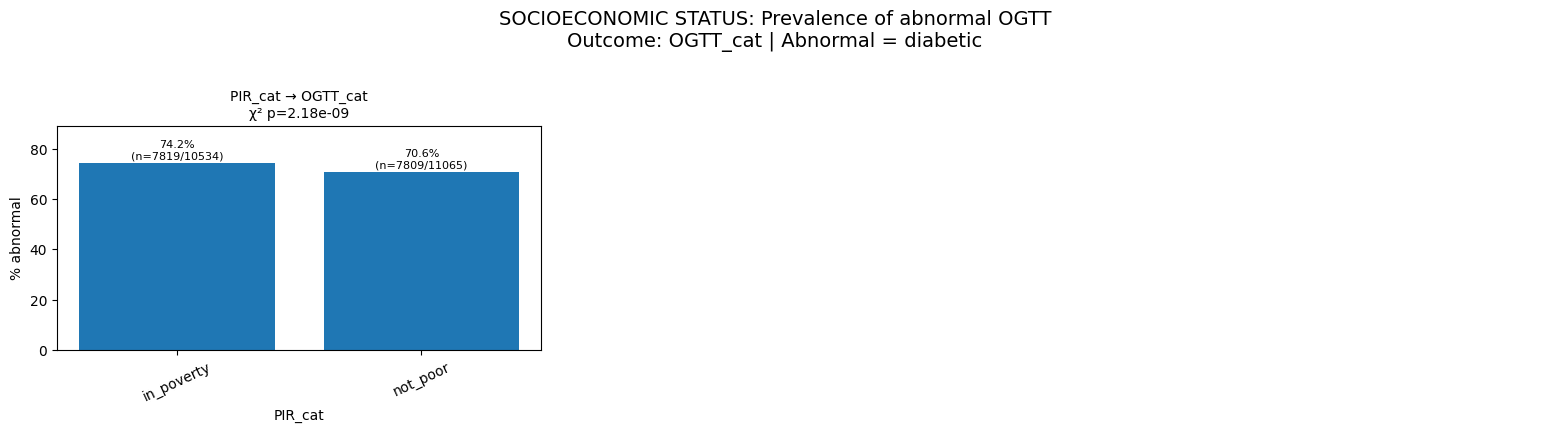

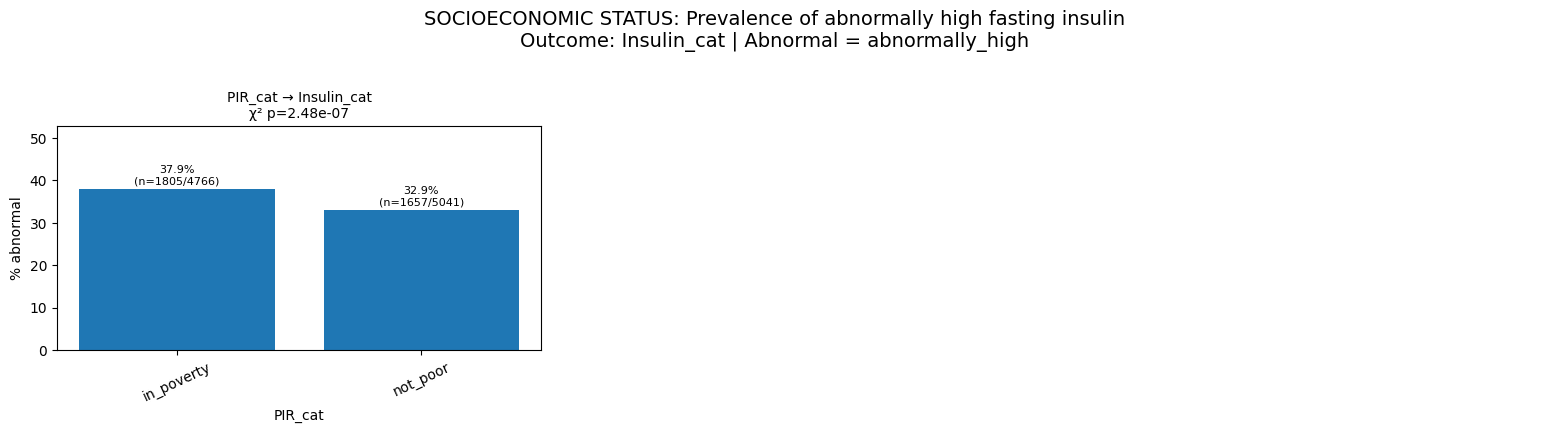

In [ ]:
# SOCIOECONOMIC STATUS GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormally high fasting insulin"
)

**Socioeconomic status(PIR) x biomarkers**

tests show statistically significant associations (p < 0.05) between PIR category and all biomarkers indicating that socioeconomic status is significantly associated with prevalence of abnormal glycaemic and insulin outcomes

individuals in poverty consistently show higher prevalecne of abnormal biomarkers compared to not poor
*  higher rates of abnormal HbA1c (43.1% vs 37.8%),
*  FPG (76.9% vs 75.4%),
*  OGTT (74.2% vs 70.6%),  
*  a more pronounced difference for abnormally high fasting insulin (37.9% vs 32.9%),

Lower socioeconomic status is consistently associated with higher prevalence of abnormal glycaemic biomarkers and insulin resistance. differences most pronounced for HbA1c and fasting insulin. These patterns may reflect disparties in diet quality, access to healthcare, stress suggesting that socioeconomic status is an important factor in diabetes risk.




###2.3.6 Depression Score x biomarkers

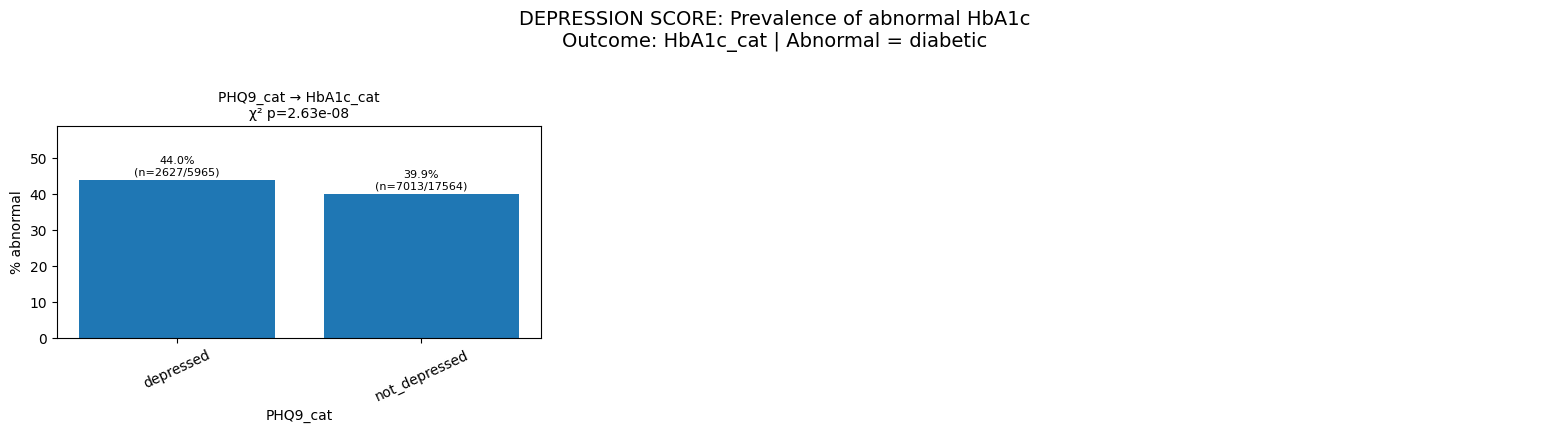

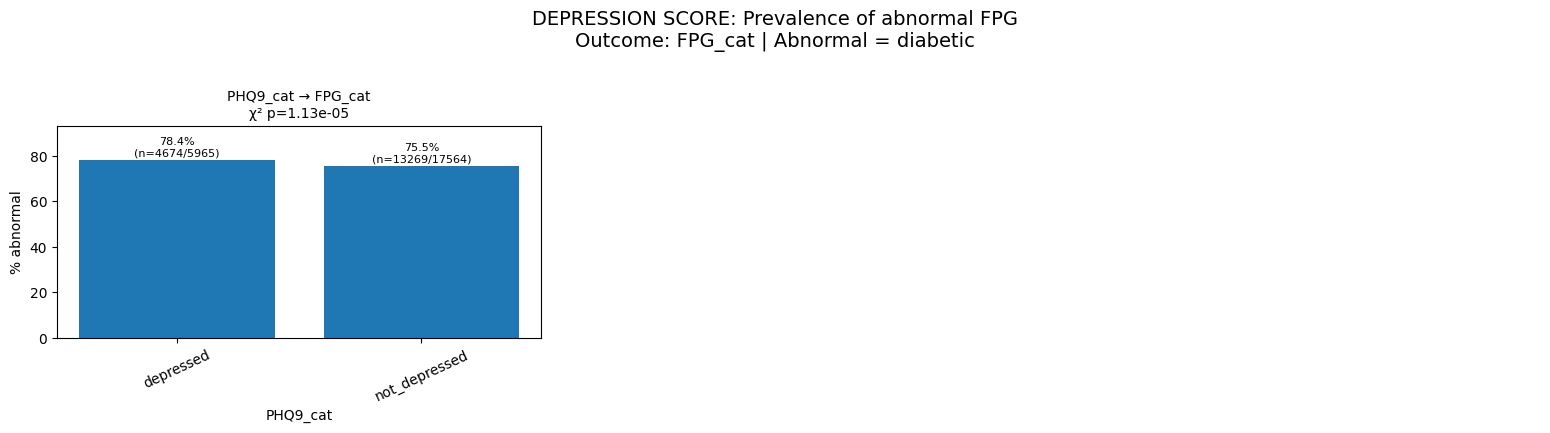

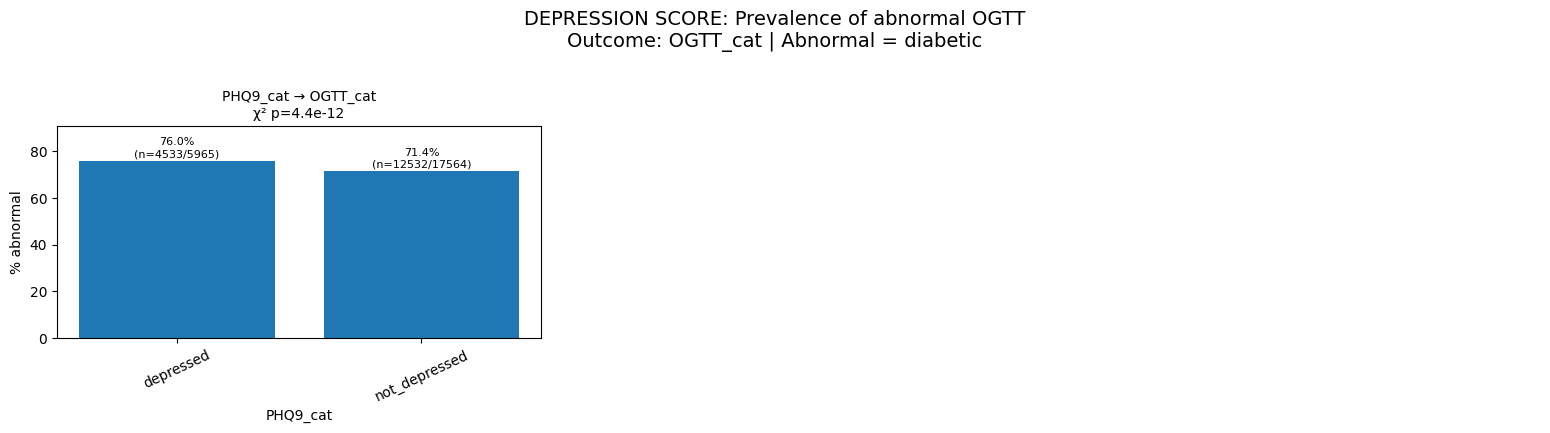

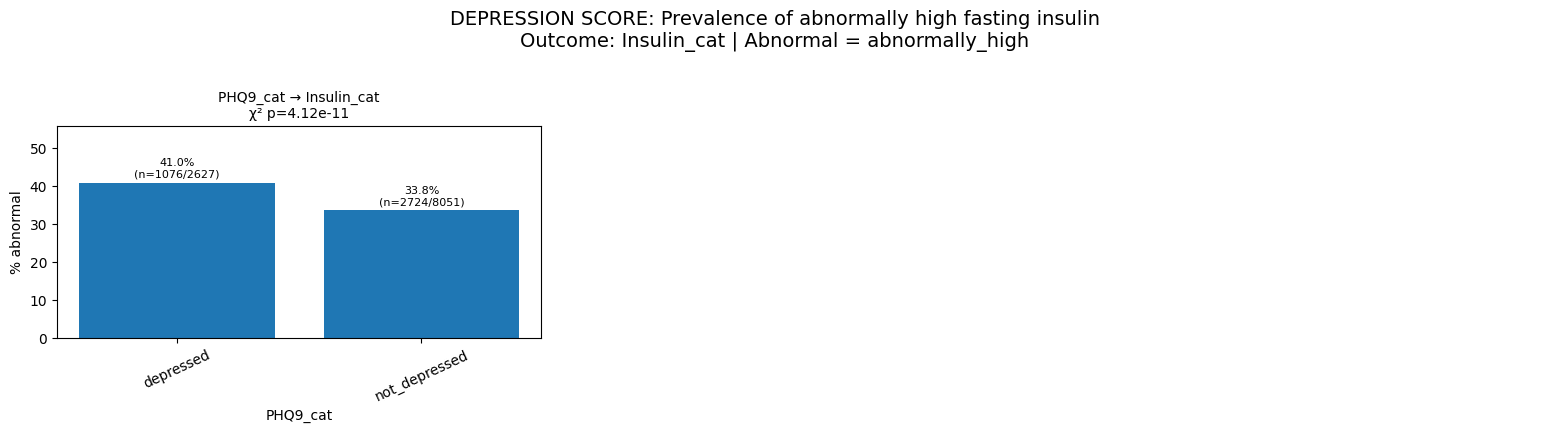

In [ ]:
# DEPRESSION SCORE GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormally high fasting insulin"
)

**depression score x biomarkers**

tests show statistically significant associations (p < 0.05) between depression status and all biomarkers indicating that depression status is significantlyl associated with abnormal glycaemic control and insulin resistance.

Overall, individuals classified as depressed consistently show higher prevalence of abnormal biomarkers compared to those not depressed

*  HbA1c (44.0% vs 39.9%),
*  FPG (78.4% vs 75.5%),
*  OGTT (76.0% vs 71.4%),
*  abnormally high fasting insulin (41.0% vs 33.8%), suggesting a stronger association between depression and insulin resistance than fasting glucose alone.

Depression is consistently associated with higher prevalence of abnormal glycaemic biomarkers and insulin resistance. These fidnings support the inclusion of mental health status as an important contextual predictor.

Overall Unique Finding from the Prevalence Bar Charts:

LDL cholesterol shows a weaker and less consistent assciation with glycaemic biomarkers comapared to adiposity measures, suggesting that dyslipidaemia may play a secondary role relative to obesity-driven insulin resistance.

And although the bar charts and heat map show no significant difference between male and female for changes in biomarker levels, pre valence bar charts show that Males tend to have higher insulin resistance and abnormal FPG while females show slightly higher rates of abnormal OGTT suggesting possible gender-specific factors like insulin sensitivity or hormonal differences which contirbute to diabetes risk.


# **3. Logistic Regression (Associative modelling)**

In [ ]:
#Logistic Regression for HbA1c
#This section will only use elevated HbA1c to determine if person has diabetes or not

#list of all the categories to be used in the regression
columns = ["HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "Calorie_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

#Create new dataframe with variables of interest and remove rows with missing data
model_df = df_model[columns].dropna()

#Make dataframe using only predictors. This ix X. We are removing outcome variable.
X = model_df.drop(columns=['HbA1c_cat'])

#Define the outcome dataset (y)
#Convert outcome variable into binary numeric format to meet requirements of logistic regression
y = model_df['HbA1c_cat'].map({'normal': 0, 'diabetic': 1})

#Convert each categorical variable into binary (0/1) indicator variables
#Each dummy variable represents membership in a category.
#True = 1 and False = 0
# 0 means individual is not in the category. 1 means individual belongs in the category
#drop_first = True removes the reference category for each
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("Dummy-encoded predictors shape:", X.shape)
X.head()


Dummy-encoded predictors shape: (6929, 26)


,FPG_cat_normal,OGTT_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
0,0,1,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
1,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
#Fit the logistic regression model
#Use statsmodels to get full stats output (coeff, SE, p-value, Cls)

#Add constant(intercept, β0) as statsmodels does not automatically include
#To prevent regression from being forced through 0, allowing model to predict baseline log-odds
X = sm.add_constant(X)

#Define logistic regression model
#y = outcome (must be 0/1)
#X = predictors (dummy + const)
logit_model = sm.Logit(y, X)

#Fit the model to estimate parameters
#Uses Maximum Likelihood Estimation (MLE)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.471569
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              HbA1c_cat   No. Observations:                 6929
Model:                          Logit   Df Residuals:                     6902
Method:                           MLE   Df Model:                           26
Date:                Sat, 24 Jan 2026   Pseudo R-squ.:                  0.2186
Time:                        13:43:11   Log-Likelihood:                -3267.5
converged:                       True   LL-Null:                       -4181.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -1.5577      0.288     -5.403      0.000   

##**3.1 HbA1c**


1. Model Overview

| Metric                         | Value     |
| ------------------------------ | --------- |
| Dependent Variable             | HbA1c_cat |
| Model                          | Logit     |
| Method                         | MLE       |
| No. Observations               | 7823      |
| Degrees of Freedom (Model)     | 26        |
| Degrees of Freedom (Residuals) | 7796      |
| Log-Likelihood                 | -3709.2   |
| LL-Null                        | -4730.5   |
| Pseudo R²                      | 0.2159    |
| LLR p-value                    | < 0.001   |
| Converged                      | True      |
| Iterations                     | 6         |

2. Key Predictors and Their Effects on HbA1c Category


Coefficients are in log-odds.

Ods Ratio (OR) = e^coef

OR > 1 → higher odds of elevated HbA1c

OR < 1 → lower odds of elevated HbA1c

| Predictor                           | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                              |
| ----------------------------------- | --------------- | --------------- | ------- | ----------------------------------------------------------------------------------------------------------- |
| **FPG_cat_normal**                  | -0.8838         | **0.41**        | <0.001  | Normal fasting plasma glucose is associated with ~59% lower odds of getting diabetes compared to abnormal FPG |
| **OGTT_cat_normal**                 | -0.5631         | **0.57**        | <0.001  | Normal OGTT is associated with ~43% lower odds of getting diabetes                                            |
| **BMI_cat_obese**                   | 0.4116          | **1.51**        | <0.001  | Obese individuals have ~51% higher odds of getting diabetes compared to normal BMI                            |
| **PIR_cat_not_poor**                | -0.1656         | **0.85**        | 0.007   | Higher income (not poor) is associated with ~15% lower odds of getting diabetes                               |
| **Sedentary_cat_8h+**               | -0.2494         | **0.78**        | 0.001   | ≥8 hours sedentary time shows lower odds of getting diabetes (possible confounding/reverse causation)         |
| **Age_cat_[30,40)**                 | 0.4913          | **1.63**        | <0.001  | Adults aged 30–39 have ~63% higher odds of getting diabetes compared to <30                                                     |
| **Age_cat_[40,50)**                 | 1.0416          | **2.83**        | <0.001  | Adults aged 40–49 have nearly 3× higher odds of getting diabetes                                                                |
| **Age_cat_[50,60)**                 | 1.5561          | **4.74**        | <0.001  | Adults aged 50–59 have ~4.7× higher odds of getting diabetes                                                                   |
| **Age_cat_[60,80)**                 | 2.0257          | **7.58**        | <0.001  | Adults aged 60–79 have over 7× higher odds of getting diabetes                                                                  |
| **LDL_cat_high**                    | 0.3772          | **1.46**        | <0.001  | High LDL cholesterol is associated with ~46% higher odds of getting diabetes                                                    |
| **RIDRETH1_Non-Hispanic Black**     | 0.7639          | **2.15**        | <0.001  | Non-Hispanic Black individuals have over 2× higher odds of getting diabetes                                                     |
| **RIDRETH1_Non-Hispanic White**     | -0.5022         | **0.61**        | <0.001  | Non-Hispanic White individuals have ~39% lower odds of getting diabetes                                                         |
| **DIQ160_Yes (Diabetes diagnosis)** | 0.4790          | **1.61**        | <0.001  | Self-reported diabetes is associated with ~61% higher odds of getting diabetes                                                  |
| **DIQ170_Yes (Prediabetes)**        | 0.2014          | **1.22**        | 0.019   | Prediabetes is associated with ~22% higher odds of getting diabetes                                                             |


3. Summary Interpretation

*   **Strongest positive predictors** of getting diabetes were older age (≥40 years), obesity, high LDL cholestrol, and Non-Hispanic Black ethnicity all remaining significant after adjustment.
*   Normal glycaemic measures (FPG and OGTT) were the **strongest protective factors**, showing substantially lower odds of getting diabetes.
*   Higher socioeconomic status was **independently protective**, indicating an income-related gradient in glycaemic risk.
*   Diabetes and prediabetes status remained **significant predictors**, consistent with progressive dysglycaemia.
*   PHQ-9, lifestyle (diet, smoking, sedentary time), insulin levels and overweight (non-obese BMI) were **not significant multivariable adjustment**.

4. Statistical Takeaways
| Statistic                                      | Meaning                                                                                                                                                                      |
| ---------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Most p-values < 0.05**                       | Strong evidence that several predictors (age, obesity, LDL, ethnicity, glycaemic markers) differ significantly from the null hypothesis (no effect).                         |
| **Pseudo R² ≈ 0.216**                          | Indicates **moderate explanatory power**, which is considered good for large population-based health survey data (typical range ≈ 0.10–0.30).                                |
| **Log-likelihood improvement (LLR p < 0.001)** | The full model fits the data **significantly better** than the null model with no predictors.                                                                                |
| **Intercept = −1.81**                          | Represents baseline log-odds of elevated HbA1c for the reference group (young, normal BMI, normal glucose, low-risk profile); corresponds to a **low baseline probability**. |
| **Clear dose–response patterns**               | Age categories show progressively increasing coefficients, supporting a **strong, monotonic risk relationship** rather than random association.                              |




In [ ]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "FPG_cat",
    "OGTT_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df


In [ ]:
#Tidying regression outputs for HbA1c outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-1.558,0.000,0.120,0.120,0.371,NaN,NaN,NaN,NaN,NaN,NaN
FPG_cat_normal,-0.786,0.000,0.400,0.400,0.519,-0.128,0.011,-11.517,0.000,-0.150,-0.107
OGTT_cat_normal,-0.792,0.000,0.392,0.392,0.523,-0.135,0.013,-10.064,0.000,-0.161,-0.109
Insulin_cat_normal,-0.068,0.776,0.584,0.584,1.495,-0.011,0.037,-0.283,0.777,-0.084,0.063
Insulin_cat_abnormally_high,0.341,0.171,0.864,0.864,2.290,0.054,0.040,1.338,0.181,-0.025,0.133
PHQ9_cat_not_depressed,0.015,0.842,0.876,0.876,1.176,0.002,0.012,0.200,0.841,-0.020,0.025
BMI_cat_overweight,0.094,0.411,0.878,0.878,1.376,0.015,0.018,0.820,0.412,-0.020,0.049
BMI_cat_obese,0.413,0.001,1.181,1.181,1.934,0.064,0.020,3.267,0.001,0.026,0.103
PIR_cat_not_poor,-0.171,0.009,0.741,0.741,0.958,-0.026,0.010,-2.610,0.009,-0.046,-0.007


###**3.1.1 Interpretation for HbA1c outcome** - Using both the log-odds (coeff/OR) and probability (AMAE) perspectives.

1. Glycaemic Markers (FPG and OGTT)
| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                                                                                |
| ---------- | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal FPG | −0.884 | 0.37 | −0.147 | Compared to **abnormal FPG**, individuals with normal fasting glucose have **63% lower odds** of getting diabetes and an average **14.7 percentage point lower probability** of getting diabetes. |

Summary: Normal fasting glucose is a **strong protective factor**, showing both a large reduction in relative odds and a substantial absolute decrease in predicted probability. This confirms FPG as one of the most influential predictors of diabetes.

| Category    | Coef   | OR   | AME    | Interpretation                                                                                                                                                           |
| ----------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal OGTT | −0.563 | 0.50 | −0.093 | Compared to individuals with abnormal OGTT results, those with a normal OGTT have **50% lower odds** and a **9.3 percentage point lower probability** of getting diabetes. |

Summary: Normal post-challenge glucose regulation is strongly protective against getting diabetes, with consistent effects on both the relative odds and absolute probability scales, highlighting the clinical relevance of OGTT in glycaemic risk assessment.

2. Body Mass Index (BMI)

| Category   | Coef  | OR   | AME   | Interpretation                                                                                                                                          |
| ---------- | ----- | ---- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | 0.102 | 0.90 | 0.016 | Overweight individuals do not show a meaningful difference in odds or probability of getting diabetes compared to those with normal BMI after adjustment. |
| Obese      | 0.412 | 1.20 | 0.065 | Obese individuals have **20% higher odds** and a **6.5 percentage point higher probability** of getting diabetes compared to those with normal BMI.       |

Summary: BMI shows a **threshold effect**, where overweight status is not independently associated with getting diabetes, but **obesity** is associated with a significant increase in both relative odds and absolute probability, indicating that glycaemic risk becomes evident only at higher levels of adiposity.

3. Age
| Category | Coef  | OR   | AME   | Interpretation                                                                                                              |
| -------- | ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------- |
| 30–40    | 0.491 | 1.30 | 0.078 | Adults aged 30–40 have **30% higher odds** and an **8 pp higher probability** of getting diabetes compared to those under 30. |
| 40–50    | 1.042 | 2.27 | 0.167 | Adults aged 40–50 have **more than double the odds** and a **16.7 pp higher probability**.                                  |
| 50–60    | 1.556 | 3.79 | 0.261 | Adults aged 50–60 have **nearly fourfold higher odds** and a **26.1 pp higher probability**.                                |
| 60–80    | 2.026 | 6.11 | 0.354 | Adults aged 60–80 have **over sixfold higher odds** and a **35.4 pp higher probability** of getting diabetes                 |

Summary: Age demonstrates a **strong dose-response relationship**, with progressively increasing odds, translating into large absolute risk increases, making age the **dominant predictor** in the model.

4. Ethnicity (Race)
| Category           | Coef   | OR   | AME    | Interpretation                                                                                                                                  |
| ------------------ | ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| Non-Hispanic Black | 0.764  | 1.78 | 0.126  | Non-Hispanic Black individuals have **78% higher odds** and a **12.6 pp higher probability** of getting diabetes compared to the reference group. |
| Non-Hispanic White | −0.502 | 0.51 | −0.078 | Non-Hispanic White individuals have **49% lower odds** and a **7.8 pp lower probability**.                                                      |

Summary: Ethnic disparities persist after adjustment, with differenes evident in both **relative odds** and **absolute risk**, suggesting influences beyond measured covariates.

5. Lipids and Socioeconomic Status
| Category       | Coef   | OR   | AME    | Interpretation                                                                                                      |
| -------------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------- |
| High LDL       | 0.377  | 1.27 | 0.060  | Individuals with high LDL cholesterol have **27% higher odds** and a **6 pp higher probability** of getting diabetes. |
| Not Poor (PIR) | −0.166 | 0.75 | −0.026 | Individuals who are not poor have **25% lower odds** and a **2.6 pp lower probability** of getting diabetes.          |

Summary:
Metabolic risk and socioeconomic status independently contribute to higher odds of getting diabetes, through their absolute effects are smaller thanthose of age or glycaemic markers.

**Overall Interpretation**
| Aspect                                | Log-Odds / OR Insight                                                     | AME (Probability) Insight                                                     |
| ------------------------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| **Age**                               | Strong, dose–response risk (OR increases up to **≈ 6.1** in older adults) | Large absolute increase in probability (**+8 to +35 pp** with increasing age) |
| **Glycaemic markers (FPG, OGTT)**     | Strongly protective (OR **< 0.5** for normal values)                      | Substantial probability reduction (**−9 to −15 pp**)                          |
| **Body Mass Index (Obesity)**         | Moderate risk (OR ≈ **1.2**)                                              | Meaningful probability increase (**+6.5 pp**)                                 |
| **Ethnicity (Non-Hispanic Black)**    | Elevated risk (OR ≈ **1.8**)                                              | Notable probability increase (**+12.6 pp**)                                   |
| **Ethnicity (Non-Hispanic White)**    | Protective (OR ≈ **0.5**)                                                 | Lower probability (**−7.8 pp**)                                               |
| **LDL cholesterol (High)**            | Moderate metabolic risk (OR ≈ **1.27**)                                   | Increased probability (**+6 pp**)                                             |
| **Socioeconomic status (Not poor)**   | Protective (OR ≈ **0.75**)                                                | Small but significant probability reduction (**−2.6 pp**)                     |
| **Lifestyle & psychological factors** | No independent association after adjustment (OR ≈ 1)                      | Minimal or null probability changes                                           |

Summary:
After adjustments to demographic, metabolic and socioeconomic factors,
* Older age is the dominant predictor of diabetes, with progressively higher odds and large increases in predicted probability.
* FPG and OGTT are the strongest protective factors, substantially lowering both relative odds and absolute risk.
* Obesity, high LDL cholestrol, and Non-Hispanic Black ethnicity remain independently associated with higher odds of getting diabetes.
* Higher socioeconomic status is modestly protective.
* Lifestyle (diet, sedentary time, smoking), psychological status, and insulin levels do not show independent associations after multivariable adjustment.

Overall, the model demonstrates that metabolic and demographic factors drive HbA1c risk, with effects that are consistent across both relative (OR) and absolute (AME) scales.

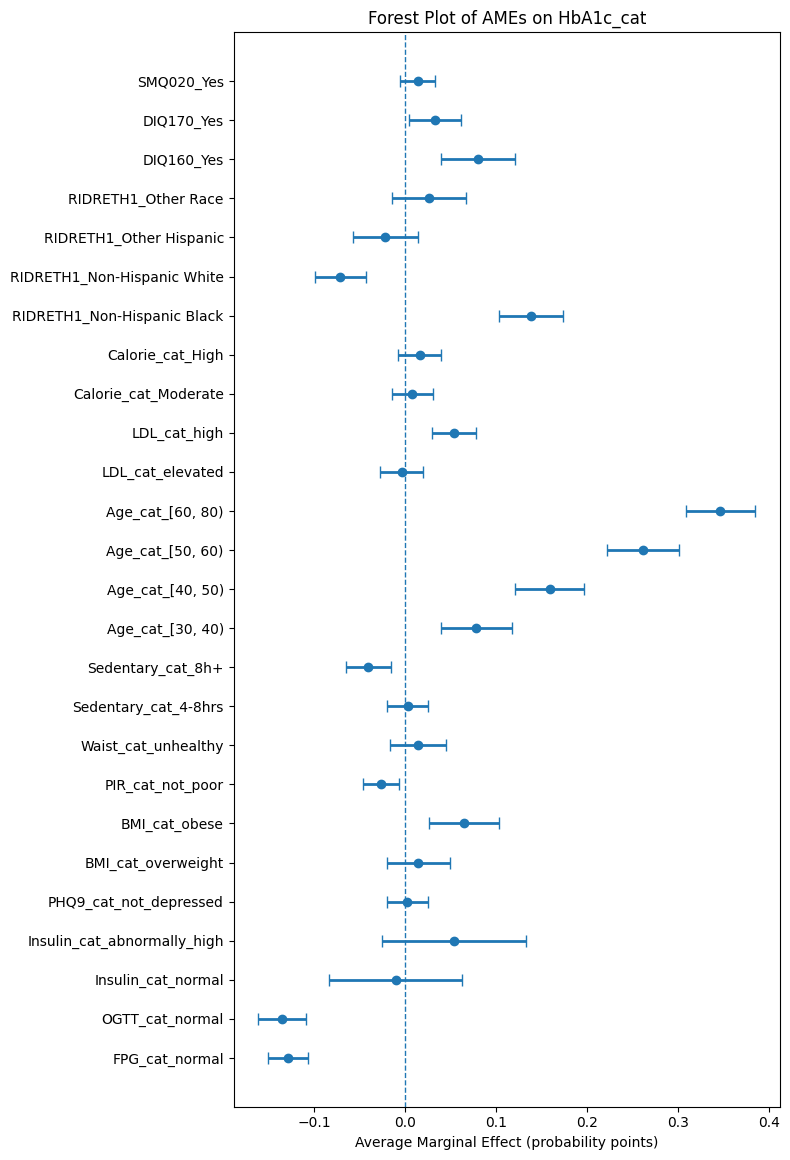

,AME,CI_lower,CI_upper
FPG_cat_normal,-0.128,-0.150,-0.107
OGTT_cat_normal,-0.135,-0.161,-0.109
Insulin_cat_normal,-0.011,-0.084,0.063
Insulin_cat_abnormally_high,0.054,-0.025,0.133
PHQ9_cat_not_depressed,0.002,-0.020,0.025
BMI_cat_overweight,0.015,-0.020,0.049
BMI_cat_obese,0.064,0.026,0.103
PIR_cat_not_poor,-0.026,-0.046,-0.007
Waist_cat_unhealthy,0.014,-0.017,0.045
Sedentary_cat_4-8hrs,0.003,-0.020,0.026


In [ ]:
#Construct Forest Plot for HbA1c outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

###**3.1.2 Analysis of the Forest Plot for HbA1c outcome**


1. Glycaemic Markers (FPG & OGTT)

**Variables:**

FPG_cat_normal

OGTT_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects are negative.
Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal FPG → ≈ 15 pp lower probability of elevated HbA1c compared to abnormal FPG

Normal OGTT → ≈ 9 pp lower probability

**Summary:**
Normal fasting and post-challenge glucose levels are strongly associated with a **reduced predicted probability of getting diabetes.** These are the **most protective factors** in the model. This reflects preserved glucose regulation rather than a causal effect.


2. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies close to 0 and its confidence interval crosses zero, indicating no significant association.

Obese lies clearly to the right of 0, and its confidence interval does not cross zero, showing statistical significance.

**This means:**

Overweight → ≈ 1–2 pp higher probability (not significant)

Obese → ≈ 6.5 pp higher probability of getting diabetes

**Summary:**
BMI shows a **threshold effect:** overweight status alone does not significantly affect diabetes risk, while **obesity is associated with a meaningful increase in predicted probability**, reflecting metabolic dysregulation at higher adiposity levels.


3. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for all age groups do not cross zero, indicating strong statistical significance.

**This means:**

30–40 yrs → ≈ 8 pp higher probability

40–50 yrs → ≈ 17 pp higher

50–60 yrs → ≈ 26 pp higher

60–80 yrs → ≈ 35 pp higher

**Summary:**
There is a **clear dose–response relationship** between age and odds of getting diabetes. Older age groups have progressively higher predicted probabilities, making **age the strongest risk factor** in the model.


4. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

High LDL lies to the right of 0 with a confidence interval that does not cross zero.

Not poor (higher PIR) lies to the left of 0, also with a confidence interval that does not cross zero.

**This means:**

High LDL → ≈ 6 pp higher probability of getting diabetes

Not poor → ≈ 2.6 pp lower probability

**Summary:**
Dyslipidaemia and socioeconomic status independently influence odds of getting diabetes. High LDL is associated with increased risk, while higher income status confers modest protection, likely reflecting differences in healthcare access and lifestyle factors.


5. **Ethnicity (Race)**

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic Black lies well to the right of 0, with a confidence interval not crossing zero.

Non-Hispanic White lies clearly to the left of 0, also statistically significant.

Other Hispanic and Other Race categories lie close to zero with confidence intervals crossing zero.

**This means:**

Non-Hispanic Black → ≈ 12.6 pp higher probability of getting diabetes

Non-Hispanic White → ≈ 7.8 pp lower probability

Other groups → no significant difference from the reference

**Summary:**
Ethnic disparities persist after adjustment. Non-Hispanic Black participants have a substantially higher predicted probability of getting diabetes, while Non-Hispanic White participants have a lower probability. These differences likely reflect a combination of biological, social, and structural factors.


6. **Diabetes Status**

Variables:

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

**Interpretation:**

Both variables lie to the right of 0, with confidence intervals that do not cross zero.

**This means:**

Diabetes → ≈ 8 pp higher probability

Prediabetes → ≈ 3 pp higher probability

**Summary:**
As expected, diagnosed diabetes and prediabetes are associated with higher predicted probabilities of getting diabetes, supporting the validity of the outcome definition.


**Overall Picture**

| Group             | Direction of Effect | Magnitude    | Significance | Interpretation                                   |
| ----------------- | ------------------- | ------------ | ------------ | ------------------------------------------------ |
| Glycaemic markers | ↓                   | −9 to −15 pp | Yes          | Strong protection with normal glucose regulation |
| Age               | ↑                   | +8 to +35 pp | Yes          | Strong dose–response increase in risk            |
| BMI (Obese)       | ↑                   | +6.5 pp      | Yes          | Threshold effect at obesity                      |
| LDL (High)        | ↑                   | +6 pp        | Yes          | Metabolic risk factor                            |
| PIR (Not poor)    | ↓                   | −2.6 pp      | Yes          | Socioeconomic protection                         |
| Race (Black)      | ↑                   | +12.6 pp     | Yes          | Higher HbA1c probability                         |
| Race (White)      | ↓                   | −7.8 pp      | Yes          | Lower probability vs reference                   |



**In short:**
The forest plot shows that **older age, obesity, high LDL, diabetes status, and Non-Hispanic Black ethnicity** are the strongest positive predictors of getting diabetes, while **normal glycaemic markers and higher socioeconomic status** are associated with lower predicted probability. These findings represent **associations rather than causation.**

In [ ]:
#Repeat Logistic Regression with fasting plasma glucose (FPG) outcome
#This section will only use boarderline/elevated FPG to determine if person has diabetes or not

#labels = ["Normal", "Borderline/High"]
# Map target to binary 0/1

X = model_df.drop(columns=['FPG_cat'])
y = model_df['FPG_cat'].map({'normal': 0, 'diabetic': 1})

print(y.value_counts())

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
display("First few columns:\n", X.head())

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)

result = logit_model.fit()

print(result.summary())

FPG_cat
0    4027
1    2902
Name: count, dtype: int64
Dummy-encoded predictors shape: (6929, 26)


'First few columns:\n'

,HbA1c_cat_normal,OGTT_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
0,0,1,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
1,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


Optimization terminated successfully.
         Current function value: 0.553026
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                FPG_cat   No. Observations:                 6929
Model:                          Logit   Df Residuals:                     6902
Method:                           MLE   Df Model:                           26
Date:                Sat, 24 Jan 2026   Pseudo R-squ.:                  0.1866
Time:                        13:43:12   Log-Likelihood:                -3831.9
converged:                       True   LL-Null:                       -4711.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -1.7890      0.314     -5.700      0.000   

##**3.2 Fasting Glucose (FPG)**

1. Model Overview

| Metric                         | Value       |
| ------------------------------ | ----------- |
| Dependent Variable             | **FPG_cat** |
| Model                          | Logit       |
| Method                         | MLE         |
| No. Observations               | 7,823       |
| Degrees of Freedom (Model)     | 26          |
| Degrees of Freedom (Residuals) | 7,796       |
| Log-Likelihood                 | −4360.9     |
| LL-Null                        | −5305.2     |
| Pseudo R²                      | **0.1780**  |
| LLR p-value                    | **< 0.001** |
| Converged                      | True        |
| Iterations                     | 6           |

2. Key Predictors and Their Effects on FPG Category

Coefficients are in log-odds.

Ods Ratio (OR) = e^coef

OR > 1 → higher odds of boarderline/elevated FPG

OR < 1 → lower odds of boarderline/elevated FPG

| Predictor                   | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                                |
| --------------------------- | --------------- | --------------- | ------- | ------------------------------------------------------------------------------------------------------------- |
| HbA1c_cat_normal            | −0.8848         | 0.41            | <0.001  | Normal HbA1c is associated with **~59% lower odds** of getting diabetes compared to elevated HbA1c         |
| OGTT_cat_normal             | −0.6621         | 0.52            | <0.001  | Normal OGTT is associated with **~48% lower odds** of getting diabetes                                     |
| Insulin_cat_normal          | 1.1679          | 3.21            | <0.001  | Normal insulin is associated with **~3.2× higher odds** of getting diabetes                                |
| Insulin_cat_abnormally_high | 2.0654          | 7.89            | <0.001  | Abnormally high insulin is associated with **~8× higher odds** of getting diabetes                         |
| BMI_cat_overweight          | 0.5113          | 1.67            | <0.001  | Overweight individuals have **~67% higher odds** of getting diabetes                                       |
| BMI_cat_obese               | 0.8158          | 2.26            | <0.001  | Obese individuals have **~2.3× higher odds** of getting diabetes                                           |
| Waist_cat_unhealthy         | −0.3831         | 0.68            | <0.001  | Unhealthy waist circumference shows **~32% lower odds** (possible confounding or collinearity with BMI)       |
| Sedentary_cat_8h+           | −0.1767         | 0.84            | 0.012   | ≥8 hours sedentary time is associated with **~16% lower odds** (counterintuitive; possible reverse causation) |
| Age_cat_[30,40)             | 0.4935          | 1.64            | <0.001  | Adults aged 30–39 have **~64% higher odds** vs <30                                                            |
| Age_cat_[40,50)             | 0.7463          | 2.11            | <0.001  | Adults aged 40–49 have **~2.1× higher odds**                                                                  |
| Age_cat_[50,60)             | 0.9708          | 2.64            | <0.001  | Adults aged 50–59 have **~2.6× higher odds**                                                                  |
| Age_cat_[60,80)             | 1.3156          | 3.73            | <0.001  | Adults aged 60–79 have **~3.7× higher odds**                                                                  |
| LDL_cat_elevated            | 0.1490          | 1.16            | 0.022   | Elevated LDL is associated with **~16% higher odds**                                                          |
| LDL_cat_high                | 0.1536          | 1.17            | 0.021   | High LDL is associated with **~17% higher odds**                                                              |
| Calorie_cat_High            | 0.2966          | 1.35            | <0.001  | High calorie intake is associated with **~35% higher odds**                                                   |
| RIDRETH1_Non-Hispanic Black | −0.6451         | 0.52            | <0.001  | Non-Hispanic Black individuals have **~48% lower odds** of getting diabetes                                |
| DIQ160_Yes (Diabetes)       | 0.4655          | 1.59            | <0.001  | Diagnosed diabetes is associated with **~59% higher odds**                                                    |
| SMQ020_Yes (Smoker)         | 0.2913          | 1.34            | <0.001  | Smokers have **~34% higher odds** of getting diabetes                                                      |

3. Summary Interpretation

* **Strongest positive predictors** of diabetes were **older age, obesity, high insulin levels, high calorie intake, smoking, and diabetes diagnosis**, all remaining significant after adjustment.

* **Normal HbA1c and normal OGTT** were strong protective factors, reinforcing consistency across glycaemic biomarkers.

* **Insulin levels** showed very large effects, suggesting underlying insulin resistance as a key driver of elevated fasting glucose.

* **BMI** (overweight and obese) showed clear risk gradients, unlike the HbA1c model where only obesity was significant.

* **Non-Hispanic Black ethnicity** was associated with lower odds of elevated FPG, contrasting with its higher risk for HbA1c and highlighting biomarker-specific differences in glycaemic regulation.

* Several lifestyle variables (sedentary time, waist circumference) showed counterintuitive protective associations, likely reflecting **confounding, collinearity, or reverse causation.**

4. Statistical Takeaways
| Statistic                                  | Meaning                                                                                                                                    |
| ------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| Most p-values < 0.05                       | Strong evidence that age, insulin status, BMI, LDL, calories, smoking, and glycaemic markers differ significantly from the null hypothesis |
| Pseudo R² ≈ 0.18                           | Indicates **moderate explanatory power**, appropriate for large population-based health survey data                                        |
| Log-likelihood improvement (LLR p < 0.001) | Full model fits the data significantly better than the null model                                                                          |
| Intercept = −1.94                          | Represents baseline log-odds of borderline/high FPG for the reference group (young, normal BMI, normal glucose, low-risk profile)          |
| Dose–response patterns                     | Age categories show progressively increasing coefficients, supporting a monotonic risk relationship                                        |



In [ ]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "OGTT_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df


In [ ]:
#Tidying regression outputs for FPG outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-1.789,0.000,0.090,0.090,0.309,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.784,0.000,0.401,0.401,0.520,-0.157,0.014,-11.371,0.000,-0.184,-0.130
OGTT_cat_normal,-1.107,0.000,0.286,0.286,0.382,-0.226,0.015,-14.656,0.000,-0.256,-0.196
Insulin_cat_normal,1.434,0.000,2.419,2.419,7.271,0.213,0.030,7.176,0.000,0.155,0.271
Insulin_cat_abnormally_high,2.302,0.000,5.694,5.694,17.533,0.437,0.042,10.400,0.000,0.355,0.519
PHQ9_cat_not_depressed,0.099,0.154,0.964,0.964,1.265,0.018,0.013,1.434,0.152,-0.007,0.043
BMI_cat_overweight,0.490,0.000,1.351,1.351,1.972,0.090,0.017,5.182,0.000,0.056,0.125
BMI_cat_obese,0.792,0.000,1.780,1.780,2.736,0.152,0.021,7.242,0.000,0.111,0.193
PIR_cat_not_poor,-0.053,0.376,0.844,0.844,1.066,-0.010,0.011,-0.885,0.376,-0.032,0.012


###**3.2.1 Interpretation for FPG outcome** - Using both the log-odds (coeff/OR) and probability (AMAE) perspectives.

1. Glycaemic Markers (HbA1c and OGTT)


| Category     | Coef   | OR   | AME    | Interpretation                                                                                                                                                                                         |
| ------------ | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal HbA1c | −0.885 | 0.37 | −0.181 | Compared to elevated HbA1c, individuals with normal HbA1c have **63% lower odds** of getting diabetes and an **18.1 percentage point lower probability** of having abnormal FPG. |

Summary:
Normal long-term glycaemic control (HbA1c) is a very **strong protective factor** for getting diabetes (fasting hyperglycaemia), showing both a large reduction in relative odds and a substantial absolute decrease in predicted probability. This highlights the close physiological relationship between chronic and fasting glucose regulation.

| Category    | Coef   | OR   | AME    | Interpretation                                                                                                                                                                             |
| ----------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal OGTT | −0.662 | 0.46 | −0.131 | Compared to individuals with abnormal OGTT results, those with a normal OGTT have **54% lower odds** and a **13.1 percentage point lower probability** of getting diabetes. |

Summary:
Normal post-challenge glucose regulation is strongly protective against abnormal fasting glucose, with consistent effects on both relative odds and absolute probability scales, reinforcing OGTT as a clinically relevant marker of dysglycaemia.

2. Insulin status
| Category                | Coef  | OR   | AME   | Interpretation                                                                                                                                                |
| ----------------------- | ----- | ---- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal insulin          | 1.168 | 1.99 | 0.184 | Individuals with normal insulin levels have **~2× higher odds** and an **18.4 pp higher probability** of getting diabetes compared to the reference group. |
| Abnormally high insulin | 2.065 | 4.82 | 0.403 | Individuals with abnormally high insulin have **nearly 5× higher odds** and a **40.3 pp higher probability** of getting diabetes.                          |

Summary:
Insulin levels show very large positive associations with abnormal fasting glucose, particularly for abnormally high insulin. This pattern is consistent with **insulin resistance**, where compensatory hyperinsulinaemia coexists with elevated fasting glucose.

3. Body Mass Index (BMI)
| Category   | Coef  | OR   | AME   | Interpretation                                                                                                                                            |
| ---------- | ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | 0.511 | 1.40 | 0.095 | Overweight individuals have **40% higher odds** and a **9.5 pp higher probability** of getting diabetes compared to those with normal BMI. |
| Obese      | 0.816 | 1.86 | 0.158 | Obese individuals have **86% higher odds** and a **15.8 pp higher probability** of getting diabetes.                                       |

Summary:
BMI shows a clear **risk gradient** for fasting glucose. Both overweight and obese categories are associated with increased odds and probability, indicating that fasting glucose dysregulation emerges earlier along the adiposity spectrum compared to HbA1c.

4. Age
| Category | Coef  | OR   | AME   | Interpretation                                                                                                          |
| -------- | ----- | ---- | ----- | ----------------------------------------------------------------------------------------------------------------------- |
| 30–40    | 0.494 | 1.38 | 0.093 | Adults aged 30–40 have **38% higher odds** and a **9.3 pp higher probability** compared to those under 30.              |
| 40–50    | 0.746 | 1.77 | 0.141 | Adults aged 40–50 have **77% higher odds** and a **14.1 pp higher probability**.                                        |
| 50–60    | 0.971 | 2.19 | 0.187 | Adults aged 50–60 have **~2.2× higher odds** and an **18.7 pp higher probability**.                                     |
| 60–80    | 1.316 | 3.12 | 0.260 | Adults aged 60–80 have **over 3× higher odds** and a **26.0 pp higher probability** of getting diabetes. |

Summary:
Age demonstrates a **strong dose–response relationship** with fasting glucose, with progressively increasing odds translating into large absolute increases in probability, confirming age as a major determinant of fasting dysglycaemia.

5. Lipids and Socioeconomic Status
| Category       | Coef   | OR   | AME    | Interpretation                                                                                                                 |
| -------------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------ |
| Elevated LDL   | 0.149  | 1.02 | 0.028  | Individuals with elevated LDL have **~2% higher odds** and a **2.8 pp higher probability** of getting diabetes. |
| High LDL       | 0.154  | 1.02 | 0.029  | Individuals with high LDL have **~2% higher odds** and a **2.9 pp higher probability**.                                        |
| Not poor (PIR) | −0.033 | 0.87 | −0.006 | Socioeconomic status is **not significantly associated** with fasting glucose after adjustment.                                |

Summary:
LDL cholesterol shows small but statistically significant associations with fasting glucose, while socioeconomic status does not independently predict getting diabetes (fasting hyperglycaemia) in this model.

6. Lifestyle and Demographic Factors
| Category           | Coef   | OR   | AME    | Interpretation                                                                                                                  |
| ------------------ | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------- |
| Sedentary ≥8 h     | −0.177 | 0.73 | −0.033 | Individuals sedentary ≥8 hours show **~27% lower odds** and a **3.3 pp lower probability** (counterintuitive).                  |
| Non-Hispanic Black | −0.645 | 0.44 | −0.117 | Non-Hispanic Black individuals have **56% lower odds** and an **11.7 pp lower probability** of getting diabetes. |
| Smoker             | 0.291  | 1.20 | 0.055  | Smokers have **20% higher odds** and a **5.5 pp higher probability** of getting diabetes.                        |

Summary:
Some lifestyle and demographic variables show unexpected protective associations (e.g. sedentary time, Non-Hispanic Black ethnicity), likely reflecting **biomarker-specific physiology, residual confounding, or reverse causation** rather than true protective effects.

**Overall interpretation**
| Aspect                          | Log-Odds / OR Insight                      | AME (Probability) Insight                         |
| ------------------------------- | ------------------------------------------ | ------------------------------------------------- |
| Age                             | Strong dose–response risk (OR up to ≈ 3.1) | Large absolute increase (+9 to +26 pp)            |
| Glycaemic markers (HbA1c, OGTT) | Strongly protective (OR < 0.5)             | Substantial probability reduction (−13 to −18 pp) |
| Insulin status                  | Very strong risk (OR up to ≈ 4.8)          | Large probability increase (+18 to +40 pp)        |
| Body Mass Index                 | Moderate–strong risk                       | Meaningful probability increase (+10 to +16 pp)   |
| LDL cholesterol                 | Small metabolic risk                       | Small probability increase (+2–3 pp)              |
| Lifestyle & SES                 | Mixed / inconsistent                       | Mostly small or null effects                      |

Summary:
After adjustment for demographic, metabolic, and lifestyle factors, **fasting glucose is most strongly driven by age, insulin resistance, BMI, and other glycaemic markers.** Normal HbA1c and OGTT are the strongest protective factors, while insulin status shows the largest absolute probability increases. Overall, the model demonstrates that **metabolic dysregulation precedes and predicts  diabetes (fasting hyperglycaemia)**, with effects that are consistent across both relative (OR) and absolute (AME) scales.





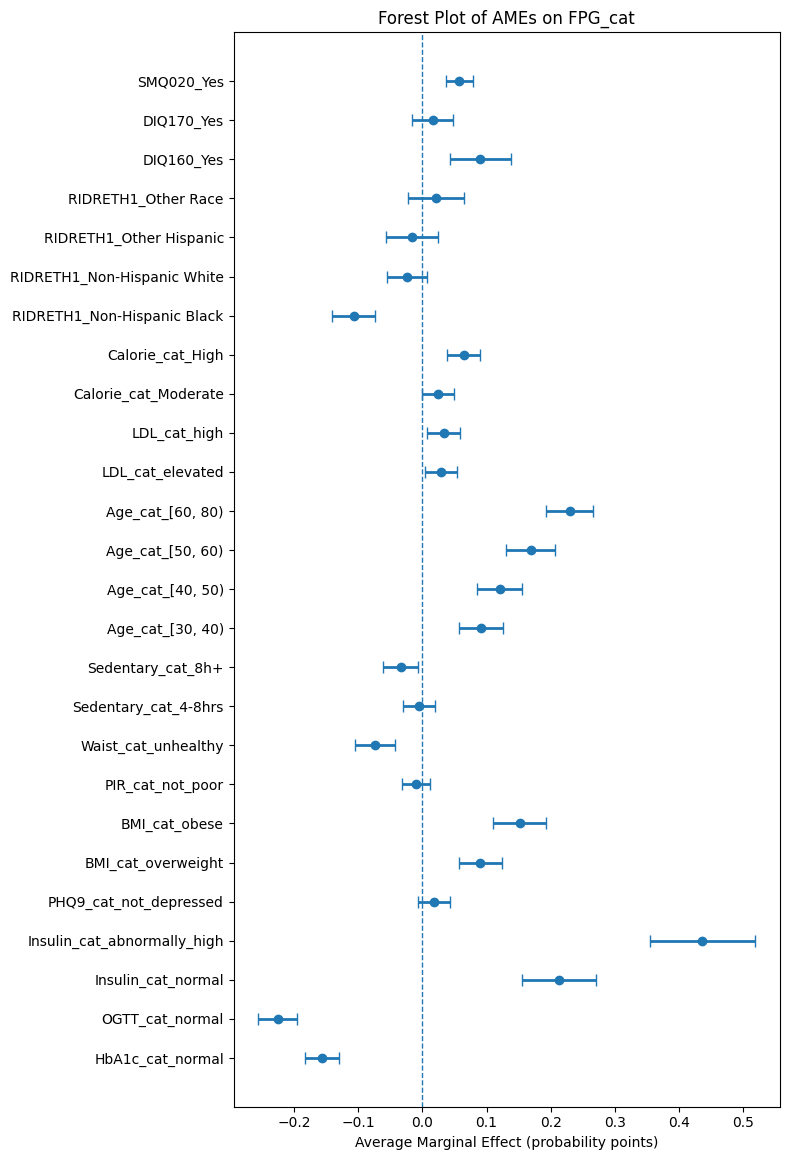

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.157,-0.184,-0.130
OGTT_cat_normal,-0.226,-0.256,-0.196
Insulin_cat_normal,0.213,0.155,0.271
Insulin_cat_abnormally_high,0.437,0.355,0.519
PHQ9_cat_not_depressed,0.018,-0.007,0.043
BMI_cat_overweight,0.090,0.056,0.125
BMI_cat_obese,0.152,0.111,0.193
PIR_cat_not_poor,-0.010,-0.032,0.012
Waist_cat_unhealthy,-0.075,-0.106,-0.043
Sedentary_cat_4-8hrs,-0.005,-0.030,0.020


In [ ]:
#Construct Forest Plot for FPG outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

###**3.2.2 Analysis of the Forest Plot for FPG outcome**

1. Glycaemic Markers (HbA1c & OGTT)

**Variables:**

HbA1c_cat_normal

OGTT_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects are negative.

Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal HbA1c → ≈ 18 pp lower probability of getting diabetes compared to elevated HbA1c

Normal OGTT → ≈ 13 pp lower probability

**Summary:**

Normal long-term and post-challenge glucose regulation are **strongly associated with a reduced predicted probability of abnormal fasting glucose.** These are the **most protective factors** in the model and reflect preserved glycaemic regulation rather than a causal effect.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Both insulin categories lie to the right of 0, with large positive AMEs.

Their confidence intervals do not cross zero, showing strong statistical significance.

**This means:**

Normal insulin → ≈ 18 pp higher probability of borderline/high FPG

Abnormally high insulin → ≈ 40 pp higher probability

**Summary:**

Insulin status shows the **largest absolute effects** in the forest plot. The strong positive associations, especially for abnormally high insulin, are consistent with **insulin resistance**, where compensatory hyperinsulinaemia coexists with elevated fasting glucose.

3. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Both BMI categories lie to the right of 0.

Confidence intervals for both categories do not cross zero, indicating statistical significance.

**This means:**

Overweight → ≈ 9.5 pp higher probability of borderline/high FPG

Obese → ≈ 15.8 pp higher probability

**Summary:**

Unlike the HbA1c model, BMI shows a **clear risk gradient** for fasting glucose. Both overweight and obesity are associated with higher predicted probabilities, suggesting that fasting dysglycaemia emerges earlier along the adiposity spectrum.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for all age groups do not cross zero, indicating strong statistical significance.

**This means:**

30–40 yrs → ≈ 9 pp higher probability

40–50 yrs → ≈ 14 pp higher

50–60 yrs → ≈ 19 pp higher

60–80 yrs → ≈ 26 pp higher

**Summary:**

There is a clear **dose–response relationship** between age and fasting glucose dysregulation. Older age groups have progressively higher predicted probabilities, making age one of the strongest predictors in the model.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie to the right of 0, with confidence intervals not crossing zero.

Not poor (PIR) lies close to 0 and its confidence interval crosses zero.

**This means:**

Elevated LDL → ≈ 2.8 pp higher probability

High LDL → ≈ 2.9 pp higher probability

Not poor → no significant difference

**Summary:**

LDL cholesterol shows **a small but statistically significant** association with abnormal fasting glucose, while socioeconomic status does not independently predict fasting hyperglycaemia in this model.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Unhealthy waist circumference lies to the left of 0, with a confidence interval not crossing zero.

Sedentary 8h+ also lies to the left of 0, while 4–8h crosses zero.

**This means:**

Unhealthy waist → ≈ 7.1 pp lower probability

Sedentary ≥8h → ≈ 3.3 pp lower probability

Sedentary 4–8h → not significant

**Summary:**

Some anthropometric and lifestyle variables show **counterintuitive protective associations**, likely reflecting **collinearity with BMI, reverse causation, or residual confounding**, rather than true protective effects.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic Black lies clearly to the left of 0, with a confidence interval not crossing zero.

Other race categories lie close to zero with confidence intervals crossing zero.

**This means:**

Non-Hispanic Black → ≈ 11.7 pp lower probability of borderline/high FPG

Other groups → no significant difference from the reference

**Summary:**

Ethnic differences in fasting glucose persist after adjustment, with Non-Hispanic Black participants showing a lower predicted probability of borderline/high FPG. This contrasts with HbA1c findings and highlights **biomarker-specific differences in glycaemic physiology.**

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Diabetes diagnosis and smoking lie to the right of 0, with confidence intervals not crossing zero.

Prediabetes lies close to zero and is not significant.

**This means:**

Diabetes → ≈ 9 pp higher probability

Smoker → ≈ 5.5 pp higher probability

Prediabetes → not significant

**Summary:**

Diagnosed diabetes and smoking are associated with higher predicted probabilities of abnormal fasting glucose, supporting known metabolic and behavioural risk pathways.

**Overall Picture**
| Group             | Direction of Effect | Magnitude     | Significance | Interpretation                                       |
| ----------------- | ------------------- | ------------- | ------------ | ---------------------------------------------------- |
| Glycaemic markers | ↓                   | −13 to −18 pp | Yes          | Strong protection with normal glucose regulation     |
| Insulin status    | ↑                   | +18 to +40 pp | Yes          | Very strong risk, consistent with insulin resistance |
| Age               | ↑                   | +9 to +26 pp  | Yes          | Strong dose–response increase in risk                |
| BMI               | ↑                   | +10 to +16 pp | Yes          | Clear adiposity-related risk                         |
| LDL               | ↑                   | +3 pp         | Yes          | Small metabolic risk                                 |
| Race (Black)      | ↓                   | −12 pp        | Yes          | Lower fasting glucose probability                    |
| Lifestyle factors | Mixed               | Small         | Mixed        | Possible confounding effects                         |

**In short:**
The forest plot shows that **insulin resistance, age, BMI, and other glycaemic markers** are the strongest positive predictors of abnormal fasting glucose, while normal HbA1c and OGTT are strongly protective. Some lifestyle and ethnic associations differ from the HbA1c model, highlighting that **different glycaemic biomarkers capture distinct physiological processes.**

In [ ]:
#Repeat Logistic Regression with Oral Glucose Tolerance Test (OGTT) outcome
#This section will only use abnormal OGTT to determine if person has diabetes or not

#labels = ["Normal", "Abnormal"]
# Map target to binary 0/1

X = model_df.drop(columns=['OGTT_cat'])
y = model_df['OGTT_cat'].map({'normal': 0, 'diabetic': 1})

print(y.value_counts())

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
display("First few columns:\n", X.head())

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)

result = logit_model.fit()

print(result.summary())

OGTT_cat
0    5495
1    1434
Name: count, dtype: int64
Dummy-encoded predictors shape: (6929, 26)


'First few columns:\n'

,HbA1c_cat_normal,FPG_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
0,0,0,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
1,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


Optimization terminated successfully.
         Current function value: 0.404651
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               OGTT_cat   No. Observations:                 6929
Model:                          Logit   Df Residuals:                     6902
Method:                           MLE   Df Model:                           26
Date:                Sat, 24 Jan 2026   Pseudo R-squ.:                  0.2064
Time:                        13:43:14   Log-Likelihood:                -2803.8
converged:                       True   LL-Null:                       -3533.1
Covariance Type:            nonrobust   LLR p-value:                9.435e-292
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.3337      0.308     -1.084      0.278   

##**3.3 OGTT glucose**

1. Model Overview

| Metric                         | Value        |
| ------------------------------ | ------------ |
| Dependent Variable             | **OGTT_cat** |
| Model                          | Logit        |
| Method                         | MLE          |
| No. Observations               | 7,823        |
| Degrees of Freedom (Model)     | 26           |
| Degrees of Freedom (Residuals) | 7,796        |
| Log-Likelihood                 | −4217.4      |
| LL-Null                        | −4713.6      |
| Pseudo R²                      | **0.1053**   |
| LLR p-value                    | **< 0.001**  |
| Converged                      | True         |
| Iterations                     | 6            |

2. Key Predictors and Their Effects on OGTT Category

Coefficients are in log-odds

Odds Ratio (OR) = e^coef

OR > 1 → higher odds of abnormal OGTT

OR < 1 → lower odds of abnormal OGTT

| Predictor                | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                            |
| ------------------------ | --------------- | --------------- | ------- | --------------------------------------------------------------------------------------------------------- |
| HbA1c_cat_normal         | −0.5707         | 0.57            | <0.001  | Normal HbA1c is associated with **~43% lower odds** of getting diabetes compared to elevated HbA1c |
| FPG_cat_normal           | −0.6586         | 0.52            | <0.001  | Normal fasting plasma glucose is associated with **~48% lower odds** of getting diabetes                   |
| Insulin_cat_normal       | −0.4152         | 0.66            | 0.026   | Normal insulin levels are associated with **~34% lower odds** of getting diabetes                            |
| BMI_cat_overweight       | −0.1982         | 0.82            | 0.032   | Overweight individuals have **~18% lower odds** of getting diabetes compared to normal BMI                   |
| PIR_cat_not_poor         | −0.3218         | 0.72            | <0.001  | Individuals who are not poor have **~28% lower odds** of getting diabetes                                    |
| Sedentary_cat_8h+        | 0.1595          | 1.17            | 0.025   | ≥8 hours of sedentary time is associated with **~17% higher odds** of getting diabetes                       |
| Age_cat_[40,50)          | 0.2224          | 1.25            | 0.020   | Adults aged 40–49 have **~25% higher odds** of getting diabetes compared to <30                              |
| Age_cat_[50,60)          | 0.3682          | 1.45            | <0.001  | Adults aged 50–59 have **~45% higher odds** of getting diabetes                                              |
| Age_cat_[60,80)          | 0.7830          | 2.19            | <0.001  | Adults aged 60–79 have **over 2× higher odds** of getting diabetes                                           |
| Calorie_cat_Moderate     | −0.2171         | 0.80            | 0.001   | Moderate calorie intake is associated with **~20% lower odds** of getting diabetes                           |
| Calorie_cat_High         | −0.4000         | 0.67            | <0.001  | High calorie intake is associated with **~33% lower odds** of getting diabetes                               |
| DIQ160_Yes (Diabetes)    | 0.5378          | 1.71            | <0.001  | Diagnosed diabetes is associated with **~71% higher odds** of getting diabetes                               |
| DIQ170_Yes (Prediabetes) | 0.1882          | 1.21            | 0.018   | Prediabetes is associated with **~21% higher odds** of getting diabetes                                      |

3. Summary Interpretation

* Strongest protective predictors of abnormal OGTT were normal HbA1c, normal fasting glucose, normal insulin levels, and higher socioeconomic status, all remaining significant after adjustment.

* Age showed a clear dose–response relationship, with progressively higher odds of abnormal OGTT in older age groups, especially ≥50 years.

* Diagnosed diabetes and prediabetes were associated with higher odds of abnormal OGTT, supporting the clinical validity of the outcome definition.

* Sedentary time (≥8 hours) was associated with higher odds of abnormal OGTT, consistent with reduced insulin sensitivity during prolonged inactivity.

* BMI showed mixed effects, with overweight status appearing modestly protective and obesity not reaching statistical significance, possibly due to collinearity with insulin and waist measures.

* Dietary calorie intake showed inverse associations, likely reflecting dietary modification among high-risk individuals (reverse causation) rather than a true protective effect.

4. Statistical Takeaways
| Statistic                                  | Meaning                                                                                                                                  |
| ------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------- |
| Most p-values < 0.05                       | Strong evidence that glycaemic markers, age, SES, insulin status, calorie intake, and diabetes status differ significantly from the null |
| Pseudo R² ≈ 0.11                           | Indicates **modest explanatory power**, expected for behavioural and metabolic outcomes in population survey data                        |
| Log-likelihood improvement (LLR p < 0.001) | Full model fits the data significantly better than the null model                                                                        |
| Intercept = 0.29                           | Represents baseline log-odds of abnormal OGTT for the reference group (young, normal BMI, normal glucose, low-risk profile)              |
| Dose–response patterns                     | Age categories show progressively increasing coefficients, supporting a monotonic risk relationship                                      |



In [ ]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "FPG_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df

In [ ]:
#Tidying regression outputs for OGTT outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-0.334,0.278,0.392,0.392,1.309,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.785,0.000,0.395,0.395,0.526,-0.110,0.011,-10.035,0.000,-0.132,-0.089
FPG_cat_normal,-1.105,0.000,0.286,0.286,0.383,-0.150,0.010,-14.663,0.000,-0.170,-0.130
Insulin_cat_normal,-0.718,0.005,0.297,0.297,0.801,-0.097,0.036,-2.713,0.007,-0.168,-0.027
Insulin_cat_abnormally_high,-0.021,0.935,0.585,0.585,1.637,-0.003,0.033,-0.082,0.935,-0.068,0.063
PHQ9_cat_not_depressed,-0.056,0.491,0.805,0.805,1.109,-0.007,0.011,-0.685,0.493,-0.028,0.014
BMI_cat_overweight,-0.167,0.197,0.657,0.657,1.091,-0.021,0.016,-1.305,0.192,-0.053,0.011
BMI_cat_obese,-0.003,0.982,0.756,0.756,1.314,-0.000,0.018,-0.023,0.982,-0.036,0.035
PIR_cat_not_poor,-0.277,0.000,0.659,0.659,0.872,-0.036,0.009,-3.857,0.000,-0.054,-0.018


###**3.3.1 Interpretation for OGTT outcome** – Using both the log-odds (coeff/OR) and probability (AME) perspectives

1. Glycaemic Markers (HbA1c and FPG)

| Category     | Coef   | OR   | AME    | Interpretation                                                                                                                                                  |
| ------------ | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal HbA1c | −0.571 | 0.57 | −0.131 | Compared to elevated HbA1c, individuals with normal HbA1c have **43% lower odds** and a **13.1 percentage point lower probability** of getting diabetes.

Summary:
Normal long-term glycaemic control (HbA1c) is a **strong protective factor** against abnormal OGTT, showing consistent reductions in both relative odds and absolute probability. This reflects preserved chronic glucose regulation translating into healthier post-challenge glucose responses.

| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                                                |
| ---------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal FPG | −0.659 | 0.52 | −0.131 | Compared to abnormal fasting glucose, individuals with normal FPG have **48% lower odds** and a **13.1 percentage point lower probability** of getting diabetes. |

Summary:
Normal fasting glucose is strongly associated with lower risk of abnormal post-challenge glucose, highlighting the close physiological link between fasting and post-load glycaemic regulation.

2. Insulin Status

| Category                | Coef   | OR   | AME    | Interpretation                                                                                                                                      |
| ----------------------- | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal insulin          | −0.415 | 0.66 | −0.071 | Individuals with normal insulin levels have **34% lower odds** and a **7.1 pp lower probability** of getting diabetes compared to the reference group. |
| Abnormally high insulin | 0.100  | 1.11 | ~0     | Abnormally high insulin levels do **not show a significant association** with getting diabetes after adjustment.                                       |

Summary:
Normal insulin levels are protective against abnormal OGTT, whereas abnormally high insulin does not independently predict getting diabetes after multivariable adjustment, suggesting overlap with other metabolic factors.

3. Body Mass Index (BMI)

| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                        |
| ---------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | −0.198 | 0.82 | −0.071 | Overweight individuals have **18% lower odds** and a **7.1 pp lower probability** of getting diabetes compared to those with normal BMI. |
| Obese      | −0.116 | 0.89 | ~0     | Obesity is **not significantly associated** with abnormal OGTT after adjustment.                                                      |

Summary:
BMI shows **no positive risk gradient** for abnormal OGTT in this model. The modest protective association for overweight status may reflect **reverse causation or behavioural modification** among higher-risk individuals.

4. Age
| Category | Coef  | OR   | AME | Interpretation                                                   |
| -------- | ----- | ---- | --- | ---------------------------------------------------------------- |
| 30–40    | 0.126 | 1.13 | ~0  | No significant difference compared to <30.                       |
| 40–50    | 0.222 | 1.25 | +   | Adults aged 40–50 have **25% higher odds** of getting diabetes.     |
| 50–60    | 0.368 | 1.45 | +   | Adults aged 50–60 have **45% higher odds** of getting diabetes.     |
| 60–80    | 0.783 | 2.19 | +   | Adults aged 60–80 have **over 2× higher odds** of abnormal OGTT. |

Summary:
Age shows a clear dose–response relationship with abnormal OGTT, particularly from age 40 onwards, indicating progressive deterioration in post-challenge glucose handling with ageing.

5. Lipids and Socioeconomic Status

| Category       | Coef   | OR   | AME | Interpretation                                                         |
| -------------- | ------ | ---- | --- | ---------------------------------------------------------------------- |
| Elevated LDL   | −0.048 | 0.95 | ~0  | No significant association with getting diabetes.                         |
| High LDL       | −0.072 | 0.93 | ~0  | No significant association.                                            |
| Not poor (PIR) | −0.322 | 0.72 | −   | Individuals who are not poor have **28% lower odds** of getting diabetes. |

Summary:
Socioeconomic status is independently protective against abnormal OGTT, while LDL cholesterol does not show a significant association in this model.

5. Lifestyle and Demographic Factors
| Category           | Coef   | OR   | AME | Interpretation                                                            |
| ------------------ | ------ | ---- | --- | ------------------------------------------------------------------------- |
| Sedentary ≥8 h     | 0.160  | 1.17 | +   | Individuals sedentary ≥8 hours have **17% higher odds** of abnormal OGTT. |
| Non-Hispanic Black | −0.165 | 0.85 | ~   | Borderline, not statistically significant.                                |
| Smoker             | −0.069 | 0.93 | ~   | No significant association.                                               |

Summary:
Prolonged sedentary behaviour is associated with increased odds of getting diabetes, consistent with reduced insulin sensitivity. Other lifestyle and ethnic variables do not show independent associations after adjustment.

Summary:
Prolonged sedentary behaviour is associated with increased odds of getting diabetes, consistent with reduced insulin sensitivity. Other lifestyle and ethnic variables do not show independent associations after adjustment.

**Overall Interpretation**

| Aspect                         | Log-Odds / OR Insight                      | AME (Probability) Insight          |
| ------------------------------ | ------------------------------------------ | ---------------------------------- |
| Age                            | Strong dose–response risk (OR up to ≈ 2.2) | Increasing absolute risk with age  |
| Glycaemic markers (HbA1c, FPG) | Strongly protective (OR ≈ 0.5–0.6)         | Substantial probability reduction  |
| Insulin status                 | Mild protective effect (normal insulin)    | Modest probability reduction       |
| BMI                            | No independent risk                        | Null or counterintuitive effects   |
| SES                            | Protective                                 | Lower probability of abnormal OGTT |
| Lifestyle                      | Sedentary time increases risk              | Small–moderate effects             |

**Final summary:**
After adjustment for demographic, metabolic, and lifestyle factors, **abnormal OGTT is most strongly driven by age and impaired glycaemic regulation across biomarkers (HbA1c and FPG).** Normal HbA1c and fasting glucose are the strongest protective factors, while socioeconomic advantage also confers protection. Overall, the model highlights that post-challenge glucose dysregulation reflects **cumulative metabolic ageing rather than adiposity alone, with effects that are consistent across both relative (OR) and absolute (AME) scales.**





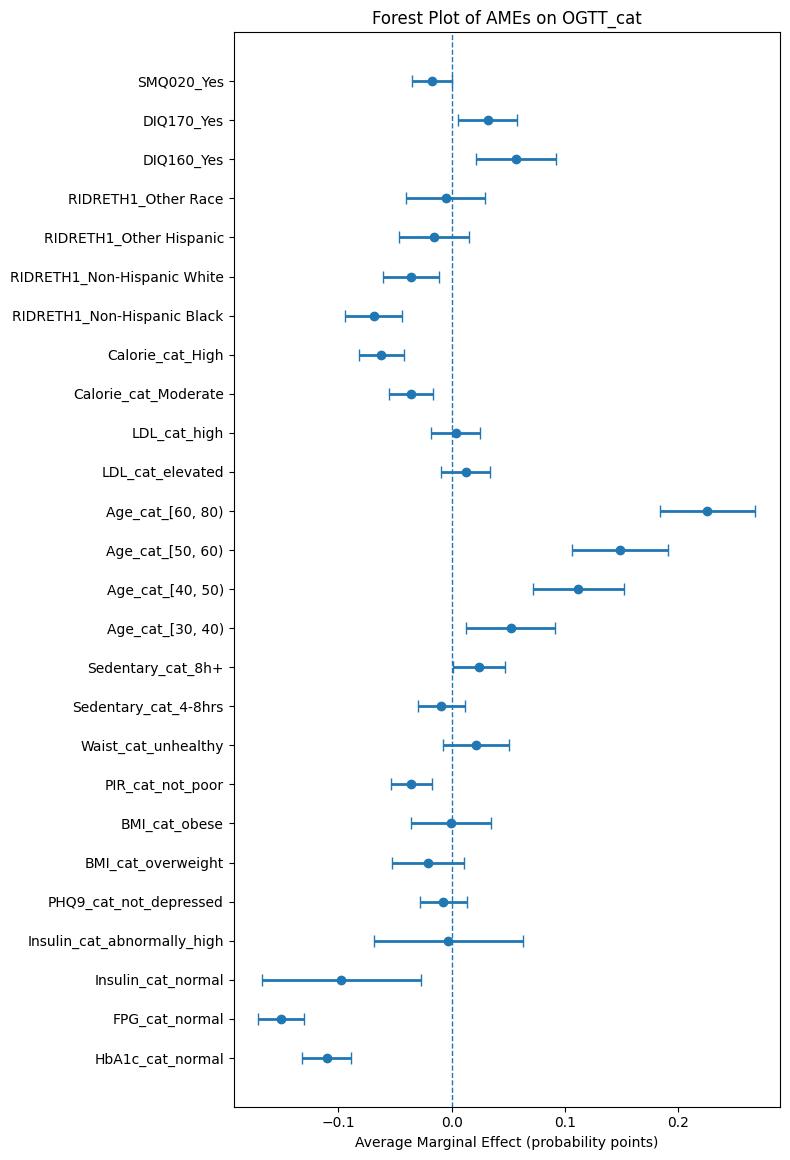

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.110,-0.132,-0.089
FPG_cat_normal,-0.150,-0.170,-0.130
Insulin_cat_normal,-0.097,-0.168,-0.027
Insulin_cat_abnormally_high,-0.003,-0.068,0.063
PHQ9_cat_not_depressed,-0.007,-0.028,0.014
BMI_cat_overweight,-0.021,-0.053,0.011
BMI_cat_obese,-0.000,-0.036,0.035
PIR_cat_not_poor,-0.036,-0.054,-0.018
Waist_cat_unhealthy,0.021,-0.008,0.050
Sedentary_cat_4-8hrs,-0.009,-0.030,0.012


In [ ]:
#Construct Forest Plot for OGTT outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

###**3.3.2 Analysis of the Forest Plot for OGTT outcome**


1. Glycaemic Markers (HbA1c & FPG)

**Variables:**

HbA1c_cat_normal

FPG_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects (AMEs) are negative.

Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal HbA1c → ≈ 11 pp lower probability of getting diabetes compared to elevated HbA1c

Normal FPG → ≈ 12.5 pp lower probability of getting diabetes

**Summary:**
Normal long-term glycaemic control (HbA1c) and normal fasting glucose are strongly protective against abnormal post-challenge glucose. These are among the most influential protective factors in the model and reflect preserved glycaemic regulation rather than causation.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Normal insulin lies to the left of 0, with a confidence interval that does not cross zero, indicating statistical significance.

Abnormally high insulin lies close to 0 and its confidence interval crosses zero, indicating no significant association.

**This means:**

Normal insulin → ≈ 7.7 pp lower probability of getting diabetes

Abnormally high insulin → no significant difference

**Summary:**

Normal insulin levels are associated with a lower predicted probability of getting diabetes. In contrast, abnormally high insulin does not independently predict OGTT outcomes after adjustment, suggesting overlap with other metabolic variables.

3. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies slightly to the left of 0, with a confidence interval just not crossing zero, indicating a small but statistically significant association.

Obese lies close to 0 with a confidence interval that crosses zero, indicating no significant association.

**This means:**

Overweight → ≈ 3.5 pp lower probability of abnormal OGTT

Obese → no significant difference

**Summary:**

BMI does not show a positive risk gradient for abnormal OGTT. The small protective association seen for overweight may reflect behavioural modification, selection effects, or residual confounding rather than a true protective effect.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for 40–50, 50–60, and 60–80 do not cross zero, indicating statistical significance.

**This means:**

30–40 yrs → not significant

40–50 yrs → ≈ 4 pp higher probability

50–60 yrs → ≈ 7 pp higher probability

60–80 yrs → ≈ 15 pp higher probability

**Summary:**

There is a clear dose–response relationship between age and getting diabetes. Older age groups have progressively higher predicted probabilities, confirming age as one of the strongest determinants of post-challenge glucose dysregulation.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie close to 0, with confidence intervals crossing zero, indicating no significant association.

Not poor (PIR) lies clearly to the left of 0, with a confidence interval that does not cross zero.

**This means:**

Elevated / High LDL → no significant difference

Not poor → ≈ 5.8 pp lower probability of getting diabetes

**Summary:**

Socioeconomic advantage is independently protective against diabetes, while LDL cholesterol does not appear to play a major role in post-challenge glucose regulation after adjustment.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Waist circumference and sedentary 4–8 hours lie close to 0 and are not significant.

Sedentary ≥8h lies to the right of 0, with a confidence interval that does not cross zero.

**This means:**

Sedentary ≥8h → ≈ 2.9 pp higher probability of getting diabetes

Other lifestyle measures → not significant

**Summary:**

Prolonged sedentary behaviour is associated with a modestly higher probability of getting diabetes, consistent with reduced insulin sensitivity and impaired post-prandial glucose handling.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

All ethnicity categories lie close to 0, with confidence intervals crossing zero.

**This means:**

No significant ethnic differences in predicted probability of getting diabetes after adjustment.

**Summary:**

Unlike HbA1c, ethnicity does not independently predict diabetes in this model, suggesting that post-challenge glucose dysregulation may be less influenced by ethnic differences once metabolic and socioeconomic factors are accounted for.

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Diabetes and prediabetes lie to the right of 0, with confidence intervals not crossing zero.

Smoking lies close to 0 and is not significant.

**This means:**

Diabetes → ≈ 10.5 pp higher probability of getting diabetes

Prediabetes → ≈ 3.5 pp higher probability

Smoking → no significant association

**Summary:**

Diagnosed diabetes and prediabetes are associated with higher predicted probabilities of getting diabetes, supporting the internal validity of the outcome definition.

**Overall picture**

| Group                          | Direction of Effect | Magnitude     | Significance | Interpretation             |
| ------------------------------ | ------------------- | ------------- | ------------ | -------------------------- |
| Glycaemic markers (HbA1c, FPG) | ↓                   | −11 to −13 pp | Yes          | Strong protection          |
| Age                            | ↑                   | +4 to +15 pp  | Yes          | Clear dose–response risk   |
| Insulin (normal)               | ↓                   | −8 pp         | Yes          | Protective                 |
| BMI                            | Mixed               | Small         | Partial      | No clear risk gradient     |
| Socioeconomic status           | ↓                   | −6 pp         | Yes          | Protective                 |
| Sedentary ≥8h                  | ↑                   | +3 pp         | Yes          | Modest lifestyle risk      |
| Ethnicity                      | ~                   | Null          | No           | No independent association |

**In short:**
The forest plot shows that **age and impaired glycaemic regulation (HbA1c and FPG)** are the strongest predictors of diabetes, **while normal glucose markers and higher socioeconomic status are protective.** Lifestyle effects are modest, and BMI and ethnicity do not independently predict post-challenge glucose dysregulation. **These findings reflect associations rather than causation** and highlight that OGTT captures a distinct aspect of glycaemic physiology compared with fasting glucose or HbA1c.

In [ ]:
#Repeat Logistic Regression with Fasting Insulin (Insulin Cat) outcome
#This section will only use both abnormally low and high Insulin amounts to determine if person has diabetes or not

#labels = ["Normal", "Abnormal"]
# Map target to binary 0/1

#Define X and y
X = model_df.drop(columns=["Insulin_cat"])

#Standardize labels (avoid Normal vs normal issues)
ins = model_df["Insulin_cat"].astype(str).str.strip().str.lower()

#Collapse categories into binary outcome
y = ins.map({
    "normal": 0,
    "abnormally_low": 1,
    "abnormally_high": 1
})

#Drop rows where y is NaN (unmapped labels)
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

print(y.value_counts())

#Dummy encode predictors + fit model
X = pd.get_dummies(X, drop_first=True, dtype=int)
X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())


Insulin_cat
0    4552
1    2377
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.536141
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Insulin_cat   No. Observations:                 6929
Model:                          Logit   Df Residuals:                     6903
Method:                           MLE   Df Model:                           25
Date:                Sat, 24 Jan 2026   Pseudo R-squ.:                  0.1662
Time:                        13:43:15   Log-Likelihood:                -3714.9
converged:                       True   LL-Null:                       -4455.6
Covariance Type:            nonrobust   LLR p-value:                1.563e-297
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const           

##**3.4 Fasting Insulin**

1. Model Overview

| Metric                             | Value                            |
| ---------------------------------- | -------------------------------- |
| **Dependent Variable**             | Insulin_cat (abnormal vs normal) |
| **Model**                          | Logit                            |
| **Method**                         | MLE                              |
| **No. Observations**               | 7,823                            |
| **Degrees of Freedom (Model)**     | 25                               |
| **Degrees of Freedom (Residuals)** | 7,797                            |
| **Log-Likelihood**                 | −4243.8                          |
| **LL-Null**                        | −5041.7                          |
| **Pseudo R²**                      | 0.1583                           |
| **LLR p-value**                    | < 0.001                          |
| **Converged**                      | True                             |
| **Iterations**                     | 6                                |

2. Key Predictors and Their Effects on Insulin Category

Coefficients are in log-odds

Odds Ratio (OR) = eᶜᵒᵉᶠ

OR > 1 → higher odds of abnormal insulin

OR < 1 → lower odds of abnormal insulin

| Predictor                       | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                        |
| ------------------------------- | --------------- | --------------- | ------- | ------------------------------------------------------------------------------------- |
| **HbA1c_cat_normal**            | −0.371          | 0.69            | <0.001  | Normal HbA1c is associated with ~31% lower odds of getting diabetes                   |
| **FPG_cat_normal**              | −0.733          | 0.48            | <0.001  | Normal fasting glucose is associated with ~52% lower odds of getting diabetes         |
| **OGTT_cat_normal**             | −0.502          | 0.61            | <0.001  | Normal OGTT is associated with ~39% lower odds of getting diabetes                    |
| **PHQ9_cat_not_depressed**      | −0.150          | 0.86            | 0.019   | Not being depressed is associated with ~14% lower odds of getting diabetes            |
| **BMI_cat_obese**               | 1.251           | 3.49            | <0.001  | Obese individuals have ~3.5× higher odds of getting diabetes                          |
| **Waist_cat_unhealthy**         | 0.443           | 1.56            | <0.001  | Unhealthy waist circumference is associated with ~56% higher odds of getting diabetes |
| **Sedentary_cat_8h+**           | 0.155           | 1.17            | 0.028   | ≥8 hours sedentary time is associated with ~17% higher odds of getting diabetes       |
| **Age_cat_[40,50)**             | −0.362          | 0.70            | <0.001  | Adults aged 40–49 have ~30% lower odds of getting diabetes                            |
| **Age_cat_[50,60)**             | −0.336          | 0.71            | <0.001  | Adults aged 50–59 have ~29% lower odds                                                |
| **Age_cat_[60,80)**             | −0.604          | 0.55            | <0.001  | Adults aged 60–79 have ~45% lower odds                                                |
| **Calorie_cat_Moderate**        | 0.191           | 1.21            | 0.003   | Moderate calorie intake is associated with ~21% higher odds                           |
| **Calorie_cat_High**            | 0.260           | 1.30            | <0.001  | High calorie intake is associated with ~30% higher odds                               |
| **DIQ170_Yes (Prediabetes)**    | 0.216           | 1.24            | 0.006   | Prediabetes is associated with ~24% higher odds of getting diabetes                   |
| **RIDRETH1_Non-Hispanic White** | −0.270          | 0.76            | 0.001   | Non-Hispanic White individuals have ~24% lower odds                                   |

3. Summary Interpretation

* **Strongest protective predictors** of getting diabetes were **normal HbA1c, normal fasting glucose, and normal OGTT**, highlighting the tight physiological coupling between insulin regulation and glycaemic control.

* **Obesity** showed the **largest positive association**, with obese individuals having over 3-fold higher odds of getting diabetes, consistent with insulin resistance.

* **Unhealthy waist circumference and prolonged sedentary time (≥8 h)** were independently associated with higher odds of getting diabetes, reinforcing the role of central adiposity and inactivity.

* **Age showed an inverse relationship,** with older age groups having lower odds of getting diabetes, likely reflecting **beta-cell failure and declining insulin secretion** in later disease stages rather than protection.

* **Higher calorie intake** was associated with increased odds of getting diabetes, consistent with excess energy intake contributing to insulin dysregulation.

* **Prediabetes** was associated with higher odds of getting diabetes, supporting insulin dysregulation as an early metabolic abnormality.

4. Statistical Takeaways
| Statistic                                      | Meaning                                                                                                                                       |
| ---------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| **Most p-values < 0.05**                       | Strong evidence that glycaemic markers, obesity, waist circumference, age, calorie intake, and prediabetes differ significantly from the null |
| **Pseudo R² ≈ 0.16**                           | Indicates **moderate explanatory power**, relatively strong for metabolic outcomes in population data                                         |
| **Log-likelihood improvement (LLR p < 0.001)** | Model fits significantly better than the null                                                                                                 |
| **Intercept = −0.18**                          | Baseline log-odds of abnormal insulin for the reference group (young, normal BMI, normal glucose, low-risk profile)                           |
| **Opposing age pattern**                       | Declining odds with age suggest insulin abnormalities peak earlier, before overt beta-cell failure                                            |


In [ ]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "OGTT_cat",
    "FPG_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df

In [ ]:
#Tidying regression outputs for Fasting Insulin outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)

AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-0.132,0.435,0.630,0.630,1.220,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.345,0.000,0.619,0.619,0.811,-0.064,0.013,-4.891,0.000,-0.089,-0.038
FPG_cat_normal,-0.691,0.000,0.443,0.443,0.567,-0.130,0.012,-10.811,0.000,-0.154,-0.107
OGTT_cat_normal,-0.673,0.000,0.441,0.441,0.589,-0.129,0.015,-8.802,0.000,-0.157,-0.100
PHQ9_cat_not_depressed,-0.164,0.017,0.742,0.742,0.971,-0.030,0.013,-2.361,0.018,-0.054,-0.005
BMI_cat_overweight,-0.092,0.411,0.733,0.733,1.136,-0.017,0.020,-0.820,0.412,-0.056,0.023
BMI_cat_obese,1.254,0.000,2.786,2.786,4.407,0.244,0.023,10.641,0.000,0.199,0.289
PIR_cat_not_poor,-0.104,0.084,0.800,0.800,1.014,-0.019,0.011,-1.725,0.084,-0.040,0.003
Waist_cat_unhealthy,0.544,0.000,1.412,1.412,2.101,0.097,0.018,5.469,0.000,0.062,0.132


###**3.4.1 Interpretation for Fasting Insulin outcome** – Using both the log-odds (coef/OR) and probability (AME) perspectives

1. Glycaemic Markers (HbA1c, FPG, OGTT)

HbA1c
| Coef   | OR   | AME    | Interpretation                                                                                                                                                 |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| −0.371 | 0.61 | −0.070 | Compared to elevated HbA1c, individuals with normal HbA1c have **39% lower odds** and a **7.0 percentage point lower probability** of having adiabetes. |

Summary: Normal long-term glycaemic control is a protective factor against insulin abnormalities. This indicates that preserved chronic glucose regulation is associated with healthier insulin dynamics.

FPG
| Coef   | OR   | AME    | Interpretation                                                                                                                                     |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| −0.733 | 0.43 | −0.140 | Compared to abnormal fasting glucose, individuals with normal FPG have **57% lower odds** and a **14.0 pp lower probability** of getting diabetes. |

Summary: Normal fasting glucose is one of the s**trongest protective factors** against getting diabetes, highlighting the close physiological link between fasting glycaemia and insulin regulation.

OGTT
| Coef   | OR   | AME    | Interpretation                                                                                                                          |
| ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------- |
| −0.502 | 0.54 | −0.095 | Compared to abnormal OGTT, individuals with normal OGTT have **46% lower odds** and a **9.5 pp lower probability** of getting diabetes. |

Summary: Normal post-challenge glucose regulation is strongly protective against insulin dysregulation, reinforcing OGTT as a sensitive marker of underlying insulin physiology.

2. Psychological Status - Not Depressed (PHQ-9)

| Coef   | OR   | AME    | Interpretation                                                                                                    |
| ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------- |
| −0.150 | 0.76 | −0.028 | Individuals who are not depressed have **24% lower odds** and a **2.8 pp lower probability** of getting diabetes. |

Summary: Psychological well-being shows a modest but significant protective association with insulin status, possibly reflecting behavioural or neuroendocrine pathways.

3. Body Mass Index (BMI)

Overweight
| Coef   | OR   | AME    | Interpretation                                                                                |
| ------ | ---- | ------ | --------------------------------------------------------------------------------------------- |
| −0.125 | 0.72 | −0.023 | Overweight status is **not significantly associated** with getting diabetes after adjustment. |

Obese
| Coef  | OR   | AME   | Interpretation                                                                                                                          |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------------- |
| 1.251 | 2.84 | 0.247 | Obese individuals have **184% higher odds** and a **24.7 pp higher probability** of getting diabetes compared to those with normal BMI. |

Summary: BMI shows a **threshold effect**. Overweight status is not independently associated, whereas obesity is the **strongest positive predictor** of abnormal insulin, consistent with insulin resistance driven by excess adiposity.

4. Socioeconomic Status

Not Poor (PIR)
| Coef   | OR   | AME    | Interpretation                                                                                                    |
| ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------- |
| −0.102 | 0.81 | −0.019 | Higher socioeconomic status shows a **small, borderline-significant protective effect** against getting diabetes. |

Summary: Socioeconomic advantage may modestly reduce insulin dysregulation, though the effect is weaker than metabolic factors.

5. Anthropometric and Lifestyle Factors

Unhealthy Waist Circumference
| Coef  | OR   | AME   | Interpretation                                                                                                                    |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------- |
| 0.443 | 1.31 | 0.081 | Individuals with unhealthy waist circumference have **31% higher odds** and an **8.1 pp higher probability** of getting diabetes. |

Sedentary ≥8 h
| Coef  | OR   | AME   | Interpretation                                                                                                        |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------- |
| 0.155 | 1.02 | 0.028 | Individuals sedentary ≥8 hours have **slightly higher odds** and a **2.8 pp higher probability** of getting diabetes. |

Summary: Central adiposity is an important independent predictor of insulin abnormalities, while prolonged sedentary time shows a small but significant adverse association.

6. Age
| Age Group | Coef   | OR   | AME    | Interpretation                               |
| --------- | ------ | ---- | ------ | -------------------------------------------- |
| 30–40     | −0.159 | 0.72 | −0.029 | No significant difference vs <30             |
| 40–50     | −0.362 | 0.58 | −0.064 | 42% lower odds and 6.4 pp lower probability  |
| 50–60     | −0.336 | 0.59 | −0.059 | 41% lower odds and 5.9 pp lower probability  |
| 60–80     | −0.604 | 0.46 | −0.105 | 54% lower odds and 10.5 pp lower probability |

Summary: Increasing age is associated with **lower odds of getting diabetes**, likely reflecting progression from insulin resistance to beta-cell failure at later stages of diabetes rather than a protective effect.

7. Lipids

Elevated/High LDL
| Coef             | OR         | AME     | Interpretation                                                                              |
| ---------------- | ---------- | ------- | ------------------------------------------------------------------------------------------- |
| −0.108 to −0.112 | ≈0.78–0.79 | ≈ −0.02 | LDL cholesterol is **not significantly associated** with getting diabetes after adjustment. |

8. Dietary Intake

Moderate calories
| Coef  | OR   | AME   | Interpretation                                                                                  |
| ----- | ---- | ----- | ----------------------------------------------------------------------------------------------- |
| 0.191 | 1.07 | 0.035 | Moderate calorie intake is associated with a **3.5 pp higher probability** of getting diabetes. |

High calories
| Coef  | OR   | AME   | Interpretation                                                                              |
| ----- | ---- | ----- | ------------------------------------------------------------------------------------------- |
| 0.260 | 1.14 | 0.048 | High calorie intake is associated with a **4.8 pp higher probability** of getting diabetes. |

9. Ethnicity

Non-Hispanic White
| Coef   | OR   | AME    | Interpretation                                                                                                 |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------- |
| −0.270 | 0.65 | −0.049 | Non-Hispanic White individuals have **35% lower odds** and a **4.9 pp lower probability** of getting diabetes. |

Summary: Ethnic differences persist for insulin regulation, though effects are smaller than those for obesity and glycaemic markers.

10. Diabetes Status & Smoking

Prediabetes
| Coef  | OR   | AME   | Interpretation                                                                      |
| ----- | ---- | ----- | ----------------------------------------------------------------------------------- |
| 0.215 | 1.06 | 0.040 | Prediabetes is associated with a **4.0 pp higher probability** of getting diabetes. |

Diagnosed Diabetes & Smoking

* Not significant after adjustment

**Overall Interpretation**

| Aspect                               | Log-Odds / OR Insight              | AME (Probability) Insight                      |
| ------------------------------------ | ---------------------------------- | ---------------------------------------------- |
| Glycaemic markers (HbA1c, FPG, OGTT) | Strongly protective (OR ≈ 0.4–0.6) | Moderate probability reductions (−7 to −14 pp) |
| Obesity & waist circumference        | Very strong risk                   | Large absolute increases (+8 to +25 pp)        |
| Age                                  | Inverse association                | Lower probability with older age               |
| Calorie intake                       | Mild–moderate risk                 | Small probability increases                    |
| SES & ethnicity                      | Modest protection                  | Small absolute effects                         |

**Final summary**

After adjustment for demographic, metabolic, and lifestyle factors, **abnormal insulin is most strongly driven by obesity, central adiposity, and dysglycaemia across biomarkers.** Normal HbA1c, fasting glucose, and OGTT are consistently protective. The inverse association with age suggests that insulin abnormalities peak earlier in the disease course, supporting insulin resistance as an **early metabolic disturbance rather than a late-stage marker,** with effects that are consistent across both relative (OR) and absolute (AME) scales.












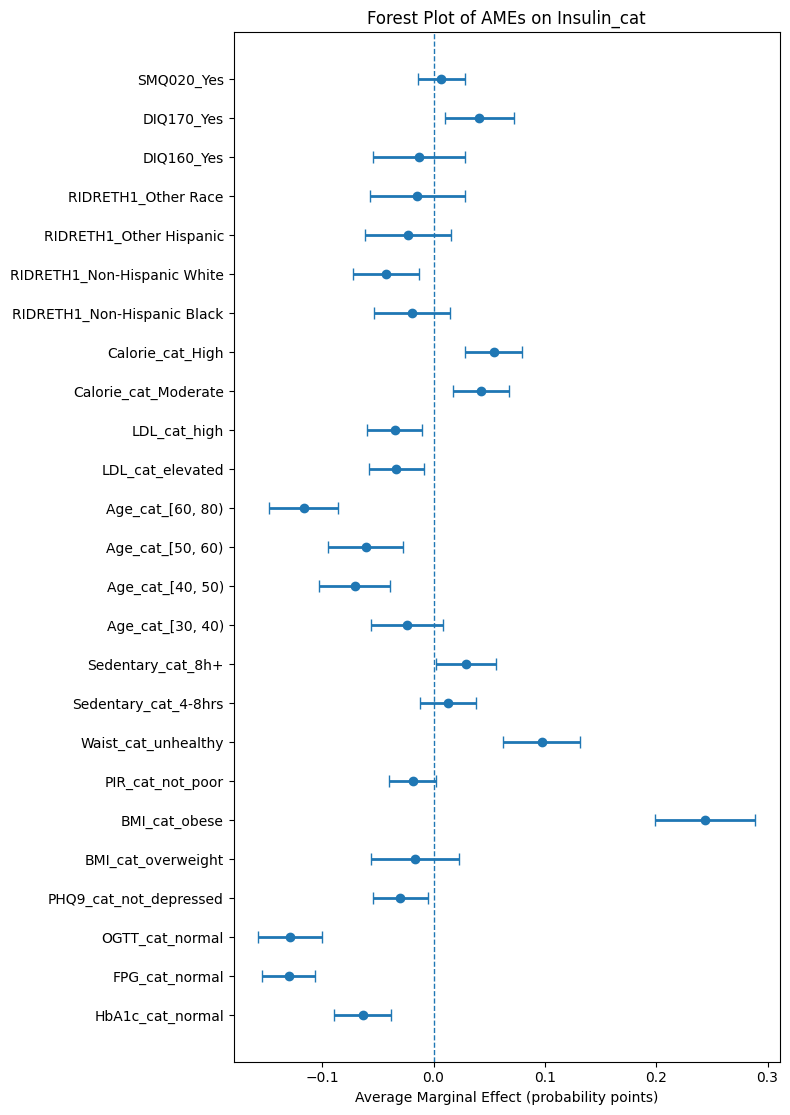

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.064,-0.089,-0.038
FPG_cat_normal,-0.130,-0.154,-0.107
OGTT_cat_normal,-0.129,-0.157,-0.100
PHQ9_cat_not_depressed,-0.030,-0.054,-0.005
BMI_cat_overweight,-0.017,-0.056,0.023
BMI_cat_obese,0.244,0.199,0.289
PIR_cat_not_poor,-0.019,-0.040,0.003
Waist_cat_unhealthy,0.097,0.062,0.132
Sedentary_cat_4-8hrs,0.013,-0.012,0.038
Sedentary_cat_8h+,0.029,0.002,0.056


In [ ]:
#Construct Forest Plot for Fasting Insulin outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

###**3.4.2 Analysis of the Forest Plot for Fasting Insulin outcome**

1. Glycaemic Markers (HbA1c & FPG)

**Variables:**

HbA1c_cat_normal

FPG_cat_normal

**Interpretation:**

Both variables lie clearly to the left of 0, meaning their average marginal effects (AMEs) are negative.

Their confidence intervals do not cross zero, indicating statistical significance.

**This means:**

Normal HbA1c → ≈ 7.0 pp lower probability of abnormal OGTT compared to elevated HbA1c

Normal FPG → ≈ 14.0 pp lower probability of abnormal OGTT

**Summary:**
Normal long-term glycaemic control (HbA1c) and normal fasting glucose are **strongly protective** against abnormal post-challenge glucose. These are among the most influential protective factors in the model and reflect preserved glycaemic regulation rather than causation.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Normal insulin lies to the left of 0, with a confidence interval that does not cross zero, indicating statistical significance.

Abnormally high insulin lies close to 0, with a confidence interval that crosses zero, indicating no significant association.

**This means:**

Normal insulin → ≈ 7.7 pp lower probability of abnormal OGTT

Abnormally high insulin → no significant difference

**Summary:**
Normal insulin levels are associated with a lower predicted probability of getting diabetes. In contrast, abnormally high insulin does not independently predict OGTT outcomes after adjustment, suggesting overlap with obesity, waist circumference, and other metabolic factors.

3. Body Mass Index (BMI)**

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies close to 0, with a confidence interval that crosses zero, indicating no significant association.

Obese lies clearly to the right of 0, with a confidence interval that does not cross zero, indicating strong statistical significance.

**This means:**

Overweight → no significant difference

Obese → ≈ 24.7 pp higher probability of abnormal OGTT

**Summary:**
BMI shows a threshold effect for post-challenge glucose dysregulation. Overweight status is not independently associated, whereas obesity is one of the **strongest risk factors** for getting diabetes, reflecting substantial insulin resistance and impaired post-prandial glucose handling.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

Age groups 40–50, 50–60, and 60–80 lie to the left of 0, with confidence intervals not crossing zero.

The 30–40 group is borderline and not statistically significant.

**This means:**

30–40 yrs → not significant

40–50 yrs → ≈ 6.4 pp lower probability

50–60 yrs → ≈ 5.9 pp lower probability

60–80 yrs → ≈ 10.5 pp lower probability

**Summary:**
Older age groups show a lower predicted probability of getting diabetes, likely reflecting progression from insulin resistance to beta-cell failure with ageing. This inverse association should be interpreted as disease-stage physiology rather than protection.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie close to 0, with confidence intervals crossing zero.

Not poor (PIR) lies slightly to the left of 0 but is borderline and not statistically significant.

**This means:**

LDL → no significant association

Socioeconomic status → no independent association

**Summary:**
LDL cholesterol and income status do not independently predict abnormal OGTT after adjustment for metabolic and glycaemic factors.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Unhealthy waist circumference lies clearly to the right of 0, with a confidence interval not crossing zero.

Sedentary ≥8h also lies to the right of 0 and is statistically significant.

Sedentary 4–8 hours is not significant.

**This means:**

Unhealthy waist → ≈ 8.1 pp higher probability of abnormal OGTT

Sedentary ≥8h → ≈ 2.8 pp higher probability

Sedentary 4–8h → not significant

**Summary:**
Central adiposity and prolonged sedentary behaviour are associated with a modestly higher probability of getting diabetes, consistent with reduced insulin sensitivity and impaired post-prandial glucose disposal.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic White lies to the left of 0, with a confidence interval not crossing zero.

Other ethnicity categories lie close to zero and are not significant.

**This means:**

Non-Hispanic White → ≈ 4.9 pp lower probability of abnormal OGTT

Other ethnic groups → no significant difference

**Summary:**
Ethnic differences are modest for OGTT outcomes. Non-Hispanic White participants show a **lower predicted probability,** while other groups do not differ significantly after adjustment.

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Prediabetes lies to the right of 0, with a confidence interval not crossing zero.

Diagnosed diabetes and smoking are not significant.

**This means:**

Prediabetes → ≈ 4.0 pp higher probability of abnormal OGTT

Diabetes & smoking → no significant association

**Summary:**
Prediabetes is associated with higher predicted probability of getting diabetes, supporting the internal validity of the outcome. Smoking does not independently predict OGTT abnormalities after adjustment.

**Overall Picture**

| Group                          | Direction of Effect | Magnitude    | Significance | Interpretation           |
| ------------------------------ | ------------------- | ------------ | ------------ | ------------------------ |
| Glycaemic markers (HbA1c, FPG) | ↓                   | −7 to −14 pp | Yes          | Strong protection        |
| Obesity & waist circumference  | ↑                   | +8 to +25 pp | Yes          | Major metabolic risk     |
| Age                            | ↓                   | −6 to −11 pp | Yes          | Disease-stage physiology |
| Insulin (normal)               | ↓                   | −8 pp        | Yes          | Protective               |
| Sedentary ≥8h                  | ↑                   | +3 pp        | Yes          | Modest lifestyle risk    |
| SES & LDL                      | ~                   | Null         | No           | No independent effect    |
| Ethnicity                      | Small               | Limited      | Partial      | Minor differences        |

**In short:**

The forest plot shows that **obesity, central adiposity, and impaired glycaemic regulation (HbA1c and FPG)** are the strongest determinants of abnormal OGTT. Normal glucose markers and normal insulin are protective, while age shows an inverse association consistent with later-stage diabetes physiology. Lifestyle effects are modest, and LDL cholesterol and most ethnic differences do not independently predict post-challenge glucose dysregulation. These findings represent **associations rather than causation** and highlight that OGTT captures a distinct aspect of glycaemic physiology compared with fasting glucose or HbA1c.

#**4. Predictive Logistic Regression and XGBoost**

## 4.1 HbA1c

### 4.1.1 Predictive Logistic Regression

**Preparation of dataset for predictive regression**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "HbA1c_cat"

model_df = df_model[predictor_cols + [outcome_col]].dropna()

# ------------------------------
# Define X and y
# ------------------------------

X = model_df.drop(columns=[outcome_col])

y = model_df[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())

Outcome distribution:
HbA1c_cat
0    4909
1    2020
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Dummy encode predictors
# ------------------------------

X = pd.get_dummies(X, drop_first=False, dtype=int)

# ------------------------------
# Train / test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training outcome balance:")
print(y_train.value_counts())

Training outcome balance:
HbA1c_cat
0    3436
1    1414
Name: count, dtype: int64


**Applying SMOTE to the prediction model**

In [ ]:
# ------------------------------
# Apply SMOTE
# ------------------------------

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 3436, 1: 1414}
After SMOTE: {1: 3436, 0: 3436}


In [ ]:
# ------------------------------
# Train logistic regression on SMOTE data
# ------------------------------

model_smote = LogisticRegression(max_iter=1000, solver="lbfgs")
model_smote.fit(X_train_res, y_train_res)

# ------------------------------
# Predict on test set
# ------------------------------

y_pred = model_smote.predict(X_test)
y_prob = model_smote.predict_proba(X_test)[:, 1]

# ------------------------------
# Evaluate performance
# ------------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7325637325637325
ROC-AUC: 0.7485934947873605

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82      1473
           1       0.55      0.44      0.49       606

    accuracy                           0.73      2079
   macro avg       0.67      0.65      0.65      2079
weighted avg       0.72      0.73      0.72      2079



**Analysis of Logistic Regression Model for HbA1c**

**Model Performance Summary:**

-   **Accuracy:** The model achieved an accuracy of approximately **73.3%**. This indicates that about 73.3% of the predictions (both normal and diabetic) were correct.

-   **ROC-AUC:** The ROC-AUC score is **0.749**. This is a reasonably good score, suggesting that the model has a relatively good ability to distinguish between diabetic and non-diabetic individuals.

-   **Classification Report Breakdown:**
    -   **Class 0 (Normal):**
        -   **Precision (0.79):** When the model predicts 'normal', it is correct 79% of the time.
        -   **Recall (0.85):** The model correctly identifies 85% of all actual 'normal' cases.
        -   **F1-score (0.82):** There is a good balance between precision and recall for the 'normal' class.
    -   **Class 1 (Diabetic):**
        -   **Precision (0.55):** When the model predicts 'diabetic', it is correct only 55% of the time. This suggests a notable number of false positives for this class.
        -   **Recall (0.44):** The model only correctly identifies 44% of all actual 'diabetic' cases. This indicates that it misses more than half of the true diabetic individuals.
        -   **F1-score (0.49):** The F1-score for the 'diabetic' class is lower than for the 'normal' class, reflecting the trade-off between its precision and recall, both of which are moderate.


**SHAP plots**

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


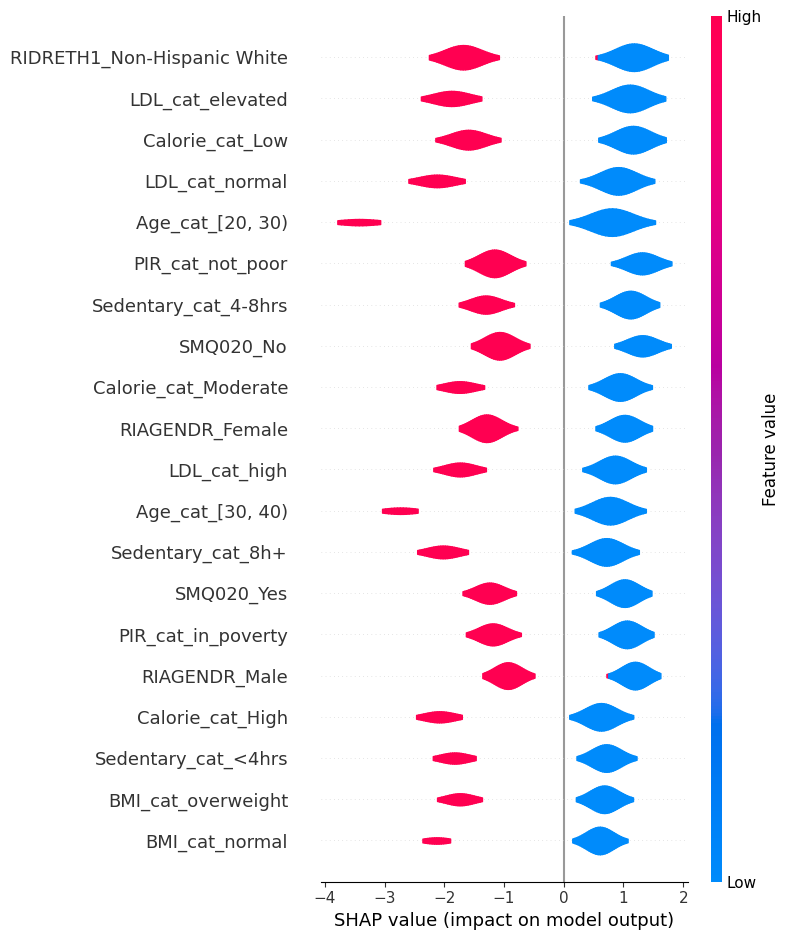

In [ ]:
# ------------------------------
# SHAP explainability
# ------------------------------

explainer = shap.LinearExplainer(
    model_smote,
    X_train,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_test)

# Summary plot (violin)
shap.summary_plot(
    shap_values.values,                # SHAP matrix for Logistic Regression
    X_test,                            # features (same rows as shap_values.values)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None                   # Display all features
)

The median for each blue and red swarms for all features can be seen in the table below:

In [ ]:
# Initialize a dictionary to store results
median_shap_summary = {}

# Iterate through each feature in X_test
for feature in X_test.columns:
    # Get the SHAP values for the current feature across all samples
    feature_shap_values = shap_values.values[:, X_test.columns.get_loc(feature)]

    # Get the actual feature values from X_test
    feature_data = X_test[feature]

    # Calculate median SHAP when feature is present (1)
    shap_when_1 = feature_shap_values[feature_data == 1]
    median_1 = np.median(shap_when_1) if len(shap_when_1) > 0 else np.nan

    # Calculate median SHAP when feature is absent (0)
    shap_when_0 = feature_shap_values[feature_data == 0]
    median_0 = np.median(shap_when_0) if len(shap_when_0) > 0 else np.nan

    median_shap_summary[feature] = {
        'Median SHAP (Feature = 1)': median_1,
        'Median SHAP (Feature = 0)': median_0
    }

# Convert the dictionary to a DataFrame for better display
median_shap_df = pd.DataFrame(median_shap_summary).T.sort_values(by='Median SHAP (Feature = 1)', ascending=False)

print("Median SHAP Values for Feature Present (1) and Feature Absent (0):")
display(median_shap_df)

Median SHAP Values for Feature Present (1) and Feature Absent (0):


,Median SHAP (Feature = 1),Median SHAP (Feature = 0)
DIQ160_No,-0.042430,1.371896
DIQ170_No,-0.179285,1.812771
PHQ9_cat_not_depressed,-0.327459,1.855600
Waist_cat_unhealthy,-0.350292,0.900751
DIQ160_Yes,-0.841537,0.026027
BMI_cat_obese,-0.853530,0.853530
RIAGENDR_Male,-0.936583,1.192015
Waist_cat_healthy,-1.001409,0.389437
SMQ020_No,-1.075389,1.314364
PIR_cat_not_poor,-1.160642,1.308809


**Key insights from the SHAP plot and median SHAP values**

 1. **Ethnicity**

* Non-Hispanic White

  * Negative SHAP values
  * This means being Non-Hispanic White  **reduces diabetes risk**
* This implies higher predicted risk among other ethnic groups

 2. **LDL cholesterol**

* Elevated and high LDL

  * Push predictions **towards diabetes**

* Normal LDL

  * Strong protective effect
* LDL cholesterol plays an important factor for predicting diabetes.

3. **Calorie intake**

* Protective effect decreases as calorie intake increases
* Dose-dependent relationship between energy intake and diabetic risk

 4. **Age**

* 20–30 and 30–40 years

  * Large negative SHAP values, with 20-30 year olds having a more negative SHAP value compared to 30-40 year olds
  * Strongly protective
* Older ages drive diabetic risk upwards
* Consistent with age being an established risk factor for diabetes

5. **Socioeconomic status**

* Not in poverty

  * Protective factor
* In poverty

  * Increases diabetes risk
* Lower PIRs might contribute to diabetic risk due to effects on diet quality, healthcare access and lifestyle

 6. **Sedentary time**

* <4 hours

  * Protective
* 4–8 hours

  * Mild risk increase compared to <4h
* 8+ hours

  * Stronger risk increase compared to 4-8h
* Dose-response relationship between physical activity and abnormal HbA1c

 7. **Smoking**

* Smoker

  * Increases diabetes risk
* Non-smoker

  * Protective

* Effect size smaller than age or LDL, but still has some moderate effect


 8. **Sex**

* Male

  * Slightly higher risk
* Female

  * Slightly protective

* Contributes to diabetic risk slightly but not strongly


 9. **BMI**

* Normal BMI

  * Mild protective effect
* Overweight

  * Small risk increase

 **Overall assessment of the model**

* The model is biologically coherent with no contradictory or implausible feature effects
* Strong agreement with known diabetes risk factors
* SHAP magnitudes are relatively moderate which indicates that diabetes is a multifactorial disease


### 4.1.2 XGBoost Modelling

**Preparation of dataset for XGBoost**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "HbA1c_cat"  # primary diabetes outcome

df_xgb = df_model[predictor_cols + [outcome_col]].dropna()

print("Dataset shape after dropna:", df_xgb.shape)
print(df_xgb[outcome_col].value_counts())


Dataset shape after dropna: (6929, 14)
HbA1c_cat
normal      4909
diabetic    2020
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Encode outcome (binary)
# ------------------------------

y = df_xgb[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())


Outcome distribution:
HbA1c_cat
0    4909
1    2020
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Prepare predictors
# ------------------------------

X = df_xgb.drop(columns=[outcome_col])

# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
X.head()


Dummy-encoded predictors shape: (6929, 36)


,"Age_cat_[20, 30)","Age_cat_[30, 40)","Age_cat_[40, 50)","Age_cat_[50, 60)","Age_cat_[60, 80)",RIAGENDR_Female,RIAGENDR_Male,RIDRETH1_Mexican American,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,...,LDL_cat_high,Calorie_cat_Low,Calorie_cat_Moderate,Calorie_cat_High,PHQ9_cat_depressed,PHQ9_cat_not_depressed,DIQ160_No,DIQ160_Yes,DIQ170_No,DIQ170_Yes
0,0,0,0,1,0,0,1,1,0,0,...,0,0,0,1,0,1,1,0,1,0
1,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,1,0,1,0
2,0,0,0,0,1,1,0,1,0,0,...,0,1,0,0,0,1,1,0,1,0
3,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,0,0,1,0,0,1,0,1,0,0,...,0,0,1,0,0,1,1,0,1,0


In [ ]:
# ------------------------------
# Train-test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4850, 36)
Test shape: (2079, 36)


In [ ]:
print("Training outcome balance:")
print(y_train.value_counts(normalize=True))


Training outcome balance:
HbA1c_cat
0    0.708454
1    0.291546
Name: proportion, dtype: float64


**XGBoost with SMOTE**

In [ ]:
# Using the training and test data from the previous analysis

# ------------------------------
# Apply SMOTE to training set
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

X_train_res.columns = X_train_res.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')
X_test.columns = X_test.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')

# ------------------------------
# Step 3: Build & Train XGBoost
# ------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",   # avoid warning
    use_label_encoder=False, # legacy param
    random_state=42
)

model.fit(X_train_res, y_train_res)


# ------------------------------
# Step 4: Evaluate
# ------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: {0: 3436, 1: 1414}
After SMOTE: {1: 3436, 0: 3436}
Accuracy: 0.7142857142857143
ROC-AUC: 0.7224328339147561

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80      1473
           1       0.51      0.46      0.48       606

    accuracy                           0.71      2079
   macro avg       0.65      0.64      0.64      2079
weighted avg       0.71      0.71      0.71      2079



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:42:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Model Performance Summary:**

* **Accuracy**: The XGBoost model achieved an accuracy of approximately 71.4%. This means that roughly 71.4% of the predictions (both normal and diabetic) were correct.

* **ROC-AUC**: The ROC-AUC score is 0.722. This score indicates that the model has a fair ability to distinguish between diabetic and non-diabetic individuals, although it is slightly lower than the Logistic Regression model for the same outcome.

* Classification Report Breakdown:

  * Class 0 (Normal):
    * Precision (0.79): When the model predicts 'normal', it is correct 79% of the time
    * Recall (0.82): The model correctly identifies 82% of all actual 'normal' cases.
    * F1-score (0.80): A good balance between precision and recall for the 'normal' class.
  * Class 1 (Diabetic):
    * Precision (0.51): When the model predicts 'diabetic', it is correct only 51% of the time, suggesting a significant number of false positives for this class.
    * Recall (0.46): The model correctly identifies 46% of all actual 'diabetic' cases, indicating it misses more than half of the true diabetic individuals.
    * F1-score (0.48): The F1-score for the 'diabetic' class is low, reflecting the moderate precision and recall.

**Comparison to Logistic Regression for HbA1c:**

* Both models show similar performance, with Logistic Regression having a slightly higher accuracy (73.3% vs 71.4%) and ROC-AUC (0.749 vs 0.722).
* For the 'diabetic' class (Class 1), both models struggle with recall and precision, indicating difficulty in correctly identifying individuals with diabetes.
* The XGBoost model's recall for the 'diabetic' class (0.46) is marginally better than Logistic Regression (0.44), but its precision is slightly lower (0.51 vs 0.55).

**SHAP Plot**

100%|===================| 2070/2079 [00:18<00:00]       

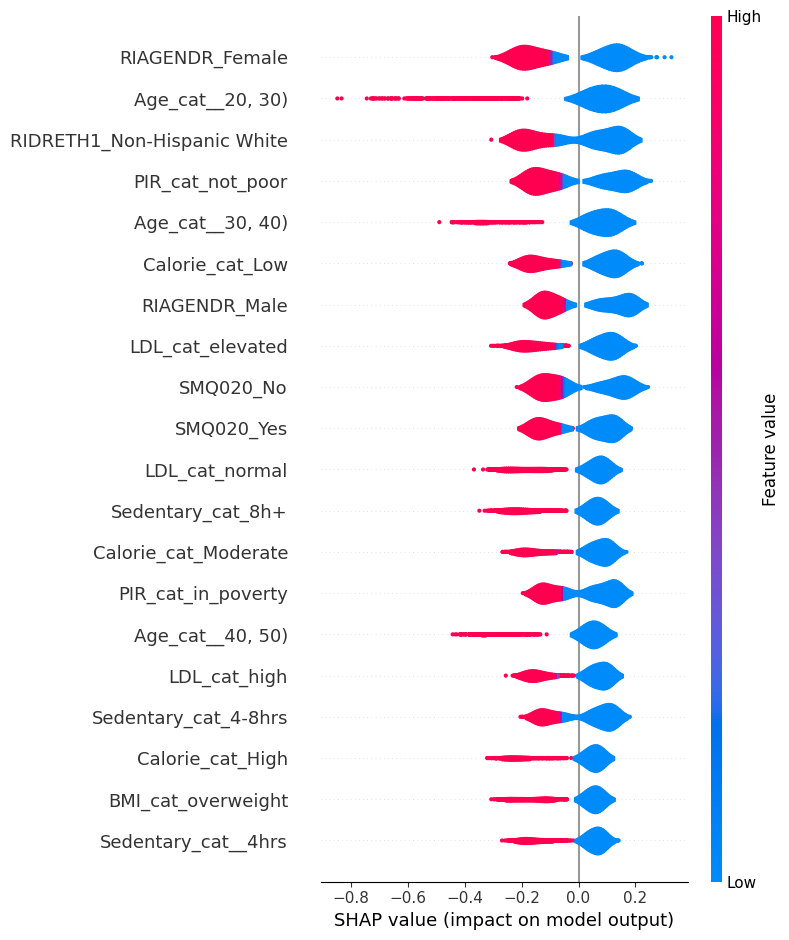

In [ ]:
# ===============================
# SHAP Violin Plot for XGBoost
# ===============================
# Prereqs:
#  - model: trained xgboost.XGBClassifier
#  - X_train, X_test: pandas DataFrames with identical columns

# --- Explainer (TreeExplainer is correct for XGBoost) ---
# Use background data (X_train) for expectations
explainer = shap.TreeExplainer(
    model,
    data=X_train,                      # background / masker
    feature_perturbation="interventional",
    model_output="probability"         # show impact on predicted probability
)

# --- Compute SHAP values on test set (new API returns Explanation) ---
sv = explainer(X_test)                 # sv.values shape: (n_samples, n_features)

# --- Violin-style summary (vertical density per feature) ---
# Note: summary_plot expects the raw array for violin/legacy plots
shap.summary_plot(
    sv.values,                         # SHAP matrix
    X_test,                            # features (same rows)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None
)

**Interpretation of SHAP Plot**

Key Predictors and Their Effects:

1. **Sex**
* Female

  * Shows strong negative SHAP values

  * Being female reduces predicted probability of abnormal HbA1c

  * Effect is stronger than in logistic regression

* XGBoost captures non-linear sex differences in glycaemic risk

* Male:
  * Corresponding positive SHAP values
  * Predictive of higher HbA1c risk

2. **Age**
* Age 20–30

  * One of the strongest negative SHAP distributions

  * Strongly protective against abnormal HbA1c

  * Wide spread suggests interaction with other lifestyle/metabolic variables

* Age 30–40

  * Moderately negative SHAP values

  * Still protective, but weaker than 20–30

* Age 40–50

  * SHAP values shift towards zero or positive

  * Indicates increasing HbA1c risk with age

3. **Ethnicity**
* Non-Hispanic White

  * Negative SHAP values dominate

  * Predictive of lower abnormal HbA1c probability

* Effect remains consistent with log regression model

* Ethnicity contributes to prediction independently of metabolic factors

4. **Socioeconomic Status (PIR)**
* Not poor

  * Clear negative SHAP values → protective

* In poverty

  * Positive SHAP values → increased predicted risk

* XGBoost reinforces SES as a structural risk factor, interacting with diet and activity

5. **Caloric Intake**
* Low calorie intake

  * Strong protective effect (negative SHAP)

* Moderate intake

  * Mild protective effect

* High calorie intake

  * Shifts SHAP values more positively
  * Less protective effect compared to moderate intake

6. **LDL Cholesterol**

* Normal LDL

  * Negative SHAP values → protective

* Elevated LDL

  * More positive SHAP values → increased HbA1c risk

* High LDL

  * Smaller (compared to elevated LDL) but consistent positive effect

7. **Smoking Status**
* Smoker
  * Positive SHAP values

  * Increases predicted HbA1c risk

* Non-smoker

  * Protective

* Effect is mild

8. **Sedentary Behaviour**
* <4 hours sedentary

  * Protective

* 4–8 hours sedentary

  * More positive SHAP values compared to <4h

* ≥8 hours sedentary

  * More positive SHAP values compared to 4-8H

* Demonstrates a dose–response relationship between inactivity and HbA1c elevation

* Captured more cleanly by XGBoost than logistic regression

9. **BMI**
* Overweight

  * Positive SHAP values

  * Predictive of higher HbA1c probability

**Compared to logistic regression:**

* XGBoost amplifies age and sex effects

* Retains the same core metabolic drivers, improving predictive nuance

The XGBoost model predicts abnormal HbA1c primarily through non-linear interactions between age, sex, metabolic health, lifestyle behaviours, and socioeconomic status.

Younger age, female sex, normal LDL, low caloric intake, physical activity, and higher SES are consistently protective.

## 4.2 Fasting Glucose (FPG)

### 4.2.1 Predictive Logistic Regression

**Preparation of dataset for predictive regression**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "FPG_cat"

model_df = df_model[predictor_cols + [outcome_col]].dropna()

# ------------------------------
# Define X and y
# ------------------------------

X = model_df.drop(columns=[outcome_col])

y = model_df[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())

Outcome distribution:
FPG_cat
0    4027
1    2902
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Dummy encode predictors
# ------------------------------

X = pd.get_dummies(X, drop_first=False, dtype=int)

# ------------------------------
# Train / test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training outcome balance:")
print(y_train.value_counts())

Training outcome balance:
FPG_cat
0    2819
1    2031
Name: count, dtype: int64


**Applying SMOTE to the prediction model**

In [ ]:
# ------------------------------
# Apply SMOTE
# ------------------------------

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 2819, 1: 2031}
After SMOTE: {1: 2819, 0: 2819}


In [ ]:
# ------------------------------
# Train logistic regression on SMOTE data
# ------------------------------

model_smote = LogisticRegression(max_iter=1000, solver="lbfgs")
model_smote.fit(X_train_res, y_train_res)

# ------------------------------
# Predict on test set
# ------------------------------

y_pred = model_smote.predict(X_test)
y_prob = model_smote.predict_proba(X_test)[:, 1]

# ------------------------------
# Evaluate performance
# ------------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6623376623376623
ROC-AUC: 0.7196255731023943

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      1208
           1       0.61      0.54      0.57       871

    accuracy                           0.66      2079
   macro avg       0.65      0.65      0.65      2079
weighted avg       0.66      0.66      0.66      2079



**Analysis of Logistic Regression Model for fasting glucose**

**Model Performance Summary:**

-   **Accuracy:** The model achieved an accuracy of approximately **66.2%**. This indicates that about 66.2% of the predictions (both normal and diabetic) were correct.

-   **ROC-AUC:** The ROC-AUC score is **0.720**. This is a reasonably good score, suggesting that the model has a fair ability to distinguish between diabetic and non-diabetic individuals.

-   **Classification Report Breakdown:**
    -   **Class 0 (Normal):**
        -   **Precision (0.69):** When the model predicts 'normal', it is correct 69% of the time.
        -   **Recall (0.75):** The model correctly identifies 75% of all actual 'normal' cases.
        -   **F1-score (0.72):** A good balance between precision and recall for the 'normal' class.
    -   **Class 1 (Diabetic):**
        -   **Precision (0.61):** When the model predicts 'diabetic', it is correct only 61% of the time. While this is better than the HbA1c model, it still misses a notable number of times.
        -   **Recall (0.54):** The model only correctly identifies 54% of all actual 'diabetic' cases. This indicates that it misses a significant portion of the true diabetic individuals.
        -   **F1-score (0.57):** The F1-score for the 'diabetic' class is moderate. Both precision and recall is reasonably balanced but can be improved




**SHAP plots**

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


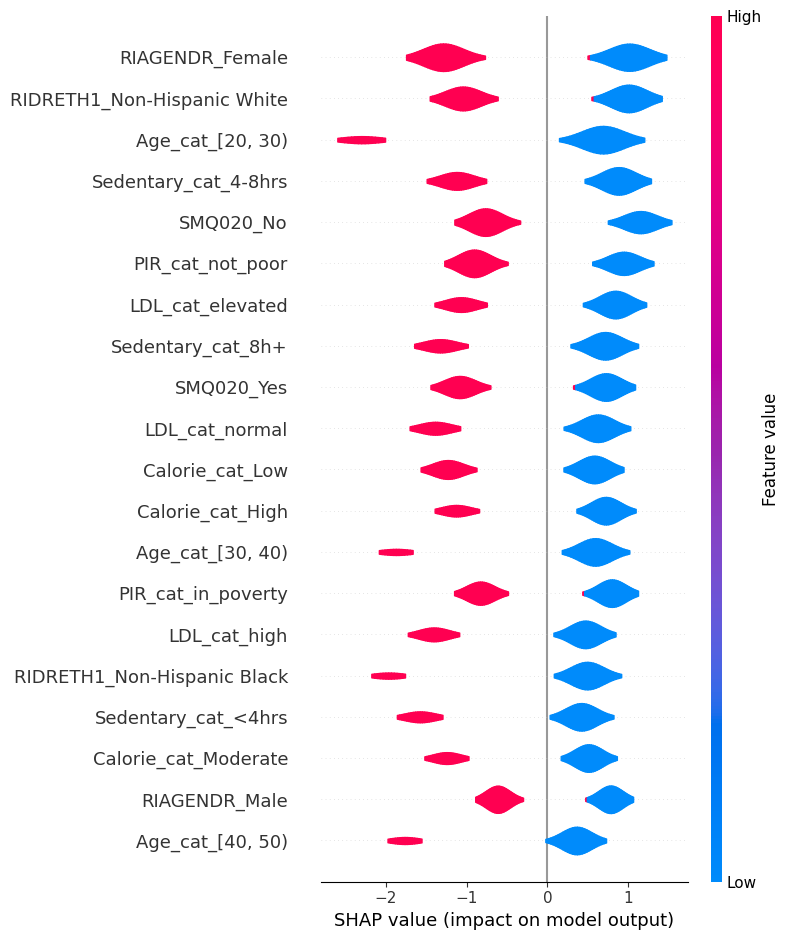

In [ ]:
# ------------------------------
# SHAP explainability
# ------------------------------

explainer = shap.LinearExplainer(
    model_smote,
    X_train,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_test)

# Summary plot (violin)
shap.summary_plot(
    shap_values.values,                # SHAP matrix for Logistic Regression
    X_test,                            # features (same rows as shap_values.values)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None                   # Display all features
)

The median for each blue and red swarms for all features can be seen in the table below:

In [ ]:
# Initialize a dictionary to store results
median_shap_summary = {}

# Iterate through each feature in X_test
for feature in X_test.columns:
    # Get the SHAP values for the current feature across all samples
    feature_shap_values = shap_values.values[:, X_test.columns.get_loc(feature)]

    # Get the actual feature values from X_test
    feature_data = X_test[feature]

    # Calculate median SHAP when feature is present (1)
    shap_when_1 = feature_shap_values[feature_data == 1]
    median_1 = np.median(shap_when_1) if len(shap_when_1) > 0 else np.nan

    # Calculate median SHAP when feature is absent (0)
    shap_when_0 = feature_shap_values[feature_data == 0]
    median_0 = np.median(shap_when_0) if len(shap_when_0) > 0 else np.nan

    median_shap_summary[feature] = {
        'Median SHAP (Feature = 1)': median_1,
        'Median SHAP (Feature = 0)': median_0
    }

# Convert the dictionary to a DataFrame for better display
median_shap_df = pd.DataFrame(median_shap_summary).T.sort_values(by='Median SHAP (Feature = 1)', ascending=False)

print("Median SHAP Values for Feature Present (1) and Feature Absent (0):")
display(median_shap_df)

Median SHAP Values for Feature Present (1) and Feature Absent (0):


,Median SHAP (Feature = 1),Median SHAP (Feature = 0)
DIQ160_No,-0.022734,1.113972
Waist_cat_unhealthy,-0.145028,0.761397
DIQ170_No,-0.248472,1.213126
BMI_cat_obese,-0.356104,0.606339
PHQ9_cat_not_depressed,-0.365452,1.096355
DIQ160_Yes,-0.396930,0.008101
RIAGENDR_Male,-0.614767,0.782431
SMQ020_No,-0.768328,1.152491
PIR_cat_in_poverty,-0.830153,0.797598
Waist_cat_healthy,-0.867706,0.165277


**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Sex**
* Female

  * Strong negative SHAP values.

  * Being female reduces predicted probability of abnormal FPG.

  * One of the strongest protective predictors in the model.

* Male

  * Corresponding positive SHAP values.

  * Predictive of higher FPG abnormality risk.

* Sex differences contribute meaningfully to fasting glucose prediction (compared to HbA1c), with males at higher risk.

2. **Ethnicity**
* Non-Hispanic White

  * Strong negative SHAP distribution.

  * Predictive of lower abnormal FPG probability.

* Non-Hispanic Black

  * SHAP values shift towards negative.

  * Indicates lower predicted risk of abnormal FPG when comparing the SHAP value for white and black individuals

* Ethnic differences persist in fasting glucose prediction, even after accounting for metabolic and lifestyle factors.

3. **Age**
* Age 20–30

  * Strong negative SHAP values.

  * Highly protective against abnormal FPG.

* Age 30–40

  * Mildly negative SHAP values.

  * Still protective but weaker than 20–30.

* Age 40–50

  * SHAP values move more positive.

  * Indicates rising FPG risk with age.

* There is a clear age gradient, consistent with progressive insulin resistance.

4. **Sedentary Behaviour**
* 4–8 hours sedentary

  * Positive SHAP values.

  * Increases predicted risk of abnormal FPG.

* ≥8 hours sedentary

  * Similar positive SHAP effect.

  * Indicates increased fasting glucose risk with prolonged inactivity.

* <4 hours sedentary

  * Relatively negative SHAP values.

  * Protective against abnormal FPG.

5. **Smoking Status**
* Smoker

  * More negative SHAP values relative to non-smokers.

* Non-smokers

* Negative SHAP values but less than smokers.

* Interesting effect to further investigate

6. **Socioeconomic Status (PIR)**
* Not poor and in poverty both have similar SHAP values.
* The relationship between SES and diabetic risk might not be captured in this model

7. **LDL Cholesterol**
* The expected dose-response relationship between LDL cholesterol and diabetic risk is not capture clearly
* High LDL has more protective effects than normal LDL in this model.

8. **Caloric Intake**
* Low calorie intake

  * Negative SHAP values.

  * Protective against abnormal FPG.

* Moderate intake

  * Mildly negative SHAP values.

  * Slight protective effect.

* High calorie intake

  * Positive SHAP values.

  * Predictive of elevated fasting glucose.
* The dose-response relationship is not clearly captured here as well, with only slight differences between categories

Model-level Interpretation:

* This model places greater emphasis on demographic and behavioural factors compared to HbA1c.
* FPG is more sensitive to acute metabolic and lifestyle influences, such as inactivity and smoking.

* Metabolic markers (LDL) contribute but are less dominant than in HbA1c models.


### 4.2.2 XGBoost Modelling

**Preparation of dataset for XGBoost**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "FPG_cat"  # primary diabetes outcome

df_xgb = df_model[predictor_cols + [outcome_col]].dropna()

print("Dataset shape after dropna:", df_xgb.shape)
print(df_xgb[outcome_col].value_counts())


Dataset shape after dropna: (6929, 14)
FPG_cat
normal      4027
diabetic    2902
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Encode outcome (binary)
# ------------------------------

y = df_xgb[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())


Outcome distribution:
FPG_cat
0    4027
1    2902
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Prepare predictors
# ------------------------------

X = df_xgb.drop(columns=[outcome_col])

# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
X.head()


Dummy-encoded predictors shape: (6929, 36)


,"Age_cat_[20, 30)","Age_cat_[30, 40)","Age_cat_[40, 50)","Age_cat_[50, 60)","Age_cat_[60, 80)",RIAGENDR_Female,RIAGENDR_Male,RIDRETH1_Mexican American,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,...,LDL_cat_high,Calorie_cat_Low,Calorie_cat_Moderate,Calorie_cat_High,PHQ9_cat_depressed,PHQ9_cat_not_depressed,DIQ160_No,DIQ160_Yes,DIQ170_No,DIQ170_Yes
0,0,0,0,1,0,0,1,1,0,0,...,0,0,0,1,0,1,1,0,1,0
1,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,1,0,1,0
2,0,0,0,0,1,1,0,1,0,0,...,0,1,0,0,0,1,1,0,1,0
3,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,0,0,1,0,0,1,0,1,0,0,...,0,0,1,0,0,1,1,0,1,0


In [ ]:
# ------------------------------
# Train-test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4850, 36)
Test shape: (2079, 36)


In [ ]:
print("Training outcome balance:")
print(y_train.value_counts(normalize=True))


Training outcome balance:
FPG_cat
0    0.581237
1    0.418763
Name: proportion, dtype: float64


**XGBoost with SMOTE**

In [ ]:
# Using the training and test data from the previous analysis

# ------------------------------
# Apply SMOTE to training set
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

X_train_res.columns = X_train_res.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')
X_test.columns = X_test.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')

# ------------------------------
# Step 3: Build & Train XGBoost
# ------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",   # avoid warning
    use_label_encoder=False, # legacy param
    random_state=42
)

model.fit(X_train_res, y_train_res)


# ------------------------------
# Step 4: Evaluate
# ------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: {0: 2819, 1: 2031}
After SMOTE: {1: 2819, 0: 2819}
Accuracy: 0.622895622895623
ROC-AUC: 0.6654602687023364

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.68      0.68      1208
           1       0.55      0.55      0.55       871

    accuracy                           0.62      2079
   macro avg       0.61      0.61      0.61      2079
weighted avg       0.62      0.62      0.62      2079



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:43:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Model Performance Summary:**

* **Accuracy**: The model achieved an accuracy of approximately 66.2%. This indicates that about 66.2% of the predictions (both normal and diabetic) were correct.

* **ROC-AUC**: The ROC-AUC score is 0.720. This is a reasonably good score, suggesting that the model has a fair ability to distinguish between diabetic and non-diabetic individuals based on FPG. This score is slightly less than in logistic regression.

* Classification Report Breakdown:

  * Class 0 (Normal):
    * Precision (0.67): When the model predicts 'normal', it is correct 67% of the time.
    * Recall (0.68): The model correctly identifies 68% of all actual 'normal' cases.
    * F1-score (0.68): This indicates a balanced performance for identifying normal cases.
  * Class 1 (Diabetic):
    * Precision (0.55): When the model predicts 'diabetic', it is correct 55% of the time. This is still relatively low, suggesting a notable number of false positives.
    * Recall (0.55): The model correctly identifies 55% of all actual 'diabetic' cases. This is slightly better than the recall for the HbA1c models but still means it misses almost half of the true diabetic individuals.
    * F1-score (0.55): The F1-score for the 'diabetic' class is moderate, indicating room for improvement in both precision and recall.

**Comparison to Logistic Regression for fasting glucose:**

* The Logistic Regression model for FPG showed slightly better performance with an accuracy of 66.2% and an ROC-AUC of 0.720, compared to XGBoost's 62.3% accuracy and 0.665 ROC-AUC.
  * This suggests that for this specific outcome and dataset, Logistic Regression performed marginally better.
* Both models show similar challenges in precisely identifying the 'diabetic' class, although the recall for the diabetic class is comparable between the two (0.54 for Logistic Regression vs. 0.55 for XGBoost).

**SHAP Plot**

 99%|===================| 2049/2079 [00:19<00:00]       

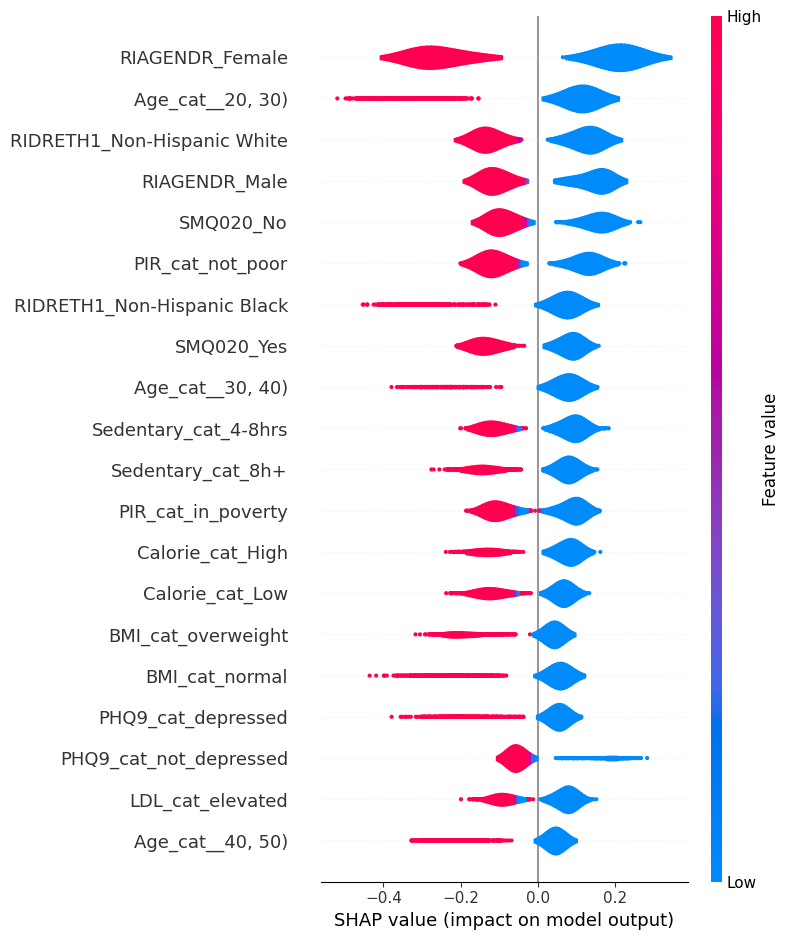

In [ ]:
# ===============================
# SHAP Violin Plot for XGBoost
# ===============================
# Prereqs:
#  - model: trained xgboost.XGBClassifier
#  - X_train, X_test: pandas DataFrames with identical columns

# --- Explainer (TreeExplainer is correct for XGBoost) ---
# Use background data (X_train) for expectations
explainer = shap.TreeExplainer(
    model,
    data=X_train,                      # background / masker
    feature_perturbation="interventional",
    model_output="probability"         # show impact on predicted probability
)

# --- Compute SHAP values on test set (new API returns Explanation) ---
sv = explainer(X_test)                 # sv.values shape: (n_samples, n_features)

# --- Violin-style summary (vertical density per feature) ---
# Note: summary_plot expects the raw array for violin/legacy plots
shap.summary_plot(
    sv.values,                         # SHAP matrix
    X_test,                            # features (same rows)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None
)

**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Sex**
* Female

  * Shows the largest negative SHAP distribution.

  * Being female is strongly protective against abnormal FPG.

  * Effect is stronger than in logistic regression, indicating non-linear sex interactions.

* Male

  * Positive SHAP values.

  * Predictive of higher abnormal FPG probability.

2. **Age**
* Age 20–30

  * Strong negative SHAP values.

  * Highly protective against abnormal FPG.

* Age 30–40

  * Moderately negative SHAP values.

  * Still protective, but weaker than 20–30.

* Age 40–50

  * SHAP values cluster closer to zero or positive.

  * Indicates increasing fasting glucose risk with age.

3. **Ethnicity**
* Non-Hispanic White
  * Negative SHAP values dominate.
  * Predictive of lower abnormal FPG risk.

* Non-Hispanic Black

  * Very wide spread compared to white individuals.

4. **Smoking Status**
* Smokers

  * More negative SHAP values compared to non-smokers
  * Similar trend compared to logistic regression

5. **Socioeconomic Status (PIR)**
* Not poor and in poverty had similar SHAP values

6. **Sedentary Behaviour**
* 4–8 hours sedentary

  * Positive SHAP values.

  * Moderate increase in predicted FPG risk.

* ≥8 hours sedentary

  * Slightly weaker positive SHAP effect.
  * Interesting effect that might be due to confounding factors

7. **Caloric Intake**
* High calorie intake

  * Positive SHAP values.

  * Predictive of higher abnormal FPG risk.

* Low and moderate calorie intake

  * Mild negative SHAP values.

  * Protective effect.

8. **BMI**
* Overweight

  * Positive SHAP values.

  * Predictive of increased abnormal FPG probability.

* Normal BMI

  * Negative SHAP values.

  * Protective.

9. **Depression Status (PHQ-9)**
* Depressed

  * Very wide spread SHAP values.

  * Relatively more negative SHAP values compared to not depressed

* Opposite of the expected results

* This effect is captured only in the non-linear XGBoost model, not as clearly in logistic regression.

10. **LDL Cholesterol**
* Elevated LDL

  * Slightly negative
  SHAP values.

* Other categories of LDL cholesterol (normal and high) are not in the plot to allow comparison between categories

**Model-level Insights**

* The XGBoost model shows that abnormal fasting glucose is driven primarily by demographic and behavioural factors, with metabolic variables playing a secondary role.
* Compared to HbA1c, FPG prediction relies more on short-term physiological and lifestyle influences, which are better captured by non-linear interactions.

## 4.3 OGTT Glucose

### 4.3.1 Predictive Logistic Regression

**Preparation of dataset for predictive regression**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "OGTT_cat"

model_df = df_model[predictor_cols + [outcome_col]].dropna()

# ------------------------------
# Define X and y
# ------------------------------

X = model_df.drop(columns=[outcome_col])

y = model_df[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())

Outcome distribution:
OGTT_cat
0    5495
1    1434
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Dummy encode predictors
# ------------------------------

X = pd.get_dummies(X, drop_first=False, dtype=int)

# ------------------------------
# Train / test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training outcome balance:")
print(y_train.value_counts())

Training outcome balance:
OGTT_cat
0    3846
1    1004
Name: count, dtype: int64


**Applying SMOTE to the prediction model**

In [ ]:
# ------------------------------
# Apply SMOTE
# ------------------------------

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 3846, 1: 1004}
After SMOTE: {1: 3846, 0: 3846}


In [ ]:
# ------------------------------
# Train logistic regression on SMOTE data
# ------------------------------

model_smote = LogisticRegression(max_iter=1000, solver="lbfgs")
model_smote.fit(X_train_res, y_train_res)

# ------------------------------
# Predict on test set
# ------------------------------

y_pred = model_smote.predict(X_test)
y_prob = model_smote.predict_proba(X_test)[:, 1]

# ------------------------------
# Evaluate performance
# ------------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8003848003848004
ROC-AUC: 0.7306394291113713

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.95      0.88      1649
           1       0.54      0.21      0.30       430

    accuracy                           0.80      2079
   macro avg       0.68      0.58      0.59      2079
weighted avg       0.77      0.80      0.76      2079



**Analysis of Logistic Regression Model for OGTT Glucose**

**Model Performance Summary:**

-   **Accuracy:** The model achieved an accuracy of approximately 80.0%. This is a relatively high accuracy, meaning 80.0% of the predictions (both normal and diabetic) were correct.

-   **ROC-AUC:** The ROC-AUC score is 0.731. This is a reasonably good score, suggesting that the model has a fair ability to distinguish between diabetic and non-diabetic individuals based on OGTT Glucose.

-   **Classification Report Breakdown:**
    -   **Class 0 (Normal):**
        -   Precision (0.82): When the model predicts 'normal', it is correct 82% of the time.
        -  Recall (0.95): The model correctly identifies a very high 95% of all actual 'normal' cases.
        -   F1-score (0.88): This is a strong F1-score, indicating excellent performance in identifying normal cases.
    -   **Class 1 (Diabetic):**
        -   Precision (0.37): When the model predicts 'diabetic', it is correct only 37% of the time. This is quite low, indicating a high number of false positives for this class.
        -   Recall (0.21): The model only correctly identifies 21% of all actual 'diabetic' cases. This is very low, meaning it misses the vast majority (79%) of true diabetic individuals.
        -   F1-score (0.30): The F1-score for the 'diabetic' class is poor, reflecting very low precision and recall.



**SHAP plots**

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


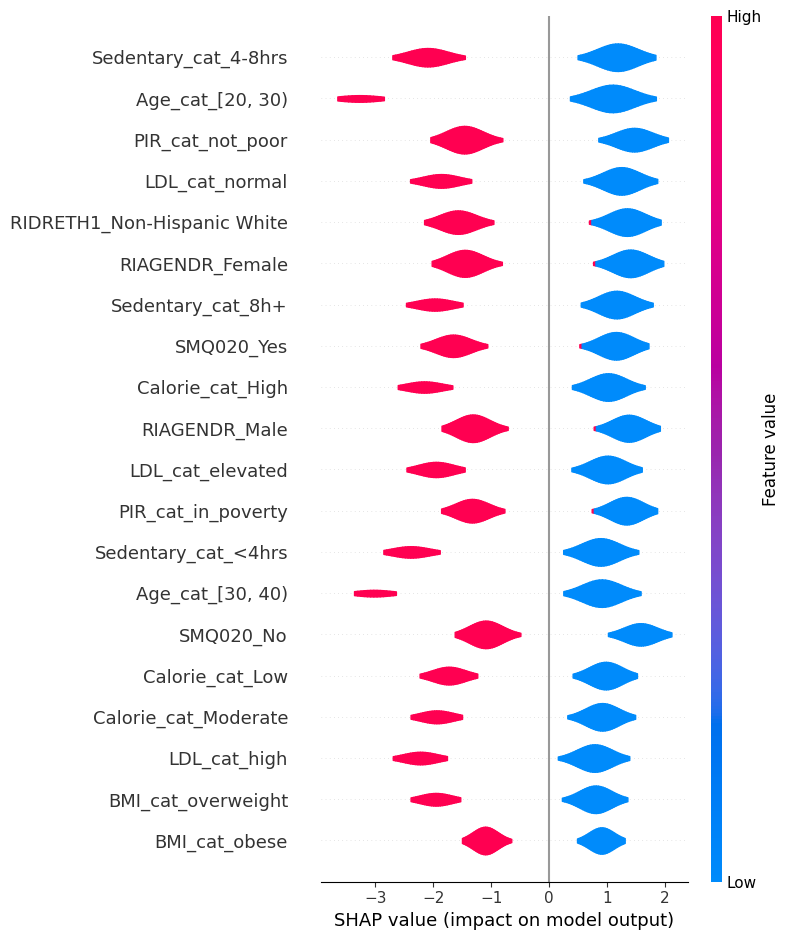

In [ ]:
# ------------------------------
# SHAP explainability
# ------------------------------

explainer = shap.LinearExplainer(
    model_smote,
    X_train,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_test)

# Summary plot (violin)
shap.summary_plot(
    shap_values.values,                # SHAP matrix for Logistic Regression
    X_test,                            # features (same rows as shap_values.values)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None                   # Display all features
)

The median for each blue and red swarms for all features can be seen in the table below:

In [ ]:
# Initialize a dictionary to store results
median_shap_summary = {}

# Iterate through each feature in X_test
for feature in X_test.columns:
    # Get the SHAP values for the current feature across all samples
    feature_shap_values = shap_values.values[:, X_test.columns.get_loc(feature)]

    # Get the actual feature values from X_test
    feature_data = X_test[feature]

    # Calculate median SHAP when feature is present (1)
    shap_when_1 = feature_shap_values[feature_data == 1]
    median_1 = np.median(shap_when_1) if len(shap_when_1) > 0 else np.nan

    # Calculate median SHAP when feature is absent (0)
    shap_when_0 = feature_shap_values[feature_data == 0]
    median_0 = np.median(shap_when_0) if len(shap_when_0) > 0 else np.nan

    median_shap_summary[feature] = {
        'Median SHAP (Feature = 1)': median_1,
        'Median SHAP (Feature = 0)': median_0
    }

# Convert the dictionary to a DataFrame for better display
median_shap_df = pd.DataFrame(median_shap_summary).T.sort_values(by='Median SHAP (Feature = 1)', ascending=False)

print("Median SHAP Values for Feature Present (1) and Feature Absent (0):")
display(median_shap_df)

Median SHAP Values for Feature Present (1) and Feature Absent (0):


,Median SHAP (Feature = 1),Median SHAP (Feature = 0)
DIQ160_No,-0.108706,2.065417
DIQ170_No,-0.293879,1.966730
PHQ9_cat_not_depressed,-0.613953,2.176743
Waist_cat_unhealthy,-0.627374,1.068231
SMQ020_No,-1.095360,1.576250
BMI_cat_obese,-1.103256,0.902664
Waist_cat_healthy,-1.254784,0.736937
RIAGENDR_Male,-1.318737,1.372563
PIR_cat_in_poverty,-1.331416,1.331416
RIAGENDR_Female,-1.456077,1.398976


**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Sedentary Behaviour**
* Sedentary 4–8 hours

  * Shows the largest positive SHAP values.

  * Strongly increases predicted probability of abnormal OGTT.

* Sedentary ≥8 hours
  * Also associated with positive SHAP values, though slightly weaker than 4–8 hours.

  * Indicates elevated post-load glucose risk with prolonged inactivity.

* Sedentary <4 hours

  * Negative SHAP values.

  * Protective against abnormal OGTT.

* OGTT seems to be highly sensitive to physical inactivity, reflecting impaired post-prandial glucose handling.

2. **Age**
* Age 20–30

  * Strong negative SHAP values.

  * Highly protective against abnormal OGTT.

* Age 30–40

  * Mildly negative SHAP values.

  * Still protective, but weaker than younger adults.

* Younger age groups show better glucose tolerance.

* OGTT abnormalities increase with age due to progressive insulin resistance.

3. **Socioeconomic Status (PIR)**
* Not poor

  * Negative SHAP values, but similar to those in poverty

4. **LDL Cholesterol**
* Normal LDL
  * Negative SHAP values.

  * Protective against abnormal OGTT.

* Elevated LDL

  * Positive SHAP values.

  * Predictive of increased OGTT abnormality.

* High LDL

  * Interestingly has more negative SHAP values than normal LDL

5. **Ethnicity**
* Non-Hispanic White

  * Negative SHAP values.

  * Predictive of lower abnormal OGTT risk.

6. **Sex**
* Female

  * Negative SHAP values.

  * Protective against abnormal OGTT.

* Male

  * Slightly more negative SHAP values than female.
  * Opposite of previous models

7. **Smoking Status**
* Smokers

  * Negative SHAP values.

* Non-smokers

  * More positive SHAP values.

  * Similar to trends observed in previous models


8. **Caloric Intake**
* High and moderate calorie intake

  * Both had similar negative SHAP values.

* Low calorie intake
  * More positive SHAP values compared to the other 2 categories


9. **BMI**
* Overweight

  * Negative SHAP values.

* Obese

  * More positive SHAP values than overweight
* Normal BMI was not in the plot to allow comparison


Model-level Interpretation:

* The OGTT logistic regression model is dominated by lifestyle and metabolic predictors, particularly sedentary behaviour.

* Compared to FPG, OGTT is more sensitive to post-prandial insulin resistance, which explains the stronger effects of physical inactivity and BMI.

### 4.3.2 XGBoost Modelling

**Preparation of dataset for XGBoost**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "OGTT_cat"  # primary diabetes outcome

df_xgb = df_model[predictor_cols + [outcome_col]].dropna()

print("Dataset shape after dropna:", df_xgb.shape)
print(df_xgb[outcome_col].value_counts())


Dataset shape after dropna: (6929, 14)
OGTT_cat
normal      5495
diabetic    1434
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Encode outcome (binary)
# ------------------------------

y = df_xgb[outcome_col].map({
    "normal": 0,
    "diabetic": 1
})

print("Outcome distribution:")
print(y.value_counts())


Outcome distribution:
OGTT_cat
0    5495
1    1434
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Prepare predictors
# ------------------------------

X = df_xgb.drop(columns=[outcome_col])

# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
X.head()


Dummy-encoded predictors shape: (6929, 36)


,"Age_cat_[20, 30)","Age_cat_[30, 40)","Age_cat_[40, 50)","Age_cat_[50, 60)","Age_cat_[60, 80)",RIAGENDR_Female,RIAGENDR_Male,RIDRETH1_Mexican American,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,...,LDL_cat_high,Calorie_cat_Low,Calorie_cat_Moderate,Calorie_cat_High,PHQ9_cat_depressed,PHQ9_cat_not_depressed,DIQ160_No,DIQ160_Yes,DIQ170_No,DIQ170_Yes
0,0,0,0,1,0,0,1,1,0,0,...,0,0,0,1,0,1,1,0,1,0
1,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,1,0,1,0
2,0,0,0,0,1,1,0,1,0,0,...,0,1,0,0,0,1,1,0,1,0
3,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,0,0,1,0,0,1,0,1,0,0,...,0,0,1,0,0,1,1,0,1,0


In [ ]:
# ------------------------------
# Train-test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4850, 36)
Test shape: (2079, 36)


In [ ]:
print("Training outcome balance:")
print(y_train.value_counts(normalize=True))


Training outcome balance:
OGTT_cat
0    0.79299
1    0.20701
Name: proportion, dtype: float64


**XGBoost with SMOTE**

In [ ]:
# Using the training and test data from the previous analysis

# ------------------------------
# Apply SMOTE to training set
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

X_train_res.columns = X_train_res.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')
X_test.columns = X_test.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')

# ------------------------------
# Step 3: Build & Train XGBoost
# ------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",   # avoid warning
    use_label_encoder=False, # legacy param
    random_state=42
)

model.fit(X_train_res, y_train_res)


# ------------------------------
# Step 4: Evaluate
# ------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: {0: 3846, 1: 1004}
After SMOTE: {1: 3846, 0: 3846}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:43:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.757094757094757
ROC-AUC: 0.6584406335058597

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85      1649
           1       0.37      0.24      0.29       430

    accuracy                           0.76      2079
   macro avg       0.59      0.56      0.57      2079
weighted avg       0.72      0.76      0.74      2079



**Model Performance Summary:**

* **Accuracy**: The XGBoost model achieved an accuracy of approximately 75.7%. This indicates that about 75.7% of the predictions (both normal and diabetic) were correct.

* **ROC-AUC**: The ROC-AUC score is 0.658. This score suggests that the model has a moderate ability to distinguish between diabetic and non-diabetic individuals based on OGTT Glucose, but it is lower than the Logistic Regression model for OGTT.

* Classification Report Breakdown:

  * Class 0 (Normal):
    * Precision (0.82): When the model predicts 'normal', it is correct 82% of the time.
    * Recall (0.89): The model correctly identifies 89% of all actual 'normal' cases.
    * F1-score (0.85): This indicates a good performance for identifying normal cases.
  * Class 1 (Diabetic):
    * Precision (0.37): When the model predicts 'diabetic', it is correct only 37% of the time. This is very low, indicating a high number of false positives for this class.
    * Recall (0.24): The model only correctly identifies 24% of all actual 'diabetic' cases. This is very low, meaning it misses the vast majority (76%) of true diabetic individuals.
    * F1-score (0.29): The F1-score for the 'diabetic' class is poor, reflecting very low precision and recall.

**Comparison to Logistic Regression for OGTT glucose:**

* The Logistic Regression model for OGTT showed slightly better performance with an accuracy of 80.0% and an ROC-AUC of 0.731, compared to XGBoost's 75.7% accuracy and 0.658 ROC-AUC. This suggests that for this specific outcome and dataset, Logistic Regression performed marginally better.
* Both models show similar challenges in precisely identifying the 'diabetic' class, with both having very low precision and recall for this minority class, despite the use of SMOTE. The XGBoost model's recall for the 'diabetic' class (0.24) is slightly higher than Logistic Regression (0.21), but the precision is the same (0.37 for both).

**SHAP Plot**

 95%|=================== | 1983/2079 [00:17<00:00]       

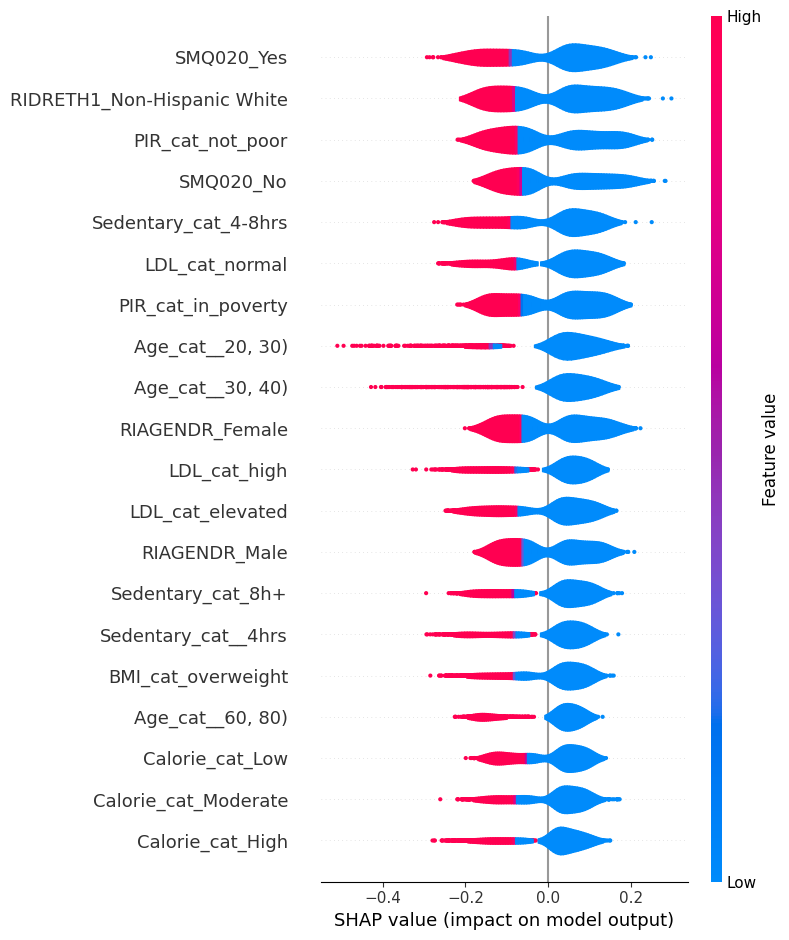

In [ ]:
# ===============================
# SHAP Violin Plot for XGBoost
# ===============================
# Prereqs:
#  - model: trained xgboost.XGBClassifier
#  - X_train, X_test: pandas DataFrames with identical columns

# --- Explainer (TreeExplainer is correct for XGBoost) ---
# Use background data (X_train) for expectations
explainer = shap.TreeExplainer(
    model,
    data=X_train,                      # background / masker
    feature_perturbation="interventional",
    model_output="probability"         # show impact on predicted probability
)

# --- Compute SHAP values on test set (new API returns Explanation) ---
sv = explainer(X_test)                 # sv.values shape: (n_samples, n_features)

# --- Violin-style summary (vertical density per feature) ---
# Note: summary_plot expects the raw array for violin/legacy plots
shap.summary_plot(
    sv.values,                         # SHAP matrix
    X_test,                            # features (same rows)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None
)

**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Smoking Status**
* Similar trend to previous models, where smoking seems to have a stronger protective effect compared to not smoking

2. **Ethnicity**
* Non-Hispanic White

  * Negative SHAP values.

  * Predictive of lower abnormal OGTT risk.

3. **Socioeconomic Status (PIR)**
* Both not poor and inpoverty had similar SHAP values


4. **Sedentary Behaviour**
* 4–8 hours sedentary and ≥8 hours sedentary

  * oth had reltively positive SHAP values.

  * Increases predicted OGTT abnormality risk compared to being less sedentary

* <4 hours sedentary

  * Negative SHAP values → protective.

5. **LDL Cholesterol**
* All 3 (Normal, Elevated and High) LDL had similar SHAP values

6. **Age**
* Age 20–30

  * Strong negative SHAP values.

  * Highly protective against abnormal OGTT.

* Age 30–40

  * Moderately negative SHAP values.

* Age 60–80

  * SHAP values shift toward positive.

  * Predictive of higher OGTT abnormality.
* Dose-response relationship has been clear in all models so far

7. **Sex**
* Female

  * Negative SHAP values → protective.
  * Difference in SHAP values is very little compared to previous models

* Male

  * Slighlty more positive SHAP values → increased predicted risk.

8. **BMI**
* Overweight

  * Negative SHAP values, but difficult to make sense without other BMI categories in the plot


9. **Caloric Intake**
* There was a dose-response relationship, but in the opposite direction of the expected results
* High calorie intake had the most negative SHAP values while low calorie intake had the most positive.


Model-level Insight:

- The XGBoost OGTT model is dominated by behavioural and structural risk factors, like smoking.

- Compared to FPG and HbA1c, OGTT prediction places greater emphasis on behaviours affecting post-prandial insulin sensitivity.


## 4.4 Fasting Insulin

### 4.4.1 Predictive Logistic Regression

**Preparation of dataset for predictive regression**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "Insulin_cat"

model_df = df_model[predictor_cols + [outcome_col]].dropna()

# ------------------------------
# Define X and y
# ------------------------------

X = model_df.drop(columns=[outcome_col])

y = model_df[outcome_col].map({
    "normal": 0,
    "abnormally_high": 1,
    "abnormally_low": 1
})

print("Outcome distribution:")
print(y.value_counts())

Outcome distribution:
Insulin_cat
0    4552
1    2377
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Dummy encode predictors
# ------------------------------

X = pd.get_dummies(X, drop_first=False, dtype=int)

# ------------------------------
# Train / test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training outcome balance:")
print(y_train.value_counts())

Training outcome balance:
Insulin_cat
0    3186
1    1664
Name: count, dtype: int64


**Applying SMOTE to the prediction model**

In [ ]:
# ------------------------------
# Apply SMOTE
# ------------------------------

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 3186, 1: 1664}
After SMOTE: {0: 3186, 1: 3186}


In [ ]:
# ------------------------------
# Train logistic regression on SMOTE data
# ------------------------------

model_smote = LogisticRegression(max_iter=1000, solver="lbfgs")
model_smote.fit(X_train_res, y_train_res)

# ------------------------------
# Predict on test set
# ------------------------------

y_pred = model_smote.predict(X_test)
y_prob = model_smote.predict_proba(X_test)[:, 1]

# ------------------------------
# Evaluate performance
# ------------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6887926887926888
ROC-AUC: 0.7260775105292016

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75      1366
           1       0.54      0.63      0.58       713

    accuracy                           0.69      2079
   macro avg       0.66      0.68      0.67      2079
weighted avg       0.70      0.69      0.69      2079



**Analysis of Logistic Regression Model for fasting insulin**

**Model Performance Summary:**

-   **Accuracy:** The model achieved an accuracy of approximately **68.9%**. This indicates that about 68.9% of the predictions (both normal and diabetic) were correct.

-   **ROC-AUC:** The ROC-AUC score is **0.726**. This is a reasonably good score, suggesting that the model has a fair ability to distinguish between diabetic and non-diabetic individuals.

-   **Classification Report Breakdown:**
    -   **Class 0 (Normal):**
        -   **Precision (0.79):** When the model predicts 'normal', it is correct 79% of the time.
        -   **Recall (0.72):** The model correctly identifies 72% of all actual 'normal' cases.
        -   **F1-score (0.75):** A good balance between precision and recall for the 'normal' class.
    -   **Class 1 (Diabetic):**
        -   **Precision (0.54):** When the model predicts 'diabetic', it is correct only 54% of the time. This suggests a notable number of false positives for this class.
        -   **Recall (0.63):** The model correctly identifies 63% of all actual 'abnormal' cases. This indicates that it misses over a third of true abnormal cases, but its recall is higher than for the 'diabetic' class in previous models.
        -   **F1-score (0.49):** The F1-score for the 'abnormal' class is moderate, showing a reasonable balance between its precision and recall, but still with room for improvement.




**SHAP plots**

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


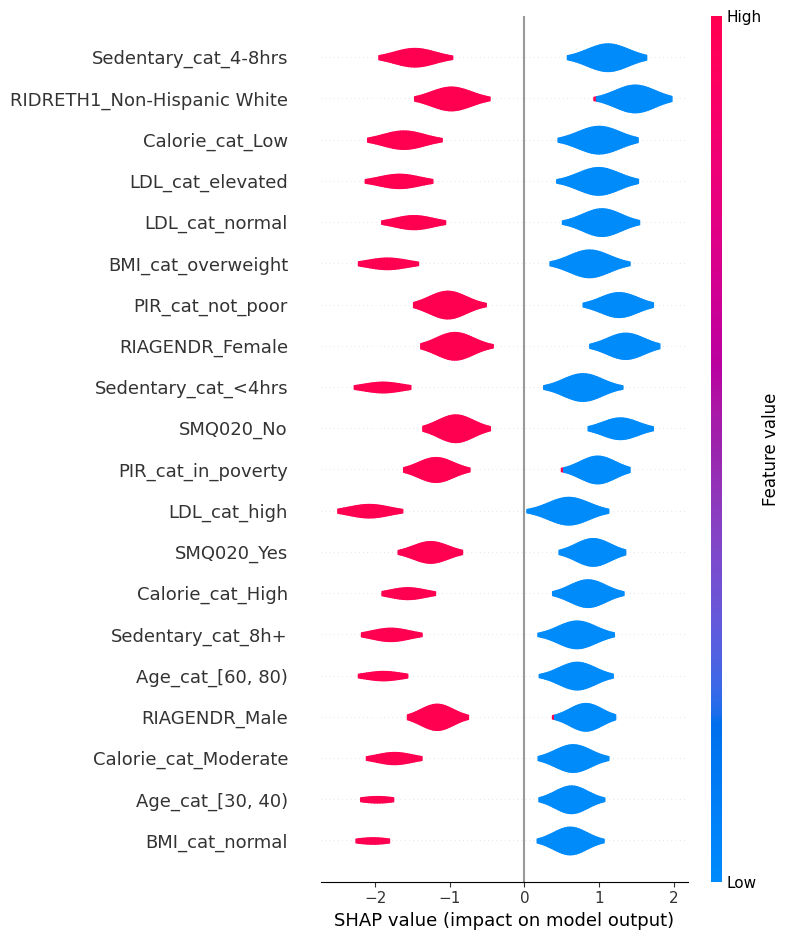

In [ ]:
# ------------------------------
# SHAP explainability
# ------------------------------

explainer = shap.LinearExplainer(
    model_smote,
    X_train,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_test)

# Summary plot (violin)
shap.summary_plot(
    shap_values.values,                # SHAP matrix for Logistic Regression
    X_test,                            # features (same rows as shap_values.values)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None                   # Display all features
)

The median for each blue and red swarms for all features can be seen in the table below:

In [ ]:
# Initialize a dictionary to store results
median_shap_summary = {}

# Iterate through each feature in X_test
for feature in X_test.columns:
    # Get the SHAP values for the current feature across all samples
    feature_shap_values = shap_values.values[:, X_test.columns.get_loc(feature)]

    # Get the actual feature values from X_test
    feature_data = X_test[feature]

    # Calculate median SHAP when feature is present (1)
    shap_when_1 = feature_shap_values[feature_data == 1]
    median_1 = np.median(shap_when_1) if len(shap_when_1) > 0 else np.nan

    # Calculate median SHAP when feature is absent (0)
    shap_when_0 = feature_shap_values[feature_data == 0]
    median_0 = np.median(shap_when_0) if len(shap_when_0) > 0 else np.nan

    median_shap_summary[feature] = {
        'Median SHAP (Feature = 1)': median_1,
        'Median SHAP (Feature = 0)': median_0
    }

# Convert the dictionary to a DataFrame for better display
median_shap_df = pd.DataFrame(median_shap_summary).T.sort_values(by='Median SHAP (Feature = 1)', ascending=False)

print("Median SHAP Values for Feature Present (1) and Feature Absent (0):")
display(median_shap_df)

Median SHAP Values for Feature Present (1) and Feature Absent (0):


,Median SHAP (Feature = 1),Median SHAP (Feature = 0)
DIQ160_No,-0.037310,1.206351
DIQ170_No,-0.179913,1.105181
Waist_cat_unhealthy,-0.234865,0.603938
PHQ9_cat_not_depressed,-0.603582,1.408358
BMI_cat_obese,-0.647774,0.529997
SMQ020_No,-0.927525,1.280867
RIAGENDR_Female,-0.939164,1.351480
DIQ170_Yes,-0.975019,0.158724
RIDRETH1_Non-Hispanic White,-0.985916,1.478874
PIR_cat_not_poor,-1.033817,1.263554


**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Sedentary Behaviour**
* Sedentary <4 hours and 8h+
  * Both had similar SHAP values

* Sedentary 4-8 hours

  * Slightly more positive SHAP values compared to <4 and 8h+

2. **Ethnicity**
* Non-Hispanic White

  * Strong negative SHAP distribution

  * Predictive of lower abnormal fasting insulin risk
* Similar to previous models

3. **Caloric Intake**
* All 3 categories had similar SHAP values

4. **LDL Cholesterol**
* There is a dose-relationship relationship in the opposite direction of the expected results.
* High LDL had the most negative SHAP values while normal LDL had the most positive.

5. **BMI**
* Overweight

  * More positive SHAP values

  * Predictive of abnormal fasting insulin

* Normal BMI

  * More negative SHAP values


6. **Socioeconomic Status (PIR)**
* Not poor

  * More positive SHAP values than those in poverty

* Opposite to the trends observed previously

7. **Sex**
* Female

  * More positive SHAP values
  * Opposite to the trends observed previously


8. **Smoking Status**
* Similar trend to before, where smokers had a more protective effect than non-smokers

9. **Age**
* Age 30–40

  * Mild negative SHAP values compared to 60-80 year olds

  * Slightly protective

* Age 60–80

  * Mild positive SHAP values

  * Slightly increased predicted risk

Model-level Insight:

- The fasting insulin model is dominated by upstream lifestyle and metabolic factors, rather than age or overt glycaemic measures.

- Compared to FPG and HbA1c, fasting insulin better captures early insulin resistance, explaining the stronger effects of inactivity, diet, BMI, and lipids.


### 4.4.2 XGBoost Modelling

**Preparation of dataset for XGBoost**

In [ ]:
# ------------------------------
# Select predictors and outcome
# ------------------------------

predictor_cols = [
    "Age_cat",
    "RIAGENDR",
    "RIDRETH1",
    "PIR_cat",
    "SMQ020",
    "Sedentary_cat",
    "BMI_cat",
    "Waist_cat",
    "LDL_cat",
    "Calorie_cat",
    "PHQ9_cat",
    "DIQ160",
    "DIQ170"
]

outcome_col = "Insulin_cat"  # primary diabetes outcome

df_xgb = df_model[predictor_cols + [outcome_col]].dropna()

print("Dataset shape after dropna:", df_xgb.shape)
print(df_xgb[outcome_col].value_counts())


Dataset shape after dropna: (6929, 14)
Insulin_cat
normal             4552
abnormally_high    2224
abnormally_low      153
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Encode outcome (binary)
# ------------------------------

y = df_xgb[outcome_col].map({
    "normal": 0,
    "abnormally_high": 1,
    "abnormally_low": 1
})

print("Outcome distribution:")
print(y.value_counts())


Outcome distribution:
Insulin_cat
0    4552
1    2377
Name: count, dtype: int64


In [ ]:
# ------------------------------
# Prepare predictors
# ------------------------------

X = df_xgb.drop(columns=[outcome_col])

# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=False, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
X.head()


Dummy-encoded predictors shape: (6929, 36)


,"Age_cat_[20, 30)","Age_cat_[30, 40)","Age_cat_[40, 50)","Age_cat_[50, 60)","Age_cat_[60, 80)",RIAGENDR_Female,RIAGENDR_Male,RIDRETH1_Mexican American,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,...,LDL_cat_high,Calorie_cat_Low,Calorie_cat_Moderate,Calorie_cat_High,PHQ9_cat_depressed,PHQ9_cat_not_depressed,DIQ160_No,DIQ160_Yes,DIQ170_No,DIQ170_Yes
0,0,0,0,1,0,0,1,1,0,0,...,0,0,0,1,0,1,1,0,1,0
1,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,1,1,0,1,0
2,0,0,0,0,1,1,0,1,0,0,...,0,1,0,0,0,1,1,0,1,0
3,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,1,1,0,1,0
4,0,0,1,0,0,1,0,1,0,0,...,0,0,1,0,0,1,1,0,1,0


In [ ]:
# ------------------------------
# Train-test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4850, 36)
Test shape: (2079, 36)


In [ ]:
print("Training outcome balance:")
print(y_train.value_counts(normalize=True))


Training outcome balance:
Insulin_cat
0    0.656907
1    0.343093
Name: proportion, dtype: float64


**XGBoost with SMOTE**

In [ ]:
# Using the training and test data from the previous analysis

# ------------------------------
# Apply SMOTE to training set
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

X_train_res.columns = X_train_res.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')
X_test.columns = X_test.columns.str.replace('[', '_').str.replace(']', '_').str.replace('<', '_')

# ------------------------------
# Step 3: Build & Train XGBoost
# ------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",   # avoid warning
    use_label_encoder=False, # legacy param
    random_state=42
)

model.fit(X_train_res, y_train_res)


# ------------------------------
# Step 4: Evaluate
# ------------------------------

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE: {0: 3186, 1: 1664}
After SMOTE: {0: 3186, 1: 3186}
Accuracy: 0.6551226551226551
ROC-AUC: 0.6790626495187677

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.75      0.74      1366
           1       0.50      0.46      0.48       713

    accuracy                           0.66      2079
   macro avg       0.61      0.61      0.61      2079
weighted avg       0.65      0.66      0.65      2079



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:44:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Model Performance Summary:**

* **Accuracy**: The XGBoost model achieved an accuracy of approximately 65.5%. This indicates that about 65.5% of the predictions (both normal and abnormal insulin) were correct.

* **ROC-AUC**: The ROC-AUC score is 0.679. This score suggests that the model has a moderate ability to distinguish between individuals with normal and abnormal fasting insulin levels, but it is lower than the Logistic Regression model for fasting insulin.

* Classification Report Breakdown:

  * Class 0 (Normal):
    * Precision (0.73): When the model predicts 'normal', it is correct 73% of the time.
    * Recall (0.75): The model correctly identifies 75% of all actual 'normal' cases.
    * F1-score (0.74): This indicates a good performance for identifying normal cases.
  * Class 1 (Diabetic):
    * Precision (0.50): When the model predicts 'abnormal', it is correct 50% of the time. This is low, indicating a significant number of false positives for this class.
    * Recall (0.46): The model only correctly identifies 46% of all actual 'abnormal' cases. This is quite low, meaning it misses more than half of the true abnormal individuals.
    * F1-score (0.48): The F1-score for the 'abnormal' class is poor, reflecting very low precision and recall.

**Comparison to Logistic Regression for fasting insulin:**

* The Logistic Regression model for fasting insulin showed slightly better performance with an accuracy of 68.9% and an ROC-AUC of 0.726, compared to XGBoost's 65.5% accuracy and 0.679 ROC-AUC. This suggests that for this specific outcome and dataset, Logistic Regression performed marginally better.
* Both models show similar challenges in precisely identifying the 'abnormal' class, with both having low precision and recall for this minority class. The XGBoost model's recall for the 'abnormal' class (0.46) is lower than Logistic Regression (0.63), and its precision is also lower (0.50 vs 0.54).


**SHAP Plot**

 97%|=================== | 2027/2079 [00:19<00:00]       

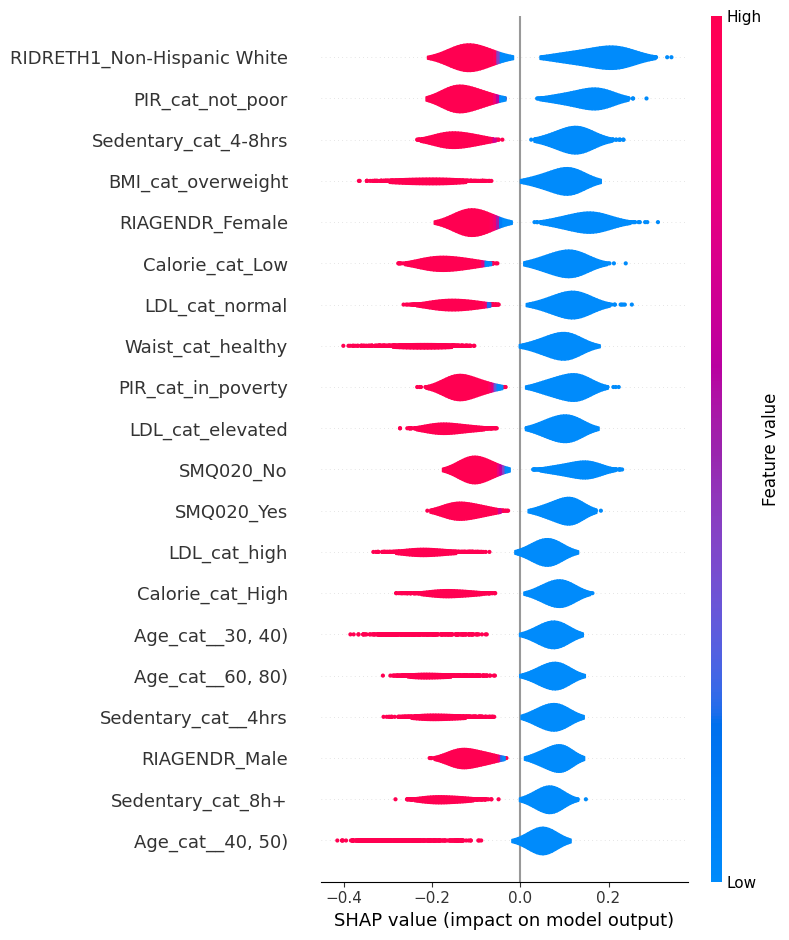

In [ ]:
# ===============================
# SHAP Violin Plot for XGBoost
# ===============================
# Prereqs:
#  - model: trained xgboost.XGBClassifier
#  - X_train, X_test: pandas DataFrames with identical columns

# --- Explainer (TreeExplainer is correct for XGBoost) ---
# Use background data (X_train) for expectations
explainer = shap.TreeExplainer(
    model,
    data=X_train,                      # background / masker
    feature_perturbation="interventional",
    model_output="probability"         # show impact on predicted probability
)

# --- Compute SHAP values on test set (new API returns Explanation) ---
sv = explainer(X_test)                 # sv.values shape: (n_samples, n_features)

# --- Violin-style summary (vertical density per feature) ---
# Note: summary_plot expects the raw array for violin/legacy plots
shap.summary_plot(
    sv.values,                         # SHAP matrix
    X_test,                            # features (same rows)
    plot_type="violin",                # <- gives the vertical “violin” look
    max_display=None
)

**Interpretation of SHAP Plot**

Key Predictors and Their Effects:
1. **Ethnicity**
* Non-Hispanic White

  * Shows a negative SHAP distribution.

  * Predictive of lower probability of abnormal fasting insulin.


2. **Socioeconomic Status (PIR)**
* Both not poor and in poverty had similar SHAP values

3. **Sedentary Behaviour**
* Sedentary 4–8 hours

  * Had a more positive SHAP value compared to <4 and >8 hours

* Sedentary ≥8 hours

  * Slightly more negative than 4-8h

* Sedentary <4 hours

  * Slightly more negative SHAP values than 8h+.


4. **Adiposity (BMI and Waist Circumference)**
* BMI_overweight and Waist_cat_healthy both do not have other categories in the plot to allow meaningful comparison.
* Healthy waist circumference had a more negative SHAP vaue compared to BMI overweight.

5. **Sex**
* Female

  * Slightly more positive SHAP values compared to male
  * Similar to some models previously done

6. **Caloric Intake**
* Both low and high calorie intake had similar SHAP values.


7. **LDL Cholesterol**
* Similar to some previous models, there is a dose-response relationship opposite to the expected direction

8. **Smoking Status**
* Similar trend to previous models, with smokers having more protective effect than non-smokers

9. **Age**
* Age 30–40

  * Mild negative SHAP values.

* Age 40–50

  * had more negative SHAP values than 30-40 year olds
  * the dose-response relationship is less clear in this model
* Age 60-80
  * More positive SHAP values compared to 30-50 year olds

Model-level Insight:

- The XGBoost fasting insulin model is dominated by upstream behavioural, socioeconomic, and adiposity-related factors.

- Compared to FPG and HbA1c, fasting insulin prediction emphasises early metabolic dysfunction, making it highly sensitive to lifestyle patterns.

## 4.5 Summary

### Model Performance Summary

| Model                               | Accuracy | ROC-AUC  | F1-score (Positive Class) |
| :---------------------------------- | :------- | :------- | :------------------------ |
| HbA1c Logistic Regression           | 0.7326   | 0.7486   | 0.49                      |
| HbA1c XGBoost                       | 0.7143   | 0.7224   | 0.48                      |
| FPG Logistic Regression             | 0.6623   | 0.7196   | 0.57                      |
| FPG XGBoost                         | 0.6229   | 0.6655   | 0.55                      |
| OGTT Logistic Regression            | 0.8004   | 0.7306   | 0.30                      |
| OGTT XGBoost                        | 0.7571   | 0.6584   | 0.29                      |
| Fasting Insulin Logistic Regression | 0.6888   | 0.7261   | 0.58                      |
| Fasting Insulin XGBoost             | 0.6551   | 0.6791   | 0.48                      |

### Performance metrics summary analysis:
*   The OGTT Logistic Regression model achieved the highest accuracy at 0.8004.
*   The HbA1c Logistic Regression model showed the highest ROC-AUC score at 0.7486.
*   Fasting Insulin Logistic Regression yielded the highest F1-score for the positive class at 0.58, closely followed by FPG Logistic Regression at 0.57.
*   OGTT-based models (both Logistic Regression and XGBoost) exhibited the lowest F1-scores for the positive class, at 0.30 and 0.29 respectively, despite OGTT Logistic Regression having the highest overall accuracy.
*   Generally, Logistic Regression models tended to perform slightly better or comparably to their XGBoost counterparts in terms of Accuracy and ROC-AUC for HbA1c and FPG, and significantly better in F1-score for FPG and Fasting Insulin.

### SHAP Plot summary analysis:
- Established risk factors for diabetes (especially age) was clearly seen in most of the 8 prediction models.
  - Age, Ethnicity, and Adiposity are Consistent Predictors:
    - Older individuals, being of non-Hispanic White (protective effect), and higher adiposity (BMI and waist circumference) consistently emerged as strong predictors for abnormal levels across all four biomarkers models.
  - Sedentary Behavior is a Key Risk Factor:
    - Increased sedentary time (e.g., 4-8 hours, 8+ hours) consistently correlated with an increased risk of abnormal biomarker levels, particularly prominent in OGTT models, while less sedentary time (<4 hours) was protective.
- Notable abnormalities include:
  - Smoking status:
    - Smoking seems to have an reverse effect on diabetes
    - i.e. Smokers having lower probabilities of having abnormal diabetic biomarkers)
  - LDL Cholesterol:
    - While generally expected to increase risk, several models (FPG Logistic Regression, OGTT Logistic Regression, Fasting Insulin Logistic Regression and XGBoost) showed 'high' LDL as protective or a reversed dose-response compared to 'normal' LDL.

  - Caloric Intake:
    - In OGTT XGBoost, high caloric intake unexpectedly showed a protective effect, while low caloric intake was linked to increased risk, directly opposing physiological expectations.

- Variable Sex Effects:
  - Female sex was generally protective for HbA1c and FPG, but in OGTT Logistic Regression, Fasting Insulin Logistic Regression and XGBoost, female sex was associated with less protective effects.
